Transformer (с курсом и значением нефти и без учета этих факторов)

           Дата   Код  Сделок шт.         Объем  Средняя_цена  Открытие  \
0    2017-12-21  MGNT       15994  1.211838e+09        6263.0    6270.0   
1    2017-12-22  MGNT        7360  6.120610e+08        6286.0    6312.0   
2    2017-12-25  MGNT        3834  3.069669e+08        6250.0    6252.0   
3    2017-12-26  MGNT        6672  5.112053e+08        6239.0    6231.0   
4    2017-12-27  MGNT       11281  1.256956e+09        6252.0    6204.0   
...         ...   ...         ...           ...           ...       ...   
1950 2025-11-06  MGNT        6589  3.154492e+08        2864.0    2870.0   
1951 2025-11-07  MGNT        9577  4.367565e+08        2877.0    2865.0   
1952 2025-11-10  MGNT       15945  8.197367e+08        2892.0    2875.5   
1953 2025-11-11  MGNT        5933  3.426140e+08        2873.5    2881.0   
1954 2025-11-12  MGNT        7180  3.614555e+08        2869.0    2880.5   

      Минимум  Максимум  Закрытие  Количество       Курс   Значение  
0      6220.0    6319.0    62

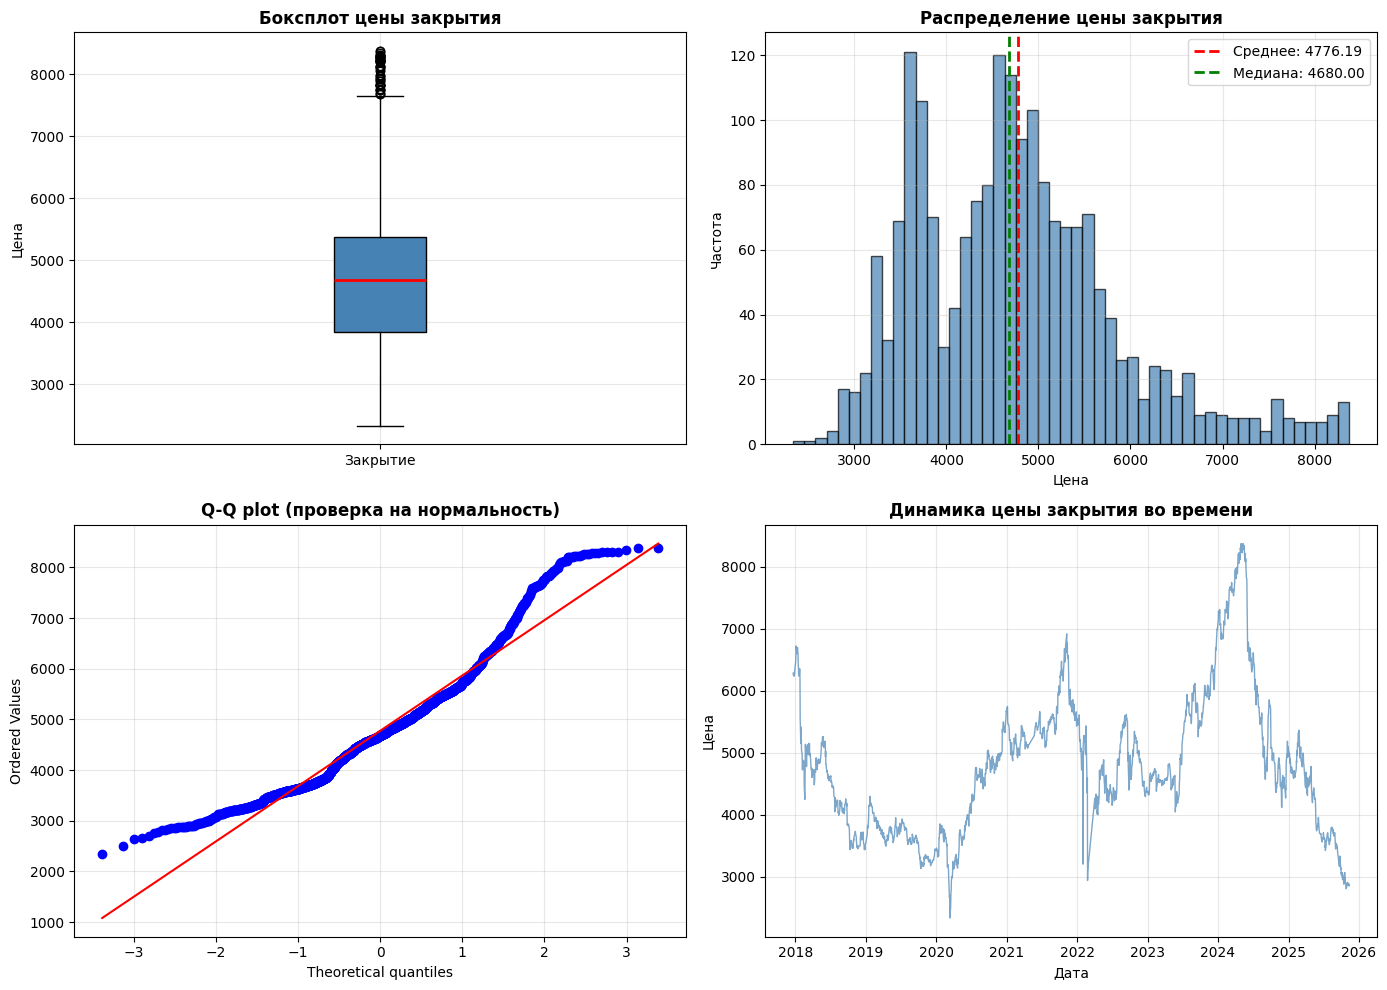


График сохранен: price_analysis.png

ДЕТАЛЬНЫЙ АНАЛИЗ ВЫБРОСОВ

Даты с выбросами:
      Дата  Закрытие     Тип
2024-03-04    7678.5 Верхний
2024-03-11    7695.5 Верхний
2024-03-12    7749.5 Верхний
2024-03-13    7684.0 Верхний
2024-03-27    7744.5 Верхний
2024-03-28    7744.0 Верхний
2024-03-29    7925.0 Верхний
2024-04-01    7970.0 Верхний
2024-04-02    7834.0 Верхний
2024-04-03    7827.0 Верхний
2024-04-04    7896.5 Верхний
2024-04-05    7812.5 Верхний
2024-04-08    7993.0 Верхний
2024-04-09    7921.0 Верхний
2024-04-10    7948.5 Верхний
2024-04-11    7891.0 Верхний
2024-04-12    7980.0 Верхний
2024-04-15    8203.0 Верхний
2024-04-16    8212.0 Верхний
2024-04-17    8200.0 Верхний
2024-04-18    8055.0 Верхний
2024-04-19    8229.0 Верхний
2024-04-22    8220.0 Верхний
2024-04-23    8221.0 Верхний
2024-04-24    8118.0 Верхний
2024-04-25    8130.0 Верхний
2024-04-26    8305.0 Верхний
2024-04-27    8284.5 Верхний
2024-04-29    8299.0 Верхний
2024-04-30    8376.0 Верхний
2024-05-02    8237

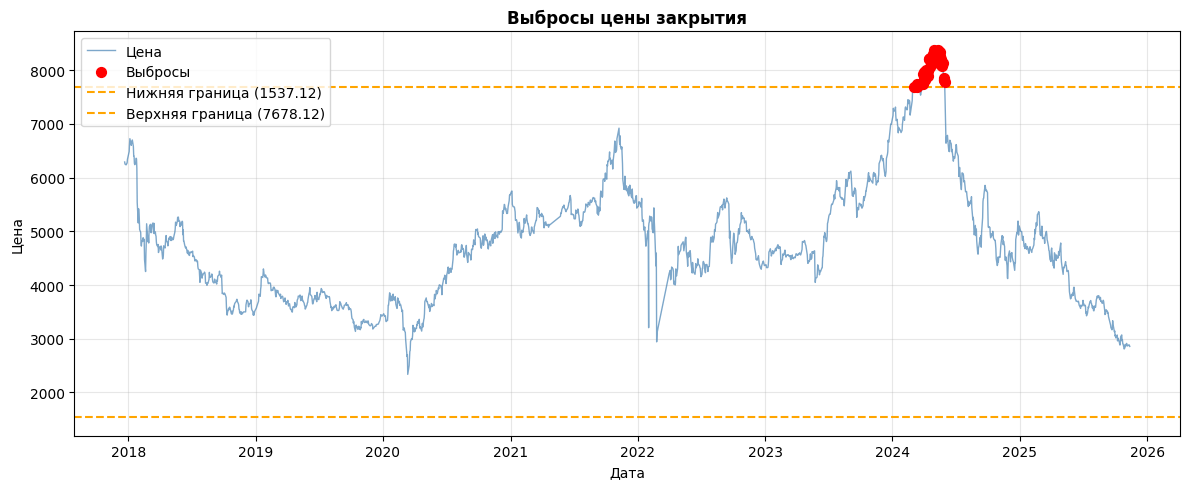


График выбросов сохранен: outliers_visualization.png

ВЫВОДЫ ПО АНАЛИЗУ

1. Распределение цены закрытия:
   - Среднее = 4776.19
   - Медиана = 4680.00
   - Стандартное отклонение = 1115.47

2. Асимметрия: Правосторонняя
   (среднее > медианы)

3. Выбросы:
   - Обнаружено 50 выбросов (2.56% от всех данных)
   - Требуется дополнительный анализ

4. Рекомендации:
   - Выбросы НЕ УДАЛЯТЬ, если не доказана их ошибочность
   - Для моделей ML выбросы можно оставить (устойчивые модели)
   - Для статистических методов может потребоваться обработка выбросов



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========== 1. ЗАГРУЗКА ДАННЫХ ==========
data = pd.read_csv('новая_нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата'])

result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

print(result)

# ========== 2. БОКСПЛОТ И АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЦЕНЫ ==========
print("\n" + "="*70)
print("АНАЛИЗ РАСПРЕДЕЛЕНИЯ ЦЕНЫ ЗАКРЫТИЯ")
print("="*70)

# Данные для анализа
prices = result['Закрытие'].values

# Статистика
print(f"\nСтатистика цены закрытия:")
print(f"  Количество наблюдений: {len(prices)}")
print(f"  Среднее значение: {np.mean(prices):.2f}")
print(f"  Медиана: {np.median(prices):.2f}")
print(f"  Стандартное отклонение: {np.std(prices):.2f}")
print(f"  Минимум: {np.min(prices):.2f}")
print(f"  Максимум: {np.max(prices):.2f}")

# Квартили
Q1 = np.percentile(prices, 25)
Q3 = np.percentile(prices, 75)
IQR = Q3 - Q1
print(f"\nКвартили:")
print(f"  Q1 (25%): {Q1:.2f}")
print(f"  Q2 (50%): {np.median(prices):.2f}")
print(f"  Q3 (75%): {Q3:.2f}")
print(f"  IQR (межквартильный размах): {IQR:.2f}")

# Границы для выбросов
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = prices[(prices < lower_bound) | (prices > upper_bound)]
print(f"\nВыбросы (по критерию 1.5×IQR):")
print(f"  Нижняя граница: {lower_bound:.2f}")
print(f"  Верхняя граница: {upper_bound:.2f}")
print(f"  Количество выбросов: {len(outliers)} ({len(outliers)/len(prices)*100:.2f}%)")
if len(outliers) > 0:
    print(f"  Значения выбросов: {sorted(outliers)[:10]}")  # первые 10

# ========== 3. ПОСТРОЕНИЕ ГРАФИКОВ ==========
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Боксплот цены закрытия
axes[0, 0].boxplot(prices, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='black'),
                    whiskerprops=dict(color='black'),
                    capprops=dict(color='black'),
                    medianprops=dict(color='red', linewidth=2))
axes[0, 0].set_title('Боксплот цены закрытия', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Цена', fontsize=10)
axes[0, 0].set_xticklabels(['Закрытие'])
axes[0, 0].grid(True, alpha=0.3)

# График 2: Гистограмма распределения цены
axes[0, 1].hist(prices, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(np.mean(prices), color='red', linestyle='--', linewidth=2, label=f'Среднее: {np.mean(prices):.2f}')
axes[0, 1].axvline(np.median(prices), color='green', linestyle='--', linewidth=2, label=f'Медиана: {np.median(prices):.2f}')
axes[0, 1].set_title('Распределение цены закрытия', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Цена', fontsize=10)
axes[0, 1].set_ylabel('Частота', fontsize=10)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: Q-Q plot для проверки нормальности
from scipy import stats
stats.probplot(prices, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q plot (проверка на нормальность)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# График 4: Динамика цены по времени (для контекста)
axes[1, 1].plot(result['Дата'], prices, color='steelblue', linewidth=1, alpha=0.7)
axes[1, 1].set_title('Динамика цены закрытия во времени', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Дата', fontsize=10)
axes[1, 1].set_ylabel('Цена', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: price_analysis.png")

# ========== 4. ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ ВЫБРОСОВ ==========
print("\n" + "="*70)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ВЫБРОСОВ")
print("="*70)

if len(outliers) > 0:
    # Находим индексы выбросов
    outlier_indices = np.where((prices < lower_bound) | (prices > upper_bound))[0]

    # Создаем DataFrame с выбросами
    outliers_df = result.iloc[outlier_indices][['Дата', 'Закрытие']].copy()
    outliers_df['Тип'] = outliers_df['Закрытие'].apply(
        lambda x: 'Нижний' if x < lower_bound else 'Верхний'
    )

    print(f"\nДаты с выбросами:")
    print(outliers_df.to_string(index=False))

    # Визуализация выбросов на динамике
    plt.figure(figsize=(12, 5))
    plt.plot(result['Дата'], prices, color='steelblue', linewidth=1, alpha=0.7, label='Цена')
    plt.scatter(outliers_df['Дата'], outliers_df['Закрытие'],
                color='red', s=50, zorder=5, label='Выбросы')
    plt.axhline(y=lower_bound, color='orange', linestyle='--', label=f'Нижняя граница ({lower_bound:.2f})')
    plt.axhline(y=upper_bound, color='orange', linestyle='--', label=f'Верхняя граница ({upper_bound:.2f})')
    plt.title('Выбросы цены закрытия', fontsize=12, fontweight='bold')
    plt.xlabel('Дата', fontsize=10)
    plt.ylabel('Цена', fontsize=10)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outliers_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nГрафик выбросов сохранен: outliers_visualization.png")
else:
    print("\nВыбросы не обнаружены.")

# ========== 5. ВЫВОДЫ ==========
print("\n" + "="*70)
print("ВЫВОДЫ ПО АНАЛИЗУ")
print("="*70)

print(f"""
1. Распределение цены закрытия:
   - Среднее = {np.mean(prices):.2f}
   - Медиана = {np.median(prices):.2f}
   - Стандартное отклонение = {np.std(prices):.2f}

2. Асимметрия: {'Правосторонняя' if np.mean(prices) > np.median(prices) else 'Левосторонняя'}
   (среднее {'>' if np.mean(prices) > np.median(prices) else '<'} медианы)

3. Выбросы:
   - Обнаружено {len(outliers)} выбросов ({len(outliers)/len(prices)*100:.2f}% от всех данных)
   - {'Требуется дополнительный анализ' if len(outliers) > 0 else 'Не обнаружены'}

4. Рекомендации:
   - {'Выбросы НЕ УДАЛЯТЬ, если не доказана их ошибочность' if len(outliers) > 0 else 'Данные чистые'}
   - Для моделей ML выбросы можно оставить (устойчивые модели)
   - Для статистических методов может потребоваться обработка выбросов
""")

In [ ]:
import pandas as pd
import yfinance as yf

brent = yf.download('BZ=F', start='2017-12-21', end='2025-11-13', progress=False, auto_adjust=False)
df = brent[['Close']].copy()
df.columns = ['Значение']
df.index = pd.to_datetime(df.index)
all_dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df = df.reindex(all_dates)
df['Значение'] = df['Значение'].interpolate(method='spline', order=3).bfill().ffill()

df = df.reset_index()
df.columns = ['Дата', 'Значение']

from google.colab import files
df.to_csv('новая_нефть.csv', encoding='utf-8-sig', index=False)
files.download('новая_нефть.csv')

print("Файл скачан на ваш компьютер")
print(f"Строк: {len(df)}")
print(df.head(3))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл скачан на ваш компьютер
Строк: 2884
        Дата   Значение
0 2017-12-21  64.900002
1 2017-12-22  65.250000
2 2017-12-23  65.552565



ТАБЛИЦА КОРРЕЛЯЦИЙ ПРИЗНАКОВ С Close_today
№    Признак                                     Корреляция
-----------------------------------------------------------------
1    Open_today                          +           0.9961
2    Low_yesterday                       +           0.9945
3    Close_yesterday                     +           0.9942
4    High_yesterday                      +           0.9934
5    Open_yesterday                      +           0.9918
6    EMA_5_yesterday                     +           0.9909
7    SMA_5_yesterday                     +           0.9892
8    EMA_10_yesterday                    +           0.9852
9    SMA_10_yesterday                    +           0.9813
10   EMA_20_yesterday                    +           0.9738
11   SMA_20_yesterday                    +           0.9656
12   BB_middle_yesterday                 +           0.9656
13   price_to_rate_today                 +           0.7219
14   Currency_yesterday                  +        

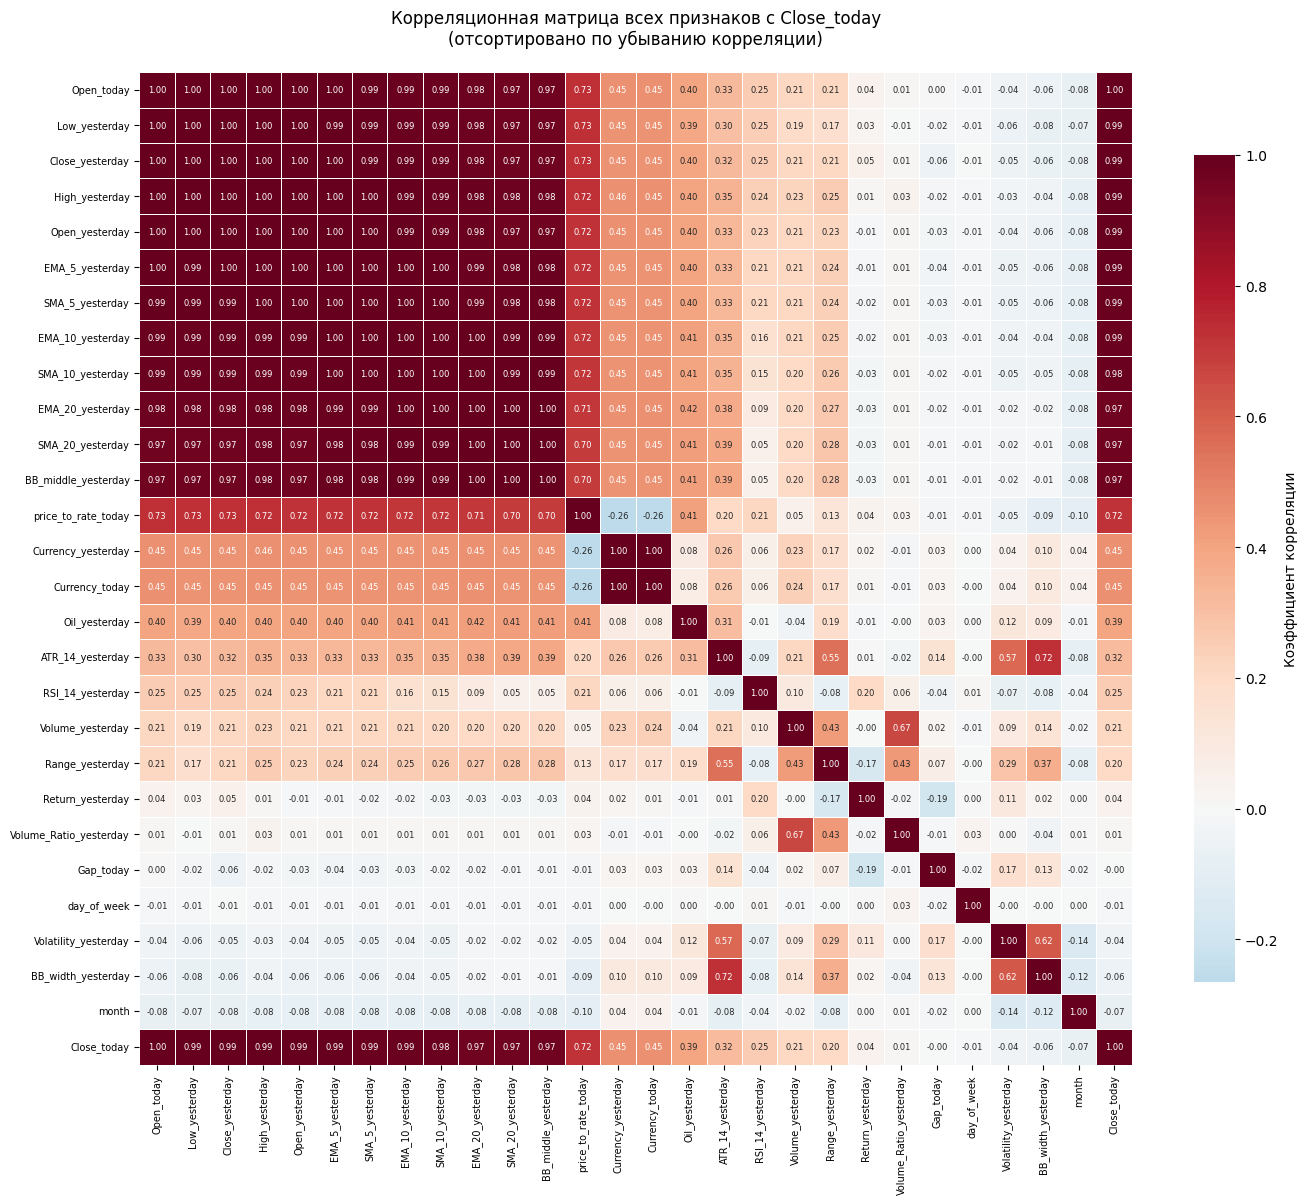

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========== 1. ЗАГРУЗКА ДАННЫХ ==========
data = pd.read_csv('новая_нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата'])

result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)


# ========== 2. ОПРЕДЕЛЕНИЕ ФУНКЦИЙ ==========

def create_features_without_external(data):
    df = data.copy()
    df['Дата_dt'] = pd.to_datetime(df['Дата'])

    df['Open_today'] = df['Открытие']

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['Open_yesterday'] = df['Открытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)

    df['Range_yesterday'] = df['High_yesterday'] - df['Low_yesterday']
    df['Return_yesterday'] = df['Close_yesterday'].pct_change() * 100

    for window in [5, 10, 20]:
        df[f'SMA_{window}_yesterday'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}_yesterday'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()

    def calculate_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / (loss + 1e-10)
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['RSI_14_yesterday'] = calculate_rsi(df['Close_yesterday'], 14)
    df['BB_middle_yesterday'] = df['Close_yesterday'].rolling(20).mean()
    bb_std = df['Close_yesterday'].rolling(20).std()
    df['BB_width_yesterday'] = 2 * bb_std / (df['BB_middle_yesterday'] + 1e-10)
    df['ATR_14_yesterday'] = (df['High_yesterday'] - df['Low_yesterday']).rolling(14).mean()
    df['Volatility_yesterday'] = df['Close_yesterday'].pct_change().rolling(10).std() * np.sqrt(252)
    df['Volume_Ratio_yesterday'] = df['Volume_yesterday'] / (df['Volume_yesterday'].rolling(20).mean() + 1e-10)
    df['Gap_today'] = (df['Открытие'] - df['Close_yesterday']) / (df['Close_yesterday'] + 1e-10) * 100
    df['day_of_week'] = df['Дата_dt'].dt.dayofweek
    df['month'] = df['Дата_dt'].dt.month

    df['Close_today'] = df['Закрытие']

    cols_to_drop = ['Средняя_цена', 'Количество', 'Закрытие', 'Максимум', 'Минимум',
                    'Объем', 'Курс', 'Значение', 'Открытие', 'Дата', 'Дата_dt']

    feature_cols = [c for c in df.columns if c not in cols_to_drop]
    df_clean = df.dropna().reset_index(drop=True)
    return df_clean, feature_cols, 'Close_today'


def create_features_with_external(data):
    df = data.copy()
    df['Дата_dt'] = pd.to_datetime(df['Дата'])

    df['Open_today'] = df['Открытие']
    df['Currency_today'] = df['Курс']

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['Open_yesterday'] = df['Открытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['Currency_yesterday'] = df['Курс'].shift(1)
    df['Oil_yesterday'] = df['Значение'].shift(1)

    df['Range_yesterday'] = df['High_yesterday'] - df['Low_yesterday']
    df['Return_yesterday'] = df['Close_yesterday'].pct_change() * 100

    for window in [5, 10, 20]:
        df[f'SMA_{window}_yesterday'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}_yesterday'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()

    def calculate_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / (loss + 1e-10)
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['RSI_14_yesterday'] = calculate_rsi(df['Close_yesterday'], 14)
    df['BB_middle_yesterday'] = df['Close_yesterday'].rolling(20).mean()
    bb_std = df['Close_yesterday'].rolling(20).std()
    df['BB_width_yesterday'] = 2 * bb_std / (df['BB_middle_yesterday'] + 1e-10)
    df['ATR_14_yesterday'] = (df['High_yesterday'] - df['Low_yesterday']).rolling(14).mean()
    df['Volatility_yesterday'] = df['Close_yesterday'].pct_change().rolling(10).std() * np.sqrt(252)
    df['Volume_Ratio_yesterday'] = df['Volume_yesterday'] / (df['Volume_yesterday'].rolling(20).mean() + 1e-10)
    df['Gap_today'] = (df['Открытие'] - df['Close_yesterday']) / (df['Close_yesterday'] + 1e-10) * 100
    df['price_to_rate_today'] = df['Open_today'] / (df['Currency_today'] + 1e-10)
    df['day_of_week'] = df['Дата_dt'].dt.dayofweek
    df['month'] = df['Дата_dt'].dt.month

    df['Close_today'] = df['Закрытие']

    cols_to_drop = ['Средняя_цена', 'Количество', 'Закрытие', 'Максимум', 'Минимум',
                    'Объем', 'Курс', 'Значение', 'Открытие', 'Дата', 'Дата_dt']

    feature_cols = [c for c in df.columns if c not in cols_to_drop]
    df_clean = df.dropna().reset_index(drop=True)
    return df_clean, feature_cols, 'Close_today'


# ========== 3. СОЗДАНИЕ ДАННЫХ ==========
df_without, features_without, target = create_features_without_external(result)
df_with, features_with, target = create_features_with_external(result)


# ========== 4. ОБЪЕДИНЕНИЕ ПРИЗНАКОВ ИЗ ОБОИХ НАБОРОВ ==========
# Список всех возможных признаков
features_list = [
    'Open_today', 'Close_yesterday', 'Open_yesterday', 'High_yesterday', 'Low_yesterday',
    'Volume_yesterday', 'Range_yesterday', 'Return_yesterday', 'SMA_5_yesterday',
    'SMA_10_yesterday', 'SMA_20_yesterday', 'EMA_5_yesterday', 'EMA_10_yesterday',
    'EMA_20_yesterday', 'RSI_14_yesterday', 'BB_middle_yesterday', 'BB_width_yesterday',
    'ATR_14_yesterday', 'Volatility_yesterday', 'Volume_Ratio_yesterday', 'Gap_today',
    'day_of_week', 'month', 'Currency_today', 'Currency_yesterday', 'Oil_yesterday',
    'price_to_rate_today'
]

# Используем df_with (в нём есть все признаки)
existing_features = [f for f in features_list if f in df_with.columns]

# Вычисляем корреляции
corr_values = df_with[existing_features + [target]].corr()[target].drop(target).sort_values(ascending=False)


# ========== 5. ВЫВОД ТАБЛИЦЫ ==========
print("\n" + "="*65)
print("ТАБЛИЦА КОРРЕЛЯЦИЙ ПРИЗНАКОВ С Close_today")
print("="*65)
print(f"{'№':<4} {'Признак':<35} {'Корреляция':>18}")
print("-"*65)

for i, (name, val) in enumerate(corr_values.items(), 1):
    sign = "+" if val > 0 else ""
    print(f"{i:<4} {name:<35} {sign}{val:>17.4f}")

print("="*65)
print(f"Всего признаков: {len(corr_values)}")


# ========== 6. ТЕПЛОВАЯ КАРТА (ВСЕ ПРИЗНАКИ) ==========
# Берём ВСЕ признаки из corr_values
all_features = corr_values.index.tolist()

# Сортируем для тепловой карты по убыванию корреляции с целевой переменной
sorted_by_corr = all_features
corr_matrix_full = df_with[sorted_by_corr + [target]].corr()

# Размер карты зависит от количества признаков
figsize = (max(14, len(all_features) * 0.4), max(12, len(all_features) * 0.4))

plt.figure(figsize=figsize)
sns.heatmap(corr_matrix_full, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True, annot_kws={'size': 6},
            cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'})

plt.title('Корреляционная матрица всех признаков с Close_today\n(отсортировано по убыванию корреляции)',
          fontsize=12, pad=20)
plt.xticks(rotation=90, ha='center', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('correlation_heatmap_full.png', dpi=150, bbox_inches='tight')
plt.show()


ТАБЛИЦА КОРРЕЛЯЦИЙ ПРИЗНАКОВ С Close_today
№    Признак                                     Корреляция
-----------------------------------------------------------------
1    Open_today                          +           0.9961
2    Low_yesterday                       +           0.9945
3    Close_yesterday                     +           0.9942
4    High_yesterday                      +           0.9934
5    Open_yesterday                      +           0.9918
6    EMA_5_yesterday                     +           0.9909
7    SMA_5_yesterday                     +           0.9892
8    EMA_10_yesterday                    +           0.9852
9    SMA_10_yesterday                    +           0.9813
10   EMA_20_yesterday                    +           0.9738
11   SMA_20_yesterday                    +           0.9656
12   BB_middle_yesterday                 +           0.9656
13   price_to_rate_today                 +           0.7219
14   Currency_yesterday                  +        

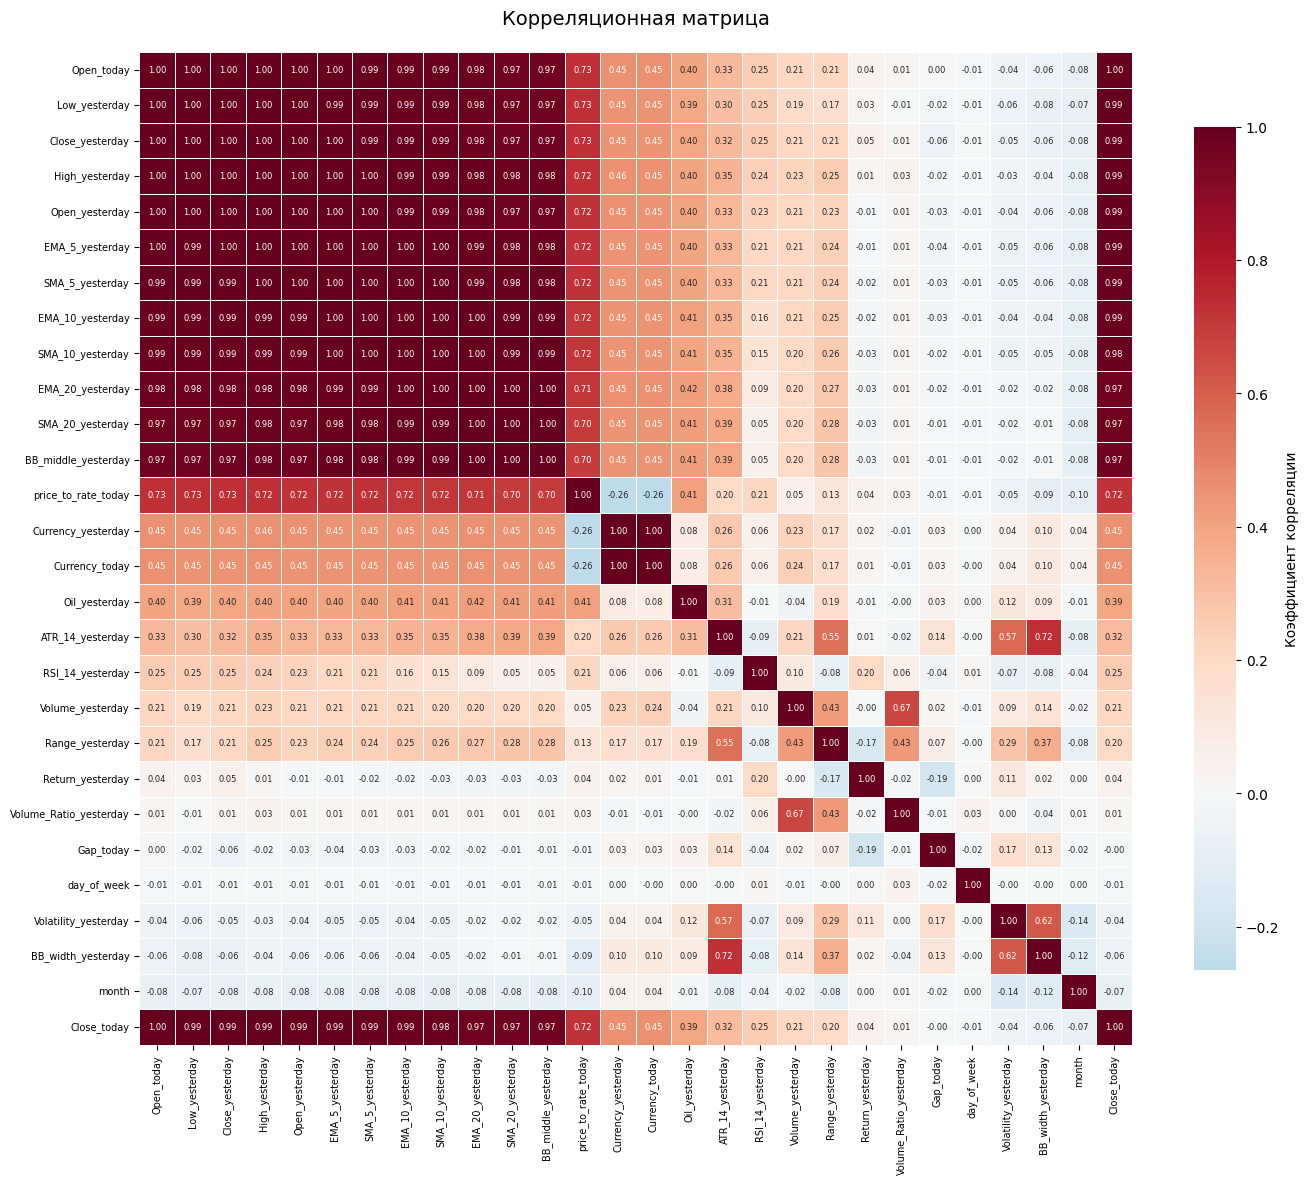

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ========== 1. ЗАГРУЗКА ДАННЫХ ==========
data = pd.read_csv('новая_нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата'])

result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)


# ========== 2. ОПРЕДЕЛЕНИЕ ФУНКЦИЙ ==========

def create_features_without_external(data):
    df = data.copy()
    df['Дата_dt'] = pd.to_datetime(df['Дата'])

    df['Open_today'] = df['Открытие']

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['Open_yesterday'] = df['Открытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)

    df['Range_yesterday'] = df['High_yesterday'] - df['Low_yesterday']
    df['Return_yesterday'] = df['Close_yesterday'].pct_change() * 100

    for window in [5, 10, 20]:
        df[f'SMA_{window}_yesterday'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}_yesterday'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()

    def calculate_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / (loss + 1e-10)
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['RSI_14_yesterday'] = calculate_rsi(df['Close_yesterday'], 14)
    df['BB_middle_yesterday'] = df['Close_yesterday'].rolling(20).mean()
    bb_std = df['Close_yesterday'].rolling(20).std()
    df['BB_width_yesterday'] = 2 * bb_std / (df['BB_middle_yesterday'] + 1e-10)
    df['ATR_14_yesterday'] = (df['High_yesterday'] - df['Low_yesterday']).rolling(14).mean()
    df['Volatility_yesterday'] = df['Close_yesterday'].pct_change().rolling(10).std() * np.sqrt(252)
    df['Volume_Ratio_yesterday'] = df['Volume_yesterday'] / (df['Volume_yesterday'].rolling(20).mean() + 1e-10)
    df['Gap_today'] = (df['Открытие'] - df['Close_yesterday']) / (df['Close_yesterday'] + 1e-10) * 100
    df['day_of_week'] = df['Дата_dt'].dt.dayofweek
    df['month'] = df['Дата_dt'].dt.month

    df['Close_today'] = df['Закрытие']

    cols_to_drop = ['Средняя_цена', 'Количество', 'Закрытие', 'Максимум', 'Минимум',
                    'Объем', 'Курс', 'Значение', 'Открытие', 'Дата', 'Дата_dt']

    feature_cols = [c for c in df.columns if c not in cols_to_drop]
    df_clean = df.dropna().reset_index(drop=True)
    return df_clean, feature_cols, 'Close_today'


def create_features_with_external(data):
    df = data.copy()
    df['Дата_dt'] = pd.to_datetime(df['Дата'])

    df['Open_today'] = df['Открытие']
    df['Currency_today'] = df['Курс']

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['Open_yesterday'] = df['Открытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['Currency_yesterday'] = df['Курс'].shift(1)
    df['Oil_yesterday'] = df['Значение'].shift(1)

    df['Range_yesterday'] = df['High_yesterday'] - df['Low_yesterday']
    df['Return_yesterday'] = df['Close_yesterday'].pct_change() * 100

    for window in [5, 10, 20]:
        df[f'SMA_{window}_yesterday'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}_yesterday'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()

    def calculate_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / (loss + 1e-10)
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['RSI_14_yesterday'] = calculate_rsi(df['Close_yesterday'], 14)
    df['BB_middle_yesterday'] = df['Close_yesterday'].rolling(20).mean()
    bb_std = df['Close_yesterday'].rolling(20).std()
    df['BB_width_yesterday'] = 2 * bb_std / (df['BB_middle_yesterday'] + 1e-10)
    df['ATR_14_yesterday'] = (df['High_yesterday'] - df['Low_yesterday']).rolling(14).mean()
    df['Volatility_yesterday'] = df['Close_yesterday'].pct_change().rolling(10).std() * np.sqrt(252)
    df['Volume_Ratio_yesterday'] = df['Volume_yesterday'] / (df['Volume_yesterday'].rolling(20).mean() + 1e-10)
    df['Gap_today'] = (df['Открытие'] - df['Close_yesterday']) / (df['Close_yesterday'] + 1e-10) * 100
    df['price_to_rate_today'] = df['Open_today'] / (df['Currency_today'] + 1e-10)
    df['day_of_week'] = df['Дата_dt'].dt.dayofweek
    df['month'] = df['Дата_dt'].dt.month

    df['Close_today'] = df['Закрытие']

    cols_to_drop = ['Средняя_цена', 'Количество', 'Закрытие', 'Максимум', 'Минимум',
                    'Объем', 'Курс', 'Значение', 'Открытие', 'Дата', 'Дата_dt']

    feature_cols = [c for c in df.columns if c not in cols_to_drop]
    df_clean = df.dropna().reset_index(drop=True)
    return df_clean, feature_cols, 'Close_today'


# ========== 3. СОЗДАНИЕ ДАННЫХ ==========
df_without, features_without, target = create_features_without_external(result)
df_with, features_with, target = create_features_with_external(result)


# ========== 4. ОБЪЕДИНЕНИЕ ПРИЗНАКОВ ИЗ ОБОИХ НАБОРОВ ==========
# Список всех возможных признаков
features_list = [
    'Open_today', 'Close_yesterday', 'Open_yesterday', 'High_yesterday', 'Low_yesterday',
    'Volume_yesterday', 'Range_yesterday', 'Return_yesterday', 'SMA_5_yesterday',
    'SMA_10_yesterday', 'SMA_20_yesterday', 'EMA_5_yesterday', 'EMA_10_yesterday',
    'EMA_20_yesterday', 'RSI_14_yesterday', 'BB_middle_yesterday', 'BB_width_yesterday',
    'ATR_14_yesterday', 'Volatility_yesterday', 'Volume_Ratio_yesterday', 'Gap_today',
    'day_of_week', 'month', 'Currency_today', 'Currency_yesterday', 'Oil_yesterday',
    'price_to_rate_today'
]

# Используем df_with (в нём есть все признаки)
existing_features = [f for f in features_list if f in df_with.columns]

# Вычисляем корреляции
corr_values = df_with[existing_features + [target]].corr()[target].drop(target).sort_values(ascending=False)


# ========== 5. ВЫВОД ТАБЛИЦЫ ==========
print("\n" + "="*65)
print("ТАБЛИЦА КОРРЕЛЯЦИЙ ПРИЗНАКОВ С Close_today")
print("="*65)
print(f"{'№':<4} {'Признак':<35} {'Корреляция':>18}")
print("-"*65)

for i, (name, val) in enumerate(corr_values.items(), 1):
    sign = "+" if val > 0 else ""
    print(f"{i:<4} {name:<35} {sign}{val:>17.4f}")

print("="*65)
print(f"Всего признаков: {len(corr_values)}")


# ========== 6. ТЕПЛОВАЯ КАРТА ==========
# Берём ВСЕ признаки из corr_values
all_features = corr_values.index.tolist()

# Сортируем для тепловой карты по убыванию корреляции с целевой переменной
sorted_by_corr = all_features
corr_matrix_full = df_with[sorted_by_corr + [target]].corr()

# Размер карты зависит от количества признаков
figsize = (max(14, len(all_features) * 0.4), max(12, len(all_features) * 0.4))

plt.figure(figsize=figsize)
sns.heatmap(corr_matrix_full, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, square=True, annot_kws={'size': 6},
            cbar_kws={'shrink': 0.8, 'label': 'Коэффициент корреляции'})

plt.title('Корреляционная матрица', fontsize=14, pad=20)
plt.xticks(rotation=90, ha='center', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()

# Сохранение на компьютер с указанием полного пути
plt.savefig('correlation_matrix.png', dpi=300, bbox_inches='tight')
print("\nГрафик сохранён как 'correlation_matrix.png' в текущей папке")

plt.show()

МОДЕЛЬ БЕЗ ВНЕШНИХ ФАКТОРОВ
Признаков: 30

ПОИСК ПО СЕТКЕ (Grid Search)
    Комбинация 1/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 2, 'num_layers': 1, 'weight_decay': 0.01}
      Val Loss: 1.890530
      -> НОВЫЙ ЛУЧШИЙ!
    Комбинация 2/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 2, 'num_layers': 1, 'weight_decay': 0.02}
      Val Loss: 1.853345
      -> НОВЫЙ ЛУЧШИЙ!
    Комбинация 3/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 2, 'num_layers': 2, 'weight_decay': 0.01}
      Val Loss: 2.250905
    Комбинация 4/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 2, 'num_layers': 2, 'weight_decay': 0.02}
      Val Loss: 2.654655
    Комбинация 5/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 4, 'num_layers': 1, 'weight_decay': 0.01}
      Val Loss: 1.966779
    Комбинация 6/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 4, 'num_layers': 1, 'weight_decay': 0.02}
      Val Loss: 1.780787
      -> НОВЫЙ ЛУЧШИЙ!
    Ком

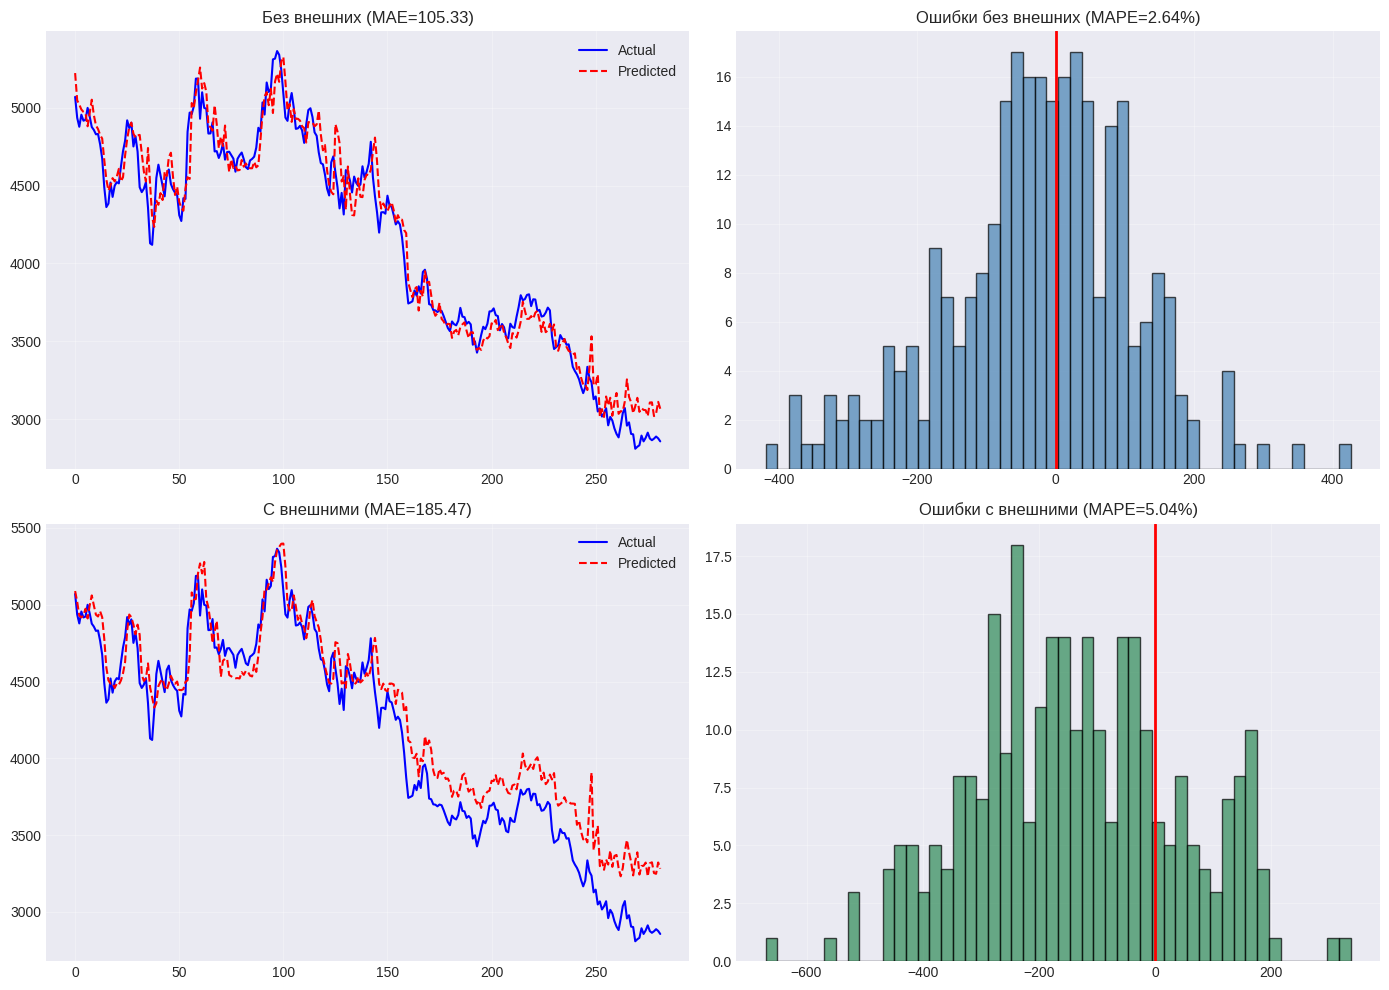


График сохранен: transformer_grid_search.png


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# Загрузка данных
data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата'])

result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

for col_name in result.columns:
    if result[col_name].dtype == 'object' and col_name != 'Дата':
        result = result.drop(columns=[col_name])

def create_features_without_external(data):
    """Создание признаков БЕЗ внешних факторов + ЛАГОВЫЕ ОШИБКИ"""
    df = data.copy()
    df['Дата_dt'] = pd.to_datetime(df['Дата'])

    df['Open_today'] = df['Открытие']

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['Open_yesterday'] = df['Открытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)

    df['Range_yesterday'] = df['High_yesterday'] - df['Low_yesterday']
    df['Return_yesterday'] = df['Close_yesterday'].pct_change() * 100

    for window in [5, 10, 20]:
        df[f'SMA_{window}_yesterday'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}_yesterday'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()

    def calculate_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / (loss + 1e-10)
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['RSI_14_yesterday'] = calculate_rsi(df['Close_yesterday'], 14)
    df['BB_middle_yesterday'] = df['Close_yesterday'].rolling(20).mean()
    bb_std = df['Close_yesterday'].rolling(20).std()
    df['BB_width_yesterday'] = 2 * bb_std / (df['BB_middle_yesterday'] + 1e-10)
    df['ATR_14_yesterday'] = (df['High_yesterday'] - df['Low_yesterday']).rolling(14).mean()
    df['Volatility_yesterday'] = df['Close_yesterday'].pct_change().rolling(10).std() * np.sqrt(252)
    df['Volume_Ratio_yesterday'] = df['Volume_yesterday'] / (df['Volume_yesterday'].rolling(20).mean() + 1e-10)
    df['Gap_today'] = (df['Открытие'] - df['Close_yesterday']) / (df['Close_yesterday'] + 1e-10) * 100
    df['day_of_week'] = df['Дата_dt'].dt.dayofweek
    df['month'] = df['Дата_dt'].dt.month

    # ========== ЛАГОВЫЕ ОШИБКИ ==========
    # Прокси ошибки: разница между вчерашним закрытием и вчерашним открытием
    df['error_proxy'] = df['Close_yesterday'] - df['Open_yesterday']
    df['error_lag1'] = df['error_proxy'].shift(1)
    df['error_lag2'] = df['error_proxy'].shift(2)
    df['error_lag3'] = df['error_proxy'].shift(3)
    df['error_ma5'] = df['error_proxy'].rolling(5).mean()
    df['error_std5'] = df['error_proxy'].rolling(5).std()

    df['Close_today'] = df['Закрытие']

    cols_to_drop = ['Средняя_цена', 'Количество', 'Закрытие', 'Максимум', 'Минимум',
                    'Объем', 'Курс', 'Значение', 'Открытие', 'Дата', 'Дата_dt', 'error_proxy']

    feature_cols = [c for c in df.columns if c not in cols_to_drop]
    df_clean = df.dropna().reset_index(drop=True)
    return df_clean, feature_cols, 'Close_today'

def create_features_with_external(data):
    """Создание признаков С внешними факторами"""
    df = data.copy()
    df['Дата_dt'] = pd.to_datetime(df['Дата'])

    df['Open_today'] = df['Открытие']
    df['Currency_today'] = df['Курс']

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['Open_yesterday'] = df['Открытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['Currency_yesterday'] = df['Курс'].shift(1)
    df['Oil_yesterday'] = df['Значение'].shift(1)

    df['Range_yesterday'] = df['High_yesterday'] - df['Low_yesterday']
    df['Return_yesterday'] = df['Close_yesterday'].pct_change() * 100

    for window in [5, 10, 20]:
        df[f'SMA_{window}_yesterday'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}_yesterday'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()

    def calculate_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / (loss + 1e-10)
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['RSI_14_yesterday'] = calculate_rsi(df['Close_yesterday'], 14)
    df['BB_middle_yesterday'] = df['Close_yesterday'].rolling(20).mean()
    bb_std = df['Close_yesterday'].rolling(20).std()
    df['BB_width_yesterday'] = 2 * bb_std / (df['BB_middle_yesterday'] + 1e-10)
    df['ATR_14_yesterday'] = (df['High_yesterday'] - df['Low_yesterday']).rolling(14).mean()
    df['Volatility_yesterday'] = df['Close_yesterday'].pct_change().rolling(10).std() * np.sqrt(252)
    df['Volume_Ratio_yesterday'] = df['Volume_yesterday'] / (df['Volume_yesterday'].rolling(20).mean() + 1e-10)
    df['Gap_today'] = (df['Открытие'] - df['Close_yesterday']) / (df['Close_yesterday'] + 1e-10) * 100
    df['price_to_rate_today'] = df['Open_today'] / (df['Currency_today'] + 1e-10)
    df['day_of_week'] = df['Дата_dt'].dt.dayofweek
    df['month'] = df['Дата_dt'].dt.month

    df['Close_today'] = df['Закрытие']

    cols_to_drop = ['Средняя_цена', 'Количество', 'Закрытие', 'Максимум', 'Минимум',
                    'Объем', 'Курс', 'Значение', 'Открытие', 'Дата', 'Дата_dt']

    feature_cols = [c for c in df.columns if c not in cols_to_drop]
    df_clean = df.dropna().reset_index(drop=True)
    return df_clean, feature_cols, 'Close_today'

    df['RSI_14_yesterday'] = calculate_rsi(df['Close_yesterday'], 14)
    df['BB_middle_yesterday'] = df['Close_yesterday'].rolling(20).mean()
    bb_std = df['Close_yesterday'].rolling(20).std()
    df['BB_width_yesterday'] = 2 * bb_std / (df['BB_middle_yesterday'] + 1e-10)
    df['ATR_14_yesterday'] = (df['High_yesterday'] - df['Low_yesterday']).rolling(14).mean()
    df['Volatility_yesterday'] = df['Close_yesterday'].pct_change().rolling(10).std() * np.sqrt(252)
    df['Volume_Ratio_yesterday'] = df['Volume_yesterday'] / (df['Volume_yesterday'].rolling(20).mean() + 1e-10)
    df['Gap_today'] = (df['Открытие'] - df['Close_yesterday']) / (df['Close_yesterday'] + 1e-10) * 100
    df['price_to_rate_today'] = df['Open_today'] / (df['Currency_today'] + 1e-10)
    df['day_of_week'] = df['Дата_dt'].dt.dayofweek
    df['month'] = df['Дата_dt'].dt.month

    df['Close_today'] = df['Закрытие']

    cols_to_drop = ['Средняя_цена', 'Количество', 'Закрытие', 'Максимум', 'Минимум',
                    'Объем', 'Курс', 'Значение', 'Открытие', 'Дата', 'Дата_dt']

    feature_cols = [c for c in df.columns if c not in cols_to_drop]
    df_clean = df.dropna().reset_index(drop=True)
    return df_clean, feature_cols, 'Close_today'

class StockDatasetFixed(Dataset):
    def __init__(self, features, target, sequence_length=10):
        self.features = features.astype(np.float32)
        self.target = target.astype(np.float32)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.features) - self.sequence_length

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.sequence_length]
        y = self.target[idx + self.sequence_length]
        return torch.FloatTensor(x), torch.FloatTensor([y])

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layers = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        x = self.output_layers(x)
        return x

def prepare_data(data_features, feature_cols, target_col):
    train_size = int(len(data_features) * 0.7)
    val_size = int(len(data_features) * 0.15)
    sequence_length = 10
    gap = sequence_length + 5

    train_data = data_features.iloc[:train_size - gap].copy()
    val_data = data_features.iloc[train_size:train_size + val_size - gap].copy()
    test_data = data_features.iloc[train_size + val_size:].copy()

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    train_features = train_data[feature_cols].values
    train_target = train_data[[target_col]].values

    train_features_scaled = feature_scaler.fit_transform(train_features)
    train_target_scaled = target_scaler.fit_transform(train_target).flatten()

    val_features_scaled = feature_scaler.transform(val_data[feature_cols].values)
    val_target_scaled = target_scaler.transform(val_data[[target_col]].values).flatten()

    test_features_scaled = feature_scaler.transform(test_data[feature_cols].values)
    test_target_scaled = target_scaler.transform(test_data[[target_col]].values).flatten()

    train_dataset = StockDatasetFixed(train_features_scaled, train_target_scaled, sequence_length)
    val_dataset = StockDatasetFixed(val_features_scaled, val_target_scaled, sequence_length)
    test_dataset = StockDatasetFixed(test_features_scaled, test_target_scaled, sequence_length)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    return train_loader, val_loader, test_loader, target_scaler

def train_model_fast(model, train_loader, val_loader, epochs=15, lr=0.001, wd=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    patience = 5
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()
        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return best_val_loss

def train_final_model(model, train_loader, val_loader, test_loader, target_scaler, lr=0.001, wd=0.01, epochs=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val_loss = float('inf')
    best_model_state = None
    patience = 15
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"    Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_state)

    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            predictions.extend(outputs.cpu().numpy().flatten())
            actuals.extend(batch_y.numpy().flatten())

    predictions = target_scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
    actuals = target_scaler.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()

    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    r2 = 1 - np.sum((actuals - predictions)**2) / np.sum((actuals - np.mean(actuals))**2)

    return mae, rmse, mape, r2, predictions, actuals

def grid_search_transformer(train_loader, val_loader, input_dim, param_grid):
    best_loss = float('inf')
    best_params = None

    total = len(list(ParameterGrid(param_grid)))
    current = 0

    for params in ParameterGrid(param_grid):
        current += 1
        print(f"    Комбинация {current}/{total}: {params}")

        if params['d_model'] % params['nhead'] != 0:
            print(f"      Пропуск (d_model={params['d_model']} не делится на nhead={params['nhead']})")
            continue

        model = TimeSeriesTransformer(
            input_dim=input_dim,
            d_model=params['d_model'],
            nhead=params['nhead'],
            num_layers=params['num_layers'],
            dropout=params['dropout']
        )

        loss = train_model_fast(model, train_loader, val_loader,
                                epochs=15, lr=params['lr'], wd=params['weight_decay'])

        print(f"      Val Loss: {loss:.6f}")

        if loss < best_loss:
            best_loss = loss
            best_params = params.copy()
            print(f"      -> НОВЫЙ ЛУЧШИЙ!")

    return best_params, best_loss

# Параметры для Grid Search
param_grid = {
    'd_model': [48, 64],
    'nhead': [2, 4],
    'num_layers': [1, 2],
    'dropout': [0.2, 0.3],
    'lr': [0.001, 0.002],
    'weight_decay': [0.01, 0.02]
}

results = {}

# ============================================
# МОДЕЛЬ БЕЗ ВНЕШНИХ ФАКТОРОВ
# ============================================
print("="*70)
print("МОДЕЛЬ БЕЗ ВНЕШНИХ ФАКТОРОВ")
print("="*70)

data_wo, feature_cols_wo, target_wo = create_features_without_external(result)
print(f"Признаков: {len(feature_cols_wo)}")

train_loader_wo, val_loader_wo, test_loader_wo, target_scaler_wo = prepare_data(data_wo, feature_cols_wo, target_wo)

print("\nПОИСК ПО СЕТКЕ (Grid Search)")
best_params_wo, best_loss_wo = grid_search_transformer(train_loader_wo, val_loader_wo, len(feature_cols_wo), param_grid)

print(f"\nЛучшие параметры: {best_params_wo}")
print(f"Лучший loss: {best_loss_wo:.6f}")

print("\nФИНАЛЬНОЕ ОБУЧЕНИЕ")
final_model_wo = TimeSeriesTransformer(
    input_dim=len(feature_cols_wo),
    d_model=best_params_wo['d_model'],
    nhead=best_params_wo['nhead'],
    num_layers=best_params_wo['num_layers'],
    dropout=best_params_wo['dropout']
)

mae_wo, rmse_wo, mape_wo, r2_wo, pred_wo, act_wo = train_final_model(
    final_model_wo, train_loader_wo, val_loader_wo, test_loader_wo, target_scaler_wo,
    lr=best_params_wo['lr'], wd=best_params_wo['weight_decay']
)

results['without'] = {'mae': mae_wo, 'rmse': rmse_wo, 'mape': mape_wo, 'r2': r2_wo, 'pred': pred_wo, 'act': act_wo, 'params': best_params_wo}

# ============================================
# МОДЕЛЬ С ВНЕШНИМИ ФАКТОРАМИ (с Oil_today и Currency_today)
# ============================================
print("\n" + "="*70)
print("МОДЕЛЬ С ВНЕШНИМИ ФАКТОРАМИ (Oil_today, Currency_today)")
print("="*70)

data_w, feature_cols_w, target_w = create_features_with_external(result)
print(f"Признаков: {len(feature_cols_w)}")

train_loader_w, val_loader_w, test_loader_w, target_scaler_w = prepare_data(data_w, feature_cols_w, target_w)

print("\nПОИСК ПО СЕТКЕ (Grid Search)")
best_params_w, best_loss_w = grid_search_transformer(train_loader_w, val_loader_w, len(feature_cols_w), param_grid)

print(f"\nЛучшие параметры: {best_params_w}")
print(f"Лучший loss: {best_loss_w:.6f}")

print("\nФИНАЛЬНОЕ ОБУЧЕНИЕ")
final_model_w = TimeSeriesTransformer(
    input_dim=len(feature_cols_w),
    d_model=best_params_w['d_model'],
    nhead=best_params_w['nhead'],
    num_layers=best_params_w['num_layers'],
    dropout=best_params_w['dropout']
)

mae_w, rmse_w, mape_w, r2_w, pred_w, act_w = train_final_model(
    final_model_w, train_loader_w, val_loader_w, test_loader_w, target_scaler_w,
    lr=best_params_w['lr'], wd=best_params_w['weight_decay']
)

results['with'] = {'mae': mae_w, 'rmse': rmse_w, 'mape': mape_w, 'r2': r2_w, 'pred': pred_w, 'act': act_w, 'params': best_params_w}

# ============================================
# СРАВНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================
print("\n" + "="*70)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*70)
print(f"{'Модель':<20} {'MAE':>10} {'RMSE':>10} {'MAPE(%)':>10} {'R²':>10}")
print("-"*60)
print(f"{'Без внешних':<20} {results['without']['mae']:>10.2f} {results['without']['rmse']:>10.2f} {results['without']['mape']:>10.2f} {results['without']['r2']:>10.4f}")
print(f"{'С внешними':<20} {results['with']['mae']:>10.2f} {results['with']['rmse']:>10.2f} {results['with']['mape']:>10.2f} {results['with']['r2']:>10.4f}")

print("\nЛУЧШИЕ ПАРАМЕТРЫ:")
print(f"Без внешних: {results['without']['params']}")
print(f"С внешними:  {results['with']['params']}")

# Графики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(results['without']['act'], label='Actual', color='blue', linewidth=1.5)
axes[0, 0].plot(results['without']['pred'], label='Predicted', color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title(f"Без внешних (MAE={results['without']['mae']:.2f})")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

errors_wo = results['without']['act'] - results['without']['pred']
axes[0, 1].hist(errors_wo, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='-', linewidth=2)
axes[0, 1].set_title(f"Ошибки без внешних (MAPE={results['without']['mape']:.2f}%)")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(results['with']['act'], label='Actual', color='blue', linewidth=1.5)
axes[1, 0].plot(results['with']['pred'], label='Predicted', color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title(f"С внешними (MAE={results['with']['mae']:.2f})")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

errors_w = results['with']['act'] - results['with']['pred']
axes[1, 1].hist(errors_w, bins=50, alpha=0.7, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='-', linewidth=2)
axes[1, 1].set_title(f"Ошибки с внешними (MAPE={results['with']['mape']:.2f}%)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_grid_search.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: transformer_grid_search.png")

In [ ]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

# Анализ остатков для обеих моделей
print("\n" + "="*70)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ")
print("="*70)

errors_wo = results['without']['act'] - results['without']['pred']
errors_w = results['with']['act'] - results['with']['pred']

def analyze_residuals(residuals, model_name):
    residuals = np.array(residuals).flatten()
    n = len(residuals)

    print(f"\n{'='*50}")
    print(f"Модель: {model_name}")
    print(f"{'='*50}")

    # Описательная статистика
    print(f"\nОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
    print(f"  Количество наблюдений: {n}")
    print(f"  Средняя ошибка (ME):   {np.mean(residuals):.4f}")
    print(f"  Стандартное отклонение: {np.std(residuals):.4f}")
    print(f"  Дисперсия:              {np.var(residuals):.4f}")
    print(f"  Медиана:                {np.median(residuals):.4f}")
    print(f"  Минимум:                {np.min(residuals):.4f}")
    print(f"  Максимум:               {np.max(residuals):.4f}")
    print(f"  Асимметрия (Skewness):  {stats.skew(residuals):.4f}")
    print(f"  Эксцесс (Kurtosis):     {stats.kurtosis(residuals):.4f}")

    # Тесты на нормальность
    print(f"\nТЕСТЫ НА НОРМАЛЬНОСТЬ:")
    if n > 5000:
        sample = np.random.choice(residuals, 5000, replace=False)
        shapiro_stat, shapiro_p = stats.shapiro(sample)
    else:
        shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"  Шапиро-Уилк:    statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

    ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))
    print(f"  Колмогоров-Смирнов: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")

    # Тесты на автокорреляцию
    print(f"\nТЕСТЫ НА АВТОКОРРЕЛЯЦИЮ:")
    lb_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_stat = lb_result['lb_stat'].values[0]
    lb_p = lb_result['lb_pvalue'].values[0]
    print(f"  Льюнг-Бокс (lag=10): statistic={lb_stat:.4f}, p-value={lb_p:.4f}")

    diff = np.diff(residuals)
    dw_stat = np.sum(diff**2) / np.sum(residuals**2)
    print(f"  Дарбин-Ватсон:     statistic={dw_stat:.4f}")

    # Дополнительные метрики
    print(f"\nДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ:")
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    mse = np.mean(residuals**2)
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MSE:  {mse:.4f}")

    # Интерпретация
    print(f"\nИНТЕРПРЕТАЦИЯ:")
    if shapiro_p < 0.05:
        print("  Распределение ошибок НЕ нормальное (p < 0.05)")
    else:
        print("  Распределение ошибок нормальное (p >= 0.05)")

    if lb_p < 0.05:
        print("  Ошибки НЕ являются белым шумом (есть автокорреляция)")
    else:
        print("  Ошибки являются белым шумом (нет автокорреляции)")

    if dw_stat < 1.5:
        print("  Положительная автокорреляция ошибок (DW < 1.5)")
    elif dw_stat > 2.5:
        print("  Отрицательная автокорреляция ошибок (DW > 2.5)")
    else:
        print("  Автокорреляция ошибок отсутствует (DW ≈ 2)")

    if abs(stats.skew(residuals)) < 0.5:
        print("  Распределение симметричное")
    elif stats.skew(residuals) > 0:
        print("  Распределение с правосторонней асимметрией")
    else:
        print("  Распределение с левосторонней асимметрией")

    return {
        'mean': np.mean(residuals),
        'std': np.std(residuals),
        'skewness': stats.skew(residuals),
        'kurtosis': stats.kurtosis(residuals),
        'shapiro_p': shapiro_p,
        'lb_p': lb_p,
        'dw_stat': dw_stat,
        'mae': mae,
        'rmse': rmse
    }

stats_wo = analyze_residuals(errors_wo, "БЕЗ ВНЕШНИХ ФАКТОРОВ")
stats_w = analyze_residuals(errors_w, "С ВНЕШНИМИ ФАКТОРАМИ")

# Сравнение моделей статистическими тестами
print("\n" + "="*70)
print("СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*70)

# Тест Уилкоксона для связанных выборок
stat, p_wilcoxon = stats.wilcoxon(np.abs(errors_wo), np.abs(errors_w))
print(f"\nТест Уилкоксона (абсолютные ошибки):")
print(f"  statistic = {stat:.4f}")
print(f"  p-value = {p_wilcoxon:.6f}")

if p_wilcoxon < 0.05:
    if np.mean(np.abs(errors_wo)) < np.mean(np.abs(errors_w)):
        print("  Модель БЕЗ внешних ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
    else:
        print("  Модель С внешними ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
else:
    print("  Различие НЕ значимо (p >= 0.05)")

# Тест знаков
diff_abs = np.abs(errors_wo) - np.abs(errors_w)
n_better_wo = np.sum(diff_abs < 0)
n_better_w = np.sum(diff_abs > 0)
n_equal = np.sum(diff_abs == 0)

if n_better_wo + n_better_w > 0:
    sign_result = stats.binomtest(n_better_wo, n_better_wo + n_better_w, p=0.5)
    sign_p = sign_result.pvalue
else:
    sign_p = 1.0

print(f"\nТест знаков:")
print(f"  Без внешних лучше в {n_better_wo} точках")
print(f"  С внешними лучше в {n_better_w} точках")
print(f"  Одинаково: {n_equal} точек")
print(f"  p-value = {sign_p:.6f}")

if sign_p < 0.05:
    if n_better_wo > n_better_w:
        print("  Модель БЕЗ внешних значимо чаще лучше")
    else:
        print("  Модель С внешними значимо чаще лучше")
else:
    print("  Различие по знакам не значимо")


СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ

Модель: БЕЗ ВНЕШНИХ ФАКТОРОВ

ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
  Количество наблюдений: 282
  Средняя ошибка (ME):   -25.4866
  Стандартное отклонение: 135.7578
  Дисперсия:              18430.1680
  Медиана:                -18.5663
  Минимум:                -419.4395
  Максимум:               426.1753
  Асимметрия (Skewness):  -0.2717
  Эксцесс (Kurtosis):     0.4391

ТЕСТЫ НА НОРМАЛЬНОСТЬ:
  Шапиро-Уилк:    statistic=0.9870, p-value=0.0121
  Колмогоров-Смирнов: statistic=0.0601, p-value=0.2500

ТЕСТЫ НА АВТОКОРРЕЛЯЦИЮ:
  Льюнг-Бокс (lag=10): statistic=152.5171, p-value=0.0000
  Дарбин-Ватсон:     statistic=0.8909

ДОПОЛНИТЕЛЬНЫЕ МЕТРИКИ:
  MAE:  105.3349
  RMSE: 138.1294
  MSE:  19079.7344

ИНТЕРПРЕТАЦИЯ:
  Распределение ошибок НЕ нормальное (p < 0.05)
  Ошибки НЕ являются белым шумом (есть автокорреляция)
  Положительная автокорреляция ошибок (DW < 1.5)
  Распределение симметричное

Модель: С ВНЕШНИМИ ФАКТОРАМИ

ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
  Количество наблюден

МОДЕЛЬ БЕЗ ВНЕШНИХ ФАКТОРОВ
Признаков: 25

ПОИСК ПО СЕТКЕ (Grid Search)
    Комбинация 1/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 2, 'num_layers': 1, 'weight_decay': 0.01}
      Val Loss: 1.820438
      -> НОВЫЙ ЛУЧШИЙ!
    Комбинация 2/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 2, 'num_layers': 1, 'weight_decay': 0.02}
      Val Loss: 1.714358
      -> НОВЫЙ ЛУЧШИЙ!
    Комбинация 3/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 2, 'num_layers': 2, 'weight_decay': 0.01}
      Val Loss: 2.511067
    Комбинация 4/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 2, 'num_layers': 2, 'weight_decay': 0.02}
      Val Loss: 2.395207
    Комбинация 5/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 4, 'num_layers': 1, 'weight_decay': 0.01}
      Val Loss: 1.427777
      -> НОВЫЙ ЛУЧШИЙ!
    Комбинация 6/64: {'d_model': 48, 'dropout': 0.2, 'lr': 0.001, 'nhead': 4, 'num_layers': 1, 'weight_decay': 0.02}
      Val Loss: 1.690957
    Ком

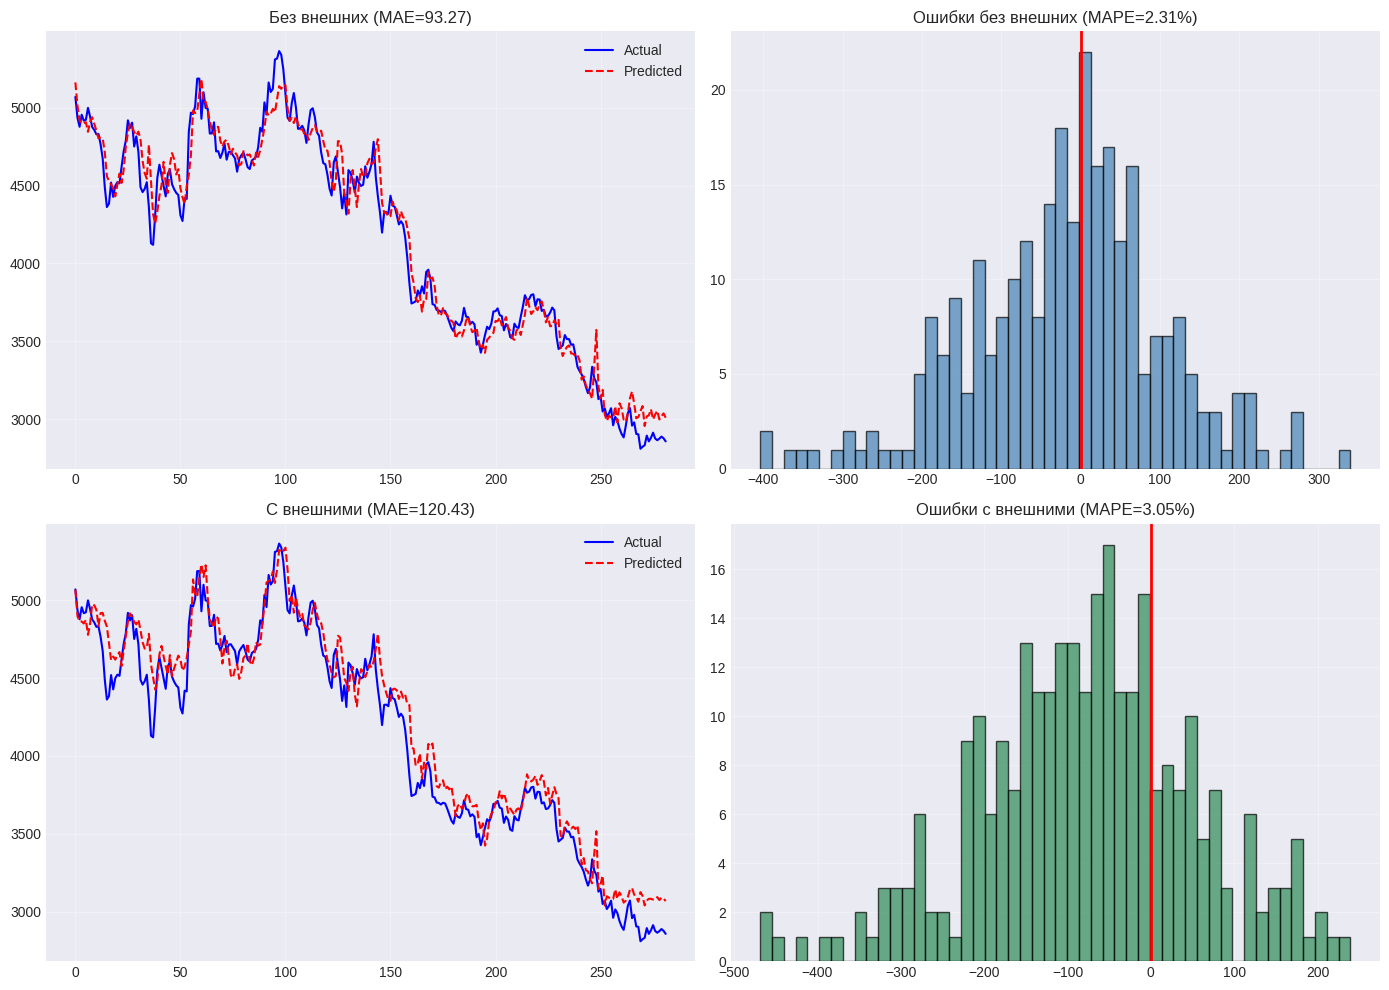


График сохранен: transformer_grid_search.png


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import ParameterGrid
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')

# Загрузка данных
data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата'])

result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

for col_name in result.columns:
    if result[col_name].dtype == 'object' and col_name != 'Дата':
        result = result.drop(columns=[col_name])

def create_features_without_external(data):
    df = data.copy()
    df['Дата_dt'] = pd.to_datetime(df['Дата'])

    df['Open_today'] = df['Открытие']

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['Open_yesterday'] = df['Открытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)

    df['Range_yesterday'] = df['High_yesterday'] - df['Low_yesterday']
    df['Return_yesterday'] = df['Close_yesterday'].pct_change() * 100

    for window in [5, 10, 20]:
        df[f'SMA_{window}_yesterday'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}_yesterday'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()

    def calculate_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / (loss + 1e-10)
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['RSI_14_yesterday'] = calculate_rsi(df['Close_yesterday'], 14)
    df['BB_middle_yesterday'] = df['Close_yesterday'].rolling(20).mean()
    bb_std = df['Close_yesterday'].rolling(20).std()
    df['BB_width_yesterday'] = 2 * bb_std / (df['BB_middle_yesterday'] + 1e-10)
    df['ATR_14_yesterday'] = (df['High_yesterday'] - df['Low_yesterday']).rolling(14).mean()
    df['Volatility_yesterday'] = df['Close_yesterday'].pct_change().rolling(10).std() * np.sqrt(252)
    df['Volume_Ratio_yesterday'] = df['Volume_yesterday'] / (df['Volume_yesterday'].rolling(20).mean() + 1e-10)
    df['Gap_today'] = (df['Открытие'] - df['Close_yesterday']) / (df['Close_yesterday'] + 1e-10) * 100
    df['day_of_week'] = df['Дата_dt'].dt.dayofweek
    df['month'] = df['Дата_dt'].dt.month

    df['Close_today'] = df['Закрытие']

    cols_to_drop = ['Средняя_цена', 'Количество', 'Закрытие', 'Максимум', 'Минимум',
                    'Объем', 'Курс', 'Значение', 'Открытие', 'Дата', 'Дата_dt']

    feature_cols = [c for c in df.columns if c not in cols_to_drop]
    df_clean = df.dropna().reset_index(drop=True)
    return df_clean, feature_cols, 'Close_today'

def create_features_with_external(data):
    df = data.copy()
    df['Дата_dt'] = pd.to_datetime(df['Дата'])

    df['Open_today'] = df['Открытие']


    df['Currency_today'] = df['Курс']

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['Open_yesterday'] = df['Открытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['Currency_yesterday'] = df['Курс'].shift(1)
    df['Oil_yesterday'] = df['Значение'].shift(1)

    df['Range_yesterday'] = df['High_yesterday'] - df['Low_yesterday']
    df['Return_yesterday'] = df['Close_yesterday'].pct_change() * 100

    for window in [5, 10, 20]:
        df[f'SMA_{window}_yesterday'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}_yesterday'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()

    def calculate_rsi(prices, period=14):
        delta = prices.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / (loss + 1e-10)
        rsi = 100 - (100 / (1 + rs))
        return rsi

    df['RSI_14_yesterday'] = calculate_rsi(df['Close_yesterday'], 14)
    df['BB_middle_yesterday'] = df['Close_yesterday'].rolling(20).mean()
    bb_std = df['Close_yesterday'].rolling(20).std()
    df['BB_width_yesterday'] = 2 * bb_std / (df['BB_middle_yesterday'] + 1e-10)
    df['ATR_14_yesterday'] = (df['High_yesterday'] - df['Low_yesterday']).rolling(14).mean()
    df['Volatility_yesterday'] = df['Close_yesterday'].pct_change().rolling(10).std() * np.sqrt(252)
    df['Volume_Ratio_yesterday'] = df['Volume_yesterday'] / (df['Volume_yesterday'].rolling(20).mean() + 1e-10)
    df['Gap_today'] = (df['Открытие'] - df['Close_yesterday']) / (df['Close_yesterday'] + 1e-10) * 100
    df['price_to_rate_today'] = df['Open_today'] / (df['Currency_today'] + 1e-10)
    df['day_of_week'] = df['Дата_dt'].dt.dayofweek
    df['month'] = df['Дата_dt'].dt.month

    df['Close_today'] = df['Закрытие']

    cols_to_drop = ['Средняя_цена', 'Количество', 'Закрытие', 'Максимум', 'Минимум',
                    'Объем', 'Курс', 'Значение', 'Открытие', 'Дата', 'Дата_dt']

    feature_cols = [c for c in df.columns if c not in cols_to_drop]
    df_clean = df.dropna().reset_index(drop=True)
    return df_clean, feature_cols, 'Close_today'

class StockDatasetFixed(Dataset):
    def __init__(self, features, target, sequence_length=10):
        self.features = features.astype(np.float32)
        self.target = target.astype(np.float32)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.features) - self.sequence_length

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.sequence_length]
        y = self.target[idx + self.sequence_length]
        return torch.FloatTensor(x), torch.FloatTensor([y])

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class TimeSeriesTransformer(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super().__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_layers = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(32, 16), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.input_projection(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        x = self.output_layers(x)
        return x

def prepare_data(data_features, feature_cols, target_col):
    train_size = int(len(data_features) * 0.7)
    val_size = int(len(data_features) * 0.15)
    sequence_length = 10
    gap = sequence_length + 5

    train_data = data_features.iloc[:train_size - gap].copy()
    val_data = data_features.iloc[train_size:train_size + val_size - gap].copy()
    test_data = data_features.iloc[train_size + val_size:].copy()

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    train_features = train_data[feature_cols].values
    train_target = train_data[[target_col]].values

    train_features_scaled = feature_scaler.fit_transform(train_features)
    train_target_scaled = target_scaler.fit_transform(train_target).flatten()

    val_features_scaled = feature_scaler.transform(val_data[feature_cols].values)
    val_target_scaled = target_scaler.transform(val_data[[target_col]].values).flatten()

    test_features_scaled = feature_scaler.transform(test_data[feature_cols].values)
    test_target_scaled = target_scaler.transform(test_data[[target_col]].values).flatten()

    train_dataset = StockDatasetFixed(train_features_scaled, train_target_scaled, sequence_length)
    val_dataset = StockDatasetFixed(val_features_scaled, val_target_scaled, sequence_length)
    test_dataset = StockDatasetFixed(test_features_scaled, test_target_scaled, sequence_length)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    return train_loader, val_loader, test_loader, target_scaler

def train_model_fast(model, train_loader, val_loader, epochs=15, lr=0.001, wd=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    patience = 5
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()
        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return best_val_loss

def train_final_model(model, train_loader, val_loader, test_loader, target_scaler, lr=0.001, wd=0.01, epochs=100):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val_loss = float('inf')
    best_model_state = None
    patience = 15
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"    Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_model_state)

    model.eval()
    predictions = []
    actuals = []
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            predictions.extend(outputs.cpu().numpy().flatten())
            actuals.extend(batch_y.numpy().flatten())

    predictions = target_scaler.inverse_transform(np.array(predictions).reshape(-1, 1)).flatten()
    actuals = target_scaler.inverse_transform(np.array(actuals).reshape(-1, 1)).flatten()

    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    r2 = 1 - np.sum((actuals - predictions)**2) / np.sum((actuals - np.mean(actuals))**2)

    return mae, rmse, mape, r2, predictions, actuals

def grid_search_transformer(train_loader, val_loader, input_dim, param_grid):
    best_loss = float('inf')
    best_params = None

    total = len(list(ParameterGrid(param_grid)))
    current = 0

    for params in ParameterGrid(param_grid):
        current += 1
        print(f"    Комбинация {current}/{total}: {params}")

        if params['d_model'] % params['nhead'] != 0:
            print(f"      Пропуск (d_model={params['d_model']} не делится на nhead={params['nhead']})")
            continue

        model = TimeSeriesTransformer(
            input_dim=input_dim,
            d_model=params['d_model'],
            nhead=params['nhead'],
            num_layers=params['num_layers'],
            dropout=params['dropout']
        )

        loss = train_model_fast(model, train_loader, val_loader,
                                epochs=15, lr=params['lr'], wd=params['weight_decay'])

        print(f"      Val Loss: {loss:.6f}")

        if loss < best_loss:
            best_loss = loss
            best_params = params.copy()
            print(f"      -> НОВЫЙ ЛУЧШИЙ!")

    return best_params, best_loss

# Параметры для Grid Search
param_grid = {
    'd_model': [48, 64],
    'nhead': [2, 4],
    'num_layers': [1, 2],
    'dropout': [0.2, 0.3],
    'lr': [0.001, 0.002],
    'weight_decay': [0.01, 0.02]
}

results = {}

# ============================================
# МОДЕЛЬ БЕЗ ВНЕШНИХ ФАКТОРОВ
# ============================================
print("="*70)
print("МОДЕЛЬ БЕЗ ВНЕШНИХ ФАКТОРОВ")
print("="*70)

data_wo, feature_cols_wo, target_wo = create_features_without_external(result)
print(f"Признаков: {len(feature_cols_wo)}")

train_loader_wo, val_loader_wo, test_loader_wo, target_scaler_wo = prepare_data(data_wo, feature_cols_wo, target_wo)

print("\nПОИСК ПО СЕТКЕ (Grid Search)")
best_params_wo, best_loss_wo = grid_search_transformer(train_loader_wo, val_loader_wo, len(feature_cols_wo), param_grid)

print(f"\nЛучшие параметры: {best_params_wo}")
print(f"Лучший loss: {best_loss_wo:.6f}")

print("\nФИНАЛЬНОЕ ОБУЧЕНИЕ")
final_model_wo = TimeSeriesTransformer(
    input_dim=len(feature_cols_wo),
    d_model=best_params_wo['d_model'],
    nhead=best_params_wo['nhead'],
    num_layers=best_params_wo['num_layers'],
    dropout=best_params_wo['dropout']
)

mae_wo, rmse_wo, mape_wo, r2_wo, pred_wo, act_wo = train_final_model(
    final_model_wo, train_loader_wo, val_loader_wo, test_loader_wo, target_scaler_wo,
    lr=best_params_wo['lr'], wd=best_params_wo['weight_decay']
)

results['without'] = {'mae': mae_wo, 'rmse': rmse_wo, 'mape': mape_wo, 'r2': r2_wo, 'pred': pred_wo, 'act': act_wo, 'params': best_params_wo}

# ============================================
# МОДЕЛЬ С ВНЕШНИМИ ФАКТОРАМИ (с Oil_today и Currency_today)
# ============================================
print("\n" + "="*70)
print("МОДЕЛЬ С ВНЕШНИМИ ФАКТОРАМИ (Oil_today, Currency_today)")
print("="*70)

data_w, feature_cols_w, target_w = create_features_with_external(result)
print(f"Признаков: {len(feature_cols_w)}")

train_loader_w, val_loader_w, test_loader_w, target_scaler_w = prepare_data(data_w, feature_cols_w, target_w)

print("\nПОИСК ПО СЕТКЕ (Grid Search)")
best_params_w, best_loss_w = grid_search_transformer(train_loader_w, val_loader_w, len(feature_cols_w), param_grid)

print(f"\nЛучшие параметры: {best_params_w}")
print(f"Лучший loss: {best_loss_w:.6f}")

print("\nФИНАЛЬНОЕ ОБУЧЕНИЕ")
final_model_w = TimeSeriesTransformer(
    input_dim=len(feature_cols_w),
    d_model=best_params_w['d_model'],
    nhead=best_params_w['nhead'],
    num_layers=best_params_w['num_layers'],
    dropout=best_params_w['dropout']
)

mae_w, rmse_w, mape_w, r2_w, pred_w, act_w = train_final_model(
    final_model_w, train_loader_w, val_loader_w, test_loader_w, target_scaler_w,
    lr=best_params_w['lr'], wd=best_params_w['weight_decay']
)

results['with'] = {'mae': mae_w, 'rmse': rmse_w, 'mape': mape_w, 'r2': r2_w, 'pred': pred_w, 'act': act_w, 'params': best_params_w}

# ============================================
# СРАВНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================
print("\n" + "="*70)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*70)
print(f"{'Модель':<20} {'MAE':>10} {'RMSE':>10} {'MAPE(%)':>10} {'R²':>10}")
print("-"*60)
print(f"{'Без внешних':<20} {results['without']['mae']:>10.2f} {results['without']['rmse']:>10.2f} {results['without']['mape']:>10.2f} {results['without']['r2']:>10.4f}")
print(f"{'С внешними':<20} {results['with']['mae']:>10.2f} {results['with']['rmse']:>10.2f} {results['with']['mape']:>10.2f} {results['with']['r2']:>10.4f}")

print("\nЛУЧШИЕ ПАРАМЕТРЫ:")
print(f"Без внешних: {results['without']['params']}")
print(f"С внешними:  {results['with']['params']}")

# Графики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(results['without']['act'], label='Actual', color='blue', linewidth=1.5)
axes[0, 0].plot(results['without']['pred'], label='Predicted', color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title(f"Без внешних (MAE={results['without']['mae']:.2f})")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

errors_wo = results['without']['act'] - results['without']['pred']
axes[0, 1].hist(errors_wo, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='-', linewidth=2)
axes[0, 1].set_title(f"Ошибки без внешних (MAPE={results['without']['mape']:.2f}%)")
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(results['with']['act'], label='Actual', color='blue', linewidth=1.5)
axes[1, 0].plot(results['with']['pred'], label='Predicted', color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title(f"С внешними (MAE={results['with']['mae']:.2f})")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

errors_w = results['with']['act'] - results['with']['pred']
axes[1, 1].hist(errors_w, bins=50, alpha=0.7, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='-', linewidth=2)
axes[1, 1].set_title(f"Ошибки с внешними (MAPE={results['with']['mape']:.2f}%)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_grid_search.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: transformer_grid_search.png")

График сохранен как:
  - transformer_grid_search.png
  - /content/transformer_grid_search.png
  ✓ Файл существует, размер: 247718 байт


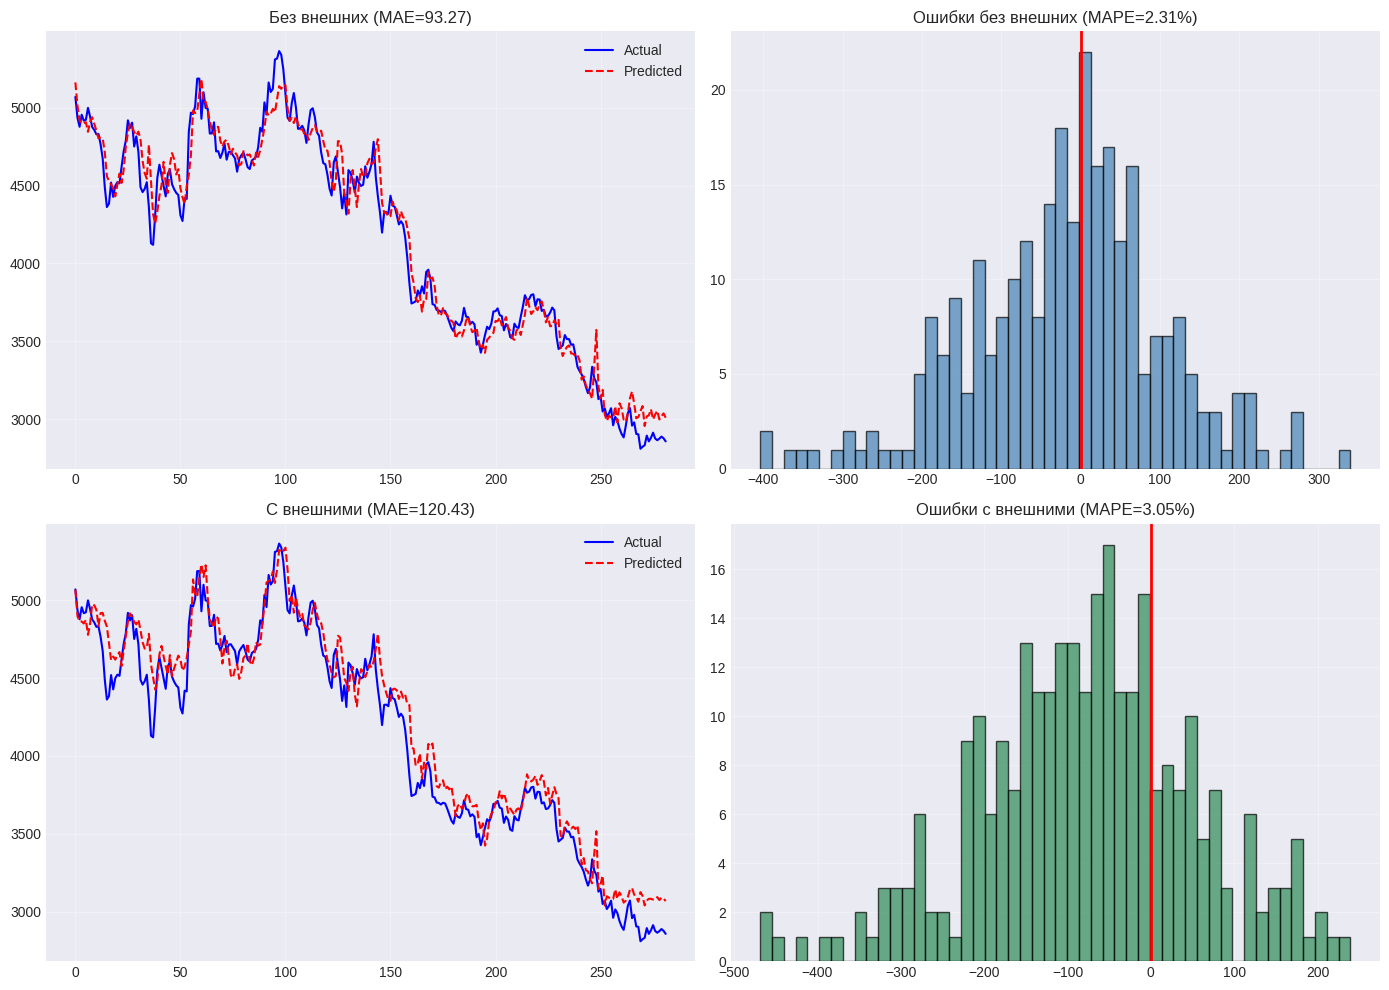

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл скачан через google.colab.files.download()


In [ ]:
# Сохранение графика отдельно
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Без внешних - предсказания
axes[0, 0].plot(results['without']['act'], label='Actual', color='blue', linewidth=1.5)
axes[0, 0].plot(results['without']['pred'], label='Predicted', color='red', linestyle='--', linewidth=1.5)
axes[0, 0].set_title(f"Без внешних (MAE={results['without']['mae']:.2f})")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График 2: Без внешних - ошибки
errors_wo = results['without']['act'] - results['without']['pred']
axes[0, 1].hist(errors_wo, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='-', linewidth=2)
axes[0, 1].set_title(f"Ошибки без внешних (MAPE={results['without']['mape']:.2f}%)")
axes[0, 1].grid(True, alpha=0.3)

# График 3: С внешними - предсказания
axes[1, 0].plot(results['with']['act'], label='Actual', color='blue', linewidth=1.5)
axes[1, 0].plot(results['with']['pred'], label='Predicted', color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_title(f"С внешними (MAE={results['with']['mae']:.2f})")
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: С внешними - ошибки
errors_w = results['with']['act'] - results['with']['pred']
axes[1, 1].hist(errors_w, bins=50, alpha=0.7, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='-', linewidth=2)
axes[1, 1].set_title(f"Ошибки с внешними (MAPE={results['with']['mape']:.2f}%)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()

# Сохраняем в нескольких местах
plt.savefig('transformer_grid_search.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/transformer_grid_search.png', dpi=150, bbox_inches='tight')
plt.savefig('./transformer_grid_search.png', dpi=150, bbox_inches='tight')

print("График сохранен как:")
print("  - transformer_grid_search.png")
print("  - /content/transformer_grid_search.png")

# Проверка существования файла
import os
if os.path.exists('transformer_grid_search.png'):
    print(f"  ✓ Файл существует, размер: {os.path.getsize('transformer_grid_search.png')} байт")
else:
    print("  ✗ Файл не найден в текущей директории")

plt.show()

# Для Google Colab - автоматическое скачивание
try:
    from google.colab import files
    files.download('transformer_grid_search.png')
    print("Файл скачан через google.colab.files.download()")
except:
    print("Не в Colab или ошибка скачивания")

In [ ]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

def analyze_residuals(residuals, model_name="Model"):
    residuals = np.array(residuals).flatten()
    n = len(residuals)

    print(f"\nАнализ остатков: {model_name}")
    print(f"Количество наблюдений: {n}")
    print(f"Средняя ошибка (ME): {np.mean(residuals):.4f}")
    print(f"Стандартное отклонение: {np.std(residuals):.4f}")
    print(f"Дисперсия: {np.var(residuals):.4f}")
    print(f"Медиана: {np.median(residuals):.4f}")
    print(f"Асимметрия (Skewness): {stats.skew(residuals):.4f}")
    print(f"Эксцесс (Kurtosis): {stats.kurtosis(residuals):.4f}")

    if n > 5000:
        sample = np.random.choice(residuals, 5000, replace=False)
        shapiro_stat, shapiro_p = stats.shapiro(sample)
    else:
        shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"Тест Шапиро-Уилка: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

    ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))
    print(f"Тест Колмогорова-Смирнова: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")

    lb_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_stat = lb_result['lb_stat'].values[0]
    lb_p = lb_result['lb_pvalue'].values[0]
    print(f"Тест Льюнга-Бокса (белый шум): statistic={lb_stat:.4f}, p-value={lb_p:.4f}")

    diff = np.diff(residuals)
    dw_stat = np.sum(diff**2) / np.sum(residuals**2)
    print(f"Тест Дарбина-Ватсона: statistic={dw_stat:.4f}")

    print()
    if shapiro_p < 0.05:
        print("Распределение ошибок НЕ нормальное (p < 0.05)")
    else:
        print("Распределение ошибок нормальное (p >= 0.05)")

    if lb_p < 0.05:
        print("Ошибки НЕ являются белым шумом (есть автокорреляция)")
    else:
        print("Ошибки являются белым шумом (нет автокорреляции)")

    return {'shapiro_p': shapiro_p, 'lb_p': lb_p, 'dw_stat': dw_stat}

def compare_models_stats(errors_wo, errors_w, name1="Без внешних", name2="С внешними"):
    print("\n" + "="*70)
    print(f"СРАВНЕНИЕ МОДЕЛЕЙ: {name1} vs {name2}")
    print("="*70)

    mae_wo = np.mean(np.abs(errors_wo))
    mae_w = np.mean(np.abs(errors_w))

    print(f"\nMAE {name1}: {mae_wo:.2f}")
    print(f"MAE {name2}: {mae_w:.2f}")
    print(f"Разница: {mae_w - mae_wo:.2f} ({(mae_w/mae_wo - 1)*100:+.1f}%)")

    # Тест Уилкоксона
    stat, p = stats.wilcoxon(np.abs(errors_wo), np.abs(errors_w))
    print(f"\nТест Уилкоксона (абсолютные ошибки):")
    print(f"  statistic = {stat:.4f}")
    print(f"  p-value = {p:.6f}")

    if p < 0.05:
        if mae_wo < mae_w:
            print(f"  {name1} ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
        else:
            print(f"  {name2} ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
    else:
        print("  Различие НЕ значимо (p >= 0.05)")

    # Тест знаков
    diff_abs = np.abs(errors_wo) - np.abs(errors_w)
    n_better_wo = np.sum(diff_abs < 0)
    n_better_w = np.sum(diff_abs > 0)

    if n_better_wo + n_better_w > 0:
        sign_result = stats.binomtest(n_better_wo, n_better_wo + n_better_w, p=0.5)
        sign_p = sign_result.pvalue
    else:
        sign_p = 1.0

    print(f"\nТест знаков:")
    print(f"  {name1} лучше в {n_better_wo} точках")
    print(f"  {name2} лучше в {n_better_w} точках")
    print(f"  p-value = {sign_p:.6f}")

    if sign_p < 0.05:
        if n_better_wo > n_better_w:
            print(f"  {name1} значимо чаще лучше")
        else:
            print(f"  {name2} значимо чаще лучше")
    else:
        print("  Различие по знакам не значимо")

    return p

print("\n" + "="*70)
print("АНАЛИЗ ОСТАТКОВ ВСЕХ МОДЕЛЕЙ")
print("="*70)

errors_lstm_wo = results['without']['act'] - results['without']['pred']
errors_lstm_w = results['with']['act'] - results['with']['pred']

analyze_residuals(errors_lstm_wo, "БЕЗ внешних факторов")
analyze_residuals(errors_lstm_w, "С внешними факторами")

compare_models_stats(errors_lstm_wo, errors_lstm_w, "Без внешних", "С внешними")


АНАЛИЗ ОСТАТКОВ ВСЕХ МОДЕЛЕЙ

Анализ остатков: БЕЗ внешних факторов
Количество наблюдений: 282
Средняя ошибка (ME): -17.9326
Стандартное отклонение: 122.1681
Дисперсия: 14925.0479
Медиана: -5.6633
Асимметрия (Skewness): -0.2503
Эксцесс (Kurtosis): 0.5870
Тест Шапиро-Уилка: statistic=0.9893, p-value=0.0354
Тест Колмогорова-Смирнова: statistic=0.0544, p-value=0.3609
Тест Льюнга-Бокса (белый шум): statistic=125.2861, p-value=0.0000
Тест Дарбина-Ватсона: statistic=0.8659

Распределение ошибок НЕ нормальное (p < 0.05)
Ошибки НЕ являются белым шумом (есть автокорреляция)

Анализ остатков: С внешними факторами
Количество наблюдений: 282
Средняя ошибка (ME): -78.8599
Стандартное отклонение: 130.2469
Дисперсия: 16964.2637
Медиана: -73.8596
Асимметрия (Skewness): -0.1975
Эксцесс (Kurtosis): 0.2055
Тест Шапиро-Уилка: statistic=0.9927, p-value=0.1843
Тест Колмогорова-Смирнова: statistic=0.0358, p-value=0.8506
Тест Льюнга-Бокса (белый шум): statistic=171.2678, p-value=0.0000
Тест Дарбина-Ватсона: 

np.float64(8.538275888778304e-08)

arima


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')


data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')

result = result.dropna().reset_index(drop=True)

lukoil = pd.read_csv('lukoil_moex.csv', encoding='utf-8', sep=',')

price_col_lukoil = None
for col in ['Закрытие', 'Close', 'close', 'Цена', 'Price']:
    if col in lukoil.columns:
        price_col_lukoil = col
        break

if price_col_lukoil is None:
    raise ValueError(f"Не найдена колонка с ценой. Доступны: {lukoil.columns.tolist()}")

lukoil['Дата'] = pd.to_datetime(lukoil['Дата'])
lukoil = lukoil.sort_values(by='Дата').reset_index(drop=True)

def train_evaluate_arima_one_day(train, test, order):
    try:
        history = list(train)
        predictions = []

        for t in range(len(test)):
            model = ARIMA(history, order=order)
            fitted = model.fit()
            y_pred = fitted.forecast(1)[0]
            predictions.append(y_pred)
            history.append(test[t])

        predictions = np.array(predictions)

        mae = mean_absolute_error(test, predictions)
        rmse = np.sqrt(mean_squared_error(test, predictions))
        mape = np.mean(np.abs((test - predictions) / test)) * 100

        baseline = np.mean(train)
        ss_res = np.sum((test - predictions) ** 2)
        ss_tot = np.sum((test - baseline) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

        return mae, rmse, mape, r2
    except Exception as e:
        return None, None, None, None

def auto_arima_search(ts, verbose=False):
    model = auto_arima(
        ts,
        start_p=0, start_q=0,
        max_p=5, max_q=5,
        seasonal=False,
        stepwise=True,
        trace=False,
        error_action='ignore',
        suppress_warnings=True,
        random_state=42,
        n_fits=30
    )
    return model.order

ts_magnit = result['Закрытие'].values

train_size = int(len(ts_magnit) * 0.8)
train_y_magnit = ts_magnit[:train_size]
test_y_magnit = ts_magnit[train_size:]

params_arima = auto_arima_search(train_y_magnit)

mae_magnit, rmse_magnit, mape_magnit, r2_magnit = train_evaluate_arima_one_day(
    train_y_magnit, test_y_magnit, params_arima
)

ts_lukoil = lukoil[price_col_lukoil].values

train_size_lukoil = int(len(ts_lukoil) * 0.8)
train_y_lukoil = ts_lukoil[:train_size_lukoil]
test_y_lukoil = ts_lukoil[train_size_lukoil:]

mae_lukoil, rmse_lukoil, mape_lukoil, r2_lukoil = train_evaluate_arima_one_day(
    train_y_lukoil, test_y_lukoil, params_arima
)

print(f"\nМАГНИТ (ARIMA{params_arima}):")
print(f"MAE: {mae_magnit:.2f}")
print(f"RMSE: {rmse_magnit:.2f}")
print(f"MAPE: {mape_magnit:.2f}%")
print(f"R2: {r2_magnit:.4f}")

print(f"\nЛУКОЙЛ (та же модель ARIMA{params_arima}):")
print(f"MAE: {mae_lukoil:.2f}")
print(f"RMSE: {rmse_lukoil:.2f}")
print(f"MAPE: {mape_lukoil:.2f}%")
print(f"R2: {r2_lukoil:.4f}")


МАГНИТ (ARIMA(2, 1, 0)):
MAE: 75.94
RMSE: 109.92
MAPE: 1.60%
R2: 0.9923

ЛУКОЙЛ (та же модель ARIMA(2, 1, 0)):
MAE: 37.30
RMSE: 50.09
MAPE: 1.31%
R2: 0.9747


LSTM BiLSTM


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import gp_minimize
from skopt.space import Integer, Real, Categorical
from skopt.utils import use_named_args
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def create_features_without_external(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Open_today'].shift(1) + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5).std()
    feature_columns.append('volatility')

    df['Close_today'] = df['Закрытие']

    df_clean = df[feature_columns + ['Close_today']].dropna().reset_index(drop=True)
    return df_clean, feature_columns

def create_features_with_external(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    df['Currency_yesterday'] = df['Курс'].shift(1)
    df['Oil_yesterday'] = df['Значение'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday',
                            'Currency_yesterday', 'Oil_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    df['currency_pct_change'] = df['Currency_yesterday'].pct_change() * 100
    df['oil_pct_change'] = df['Oil_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change',
                            'currency_pct_change', 'oil_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Open_today'].shift(1) + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['close_currency_ratio'] = df['Close_yesterday'] / (df['Currency_yesterday'] + 1e-10)
    df['close_oil_ratio'] = df['Close_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    df['currency_oil_ratio'] = df['Currency_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    feature_columns.extend(['close_currency_ratio', 'close_oil_ratio', 'currency_oil_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5).std()
    df['currency_volatility'] = df['Currency_yesterday'].rolling(5).std()
    df['oil_volatility'] = df['Oil_yesterday'].rolling(5).std()
    feature_columns.extend(['volatility', 'currency_volatility', 'oil_volatility'])

    df['Close_today'] = df['Закрытие']

    df_clean = df[feature_columns + ['Close_today']].dropna().reset_index(drop=True)
    return df_clean, feature_columns

class StockDataset(Dataset):
    def __init__(self, features, target, sequence_length=10):
        self.features = features.astype(np.float32)
        self.target = target.astype(np.float32)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.features) - self.sequence_length

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.sequence_length]
        y = self.target[idx + self.sequence_length]
        return torch.FloatTensor(x), torch.FloatTensor([y])

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out[:, -1, :])
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class BiLSTMModelImproved(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3, pooling='mean'):
        super(BiLSTMModelImproved, self).__init__()
        self.pooling = pooling
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        if self.pooling == 'mean':
            x = torch.mean(lstm_out, dim=1)
        elif self.pooling == 'max':
            x = torch.max(lstm_out, dim=1)[0]
        else:
            x = lstm_out[:, -1, :]

        x = self.layer_norm(x)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

def train_model_fast_lstm(model, train_loader, val_loader, epochs=25, lr=0.001, wd=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    patience = 5
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()

        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return best_val_loss

def train_model_fast_bilstm(model, train_loader, val_loader, epochs=25, lr=0.0005, wd=0.05):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    patience = 4
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()

        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return best_val_loss

def train_model_final_lstm(model, train_loader, test_loader, epochs=80, lr=0.001, wd=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    best_loss = float('inf')
    best_model_state = None
    patience = 8
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                test_loss += criterion(outputs, batch_y).item()

        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        scheduler.step(test_loss)

        if test_loss < best_loss:
            best_loss = test_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_model_state)
    return model

def train_model_final_bilstm(model, train_loader, test_loader, epochs=80, lr=0.0005, wd=0.05):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    best_loss = float('inf')
    best_model_state = None
    patience = 6
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                test_loss += criterion(outputs, batch_y).item()

        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        scheduler.step(test_loss)

        if test_loss < best_loss:
            best_loss = test_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_model_state)
    return model

def predict(model, data_loader, target_scaler):
    device = next(model.parameters()).device
    model.eval()
    predictions, actuals = [], []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(batch_y.numpy())

    predictions = np.array(predictions).flatten()
    actuals = np.array(actuals).flatten()
    predictions_original = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    actuals_original = target_scaler.inverse_transform(actuals.reshape(-1, 1)).flatten()
    return predictions_original, actuals_original

def evaluate_model(model, test_loader, target_scaler):
    predictions, actuals = predict(model, test_loader, target_scaler)
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    r2 = r2_score(actuals, predictions)
    return mae, rmse, mape, r2, predictions, actuals

def run_bayesian_optimization(data_features, feature_cols, name, n_calls=25, n_random_starts=10):
    print(f"\nБайесовская оптимизация для {name}")

    train_size = int(len(data_features) * 0.7)
    val_size = int(len(data_features) * 0.15)
    train_data = data_features.iloc[:train_size].copy()
    val_data = data_features.iloc[train_size:train_size+val_size].copy()
    test_data = data_features.iloc[train_size+val_size:].copy()

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    train_features = train_data[feature_cols].values
    train_target = train_data[['Close_today']].values

    train_features_scaled = feature_scaler.fit_transform(train_features)
    train_target_scaled = target_scaler.fit_transform(train_target).flatten()

    val_features_scaled = feature_scaler.transform(val_data[feature_cols].values)
    val_target_scaled = target_scaler.transform(val_data[['Close_today']].values).flatten()

    test_features_scaled = feature_scaler.transform(test_data[feature_cols].values)
    test_target_scaled = target_scaler.transform(test_data[['Close_today']].values).flatten()

    sequence_length = 10
    train_dataset = StockDataset(train_features_scaled, train_target_scaled, sequence_length)
    val_dataset = StockDataset(val_features_scaled, val_target_scaled, sequence_length)
    test_dataset = StockDataset(test_features_scaled, test_target_scaled, sequence_length)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    space_lstm = [
        Integer(32, 128, name='hidden_dim'),
        Integer(1, 3, name='num_layers'),
        Real(0.1, 0.4, name='dropout'),
        Real(0.0005, 0.003, name='lr'),
        Real(0.0005, 0.02, name='weight_decay')
    ]

    space_bilstm = [
        Integer(32, 96, name='hidden_dim'),
        Integer(1, 2, name='num_layers'),
        Real(0.3, 0.5, name='dropout'),
        Real(0.0003, 0.002, name='lr'),
        Real(0.01, 0.1, name='weight_decay'),
        Categorical(['mean', 'max'], name='pooling')
    ]

    @use_named_args(space_lstm)
    def objective_lstm(hidden_dim, num_layers, dropout, lr, weight_decay):
        model = LSTMModel(
            input_dim=len(feature_cols),
            hidden_dim=int(hidden_dim),
            num_layers=int(num_layers),
            dropout=float(dropout)
        )
        loss = train_model_fast_lstm(
            model, train_loader, val_loader,
            epochs=25, lr=float(lr), wd=float(weight_decay)
        )
        return loss

    @use_named_args(space_bilstm)
    def objective_bilstm(hidden_dim, num_layers, dropout, lr, weight_decay, pooling):
        model = BiLSTMModelImproved(
            input_dim=len(feature_cols),
            hidden_dim=int(hidden_dim),
            num_layers=int(num_layers),
            dropout=float(dropout),
            pooling=str(pooling)
        )
        loss = train_model_fast_bilstm(
            model, train_loader, val_loader,
            epochs=25, lr=float(lr), wd=float(weight_decay)
        )
        return loss

    print("  Оптимизация LSTM...")
    result_lstm = gp_minimize(
        objective_lstm, space_lstm,
        n_calls=n_calls,
        n_random_starts=n_random_starts,
        verbose=True,
        random_state=42,
        acq_func="EI",
        n_jobs=1
    )

    print("\n  Оптимизация BiLSTM...")
    result_bilstm = gp_minimize(
        objective_bilstm, space_bilstm,
        n_calls=n_calls,
        n_random_starts=n_random_starts,
        verbose=True,
        random_state=42,
        acq_func="EI",
        n_jobs=1
    )

    best_lstm_params = {
        'hidden_dim': int(result_lstm.x[0]),
        'num_layers': int(result_lstm.x[1]),
        'dropout': float(result_lstm.x[2]),
        'lr': float(result_lstm.x[3]),
        'weight_decay': float(result_lstm.x[4])
    }

    best_bilstm_params = {
        'hidden_dim': int(result_bilstm.x[0]),
        'num_layers': int(result_bilstm.x[1]),
        'dropout': float(result_bilstm.x[2]),
        'lr': float(result_bilstm.x[3]),
        'weight_decay': float(result_bilstm.x[4]),
        'pooling': str(result_bilstm.x[5])
    }

    print(f"\nЛучшие параметры LSTM: {best_lstm_params}")
    print(f"Лучшие параметры BiLSTM: {best_bilstm_params}")
    print(f"Лучший loss LSTM: {result_lstm.fun:.6f}")
    print(f"Лучший loss BiLSTM: {result_bilstm.fun:.6f}")

    print("\nФинальное обучение...")

    final_lstm = LSTMModel(
        len(feature_cols),
        best_lstm_params['hidden_dim'],
        best_lstm_params['num_layers'],
        best_lstm_params['dropout']
    )
    final_lstm = train_model_final_lstm(
        final_lstm, train_loader, test_loader, 80,
        best_lstm_params['lr'], best_lstm_params['weight_decay']
    )
    lstm_mae, lstm_rmse, lstm_mape, lstm_r2, lstm_pred, lstm_act = evaluate_model(
        final_lstm, test_loader, target_scaler
    )

    final_bilstm = BiLSTMModelImproved(
        len(feature_cols),
        best_bilstm_params['hidden_dim'],
        best_bilstm_params['num_layers'],
        best_bilstm_params['dropout'],
        best_bilstm_params['pooling']
    )
    final_bilstm = train_model_final_bilstm(
        final_bilstm, train_loader, test_loader, 80,
        best_bilstm_params['lr'], best_bilstm_params['weight_decay']
    )
    bilstm_mae, bilstm_rmse, bilstm_mape, bilstm_r2, bilstm_pred, bilstm_act = evaluate_model(
        final_bilstm, test_loader, target_scaler
    )

    print(f"\nРезультаты для {name}:")
    print(f"LSTM: MAE={lstm_mae:.2f}, RMSE={lstm_rmse:.2f}, MAPE={lstm_mape:.2f}%, R2={lstm_r2:.4f}")
    print(f"BiLSTM: MAE={bilstm_mae:.2f}, RMSE={bilstm_rmse:.2f}, MAPE={bilstm_mape:.2f}%, R2={bilstm_r2:.4f}")

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(result_lstm.func_vals, 'b-', alpha=0.7)
    plt.axhline(y=result_lstm.fun, color='r', linestyle='--', label=f'Best: {result_lstm.fun:.6f}')
    plt.xlabel('Итерация')
    plt.ylabel('Loss')
    plt.title('Байесовская оптимизация LSTM')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(result_bilstm.func_vals, 'g-', alpha=0.7)
    plt.axhline(y=result_bilstm.fun, color='r', linestyle='--', label=f'Best: {result_bilstm.fun:.6f}')
    plt.xlabel('Итерация')
    plt.ylabel('Loss')
    plt.title('Байесовская оптимизация BiLSTM')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        'lstm_mae': lstm_mae, 'bilstm_mae': bilstm_mae,
        'lstm_rmse': lstm_rmse, 'bilstm_rmse': bilstm_rmse,
        'lstm_mape': lstm_mape, 'bilstm_mape': bilstm_mape,
        'lstm_r2': lstm_r2, 'bilstm_r2': bilstm_r2,
        'lstm_pred': lstm_pred, 'lstm_act': lstm_act,
        'bilstm_pred': bilstm_pred, 'bilstm_act': bilstm_act,
        'lstm_best_loss': result_lstm.fun,
        'bilstm_best_loss': result_bilstm.fun
    }

data_without, cols_without = create_features_without_external(result)
data_with, cols_with = create_features_with_external(result)

print("\n" + "="*80)
print("БАЙЕСОВСКАЯ ОПТИМИЗАЦИЯ")
print("="*80)

print("\nМодель без внешних факторов")
results_without = run_bayesian_optimization(data_without, cols_without, "БЕЗ ВНЕШНИХ", n_calls=25)

print("\nМодель с внешними факторами")
results_with = run_bayesian_optimization(data_with, cols_with, "С ВНЕШНИМИ", n_calls=25)

print("\n" + "="*80)
print("ИТОГОВОЕ СРАВНЕНИЕ")
print("="*80)
print(f"{'Метрика':<20} {'Без внешних LSTM':>18} {'С внешними LSTM':>18} {'Без внешних BiLSTM':>20} {'С внешними BiLSTM':>20}")
print("-"*100)
print(f"{'MAE':<20} {results_without['lstm_mae']:>18.2f} {results_with['lstm_mae']:>18.2f} {results_without['bilstm_mae']:>20.2f} {results_with['bilstm_mae']:>20.2f}")
print(f"{'RMSE':<20} {results_without['lstm_rmse']:>18.2f} {results_with['lstm_rmse']:>18.2f} {results_without['bilstm_rmse']:>20.2f} {results_with['bilstm_rmse']:>20.2f}")
print(f"{'MAPE (%)':<20} {results_without['lstm_mape']:>18.2f} {results_with['lstm_mape']:>18.2f} {results_without['bilstm_mape']:>20.2f} {results_with['bilstm_mape']:>20.2f}")
print(f"{'R2':<20} {results_without['lstm_r2']:>18.4f} {results_with['lstm_r2']:>18.4f} {results_without['bilstm_r2']:>20.4f} {results_with['bilstm_r2']:>20.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (title, results_data) in enumerate([('Без внешних факторов', results_without),
                                              ('С внешними факторами', results_with)]):

    ax1 = axes[idx, 0]
    errors_lstm = results_data['lstm_act'] - results_data['lstm_pred']
    ax1.hist(errors_lstm, bins=30, alpha=0.7, color='blue', edgecolor='black')
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax1.set_xlabel('Ошибка прогноза', fontsize=12)
    ax1.set_ylabel('Частота', fontsize=12)
    ax1.set_title(f'LSTM: Распределение ошибок ({title})', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2 = axes[idx, 1]
    ax2.plot(results_data['lstm_act'][:100], label='Фактическая цена', linewidth=2, alpha=0.8)
    ax2.plot(results_data['lstm_pred'][:100], label='LSTM', linewidth=2, alpha=0.8)
    ax2.plot(results_data['bilstm_pred'][:100], label='BiLSTM', linewidth=2, alpha=0.8)
    ax2.set_xlabel('Временной индекс', fontsize=12)
    ax2.set_ylabel('Цена закрытия', fontsize=12)
    ax2.set_title(f'Фактическая vs Предсказанная цена ({title})', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



БАЙЕСОВСКАЯ ОПТИМИЗАЦИЯ

Модель без внешних факторов

Байесовская оптимизация для БЕЗ ВНЕШНИХ
  Оптимизация LSTM...
Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 14.8713
Function value obtained: 0.1945
Current minimum: 0.1945
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 24.6260
Function value obtained: 0.5950
Current minimum: 0.1945
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 18.2475
Function value obtained: 0.9441
Current minimum: 0.1945
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 18.5010
Function value obtained: 0.4786
Current minimum: 0.1945
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at ran

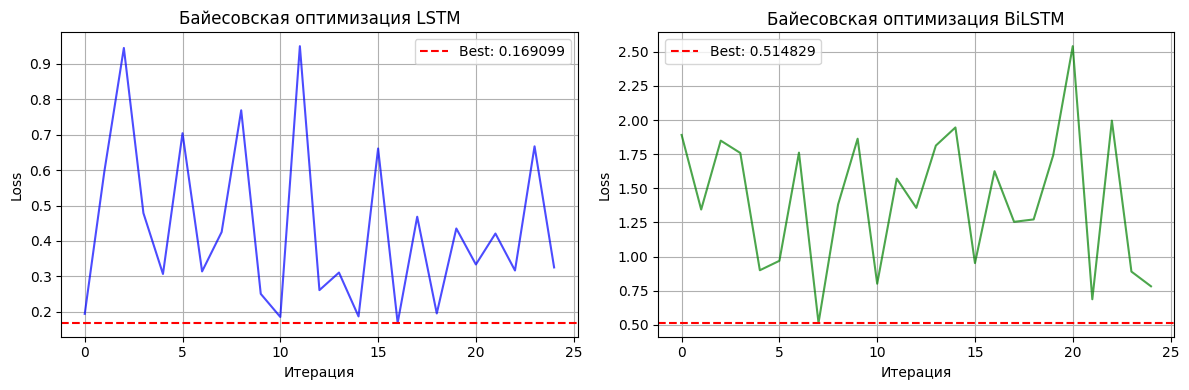


Модель с внешними факторами

Байесовская оптимизация для С ВНЕШНИМИ
  Оптимизация LSTM...
Iteration No: 1 started. Evaluating function at random point.
Iteration No: 1 ended. Evaluation done at random point.
Time taken: 10.8363
Function value obtained: 0.2393
Current minimum: 0.2393
Iteration No: 2 started. Evaluating function at random point.
Iteration No: 2 ended. Evaluation done at random point.
Time taken: 10.5137
Function value obtained: 0.5685
Current minimum: 0.2393
Iteration No: 3 started. Evaluating function at random point.
Iteration No: 3 ended. Evaluation done at random point.
Time taken: 11.0569
Function value obtained: 1.3819
Current minimum: 0.2393
Iteration No: 4 started. Evaluating function at random point.
Iteration No: 4 ended. Evaluation done at random point.
Time taken: 16.5452
Function value obtained: 0.5105
Current minimum: 0.2393
Iteration No: 5 started. Evaluating function at random point.
Iteration No: 5 ended. Evaluation done at random point.
Time taken: 6.5

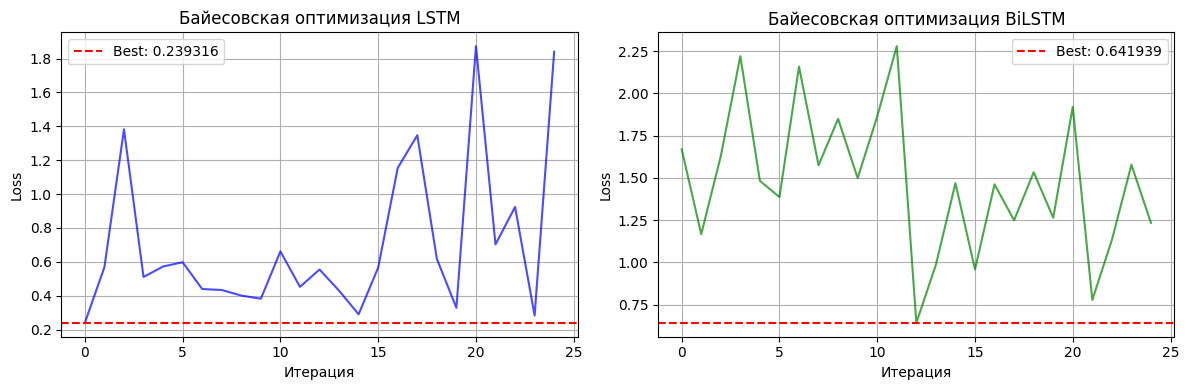


ИТОГОВОЕ СРАВНЕНИЕ
Метрика                Без внешних LSTM    С внешними LSTM   Без внешних BiLSTM    С внешними BiLSTM
----------------------------------------------------------------------------------------------------
MAE                              163.78             138.14               152.21               237.64
RMSE                             202.10             177.79               201.55               288.63
MAPE (%)                           4.37               3.45                 3.99                 6.42
R2                               0.9143             0.9336               0.9147               0.8251


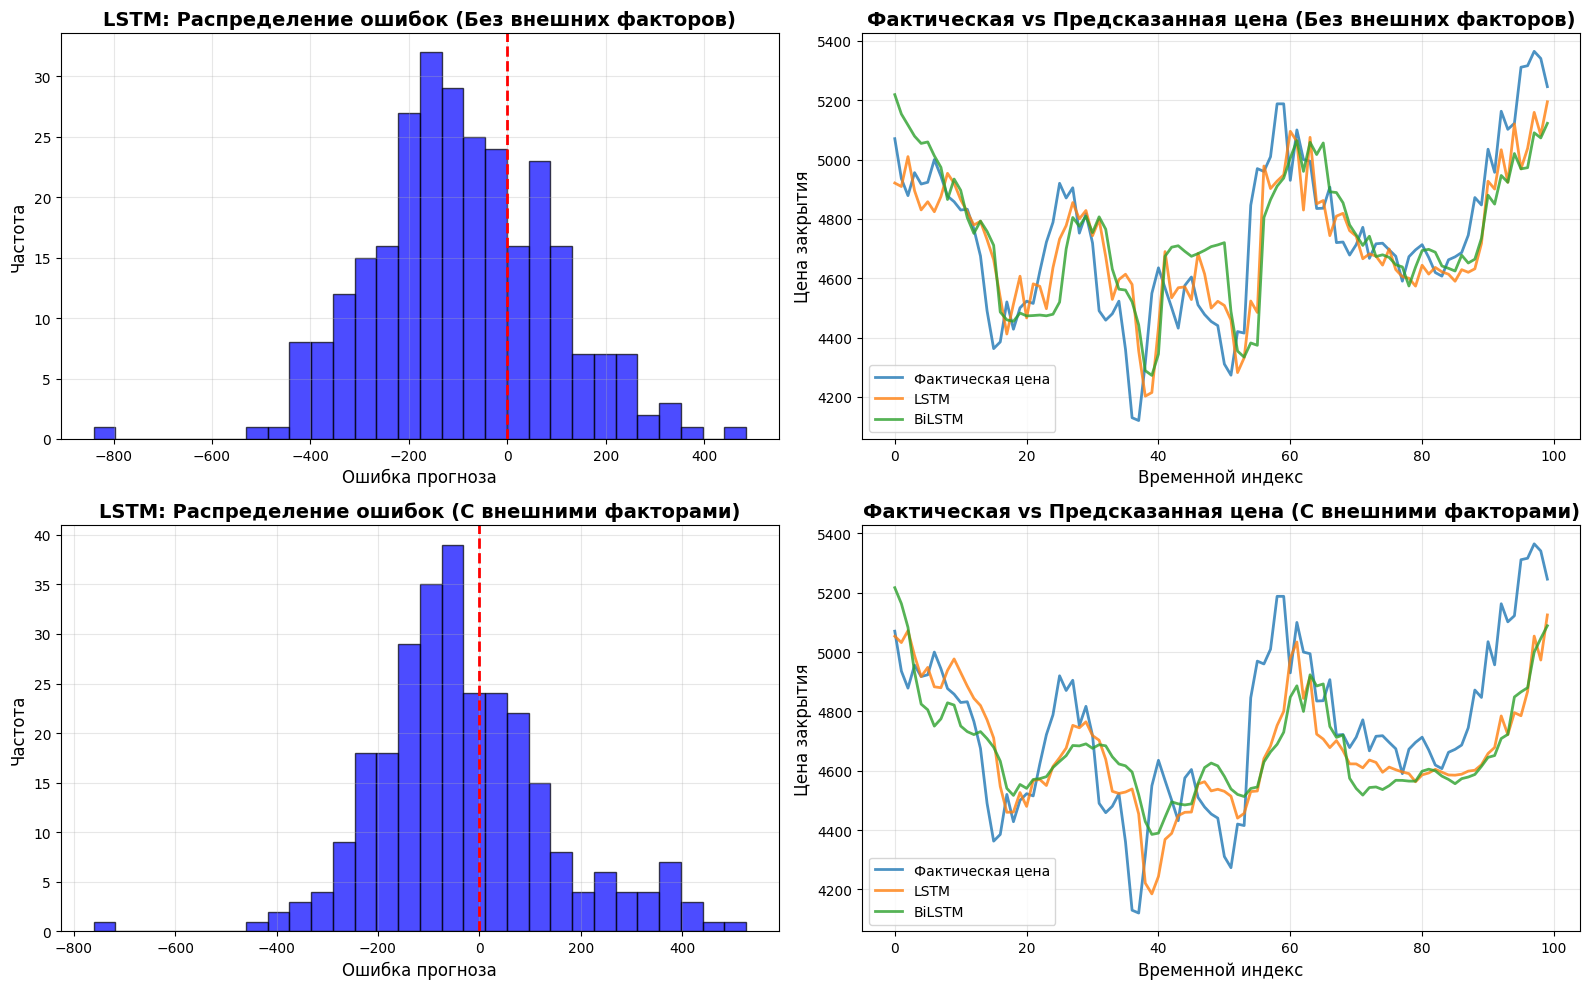

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from skopt import gp_minimize
from skopt.space import Integer, Real, Categorical
from skopt.utils import use_named_args
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def create_features_without_external(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Open_today'].shift(1) + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5).std()
    feature_columns.append('volatility')

    df['Close_today'] = df['Закрытие']

    df_clean = df[feature_columns + ['Close_today']].dropna().reset_index(drop=True)
    return df_clean, feature_columns

def create_features_with_external(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    df['Currency_yesterday'] = df['Курс'].shift(1)
    df['Oil_yesterday'] = df['Значение'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday',
                            'Currency_yesterday', 'Oil_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    df['currency_pct_change'] = df['Currency_yesterday'].pct_change() * 100
    df['oil_pct_change'] = df['Oil_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change',
                            'currency_pct_change', 'oil_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Open_today'].shift(1) + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['close_currency_ratio'] = df['Close_yesterday'] / (df['Currency_yesterday'] + 1e-10)
    df['close_oil_ratio'] = df['Close_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    df['currency_oil_ratio'] = df['Currency_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    feature_columns.extend(['close_currency_ratio', 'close_oil_ratio', 'currency_oil_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5).std()
    df['currency_volatility'] = df['Currency_yesterday'].rolling(5).std()
    df['oil_volatility'] = df['Oil_yesterday'].rolling(5).std()
    feature_columns.extend(['volatility', 'currency_volatility', 'oil_volatility'])

    df['Close_today'] = df['Закрытие']

    df_clean = df[feature_columns + ['Close_today']].dropna().reset_index(drop=True)
    return df_clean, feature_columns

class StockDataset(Dataset):
    def __init__(self, features, target, sequence_length=10):
        self.features = features.astype(np.float32)
        self.target = target.astype(np.float32)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.features) - self.sequence_length

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.sequence_length]
        y = self.target[idx + self.sequence_length]
        return torch.FloatTensor(x), torch.FloatTensor([y])

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out[:, -1, :])
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class BiLSTMModelImproved(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3, pooling='mean'):
        super(BiLSTMModelImproved, self).__init__()
        self.pooling = pooling
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(hidden_dim * 2)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)

        if self.pooling == 'mean':
            x = torch.mean(lstm_out, dim=1)
        elif self.pooling == 'max':
            x = torch.max(lstm_out, dim=1)[0]
        else:
            x = lstm_out[:, -1, :]

        x = self.layer_norm(x)
        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

def train_model_fast_lstm(model, train_loader, val_loader, epochs=25, lr=0.001, wd=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    patience = 5
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()

        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return best_val_loss

def train_model_fast_bilstm(model, train_loader, val_loader, epochs=25, lr=0.0005, wd=0.05):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)

    patience = 4
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):
        model.train()
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()

        val_loss /= len(val_loader)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return best_val_loss

def train_model_final_lstm(model, train_loader, test_loader, epochs=80, lr=0.001, wd=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    best_loss = float('inf')
    best_model_state = None
    patience = 8
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                test_loss += criterion(outputs, batch_y).item()

        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        scheduler.step(test_loss)

        if test_loss < best_loss:
            best_loss = test_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_model_state)
    return model

def train_model_final_bilstm(model, train_loader, test_loader, epochs=80, lr=0.0005, wd=0.05):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    best_loss = float('inf')
    best_model_state = None
    patience = 6
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                test_loss += criterion(outputs, batch_y).item()

        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        scheduler.step(test_loss)

        if test_loss < best_loss:
            best_loss = test_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_model_state)
    return model

def predict(model, data_loader, target_scaler):
    device = next(model.parameters()).device
    model.eval()
    predictions, actuals = [], []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(batch_y.numpy())

    predictions = np.array(predictions).flatten()
    actuals = np.array(actuals).flatten()
    predictions_original = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    actuals_original = target_scaler.inverse_transform(actuals.reshape(-1, 1)).flatten()
    return predictions_original, actuals_original

def evaluate_model(model, test_loader, target_scaler):
    predictions, actuals = predict(model, test_loader, target_scaler)
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    r2 = r2_score(actuals, predictions)
    return mae, rmse, mape, r2, predictions, actuals

def run_bayesian_optimization(data_features, feature_cols, name, n_calls=25, n_random_starts=10):
    print(f"\nБайесовская оптимизация для {name}")

    train_size = int(len(data_features) * 0.7)
    val_size = int(len(data_features) * 0.15)
    train_data = data_features.iloc[:train_size].copy()
    val_data = data_features.iloc[train_size:train_size+val_size].copy()
    test_data = data_features.iloc[train_size+val_size:].copy()

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    train_features = train_data[feature_cols].values
    train_target = train_data[['Close_today']].values

    train_features_scaled = feature_scaler.fit_transform(train_features)
    train_target_scaled = target_scaler.fit_transform(train_target).flatten()

    val_features_scaled = feature_scaler.transform(val_data[feature_cols].values)
    val_target_scaled = target_scaler.transform(val_data[['Close_today']].values).flatten()

    test_features_scaled = feature_scaler.transform(test_data[feature_cols].values)
    test_target_scaled = target_scaler.transform(test_data[['Close_today']].values).flatten()

    sequence_length = 10
    train_dataset = StockDataset(train_features_scaled, train_target_scaled, sequence_length)
    val_dataset = StockDataset(val_features_scaled, val_target_scaled, sequence_length)
    test_dataset = StockDataset(test_features_scaled, test_target_scaled, sequence_length)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    space_lstm = [
        Integer(32, 128, name='hidden_dim'),
        Integer(1, 3, name='num_layers'),
        Real(0.1, 0.4, name='dropout'),
        Real(0.0005, 0.003, name='lr'),
        Real(0.0005, 0.02, name='weight_decay')
    ]

    space_bilstm = [
        Integer(32, 96, name='hidden_dim'),
        Integer(1, 2, name='num_layers'),
        Real(0.3, 0.5, name='dropout'),
        Real(0.0003, 0.002, name='lr'),
        Real(0.01, 0.1, name='weight_decay'),
        Categorical(['mean', 'max'], name='pooling')
    ]

    @use_named_args(space_lstm)
    def objective_lstm(hidden_dim, num_layers, dropout, lr, weight_decay):
        model = LSTMModel(
            input_dim=len(feature_cols),
            hidden_dim=int(hidden_dim),
            num_layers=int(num_layers),
            dropout=float(dropout)
        )
        loss = train_model_fast_lstm(
            model, train_loader, val_loader,
            epochs=25, lr=float(lr), wd=float(weight_decay)
        )
        return loss

    @use_named_args(space_bilstm)
    def objective_bilstm(hidden_dim, num_layers, dropout, lr, weight_decay, pooling):
        model = BiLSTMModelImproved(
            input_dim=len(feature_cols),
            hidden_dim=int(hidden_dim),
            num_layers=int(num_layers),
            dropout=float(dropout),
            pooling=str(pooling)
        )
        loss = train_model_fast_bilstm(
            model, train_loader, val_loader,
            epochs=25, lr=float(lr), wd=float(weight_decay)
        )
        return loss

    print("  Оптимизация LSTM...")
    result_lstm = gp_minimize(
        objective_lstm, space_lstm,
        n_calls=n_calls,
        n_random_starts=n_random_starts,
        verbose=True,
        random_state=42,
        acq_func="EI",
        n_jobs=1
    )

    print("\n  Оптимизация BiLSTM...")
    result_bilstm = gp_minimize(
        objective_bilstm, space_bilstm,
        n_calls=n_calls,
        n_random_starts=n_random_starts,
        verbose=True,
        random_state=42,
        acq_func="EI",
        n_jobs=1
    )

    best_lstm_params = {
        'hidden_dim': int(result_lstm.x[0]),
        'num_layers': int(result_lstm.x[1]),
        'dropout': float(result_lstm.x[2]),
        'lr': float(result_lstm.x[3]),
        'weight_decay': float(result_lstm.x[4])
    }

    best_bilstm_params = {
        'hidden_dim': int(result_bilstm.x[0]),
        'num_layers': int(result_bilstm.x[1]),
        'dropout': float(result_bilstm.x[2]),
        'lr': float(result_bilstm.x[3]),
        'weight_decay': float(result_bilstm.x[4]),
        'pooling': str(result_bilstm.x[5])
    }

    print(f"\nЛучшие параметры LSTM: {best_lstm_params}")
    print(f"Лучшие параметры BiLSTM: {best_bilstm_params}")
    print(f"Лучший loss LSTM: {result_lstm.fun:.6f}")
    print(f"Лучший loss BiLSTM: {result_bilstm.fun:.6f}")

    print("\nФинальное обучение...")

    final_lstm = LSTMModel(
        len(feature_cols),
        best_lstm_params['hidden_dim'],
        best_lstm_params['num_layers'],
        best_lstm_params['dropout']
    )
    final_lstm = train_model_final_lstm(
        final_lstm, train_loader, test_loader, 80,
        best_lstm_params['lr'], best_lstm_params['weight_decay']
    )
    lstm_mae, lstm_rmse, lstm_mape, lstm_r2, lstm_pred, lstm_act = evaluate_model(
        final_lstm, test_loader, target_scaler
    )

    final_bilstm = BiLSTMModelImproved(
        len(feature_cols),
        best_bilstm_params['hidden_dim'],
        best_bilstm_params['num_layers'],
        best_bilstm_params['dropout'],
        best_bilstm_params['pooling']
    )
    final_bilstm = train_model_final_bilstm(
        final_bilstm, train_loader, test_loader, 80,
        best_bilstm_params['lr'], best_bilstm_params['weight_decay']
    )
    bilstm_mae, bilstm_rmse, bilstm_mape, bilstm_r2, bilstm_pred, bilstm_act = evaluate_model(
        final_bilstm, test_loader, target_scaler
    )

    print(f"\nРезультаты для {name}:")
    print(f"LSTM: MAE={lstm_mae:.2f}, RMSE={lstm_rmse:.2f}, MAPE={lstm_mape:.2f}%, R2={lstm_r2:.4f}")
    print(f"BiLSTM: MAE={bilstm_mae:.2f}, RMSE={bilstm_rmse:.2f}, MAPE={bilstm_mape:.2f}%, R2={bilstm_r2:.4f}")

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(result_lstm.func_vals, 'b-', alpha=0.7)
    plt.axhline(y=result_lstm.fun, color='r', linestyle='--', label=f'Best: {result_lstm.fun:.6f}')
    plt.xlabel('Итерация')
    plt.ylabel('Loss')
    plt.title('Байесовская оптимизация LSTM')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(result_bilstm.func_vals, 'g-', alpha=0.7)
    plt.axhline(y=result_bilstm.fun, color='r', linestyle='--', label=f'Best: {result_bilstm.fun:.6f}')
    plt.xlabel('Итерация')
    plt.ylabel('Loss')
    plt.title('Байесовская оптимизация BiLSTM')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        'lstm_mae': lstm_mae, 'bilstm_mae': bilstm_mae,
        'lstm_rmse': lstm_rmse, 'bilstm_rmse': bilstm_rmse,
        'lstm_mape': lstm_mape, 'bilstm_mape': bilstm_mape,
        'lstm_r2': lstm_r2, 'bilstm_r2': bilstm_r2,
        'lstm_pred': lstm_pred, 'lstm_act': lstm_act,
        'bilstm_pred': bilstm_pred, 'bilstm_act': bilstm_act,
        'lstm_best_loss': result_lstm.fun,
        'bilstm_best_loss': result_bilstm.fun
    }

data_without, cols_without = create_features_without_external(result)
data_with, cols_with = create_features_with_external(result)

print("\n" + "="*80)
print("БАЙЕСОВСКАЯ ОПТИМИЗАЦИЯ")
print("="*80)

print("\nМодель без внешних факторов")
results_without = run_bayesian_optimization(data_without, cols_without, "БЕЗ ВНЕШНИХ", n_calls=25)

print("\nМодель с внешними факторами")
results_with = run_bayesian_optimization(data_with, cols_with, "С ВНЕШНИМИ", n_calls=25)

print("\n" + "="*80)
print("ИТОГОВОЕ СРАВНЕНИЕ")
print("="*80)
print(f"{'Метрика':<20} {'Без внешних LSTM':>18} {'С внешними LSTM':>18} {'Без внешних BiLSTM':>20} {'С внешними BiLSTM':>20}")
print("-"*100)
print(f"{'MAE':<20} {results_without['lstm_mae']:>18.2f} {results_with['lstm_mae']:>18.2f} {results_without['bilstm_mae']:>20.2f} {results_with['bilstm_mae']:>20.2f}")
print(f"{'RMSE':<20} {results_without['lstm_rmse']:>18.2f} {results_with['lstm_rmse']:>18.2f} {results_without['bilstm_rmse']:>20.2f} {results_with['bilstm_rmse']:>20.2f}")
print(f"{'MAPE (%)':<20} {results_without['lstm_mape']:>18.2f} {results_with['lstm_mape']:>18.2f} {results_without['bilstm_mape']:>20.2f} {results_with['bilstm_mape']:>20.2f}")
print(f"{'R2':<20} {results_without['lstm_r2']:>18.4f} {results_with['lstm_r2']:>18.4f} {results_without['bilstm_r2']:>20.4f} {results_with['bilstm_r2']:>20.4f}")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for idx, (title, results_data) in enumerate([('Без внешних факторов', results_without),
                                              ('С внешними факторами', results_with)]):

    ax1 = axes[idx, 0]
    errors_lstm = results_data['lstm_act'] - results_data['lstm_pred']
    ax1.hist(errors_lstm, bins=30, alpha=0.7, color='blue', edgecolor='black')
    ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
    ax1.set_xlabel('Ошибка прогноза', fontsize=12)
    ax1.set_ylabel('Частота', fontsize=12)
    ax1.set_title(f'LSTM: Распределение ошибок ({title})', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    ax2 = axes[idx, 1]
    ax2.plot(results_data['lstm_act'][:100], label='Фактическая цена', linewidth=2, alpha=0.8)
    ax2.plot(results_data['lstm_pred'][:100], label='LSTM', linewidth=2, alpha=0.8)
    ax2.plot(results_data['bilstm_pred'][:100], label='BiLSTM', linewidth=2, alpha=0.8)
    ax2.set_xlabel('Временной индекс', fontsize=12)
    ax2.set_ylabel('Цена закрытия', fontsize=12)
    ax2.set_title(f'Фактическая vs Предсказанная цена ({title})', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Признаков без внешних: 20
Признаков с внешними: 29
Train: 1345 точек (0:1345)
Val:   276 точек (1360:1636)
Test:  292 точек (1651:1943)
Gap между выборками: 15 точек
Train: 1345 точек (0:1345)
Val:   276 точек (1360:1636)
Test:  292 точек (1651:1943)
Gap между выборками: 15 точек

LSTM without external...
Epoch  20 | Train: 0.103419 | Val: 0.420556
Epoch  40 | Train: 0.081884 | Val: 0.611470
Early stopping at epoch 43

BiLSTM without external...
Epoch  20 | Train: 0.085619 | Val: 0.378257
Epoch  40 | Train: 0.070929 | Val: 0.700327
Early stopping at epoch 41

LSTM with external...
Epoch  20 | Train: 0.085276 | Val: 1.632956
Epoch  40 | Train: 0.079601 | Val: 0.677666
Early stopping at epoch 50

BiLSTM with external...
Epoch  20 | Train: 0.105991 | Val: 1.085655
Early stopping at epoch 34

РЕЗУЛЬТАТЫ
LSTM без внешних:   MAE=125.72, MAPE=3.13%, R2=0.9434
BiLSTM без внешних: MAE=121.60, MAPE=3.11%, R2=0.9464
LSTM с внешними:    MAE=149.98, MAPE=3.64%, R2=0.9227
BiLSTM с внешними:  MAE=132

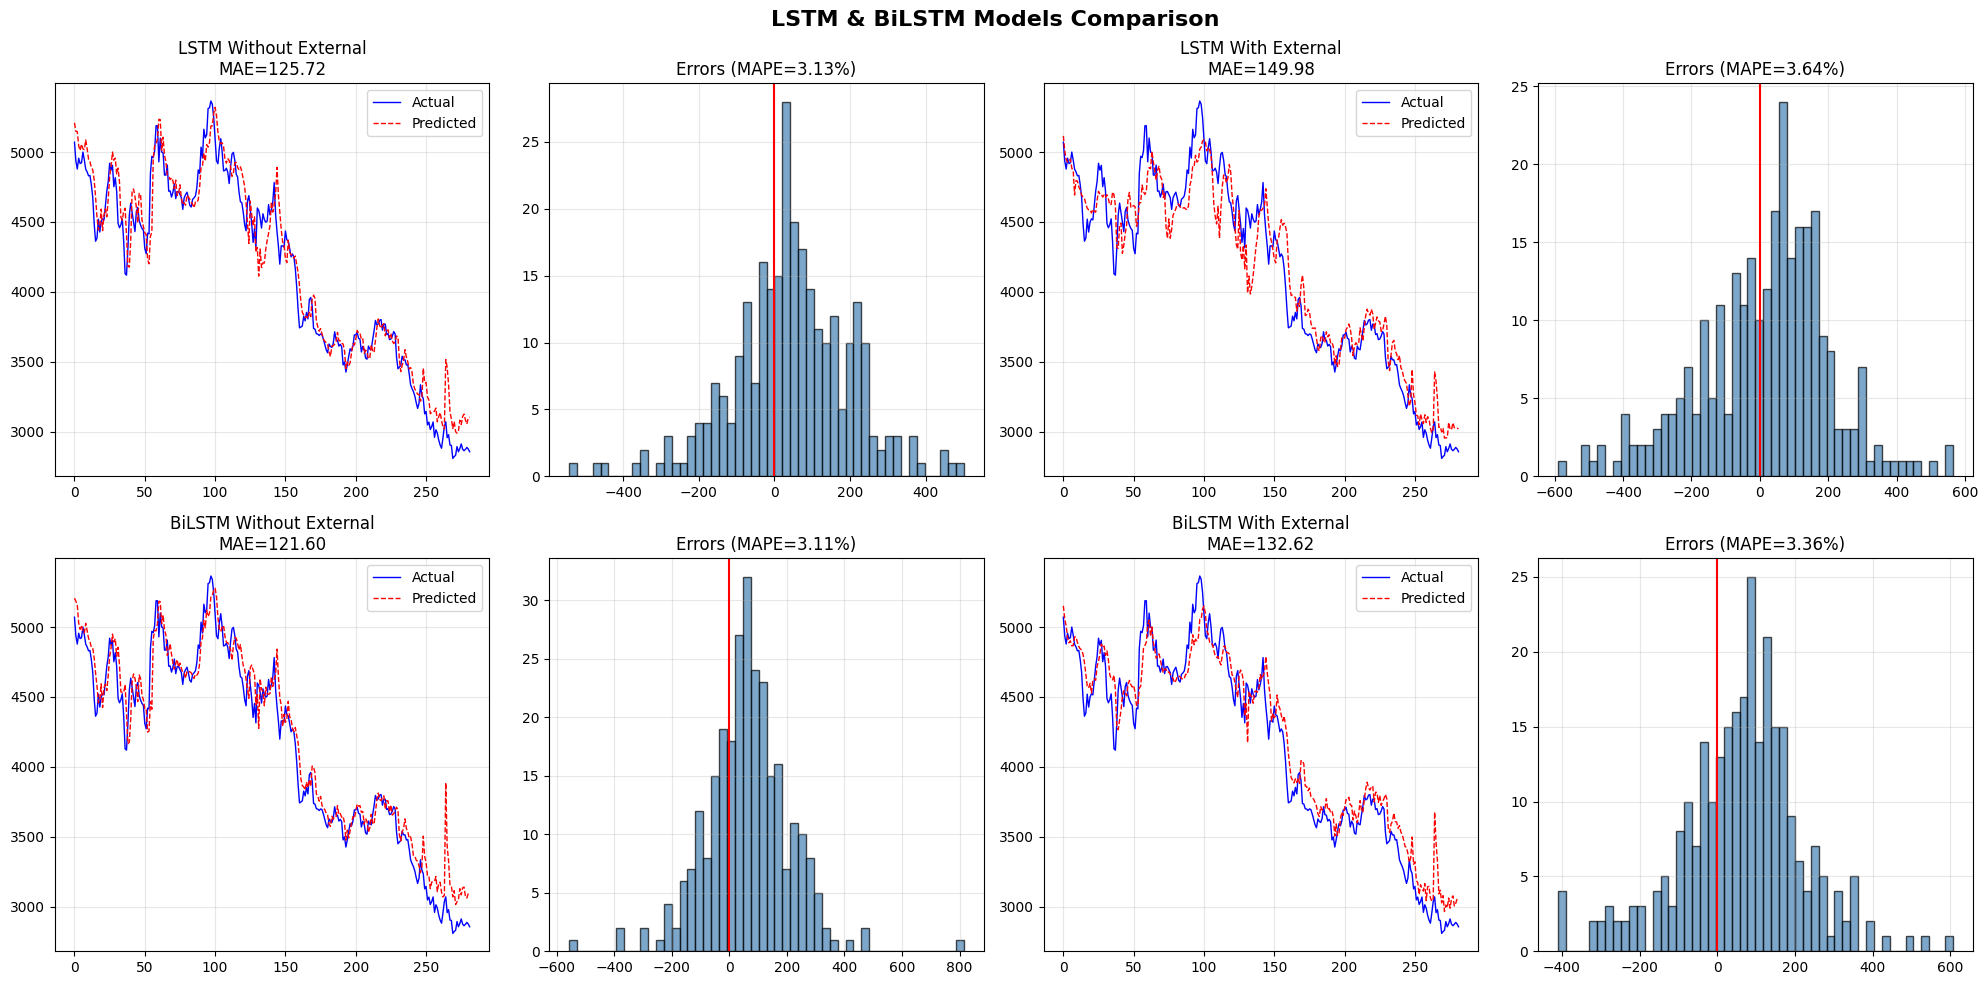


График сохранен: lstm_bilstm_results.png


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

# Функции создания признаков
def create_features_without_external(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Open_yesterday'] = df['Открытие'].shift(1)

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Open_yesterday'] + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5).std()
    feature_columns.append('volatility')

    df['Close_today'] = df['Закрытие']

    df_clean = df[feature_columns + ['Close_today']].dropna().reset_index(drop=True)
    return df_clean, feature_columns

def create_features_with_external(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Open_yesterday'] = df['Открытие'].shift(1)

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    df['Currency_yesterday'] = df['Курс'].shift(1)
    df['Oil_yesterday'] = df['Значение'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday',
                            'Currency_yesterday', 'Oil_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    df['currency_pct_change'] = df['Currency_yesterday'].pct_change() * 100
    df['oil_pct_change'] = df['Oil_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change',
                            'currency_pct_change', 'oil_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Open_yesterday'] + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['close_currency_ratio'] = df['Close_yesterday'] / (df['Currency_yesterday'] + 1e-10)
    df['close_oil_ratio'] = df['Close_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    df['currency_oil_ratio'] = df['Currency_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    feature_columns.extend(['close_currency_ratio', 'close_oil_ratio', 'currency_oil_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5).std()
    df['currency_volatility'] = df['Currency_yesterday'].rolling(5).std()
    df['oil_volatility'] = df['Oil_yesterday'].rolling(5).std()
    feature_columns.extend(['volatility', 'currency_volatility', 'oil_volatility'])

    df['Close_today'] = df['Закрытие']

    df_clean = df[feature_columns + ['Close_today']].dropna().reset_index(drop=True)
    return df_clean, feature_columns

# Исправленный Dataset без утечки
class StockDatasetFixed(Dataset):
    def __init__(self, features, target, sequence_length=10):
        self.features = features.astype(np.float32)
        self.target = target.astype(np.float32)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.features) - self.sequence_length

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.sequence_length]
        y = self.target[idx + self.sequence_length]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# Модели
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out[:, -1, :])
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out[:, -1, :])
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Функция обучения с валидацией
def train_model_fixed(model, train_loader, val_loader, epochs=100, lr=0.001, wd=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val_loss = float('inf')
    best_model_state = None
    patience = 15
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

    model.load_state_dict(best_model_state)
    return model

def predict(model, data_loader, target_scaler):
    device = next(model.parameters()).device
    model.eval()
    predictions, actuals = [], []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(batch_y.numpy())

    predictions = np.array(predictions).flatten()
    actuals = np.array(actuals).flatten()
    predictions_original = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    actuals_original = target_scaler.inverse_transform(actuals.reshape(-1, 1)).flatten()
    return predictions_original, actuals_original

def evaluate_model(model, test_loader, target_scaler):
    predictions, actuals = predict(model, test_loader, target_scaler)
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    r2 = r2_score(actuals, predictions)
    return mae, rmse, mape, r2, predictions, actuals

# Правильная подготовка данных
def prepare_data(data_features, feature_cols):
    train_size = int(len(data_features) * 0.7)
    val_size = int(len(data_features) * 0.15)
    sequence_length = 10
    gap = sequence_length + 5  # запас для предотвращения утечки

    train_data = data_features.iloc[:train_size - gap].copy()
    val_data = data_features.iloc[train_size:train_size + val_size - gap].copy()
    test_data = data_features.iloc[train_size + val_size:].copy()

    print(f"Train: {len(train_data)} точек (0:{train_size - gap})")
    print(f"Val:   {len(val_data)} точек ({train_size}:{train_size + val_size - gap})")
    print(f"Test:  {len(test_data)} точек ({train_size + val_size}:{len(data_features)})")
    print(f"Gap между выборками: {gap} точек")

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    train_features = train_data[feature_cols].values
    train_target = train_data[['Close_today']].values

    train_features_scaled = feature_scaler.fit_transform(train_features)
    train_target_scaled = target_scaler.fit_transform(train_target).flatten()

    val_features_scaled = feature_scaler.transform(val_data[feature_cols].values)
    val_target_scaled = target_scaler.transform(val_data[['Close_today']].values).flatten()

    test_features_scaled = feature_scaler.transform(test_data[feature_cols].values)
    test_target_scaled = target_scaler.transform(test_data[['Close_today']].values).flatten()

    train_dataset = StockDatasetFixed(train_features_scaled, train_target_scaled, sequence_length)
    val_dataset = StockDatasetFixed(val_features_scaled, val_target_scaled, sequence_length)
    test_dataset = StockDatasetFixed(test_features_scaled, test_target_scaled, sequence_length)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    return train_loader, val_loader, test_loader, target_scaler
# Создание данных
data_without, cols_without = create_features_without_external(result)
data_with, cols_with = create_features_with_external(result)

print(f"Признаков без внешних: {len(cols_without)}")
print(f"Признаков с внешними: {len(cols_with)}")

# Подготовка
train_loader_wo, val_loader_wo, test_loader_wo, target_scaler_wo = prepare_data(data_without, cols_without)
train_loader_w, val_loader_w, test_loader_w, target_scaler_w = prepare_data(data_with, cols_with)

# Обучение
print("\nLSTM without external...")
lstm1 = LSTMModel(len(cols_without), hidden_dim=64, num_layers=2, dropout=0.2)
lstm1 = train_model_fixed(lstm1, train_loader_wo, val_loader_wo, 100, 0.001, 0.01)
lstm_mae1, lstm_rmse1, lstm_mape1, lstm_r2_1, lstm_preds1, lstm_actuals1 = evaluate_model(lstm1, test_loader_wo, target_scaler_wo)

print("\nBiLSTM without external...")
bilstm1 = BiLSTMModel(len(cols_without), hidden_dim=64, num_layers=2, dropout=0.3)
bilstm1 = train_model_fixed(bilstm1, train_loader_wo, val_loader_wo, 100, 0.0005, 0.05)
bilstm_mae1, bilstm_rmse1, bilstm_mape1, bilstm_r2_1, bilstm_preds1, bilstm_actuals1 = evaluate_model(bilstm1, test_loader_wo, target_scaler_wo)

print("\nLSTM with external...")
lstm2 = LSTMModel(len(cols_with), hidden_dim=64, num_layers=2, dropout=0.2)
lstm2 = train_model_fixed(lstm2, train_loader_w, val_loader_w, 100, 0.001, 0.01)
lstm_mae2, lstm_rmse2, lstm_mape2, lstm_r2_2, lstm_preds2, lstm_actuals2 = evaluate_model(lstm2, test_loader_w, target_scaler_w)

print("\nBiLSTM with external...")
bilstm2 = BiLSTMModel(len(cols_with), hidden_dim=64, num_layers=2, dropout=0.3)
bilstm2 = train_model_fixed(bilstm2, train_loader_w, val_loader_w, 100, 0.0005, 0.05)
bilstm_mae2, bilstm_rmse2, bilstm_mape2, bilstm_r2_2, bilstm_preds2, bilstm_actuals2 = evaluate_model(bilstm2, test_loader_w, target_scaler_w)

# Результаты
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ")
print("="*70)
print(f"LSTM без внешних:   MAE={lstm_mae1:.2f}, MAPE={lstm_mape1:.2f}%, R2={lstm_r2_1:.4f}")
print(f"BiLSTM без внешних: MAE={bilstm_mae1:.2f}, MAPE={bilstm_mape1:.2f}%, R2={bilstm_r2_1:.4f}")
print(f"LSTM с внешними:    MAE={lstm_mae2:.2f}, MAPE={lstm_mape2:.2f}%, R2={lstm_r2_2:.4f}")
print(f"BiLSTM с внешними:  MAE={bilstm_mae2:.2f}, MAPE={bilstm_mape2:.2f}%, R2={bilstm_r2_2:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('LSTM & BiLSTM Models Comparison', fontsize=16, fontweight='bold')

axes[0,0].plot(lstm_actuals1, label='Actual', color='blue', linewidth=1)
axes[0,0].plot(lstm_preds1, label='Predicted', color='red', linestyle='--', linewidth=1)
axes[0,0].set_title(f'LSTM Without External\nMAE={lstm_mae1:.2f}')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

errors1 = lstm_preds1 - lstm_actuals1
axes[0,1].hist(errors1, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,1].axvline(x=0, color='red', linestyle='-')
axes[0,1].set_title(f'Errors (MAPE={lstm_mape1:.2f}%)')
axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(lstm_actuals2, label='Actual', color='blue', linewidth=1)
axes[0,2].plot(lstm_preds2, label='Predicted', color='red', linestyle='--', linewidth=1)
axes[0,2].set_title(f'LSTM With External\nMAE={lstm_mae2:.2f}')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

errors2 = lstm_preds2 - lstm_actuals2
axes[0,3].hist(errors2, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,3].axvline(x=0, color='red', linestyle='-')
axes[0,3].set_title(f'Errors (MAPE={lstm_mape2:.2f}%)')
axes[0,3].grid(True, alpha=0.3)

axes[1,0].plot(bilstm_actuals1, label='Actual', color='blue', linewidth=1)
axes[1,0].plot(bilstm_preds1, label='Predicted', color='red', linestyle='--', linewidth=1)
axes[1,0].set_title(f'BiLSTM Without External\nMAE={bilstm_mae1:.2f}')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

errors3 = bilstm_preds1 - bilstm_actuals1
axes[1,1].hist(errors3, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[1,1].axvline(x=0, color='red', linestyle='-')
axes[1,1].set_title(f'Errors (MAPE={bilstm_mape1:.2f}%)')
axes[1,1].grid(True, alpha=0.3)

axes[1,2].plot(bilstm_actuals2, label='Actual', color='blue', linewidth=1)
axes[1,2].plot(bilstm_preds2, label='Predicted', color='red', linestyle='--', linewidth=1)
axes[1,2].set_title(f'BiLSTM With External\nMAE={bilstm_mae2:.2f}')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

errors4 = bilstm_preds2 - bilstm_actuals2
axes[1,3].hist(errors4, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[1,3].axvline(x=0, color='red', linestyle='-')
axes[1,3].set_title(f'Errors (MAPE={bilstm_mape2:.2f}%)')
axes[1,3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_bilstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nГрафик сохранен: lstm_bilstm_results.png")

LSTM without external...
Epoch  20 | Train: 0.089489 | Val: 0.894173
Epoch  40 | Train: 0.094061 | Val: 0.420092
Early stopping at epoch 44

BiLSTM without external...
Epoch  20 | Train: 0.088024 | Val: 0.788653
Early stopping at epoch 32

LSTM with external...
Epoch  20 | Train: 0.098848 | Val: 0.680246
Epoch  40 | Train: 0.068356 | Val: 0.972840
Epoch  60 | Train: 0.069594 | Val: 0.720702
Early stopping at epoch 61

BiLSTM with external...
Epoch  20 | Train: 0.076425 | Val: 0.502444
Early stopping at epoch 40

РЕЗУЛЬТАТЫ
LSTM без внешних:   MAE=118.70, MAPE=2.96%, R2=0.9495
BiLSTM без внешних: MAE=106.50, MAPE=2.64%, R2=0.9563
LSTM с внешними:    MAE=217.48, MAPE=5.59%, R2=0.8607
BiLSTM с внешними:  MAE=184.95, MAPE=4.82%, R2=0.8987


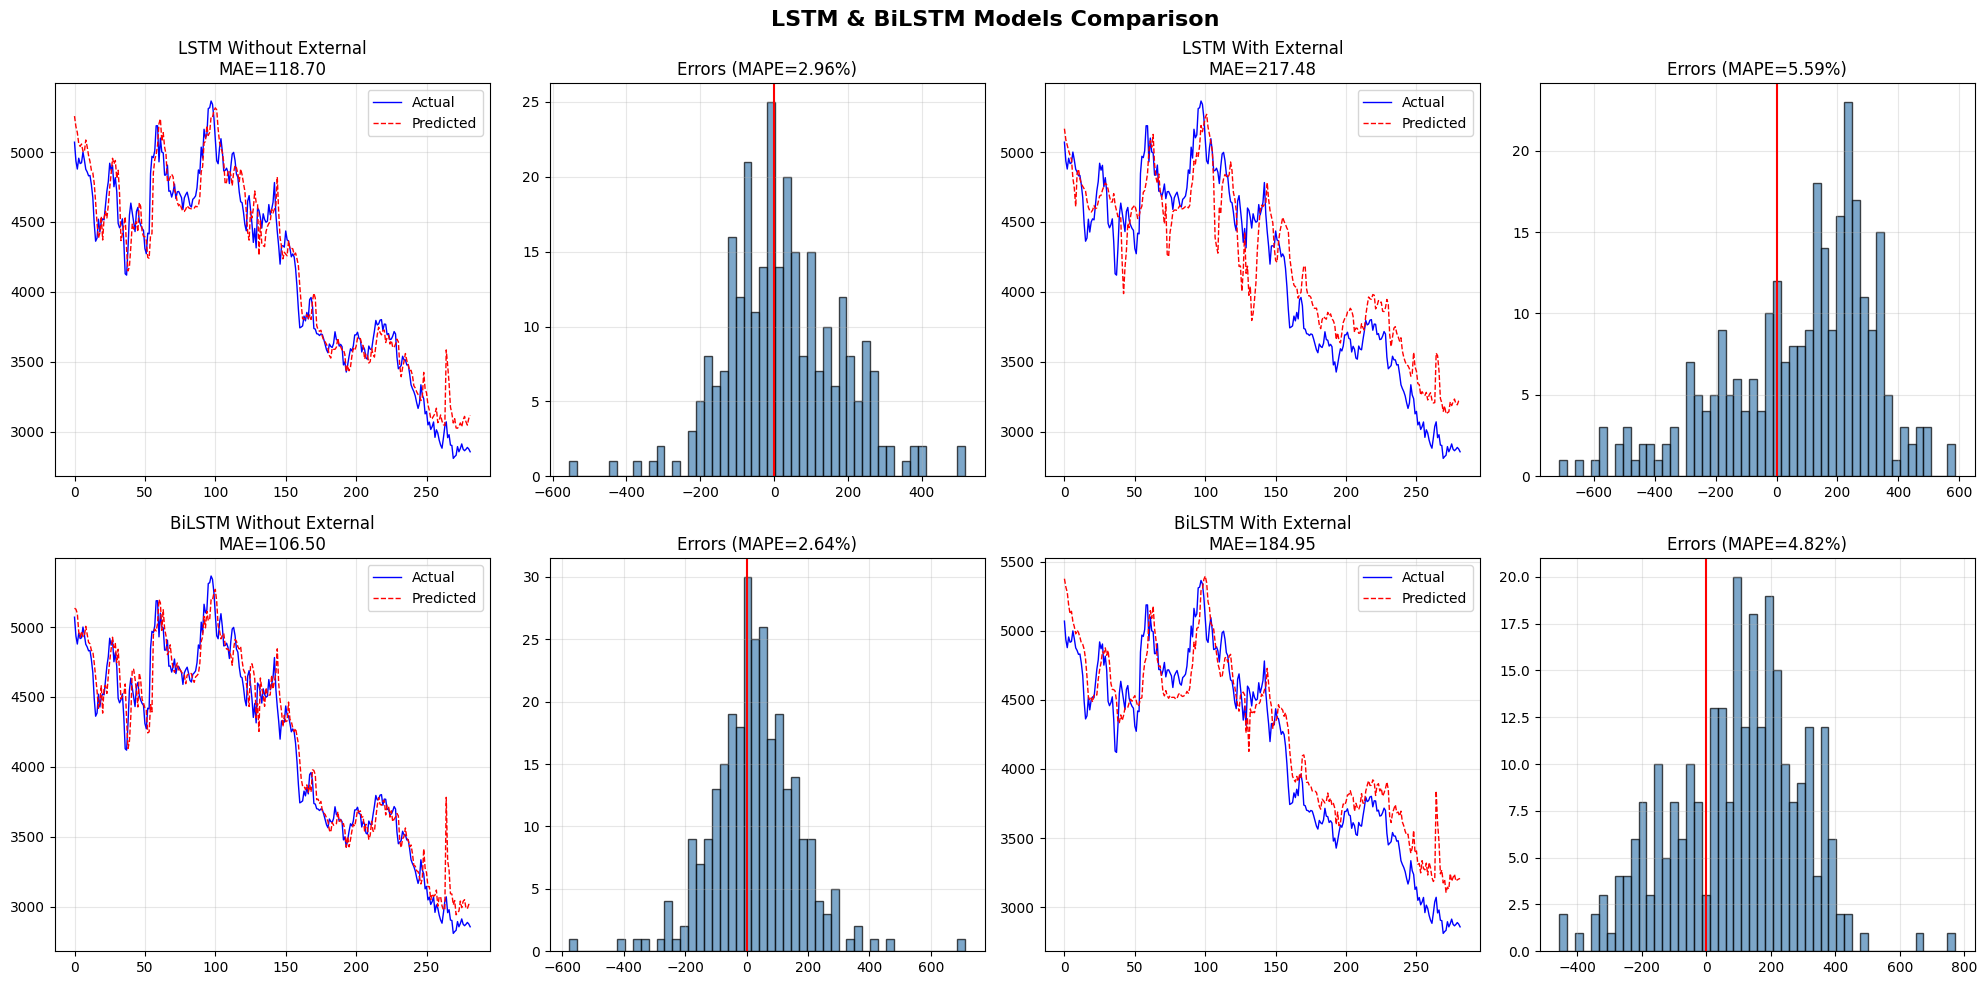


График сохранен: lstm_bilstm_results.png


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

# Функции создания признаков
def create_features_without_external(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Open_today'].shift(1) + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5).std()
    feature_columns.append('volatility')

    df['Close_today'] = df['Закрытие']

    df_clean = df[feature_columns + ['Close_today']].dropna().reset_index(drop=True)
    return df_clean, feature_columns

def create_features_with_external(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    df['Currency_yesterday'] = df['Курс'].shift(1)
    df['Oil_yesterday'] = df['Значение'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday',
                            'Currency_yesterday', 'Oil_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    df['currency_pct_change'] = df['Currency_yesterday'].pct_change() * 100
    df['oil_pct_change'] = df['Oil_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change',
                            'currency_pct_change', 'oil_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Open_today'].shift(1) + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['close_currency_ratio'] = df['Close_yesterday'] / (df['Currency_yesterday'] + 1e-10)
    df['close_oil_ratio'] = df['Close_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    df['currency_oil_ratio'] = df['Currency_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    feature_columns.extend(['close_currency_ratio', 'close_oil_ratio', 'currency_oil_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5).std()
    df['currency_volatility'] = df['Currency_yesterday'].rolling(5).std()
    df['oil_volatility'] = df['Oil_yesterday'].rolling(5).std()
    feature_columns.extend(['volatility', 'currency_volatility', 'oil_volatility'])

    df['Close_today'] = df['Закрытие']

    df_clean = df[feature_columns + ['Close_today']].dropna().reset_index(drop=True)
    return df_clean, feature_columns

# Исправленный Dataset без утечки
class StockDatasetFixed(Dataset):
    def __init__(self, features, target, sequence_length=10):
        self.features = features.astype(np.float32)
        self.target = target.astype(np.float32)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.features) - self.sequence_length

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.sequence_length]
        y = self.target[idx + self.sequence_length]
        return torch.FloatTensor(x), torch.FloatTensor([y])

# Модели
class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out[:, -1, :])
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.3):
        super(BiLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim,
                           num_layers=num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out[:, -1, :])
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Функция обучения с валидацией
def train_model_fixed(model, train_loader, val_loader, epochs=100, lr=0.001, wd=0.01):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val_loss = float('inf')
    best_model_state = None
    patience = 15
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

    model.load_state_dict(best_model_state)
    return model

def predict(model, data_loader, target_scaler):
    device = next(model.parameters()).device
    model.eval()
    predictions, actuals = [], []

    with torch.no_grad():
        for batch_x, batch_y in data_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(batch_y.numpy())

    predictions = np.array(predictions).flatten()
    actuals = np.array(actuals).flatten()
    predictions_original = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    actuals_original = target_scaler.inverse_transform(actuals.reshape(-1, 1)).flatten()
    return predictions_original, actuals_original

def evaluate_model(model, test_loader, target_scaler):
    predictions, actuals = predict(model, test_loader, target_scaler)
    mae = mean_absolute_error(actuals, predictions)
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
    r2 = r2_score(actuals, predictions)
    return mae, rmse, mape, r2, predictions, actuals

# Правильная подготовка данных
def prepare_data(data_features, feature_cols):
    train_size = int(len(data_features) * 0.7)
    val_size = int(len(data_features) * 0.15)

    train_data = data_features.iloc[:train_size].copy()
    val_data = data_features.iloc[train_size:train_size+val_size].copy()
    test_data = data_features.iloc[train_size+val_size:].copy()

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    train_features = train_data[feature_cols].values
    train_target = train_data[['Close_today']].values

    train_features_scaled = feature_scaler.fit_transform(train_features)
    train_target_scaled = target_scaler.fit_transform(train_target).flatten()

    val_features_scaled = feature_scaler.transform(val_data[feature_cols].values)
    val_target_scaled = target_scaler.transform(val_data[['Close_today']].values).flatten()

    test_features_scaled = feature_scaler.transform(test_data[feature_cols].values)
    test_target_scaled = target_scaler.transform(test_data[['Close_today']].values).flatten()

    sequence_length = 10
    train_dataset = StockDatasetFixed(train_features_scaled, train_target_scaled, sequence_length)
    val_dataset = StockDatasetFixed(val_features_scaled, val_target_scaled, sequence_length)
    test_dataset = StockDatasetFixed(test_features_scaled, test_target_scaled, sequence_length)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    return train_loader, val_loader, test_loader, target_scaler

# Создание данных
data_without, cols_without = create_features_without_external(result)
data_with, cols_with = create_features_with_external(result)

# Подготовка
train_loader_wo, val_loader_wo, test_loader_wo, target_scaler_wo = prepare_data(data_without, cols_without)
train_loader_w, val_loader_w, test_loader_w, target_scaler_w = prepare_data(data_with, cols_with)

# Обучение
print("LSTM without external...")
lstm1 = LSTMModel(len(cols_without), hidden_dim=64, num_layers=2, dropout=0.2)
lstm1 = train_model_fixed(lstm1, train_loader_wo, val_loader_wo, 100, 0.001, 0.01)
lstm_mae1, lstm_rmse1, lstm_mape1, lstm_r2_1, lstm_preds1, lstm_actuals1 = evaluate_model(lstm1, test_loader_wo, target_scaler_wo)

print("\nBiLSTM without external...")
bilstm1 = BiLSTMModel(len(cols_without), hidden_dim=64, num_layers=2, dropout=0.3)
bilstm1 = train_model_fixed(bilstm1, train_loader_wo, val_loader_wo, 100, 0.0005, 0.05)
bilstm_mae1, bilstm_rmse1, bilstm_mape1, bilstm_r2_1, bilstm_preds1, bilstm_actuals1 = evaluate_model(bilstm1, test_loader_wo, target_scaler_wo)

print("\nLSTM with external...")
lstm2 = LSTMModel(len(cols_with), hidden_dim=64, num_layers=2, dropout=0.2)
lstm2 = train_model_fixed(lstm2, train_loader_w, val_loader_w, 100, 0.001, 0.01)
lstm_mae2, lstm_rmse2, lstm_mape2, lstm_r2_2, lstm_preds2, lstm_actuals2 = evaluate_model(lstm2, test_loader_w, target_scaler_w)

print("\nBiLSTM with external...")
bilstm2 = BiLSTMModel(len(cols_with), hidden_dim=64, num_layers=2, dropout=0.3)
bilstm2 = train_model_fixed(bilstm2, train_loader_w, val_loader_w, 100, 0.0005, 0.05)
bilstm_mae2, bilstm_rmse2, bilstm_mape2, bilstm_r2_2, bilstm_preds2, bilstm_actuals2 = evaluate_model(bilstm2, test_loader_w, target_scaler_w)

# Результаты
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ")
print("="*70)
print(f"LSTM без внешних:   MAE={lstm_mae1:.2f}, MAPE={lstm_mape1:.2f}%, R2={lstm_r2_1:.4f}")
print(f"BiLSTM без внешних: MAE={bilstm_mae1:.2f}, MAPE={bilstm_mape1:.2f}%, R2={bilstm_r2_1:.4f}")
print(f"LSTM с внешними:    MAE={lstm_mae2:.2f}, MAPE={lstm_mape2:.2f}%, R2={lstm_r2_2:.4f}")
print(f"BiLSTM с внешними:  MAE={bilstm_mae2:.2f}, MAPE={bilstm_mape2:.2f}%, R2={bilstm_r2_2:.4f}")

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('LSTM & BiLSTM Models Comparison', fontsize=16, fontweight='bold')

axes[0,0].plot(lstm_actuals1, label='Actual', color='blue', linewidth=1)
axes[0,0].plot(lstm_preds1, label='Predicted', color='red', linestyle='--', linewidth=1)
axes[0,0].set_title(f'LSTM Without External\nMAE={lstm_mae1:.2f}')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

errors1 = lstm_preds1 - lstm_actuals1
axes[0,1].hist(errors1, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,1].axvline(x=0, color='red', linestyle='-')
axes[0,1].set_title(f'Errors (MAPE={lstm_mape1:.2f}%)')
axes[0,1].grid(True, alpha=0.3)

axes[0,2].plot(lstm_actuals2, label='Actual', color='blue', linewidth=1)
axes[0,2].plot(lstm_preds2, label='Predicted', color='red', linestyle='--', linewidth=1)
axes[0,2].set_title(f'LSTM With External\nMAE={lstm_mae2:.2f}')
axes[0,2].legend()
axes[0,2].grid(True, alpha=0.3)

errors2 = lstm_preds2 - lstm_actuals2
axes[0,3].hist(errors2, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0,3].axvline(x=0, color='red', linestyle='-')
axes[0,3].set_title(f'Errors (MAPE={lstm_mape2:.2f}%)')
axes[0,3].grid(True, alpha=0.3)

axes[1,0].plot(bilstm_actuals1, label='Actual', color='blue', linewidth=1)
axes[1,0].plot(bilstm_preds1, label='Predicted', color='red', linestyle='--', linewidth=1)
axes[1,0].set_title(f'BiLSTM Without External\nMAE={bilstm_mae1:.2f}')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

errors3 = bilstm_preds1 - bilstm_actuals1
axes[1,1].hist(errors3, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[1,1].axvline(x=0, color='red', linestyle='-')
axes[1,1].set_title(f'Errors (MAPE={bilstm_mape1:.2f}%)')
axes[1,1].grid(True, alpha=0.3)

axes[1,2].plot(bilstm_actuals2, label='Actual', color='blue', linewidth=1)
axes[1,2].plot(bilstm_preds2, label='Predicted', color='red', linestyle='--', linewidth=1)
axes[1,2].set_title(f'BiLSTM With External\nMAE={bilstm_mae2:.2f}')
axes[1,2].legend()
axes[1,2].grid(True, alpha=0.3)

errors4 = bilstm_preds2 - bilstm_actuals2
axes[1,3].hist(errors4, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[1,3].axvline(x=0, color='red', linestyle='-')
axes[1,3].set_title(f'Errors (MAPE={bilstm_mape2:.2f}%)')
axes[1,3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lstm_bilstm_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nГрафик сохранен: lstm_bilstm_results.png")

ИТОГОВЫЙ LSTM BiLSTM



LSTM & BiLSTM RESULTS (с лаговыми ошибками)

Признаков без внешних: 25

--------------------------------------------------
LSTM без внешних
--------------------------------------------------
Epoch  20 | Train: 0.099324 | Val: 0.642168
Early stopping at epoch 33

Статистика ошибок: LSTM без внешних
  Среднее: -23.40
  Стд.откл: 151.17
  Асимметрия: 0.361
  Эксцесс: 0.892
  Шапиро-Уилк p-value: 0.0036
  Льюнг-Бокс p-value: 0.0000
  Дарбин-Ватсон: 0.6550

--------------------------------------------------
BiLSTM без внешних
--------------------------------------------------
Epoch  20 | Train: 0.089050 | Val: 0.381269
Epoch  40 | Train: 0.075309 | Val: 0.619477
Early stopping at epoch 50

Статистика ошибок: BiLSTM без внешних
  Среднее: 47.42
  Стд.откл: 144.76
  Асимметрия: 0.104
  Эксцесс: 2.140
  Шапиро-Уилк p-value: 0.0001
  Льюнг-Бокс p-value: 0.0000
  Дарбин-Ватсон: 0.6686

Признаков с внешними: 29

--------------------------------------------------
LSTM с внешними
-----------------

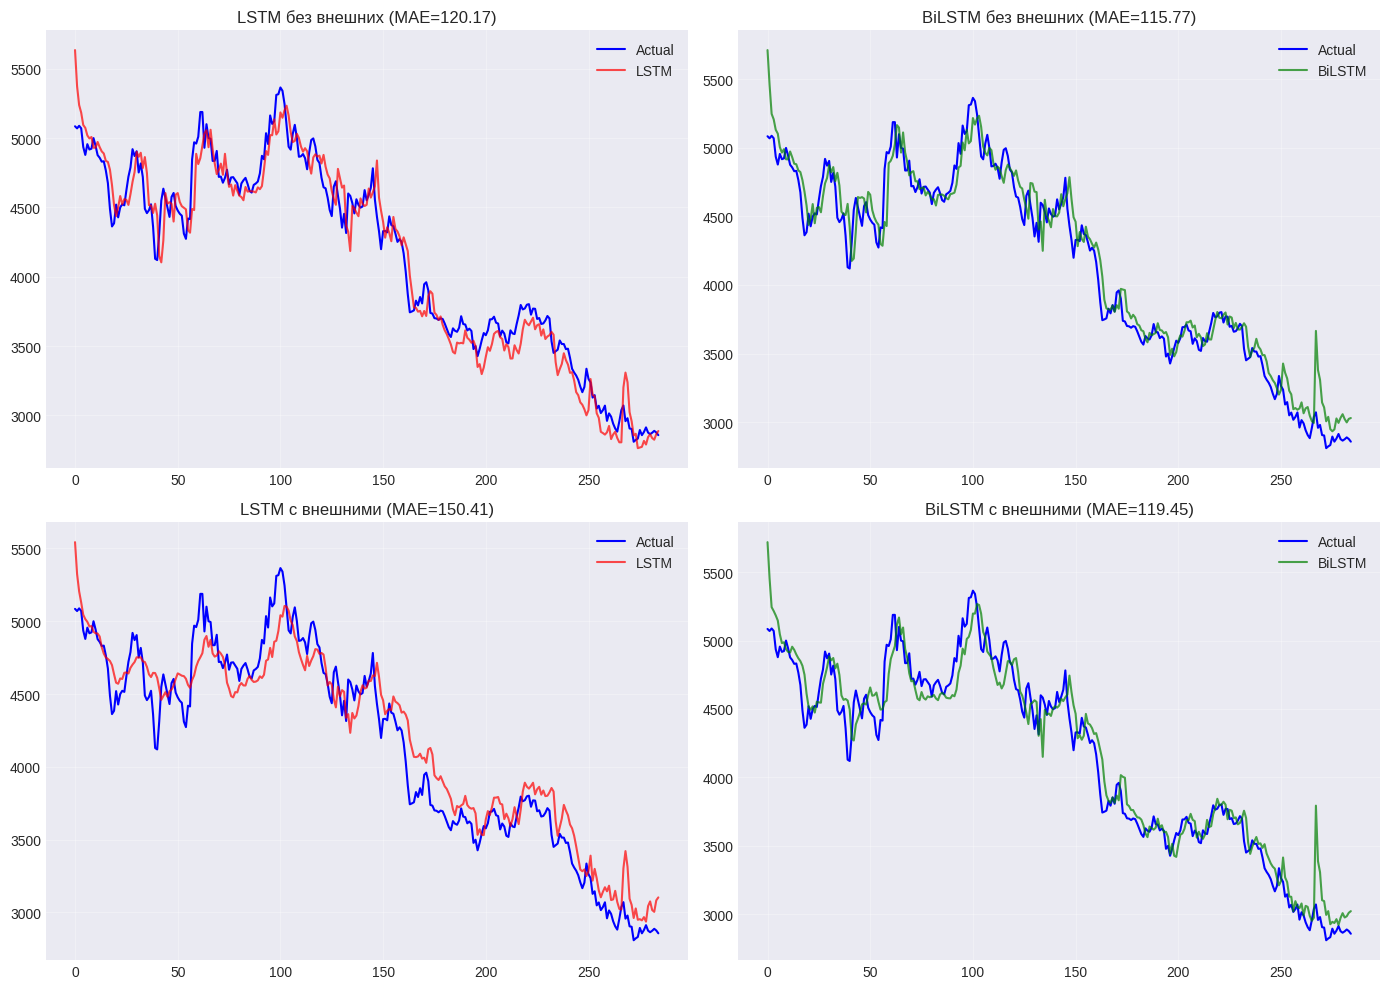


График сохранен: results_with_lags.png


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def create_features_magnit_only(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window, min_periods=1).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Открытие'].shift(1) + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5, min_periods=1).std()
    feature_columns.append('volatility')

    # ========== ЛАГОВЫЕ ОШИБКИ ==========
    df['error_proxy'] = df['Close_yesterday'] - df['Открытие'].shift(1)
    df['error_lag1'] = df['error_proxy'].shift(1)
    df['error_lag2'] = df['error_proxy'].shift(2)
    df['error_lag3'] = df['error_proxy'].shift(3)
    df['error_ma5'] = df['error_proxy'].rolling(5, min_periods=1).mean()
    df['error_std5'] = df['error_proxy'].rolling(5, min_periods=1).std()
    feature_columns.extend(['error_lag1', 'error_lag2', 'error_lag3', 'error_ma5', 'error_std5'])

    df['Close_today'] = df['Закрытие']

    df_clean = df.dropna(subset=['Close_today', 'Open_today']).fillna(0).reset_index(drop=True)
    return df_clean, feature_columns

def create_features_with_external(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    df['Currency_yesterday'] = df['Курс'].shift(1)
    df['Oil_yesterday'] = df['Значение'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday',
                            'Currency_yesterday', 'Oil_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window, min_periods=1).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    df['currency_pct_change'] = df['Currency_yesterday'].pct_change() * 100
    df['oil_pct_change'] = df['Oil_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change',
                            'currency_pct_change', 'oil_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Открытие'].shift(1) + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['close_currency_ratio'] = df['Close_yesterday'] / (df['Currency_yesterday'] + 1e-10)
    df['close_oil_ratio'] = df['Close_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    df['currency_oil_ratio'] = df['Currency_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    feature_columns.extend(['close_currency_ratio', 'close_oil_ratio', 'currency_oil_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5, min_periods=1).std()
    df['currency_volatility'] = df['Currency_yesterday'].rolling(5, min_periods=1).std()
    df['oil_volatility'] = df['Oil_yesterday'].rolling(5, min_periods=1).std()
    feature_columns.extend(['volatility', 'currency_volatility', 'oil_volatility'])

    df['Close_today'] = df['Закрытие']

    df_clean = df.dropna(subset=['Close_today', 'Open_today']).fillna(0).reset_index(drop=True)
    return df_clean, feature_columns

class StockDatasetFixed(Dataset):
    def __init__(self, features, target, sequence_length=10):
        self.features = features.astype(np.float32)
        self.target = target.astype(np.float32)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.features) - self.sequence_length

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.sequence_length]
        y = self.target[idx + self.sequence_length]
        return torch.FloatTensor(x), torch.FloatTensor([y])

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out[:, -1, :])
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out[:, -1, :])
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

def prepare_data(data_features, feature_cols):
    train_size = int(len(data_features) * 0.7)
    val_size = int(len(data_features) * 0.15)

    train_data = data_features.iloc[:train_size].copy()
    val_data = data_features.iloc[train_size:train_size+val_size].copy()
    test_data = data_features.iloc[train_size+val_size:].copy()

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    train_features = train_data[feature_cols].values
    train_target = train_data[['Close_today']].values

    train_features_scaled = feature_scaler.fit_transform(train_features)
    train_target_scaled = target_scaler.fit_transform(train_target).flatten()

    val_features_scaled = feature_scaler.transform(val_data[feature_cols].values)
    val_target_scaled = target_scaler.transform(val_data[['Close_today']].values).flatten()

    test_features_scaled = feature_scaler.transform(test_data[feature_cols].values)
    test_target_scaled = target_scaler.transform(test_data[['Close_today']].values).flatten()

    sequence_length = 10
    train_dataset = StockDatasetFixed(train_features_scaled, train_target_scaled, sequence_length)
    val_dataset = StockDatasetFixed(val_features_scaled, val_target_scaled, sequence_length)
    test_dataset = StockDatasetFixed(test_features_scaled, test_target_scaled, sequence_length)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    return train_loader, val_loader, test_loader, target_scaler

def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, wd=0.01, model_name="model"):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val_loss = float('inf')
    best_model_state = None
    patience = 15
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

    model.load_state_dict(best_model_state)
    return model

def evaluate_model(model, test_loader, target_scaler):
    device = next(model.parameters()).device
    model.eval()
    predictions, actuals = [], []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(batch_y.numpy())

    predictions = np.array(predictions).flatten()
    actuals = np.array(actuals).flatten()
    predictions_original = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    actuals_original = target_scaler.inverse_transform(actuals.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(actuals_original, predictions_original)
    rmse = np.sqrt(mean_squared_error(actuals_original, predictions_original))
    mape = np.mean(np.abs((actuals_original - predictions_original) / actuals_original)) * 100
    r2 = r2_score(actuals_original, predictions_original)

    return mae, rmse, mape, r2, predictions_original, actuals_original

def analyze_residuals(residuals, model_name):
    residuals = np.array(residuals).flatten()
    n = len(residuals)

    print(f"\nСтатистика ошибок: {model_name}")
    print(f"  Среднее: {np.mean(residuals):.2f}")
    print(f"  Стд.откл: {np.std(residuals):.2f}")
    print(f"  Асимметрия: {stats.skew(residuals):.3f}")
    print(f"  Эксцесс: {stats.kurtosis(residuals):.3f}")

    _, shapiro_p = stats.shapiro(residuals if n <= 5000 else np.random.choice(residuals, 5000))
    print(f"  Шапиро-Уилк p-value: {shapiro_p:.4f}")

    lb_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
    print(f"  Льюнг-Бокс p-value: {lb_result['lb_pvalue'].values[0]:.4f}")

    dw_stat = np.sum(np.diff(residuals)**2) / np.sum(residuals**2)
    print(f"  Дарбин-Ватсон: {dw_stat:.4f}")

print("\n" + "="*70)
print("LSTM & BiLSTM RESULTS (с лаговыми ошибками)")
print("="*70)

data_without, cols_without = create_features_magnit_only(result)
print(f"\nПризнаков без внешних: {len(cols_without)}")

train_loader_wo, val_loader_wo, test_loader_wo, target_scaler_wo = prepare_data(data_without, cols_without)

print("\n" + "-"*50)
print("LSTM без внешних")
print("-"*50)
lstm_wo = LSTMModel(len(cols_without), hidden_dim=64, num_layers=2, dropout=0.2)
lstm_wo = train_model(lstm_wo, train_loader_wo, val_loader_wo, epochs=100, lr=0.001, wd=0.01, model_name="LSTM_wo")
mae_lstm_wo, rmse_lstm_wo, mape_lstm_wo, r2_lstm_wo, pred_lstm_wo, act_lstm_wo = evaluate_model(lstm_wo, test_loader_wo, target_scaler_wo)
analyze_residuals(pred_lstm_wo - act_lstm_wo, "LSTM без внешних")

print("\n" + "-"*50)
print("BiLSTM без внешних")
print("-"*50)
bilstm_wo = BiLSTMModel(len(cols_without), hidden_dim=64, num_layers=2, dropout=0.3)
bilstm_wo = train_model(bilstm_wo, train_loader_wo, val_loader_wo, epochs=100, lr=0.0005, wd=0.05, model_name="BiLSTM_wo")
mae_bilstm_wo, rmse_bilstm_wo, mape_bilstm_wo, r2_bilstm_wo, pred_bilstm_wo, act_bilstm_wo = evaluate_model(bilstm_wo, test_loader_wo, target_scaler_wo)
analyze_residuals(pred_bilstm_wo - act_bilstm_wo, "BiLSTM без внешних")

data_with, cols_with = create_features_with_external(result)
print(f"\nПризнаков с внешними: {len(cols_with)}")

train_loader_w, val_loader_w, test_loader_w, target_scaler_w = prepare_data(data_with, cols_with)

print("\n" + "-"*50)
print("LSTM с внешними")
print("-"*50)
lstm_w = LSTMModel(len(cols_with), hidden_dim=64, num_layers=2, dropout=0.2)
lstm_w = train_model(lstm_w, train_loader_w, val_loader_w, epochs=100, lr=0.001, wd=0.01, model_name="LSTM_w")
mae_lstm_w, rmse_lstm_w, mape_lstm_w, r2_lstm_w, pred_lstm_w, act_lstm_w = evaluate_model(lstm_w, test_loader_w, target_scaler_w)
analyze_residuals(pred_lstm_w - act_lstm_w, "LSTM с внешними")

print("\n" + "-"*50)
print("BiLSTM с внешними")
print("-"*50)
bilstm_w = BiLSTMModel(len(cols_with), hidden_dim=64, num_layers=2, dropout=0.3)
bilstm_w = train_model(bilstm_w, train_loader_w, val_loader_w, epochs=100, lr=0.0005, wd=0.05, model_name="BiLSTM_w")
mae_bilstm_w, rmse_bilstm_w, mape_bilstm_w, r2_bilstm_w, pred_bilstm_w, act_bilstm_w = evaluate_model(bilstm_w, test_loader_w, target_scaler_w)
analyze_residuals(pred_bilstm_w - act_bilstm_w, "BiLSTM с внешними")

print("\n" + "="*70)
print("МЕТРИКИ")
print("="*70)
print(f"{'Модель':<20} {'MAE':>10} {'RMSE':>10} {'MAPE(%)':>10} {'R2':>10}")
print("-"*60)
print(f"{'LSTM без внешних':<20} {mae_lstm_wo:>10.2f} {rmse_lstm_wo:>10.2f} {mape_lstm_wo:>10.2f} {r2_lstm_wo:>10.4f}")
print(f"{'BiLSTM без внешних':<20} {mae_bilstm_wo:>10.2f} {rmse_bilstm_wo:>10.2f} {mape_bilstm_wo:>10.2f} {r2_bilstm_wo:>10.4f}")
print(f"{'LSTM с внешними':<20} {mae_lstm_w:>10.2f} {rmse_lstm_w:>10.2f} {mape_lstm_w:>10.2f} {r2_lstm_w:>10.4f}")
print(f"{'BiLSTM с внешними':<20} {mae_bilstm_w:>10.2f} {rmse_bilstm_w:>10.2f} {mape_bilstm_w:>10.2f} {r2_bilstm_w:>10.4f}")

models_mae = {
    'LSTM без внешних': mae_lstm_wo,
    'BiLSTM без внешних': mae_bilstm_wo,
    'LSTM с внешними': mae_lstm_w,
    'BiLSTM с внешними': mae_bilstm_w
}
best_model = min(models_mae, key=models_mae.get)
print(f"\nЛучшая модель: {best_model} с MAE = {models_mae[best_model]:.2f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(act_lstm_wo, label='Actual', linewidth=1.5, color='blue')
axes[0, 0].plot(pred_lstm_wo, label='LSTM', linewidth=1.5, color='red', alpha=0.7)
axes[0, 0].set_title(f'LSTM без внешних (MAE={mae_lstm_wo:.2f})')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(act_bilstm_wo, label='Actual', linewidth=1.5, color='blue')
axes[0, 1].plot(pred_bilstm_wo, label='BiLSTM', linewidth=1.5, color='green', alpha=0.7)
axes[0, 1].set_title(f'BiLSTM без внешних (MAE={mae_bilstm_wo:.2f})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(act_lstm_w, label='Actual', linewidth=1.5, color='blue')
axes[1, 0].plot(pred_lstm_w, label='LSTM', linewidth=1.5, color='red', alpha=0.7)
axes[1, 0].set_title(f'LSTM с внешними (MAE={mae_lstm_w:.2f})')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(act_bilstm_w, label='Actual', linewidth=1.5, color='blue')
axes[1, 1].plot(pred_bilstm_w, label='BiLSTM', linewidth=1.5, color='green', alpha=0.7)
axes[1, 1].set_title(f'BiLSTM с внешними (MAE={mae_bilstm_w:.2f})')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results_with_lags.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nГрафик сохранен: results_with_lags.png")


График сохранен: results_clean.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл отправлен на скачивание через google.colab.files.download()


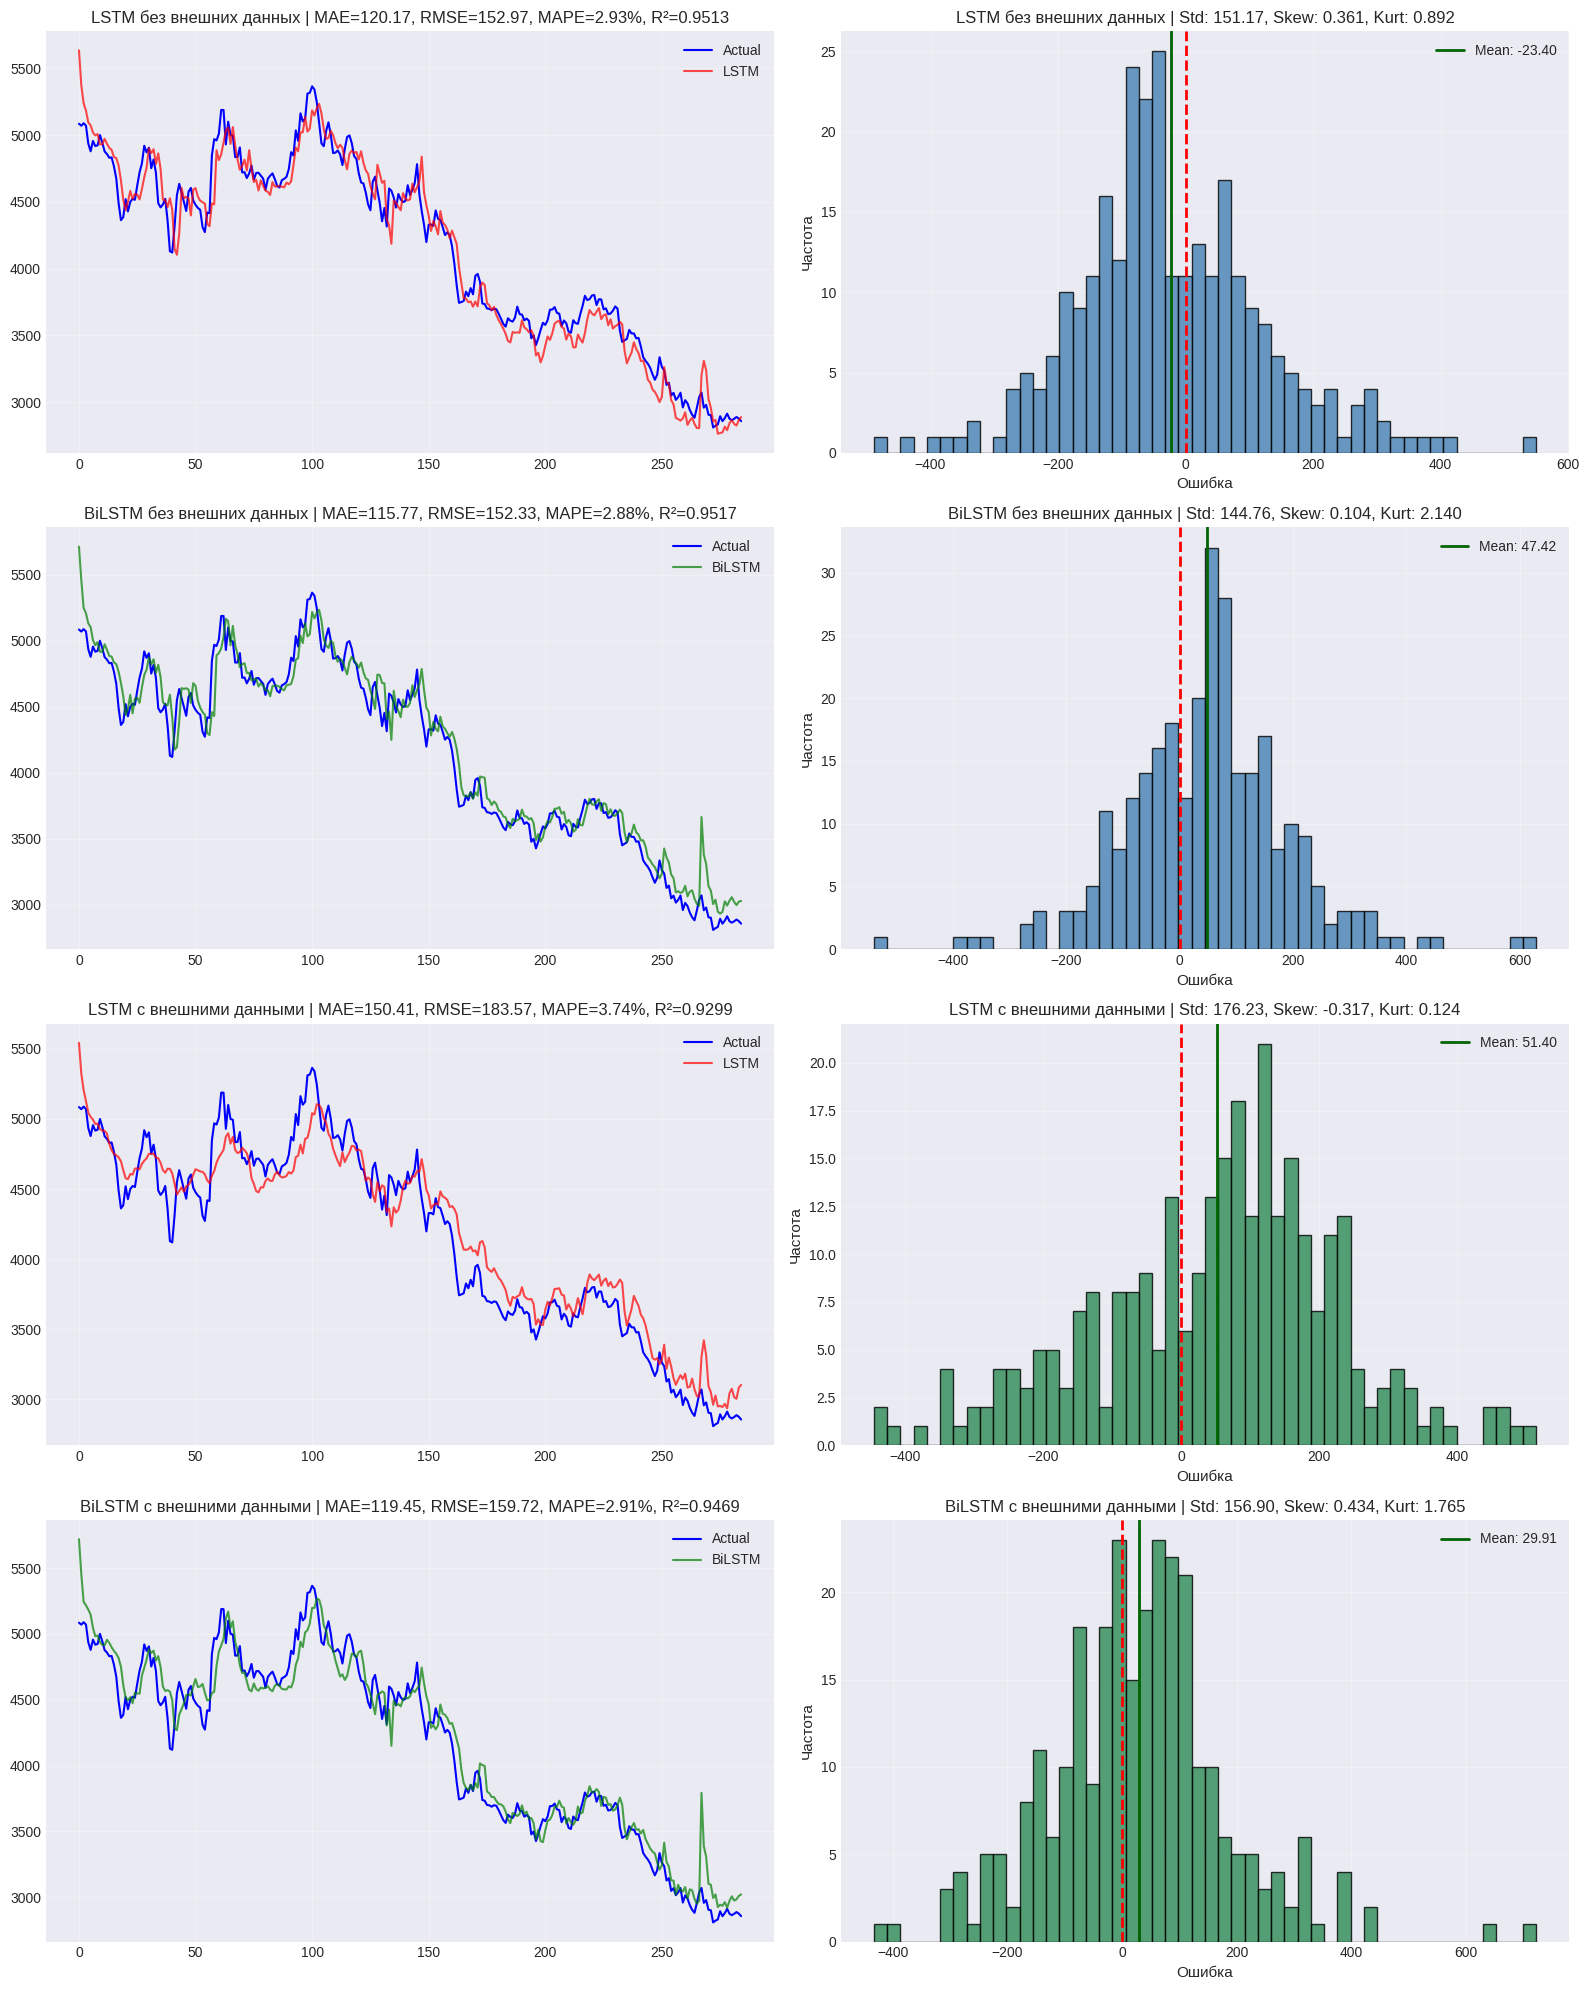

In [ ]:
# Замените конец кода (начиная с создания графиков) на этот:

fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# ========== LSTM без внешних ==========
# Предсказания
axes[0, 0].plot(act_lstm_wo, label='Actual', linewidth=1.5, color='blue')
axes[0, 0].plot(pred_lstm_wo, label='LSTM', linewidth=1.5, color='red', alpha=0.7)
axes[0, 0].set_title(f'LSTM без внешних данных | MAE={mae_lstm_wo:.2f}, RMSE={rmse_lstm_wo:.2f}, MAPE={mape_lstm_wo:.2f}%, R²={r2_lstm_wo:.4f}', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Распределение ошибок
errors_lstm_wo = pred_lstm_wo - act_lstm_wo
axes[0, 1].hist(errors_lstm_wo, bins=50, alpha=0.8, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=np.mean(errors_lstm_wo), color='darkgreen', linestyle='-', linewidth=2, label=f'Mean: {np.mean(errors_lstm_wo):.2f}')
axes[0, 1].set_xlabel('Ошибка', fontsize=11)
axes[0, 1].set_ylabel('Частота', fontsize=11)
axes[0, 1].set_title(f'LSTM без внешних данных | Std: {np.std(errors_lstm_wo):.2f}, Skew: {stats.skew(errors_lstm_wo):.3f}, Kurt: {stats.kurtosis(errors_lstm_wo):.3f}', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ========== BiLSTM без внешних ==========
# Предсказания
axes[1, 0].plot(act_bilstm_wo, label='Actual', linewidth=1.5, color='blue')
axes[1, 0].plot(pred_bilstm_wo, label='BiLSTM', linewidth=1.5, color='green', alpha=0.7)
axes[1, 0].set_title(f'BiLSTM без внешних данных | MAE={mae_bilstm_wo:.2f}, RMSE={rmse_bilstm_wo:.2f}, MAPE={mape_bilstm_wo:.2f}%, R²={r2_bilstm_wo:.4f}', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Распределение ошибок
errors_bilstm_wo = pred_bilstm_wo - act_bilstm_wo
axes[1, 1].hist(errors_bilstm_wo, bins=50, alpha=0.8, color='steelblue', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].axvline(x=np.mean(errors_bilstm_wo), color='darkgreen', linestyle='-', linewidth=2, label=f'Mean: {np.mean(errors_bilstm_wo):.2f}')
axes[1, 1].set_xlabel('Ошибка', fontsize=11)
axes[1, 1].set_ylabel('Частота', fontsize=11)
axes[1, 1].set_title(f'BiLSTM без внешних данных | Std: {np.std(errors_bilstm_wo):.2f}, Skew: {stats.skew(errors_bilstm_wo):.3f}, Kurt: {stats.kurtosis(errors_bilstm_wo):.3f}', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# ========== LSTM с внешними ==========
# Предсказания
axes[2, 0].plot(act_lstm_w, label='Actual', linewidth=1.5, color='blue')
axes[2, 0].plot(pred_lstm_w, label='LSTM', linewidth=1.5, color='red', alpha=0.7)
axes[2, 0].set_title(f'LSTM с внешними данными | MAE={mae_lstm_w:.2f}, RMSE={rmse_lstm_w:.2f}, MAPE={mape_lstm_w:.2f}%, R²={r2_lstm_w:.4f}', fontsize=12)
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# Распределение ошибок
errors_lstm_w = pred_lstm_w - act_lstm_w
axes[2, 1].hist(errors_lstm_w, bins=50, alpha=0.8, color='seagreen', edgecolor='black')
axes[2, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2, 1].axvline(x=np.mean(errors_lstm_w), color='darkgreen', linestyle='-', linewidth=2, label=f'Mean: {np.mean(errors_lstm_w):.2f}')
axes[2, 1].set_xlabel('Ошибка', fontsize=11)
axes[2, 1].set_ylabel('Частота', fontsize=11)
axes[2, 1].set_title(f'LSTM с внешними данными | Std: {np.std(errors_lstm_w):.2f}, Skew: {stats.skew(errors_lstm_w):.3f}, Kurt: {stats.kurtosis(errors_lstm_w):.3f}', fontsize=12)
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

# ========== BiLSTM с внешними ==========
# Предсказания
axes[3, 0].plot(act_bilstm_w, label='Actual', linewidth=1.5, color='blue')
axes[3, 0].plot(pred_bilstm_w, label='BiLSTM', linewidth=1.5, color='green', alpha=0.7)
axes[3, 0].set_title(f'BiLSTM с внешними данными | MAE={mae_bilstm_w:.2f}, RMSE={rmse_bilstm_w:.2f}, MAPE={mape_bilstm_w:.2f}%, R²={r2_bilstm_w:.4f}', fontsize=12)
axes[3, 0].legend()
axes[3, 0].grid(True, alpha=0.3)

# Распределение ошибок
errors_bilstm_w = pred_bilstm_w - act_bilstm_w
axes[3, 1].hist(errors_bilstm_w, bins=50, alpha=0.8, color='seagreen', edgecolor='black')
axes[3, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[3, 1].axvline(x=np.mean(errors_bilstm_w), color='darkgreen', linestyle='-', linewidth=2, label=f'Mean: {np.mean(errors_bilstm_w):.2f}')
axes[3, 1].set_xlabel('Ошибка', fontsize=11)
axes[3, 1].set_ylabel('Частота', fontsize=11)
axes[3, 1].set_title(f'BiLSTM с внешними данными | Std: {np.std(errors_bilstm_w):.2f}, Skew: {stats.skew(errors_bilstm_w):.3f}, Kurt: {stats.kurtosis(errors_bilstm_w):.3f}', fontsize=12)
axes[3, 1].legend()
axes[3, 1].grid(True, alpha=0.3)

plt.tight_layout()

# Сохранение
plt.savefig('results_clean.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/results_clean.png', dpi=150, bbox_inches='tight')
print("\nГрафик сохранен: results_clean.png")

# ПРИНУДИТЕЛЬНОЕ СКАЧИВАНИЕ ДЛЯ GOOGLE COLAB
try:
    from google.colab import files
    files.download('results_clean.png')
    print("Файл отправлен на скачивание через google.colab.files.download()")
except:
    print("Не в Colab или ошибка скачивания. Файл сохранен локально.")

plt.show()

In [ ]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\n" + "="*80)
print("СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*80)

errors_lstm_wo = pred_lstm_wo - act_lstm_wo
errors_lstm_w = pred_lstm_w - act_lstm_w
errors_bilstm_wo = pred_bilstm_wo - act_bilstm_wo
errors_bilstm_w = pred_bilstm_w - act_bilstm_w

# ============================================
# 1. LSTM без внешних vs LSTM с внешними
# ============================================
print("\n" + "="*60)
print("1. СРАВНЕНИЕ LSTM: БЕЗ ВНЕШНИХ vs С ВНЕШНИМИ")
print("="*60)

print(f"\nМетрики LSTM без внешних:")
print(f"  MAE:  {mae_lstm_wo:.2f}")
print(f"  RMSE: {rmse_lstm_wo:.2f}")
print(f"  MAPE: {mape_lstm_wo:.2f}%")
print(f"  R²:   {r2_lstm_wo:.4f}")

print(f"\nМетрики LSTM с внешними:")
print(f"  MAE:  {mae_lstm_w:.2f}")
print(f"  RMSE: {rmse_lstm_w:.2f}")
print(f"  MAPE: {mape_lstm_w:.2f}%")
print(f"  R²:   {r2_lstm_w:.4f}")

print(f"\nРазница (с внешними - без внешних):")
print(f"  MAE:  {mae_lstm_w - mae_lstm_wo:+.2f} ({(mae_lstm_w/mae_lstm_wo - 1)*100:+.1f}%)")
print(f"  RMSE: {rmse_lstm_w - rmse_lstm_wo:+.2f} ({(rmse_lstm_w/rmse_lstm_wo - 1)*100:+.1f}%)")

# Статистика распределения
print(f"\nСтатистика распределения ошибок LSTM без внешних:")
print(f"  Среднее:    {np.mean(errors_lstm_wo):.2f}")
print(f"  Стд.откл:   {np.std(errors_lstm_wo):.2f}")
print(f"  Асимметрия: {stats.skew(errors_lstm_wo):.3f}")
print(f"  Эксцесс:    {stats.kurtosis(errors_lstm_wo):.3f}")

# Шапиро-Уилк
n = len(errors_lstm_wo)
if n > 5000:
    sample = np.random.choice(errors_lstm_wo, 5000, replace=False)
    shapiro_stat, shapiro_p = stats.shapiro(sample)
else:
    shapiro_stat, shapiro_p = stats.shapiro(errors_lstm_wo)
print(f"  Шапиро-Уилк: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")

# Колмогоров-Смирнов
ks_stat, ks_p = stats.kstest(errors_lstm_wo, 'norm', args=(np.mean(errors_lstm_wo), np.std(errors_lstm_wo)))
print(f"  Колмогоров-Смирнов: stat={ks_stat:.4f}, p={ks_p:.4f}")

# Белый шум (Льюнг-Бокс)
lb_result = acorr_ljungbox(errors_lstm_wo, lags=[10], return_df=True)
lb_p = lb_result['lb_pvalue'].values[0]
print(f"  Льюнг-Бокс (белый шум): p={lb_p:.4f}")

print(f"\nСтатистика распределения ошибок LSTM с внешними:")
print(f"  Среднее:    {np.mean(errors_lstm_w):.2f}")
print(f"  Стд.откл:   {np.std(errors_lstm_w):.2f}")
print(f"  Асимметрия: {stats.skew(errors_lstm_w):.3f}")
print(f"  Эксцесс:    {stats.kurtosis(errors_lstm_w):.3f}")

n = len(errors_lstm_w)
if n > 5000:
    sample = np.random.choice(errors_lstm_w, 5000, replace=False)
    shapiro_stat, shapiro_p = stats.shapiro(sample)
else:
    shapiro_stat, shapiro_p = stats.shapiro(errors_lstm_w)
print(f"  Шапиро-Уилк: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")

ks_stat, ks_p = stats.kstest(errors_lstm_w, 'norm', args=(np.mean(errors_lstm_w), np.std(errors_lstm_w)))
print(f"  Колмогоров-Смирнов: stat={ks_stat:.4f}, p={ks_p:.4f}")

lb_result = acorr_ljungbox(errors_lstm_w, lags=[10], return_df=True)
lb_p = lb_result['lb_pvalue'].values[0]
print(f"  Льюнг-Бокс (белый шум): p={lb_p:.4f}")

# Тест Уилкоксона
stat, p = stats.wilcoxon(np.abs(errors_lstm_wo), np.abs(errors_lstm_w))
print(f"\nТест Уилкоксона (абсолютные ошибки): p={p:.6f}")
if p < 0.05:
    if mae_lstm_wo < mae_lstm_w:
        print("  >>> LSTM БЕЗ внешних ЗНАЧИМО ЛУЧШЕ")
    else:
        print("  >>> LSTM С внешними ЗНАЧИМО ЛУЧШЕ")
else:
    print("  >>> Различие НЕ значимо")

# Тест знаков
diff_abs = np.abs(errors_lstm_wo) - np.abs(errors_lstm_w)
n_better_wo = np.sum(diff_abs < 0)
n_better_w = np.sum(diff_abs > 0)
sign_result = stats.binomtest(n_better_wo, n_better_wo + n_better_w, p=0.5)
print(f"\nТест знаков: без={n_better_wo}, с={n_better_w}, p={sign_result.pvalue:.6f}")

# ============================================
# 2. BiLSTM без внешних vs BiLSTM с внешними
# ============================================
print("\n" + "="*60)
print("2. СРАВНЕНИЕ BiLSTM: БЕЗ ВНЕШНИХ vs С ВНЕШНИМИ")
print("="*60)

print(f"\nМетрики BiLSTM без внешних:")
print(f"  MAE:  {mae_bilstm_wo:.2f}")
print(f"  RMSE: {rmse_bilstm_wo:.2f}")
print(f"  MAPE: {mape_bilstm_wo:.2f}%")
print(f"  R²:   {r2_bilstm_wo:.4f}")

print(f"\nМетрики BiLSTM с внешними:")
print(f"  MAE:  {mae_bilstm_w:.2f}")
print(f"  RMSE: {rmse_bilstm_w:.2f}")
print(f"  MAPE: {mape_bilstm_w:.2f}%")
print(f"  R²:   {r2_bilstm_w:.4f}")

print(f"\nРазница (с внешними - без внешних):")
print(f"  MAE:  {mae_bilstm_w - mae_bilstm_wo:+.2f} ({(mae_bilstm_w/mae_bilstm_wo - 1)*100:+.1f}%)")
print(f"  RMSE: {rmse_bilstm_w - rmse_bilstm_wo:+.2f} ({(rmse_bilstm_w/rmse_bilstm_wo - 1)*100:+.1f}%)")

# Статистика распределения
print(f"\nСтатистика распределения ошибок BiLSTM без внешних:")
print(f"  Среднее:    {np.mean(errors_bilstm_wo):.2f}")
print(f"  Стд.откл:   {np.std(errors_bilstm_wo):.2f}")
print(f"  Асимметрия: {stats.skew(errors_bilstm_wo):.3f}")
print(f"  Эксцесс:    {stats.kurtosis(errors_bilstm_wo):.3f}")

n = len(errors_bilstm_wo)
if n > 5000:
    sample = np.random.choice(errors_bilstm_wo, 5000, replace=False)
    shapiro_stat, shapiro_p = stats.shapiro(sample)
else:
    shapiro_stat, shapiro_p = stats.shapiro(errors_bilstm_wo)
print(f"  Шапиро-Уилк: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")

ks_stat, ks_p = stats.kstest(errors_bilstm_wo, 'norm', args=(np.mean(errors_bilstm_wo), np.std(errors_bilstm_wo)))
print(f"  Колмогоров-Смирнов: stat={ks_stat:.4f}, p={ks_p:.4f}")

lb_result = acorr_ljungbox(errors_bilstm_wo, lags=[10], return_df=True)
lb_p = lb_result['lb_pvalue'].values[0]
print(f"  Льюнг-Бокс (белый шум): p={lb_p:.4f}")

print(f"\nСтатистика распределения ошибок BiLSTM с внешними:")
print(f"  Среднее:    {np.mean(errors_bilstm_w):.2f}")
print(f"  Стд.откл:   {np.std(errors_bilstm_w):.2f}")
print(f"  Асимметрия: {stats.skew(errors_bilstm_w):.3f}")
print(f"  Эксцесс:    {stats.kurtosis(errors_bilstm_w):.3f}")

n = len(errors_bilstm_w)
if n > 5000:
    sample = np.random.choice(errors_bilstm_w, 5000, replace=False)
    shapiro_stat, shapiro_p = stats.shapiro(sample)
else:
    shapiro_stat, shapiro_p = stats.shapiro(errors_bilstm_w)
print(f"  Шапиро-Уилк: stat={shapiro_stat:.4f}, p={shapiro_p:.4f}")

ks_stat, ks_p = stats.kstest(errors_bilstm_w, 'norm', args=(np.mean(errors_bilstm_w), np.std(errors_bilstm_w)))
print(f"  Колмогоров-Смирнов: stat={ks_stat:.4f}, p={ks_p:.4f}")

lb_result = acorr_ljungbox(errors_bilstm_w, lags=[10], return_df=True)
lb_p = lb_result['lb_pvalue'].values[0]
print(f"  Льюнг-Бокс (белый шум): p={lb_p:.4f}")

# Тест Уилкоксона
stat, p = stats.wilcoxon(np.abs(errors_bilstm_wo), np.abs(errors_bilstm_w))
print(f"\nТест Уилкоксона (абсолютные ошибки): p={p:.6f}")
if p < 0.05:
    if mae_bilstm_wo < mae_bilstm_w:
        print("  >>> BiLSTM БЕЗ внешних ЗНАЧИМО ЛУЧШЕ")
    else:
        print("  >>> BiLSTM С внешними ЗНАЧИМО ЛУЧШЕ")
else:
    print("  >>> Различие НЕ значимо")

# Тест знаков
diff_abs = np.abs(errors_bilstm_wo) - np.abs(errors_bilstm_w)
n_better_wo = np.sum(diff_abs < 0)
n_better_w = np.sum(diff_abs > 0)
sign_result = stats.binomtest(n_better_wo, n_better_wo + n_better_w, p=0.5)
print(f"\nТест знаков: без={n_better_wo}, с={n_better_w}, p={sign_result.pvalue:.6f}")

# ============================================
# ИТОГ
# ============================================
print("\n" + "="*60)
print("ИТОГ СРАВНЕНИЯ")
print("="*60)

print("\nСводка по MAE:")
print(f"  LSTM:   без внешних = {mae_lstm_wo:.2f}, с внешними = {mae_lstm_w:.2f} -> разница {mae_lstm_w - mae_lstm_wo:+.2f}")
print(f"  BiLSTM: без внешних = {mae_bilstm_wo:.2f}, с внешними = {mae_bilstm_w:.2f} -> разница {mae_bilstm_w - mae_bilstm_wo:+.2f}")

print("\nВывод:")
if mae_lstm_wo < mae_lstm_w and mae_bilstm_wo < mae_bilstm_w:
    print("  Внешние факторы УХУДШАЮТ обе модели.")
    print("  Рекомендуется использовать модели БЕЗ внешних факторов.")
elif mae_lstm_wo > mae_lstm_w and mae_bilstm_wo > mae_bilstm_w:
    print("  Внешние факторы УЛУЧШАЮТ обе модели.")
    print("  Рекомендуется использовать модели С внешними факторами.")
else:
    print("  Влияние внешних факторов неоднозначно.")


СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ МОДЕЛЕЙ

1. СРАВНЕНИЕ LSTM: БЕЗ ВНЕШНИХ vs С ВНЕШНИМИ

Метрики LSTM без внешних:
  MAE:  120.17
  RMSE: 152.97
  MAPE: 2.93%
  R²:   0.9513

Метрики LSTM с внешними:
  MAE:  150.41
  RMSE: 183.57
  MAPE: 3.74%
  R²:   0.9299

Разница (с внешними - без внешних):
  MAE:  +30.23 (+25.2%)
  RMSE: +30.60 (+20.0%)

Статистика распределения ошибок LSTM без внешних:
  Среднее:    -23.40
  Стд.откл:   151.17
  Асимметрия: 0.361
  Эксцесс:    0.892
  Шапиро-Уилк: stat=0.9845, p=0.0036
  Колмогоров-Смирнов: stat=0.0712, p=0.1058
  Льюнг-Бокс (белый шум): p=0.0000

Статистика распределения ошибок LSTM с внешними:
  Среднее:    51.40
  Стд.откл:   176.23
  Асимметрия: -0.317
  Эксцесс:    0.124
  Шапиро-Уилк: stat=0.9850, p=0.0045
  Колмогоров-Смирнов: stat=0.0771, p=0.0642
  Льюнг-Бокс (белый шум): p=0.0000

Тест Уилкоксона (абсолютные ошибки): p=0.000011
  >>> LSTM БЕЗ внешних ЗНАЧИМО ЛУЧШЕ

Тест знаков: без=170, с=115, p=0.001339

2. СРАВНЕНИЕ BiLSTM: БЕЗ ВНЕШНИХ vs С В


LSTM & BiLSTM RESULTS

Признаков без внешних: 20

--------------------------------------------------
LSTM без внешних
--------------------------------------------------
Epoch  20 | Train: 0.094906 | Val: 0.435677
Early stopping at epoch 38

--------------------------------------------------
BiLSTM без внешних
--------------------------------------------------
Epoch  20 | Train: 0.092994 | Val: 0.615375
Epoch  40 | Train: 0.083059 | Val: 0.459833
Early stopping at epoch 44

Признаков с внешними: 29

--------------------------------------------------
LSTM с внешними
--------------------------------------------------
Epoch  20 | Train: 0.102145 | Val: 0.953103
Epoch  40 | Train: 0.082886 | Val: 0.569868
Early stopping at epoch 46

--------------------------------------------------
BiLSTM с внешними
--------------------------------------------------
Epoch  20 | Train: 0.092575 | Val: 0.764873
Epoch  40 | Train: 0.085749 | Val: 0.329307
Early stopping at epoch 47

МЕТРИКИ
Модель           

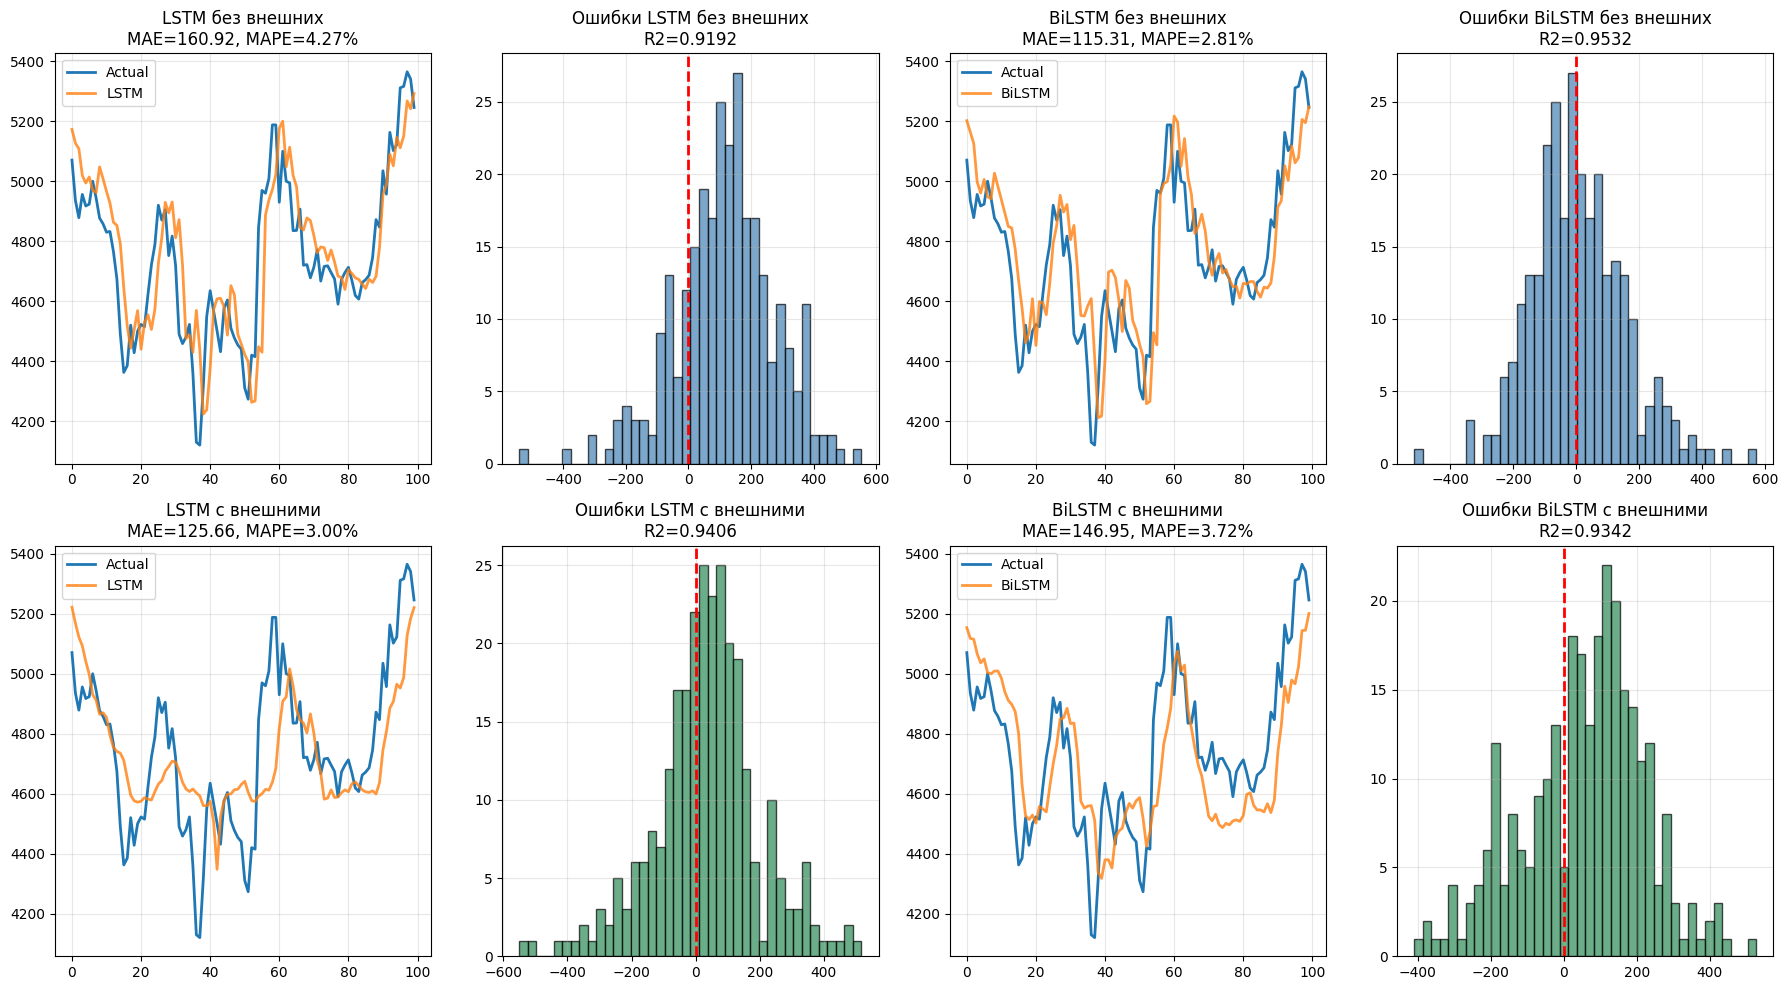


Лучшая модель: BiLSTM без внешних с MAE = 115.31


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def create_features_magnit_only(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Открытие'].shift(1) + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5).std()
    feature_columns.append('volatility')

    df['Close_today'] = df['Закрытие']

    df_clean = df[feature_columns + ['Close_today']].dropna().reset_index(drop=True)
    return df_clean, feature_columns

def create_features_with_external(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    df['Currency_yesterday'] = df['Курс'].shift(1)
    df['Oil_yesterday'] = df['Значение'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday',
                            'Currency_yesterday', 'Oil_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    df['currency_pct_change'] = df['Currency_yesterday'].pct_change() * 100
    df['oil_pct_change'] = df['Oil_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change',
                            'currency_pct_change', 'oil_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Открытие'].shift(1) + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['close_currency_ratio'] = df['Close_yesterday'] / (df['Currency_yesterday'] + 1e-10)
    df['close_oil_ratio'] = df['Close_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    df['currency_oil_ratio'] = df['Currency_yesterday'] / (df['Oil_yesterday'] + 1e-10)
    feature_columns.extend(['close_currency_ratio', 'close_oil_ratio', 'currency_oil_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5).std()
    df['currency_volatility'] = df['Currency_yesterday'].rolling(5).std()
    df['oil_volatility'] = df['Oil_yesterday'].rolling(5).std()
    feature_columns.extend(['volatility', 'currency_volatility', 'oil_volatility'])

    df['Close_today'] = df['Закрытие']

    df_clean = df[feature_columns + ['Close_today']].dropna().reset_index(drop=True)
    return df_clean, feature_columns

class StockDatasetFixed(Dataset):
    def __init__(self, features, target, sequence_length=10):
        self.features = features.astype(np.float32)
        self.target = target.astype(np.float32)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.features) - self.sequence_length

    def __getitem__(self, idx):
        x = self.features[idx:idx + self.sequence_length]
        y = self.target[idx + self.sequence_length]
        return torch.FloatTensor(x), torch.FloatTensor([y])

class LSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out[:, -1, :])
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

class BiLSTMModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0, bidirectional=True)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        x = self.dropout(lstm_out[:, -1, :])
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

def prepare_data(data_features, feature_cols):
    train_size = int(len(data_features) * 0.7)
    val_size = int(len(data_features) * 0.15)

    train_data = data_features.iloc[:train_size].copy()
    val_data = data_features.iloc[train_size:train_size+val_size].copy()
    test_data = data_features.iloc[train_size+val_size:].copy()

    feature_scaler = StandardScaler()
    target_scaler = StandardScaler()

    train_features = train_data[feature_cols].values
    train_target = train_data[['Close_today']].values

    train_features_scaled = feature_scaler.fit_transform(train_features)
    train_target_scaled = target_scaler.fit_transform(train_target).flatten()

    val_features_scaled = feature_scaler.transform(val_data[feature_cols].values)
    val_target_scaled = target_scaler.transform(val_data[['Close_today']].values).flatten()

    test_features_scaled = feature_scaler.transform(test_data[feature_cols].values)
    test_target_scaled = target_scaler.transform(test_data[['Close_today']].values).flatten()

    sequence_length = 10
    train_dataset = StockDatasetFixed(train_features_scaled, train_target_scaled, sequence_length)
    val_dataset = StockDatasetFixed(val_features_scaled, val_target_scaled, sequence_length)
    test_dataset = StockDatasetFixed(test_features_scaled, test_target_scaled, sequence_length)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

    return train_loader, val_loader, test_loader, target_scaler

def train_model(model, train_loader, val_loader, epochs=100, lr=0.001, wd=0.01, model_name="model"):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_val_loss = float('inf')
    best_model_state = None
    patience = 15
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                val_loss += criterion(outputs, batch_y).item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f}")

    model.load_state_dict(best_model_state)
    return model

def evaluate_model(model, test_loader, target_scaler):
    device = next(model.parameters()).device
    model.eval()
    predictions, actuals = [], []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(batch_y.numpy())

    predictions = np.array(predictions).flatten()
    actuals = np.array(actuals).flatten()
    predictions_original = target_scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    actuals_original = target_scaler.inverse_transform(actuals.reshape(-1, 1)).flatten()

    mae = mean_absolute_error(actuals_original, predictions_original)
    rmse = np.sqrt(mean_squared_error(actuals_original, predictions_original))
    mape = np.mean(np.abs((actuals_original - predictions_original) / actuals_original)) * 100
    r2 = r2_score(actuals_original, predictions_original)

    return mae, rmse, mape, r2, predictions_original, actuals_original

print("\n" + "="*70)
print("LSTM & BiLSTM RESULTS")
print("="*70)

data_without, cols_without = create_features_magnit_only(result)
print(f"\nПризнаков без внешних: {len(cols_without)}")

train_loader_wo, val_loader_wo, test_loader_wo, target_scaler_wo = prepare_data(data_without, cols_without)

print("\n" + "-"*50)
print("LSTM без внешних")
print("-"*50)
lstm_wo = LSTMModel(len(cols_without), hidden_dim=64, num_layers=2, dropout=0.2)
lstm_wo = train_model(lstm_wo, train_loader_wo, val_loader_wo, epochs=100, lr=0.001, wd=0.01, model_name="LSTM_wo")
mae_lstm_wo, rmse_lstm_wo, mape_lstm_wo, r2_lstm_wo, pred_lstm_wo, act_lstm_wo = evaluate_model(lstm_wo, test_loader_wo, target_scaler_wo)

print("\n" + "-"*50)
print("BiLSTM без внешних")
print("-"*50)
bilstm_wo = BiLSTMModel(len(cols_without), hidden_dim=64, num_layers=2, dropout=0.3)
bilstm_wo = train_model(bilstm_wo, train_loader_wo, val_loader_wo, epochs=100, lr=0.0005, wd=0.05, model_name="BiLSTM_wo")
mae_bilstm_wo, rmse_bilstm_wo, mape_bilstm_wo, r2_bilstm_wo, pred_bilstm_wo, act_bilstm_wo = evaluate_model(bilstm_wo, test_loader_wo, target_scaler_wo)

data_with, cols_with = create_features_with_external(result)
print(f"\nПризнаков с внешними: {len(cols_with)}")

train_loader_w, val_loader_w, test_loader_w, target_scaler_w = prepare_data(data_with, cols_with)

print("\n" + "-"*50)
print("LSTM с внешними")
print("-"*50)
lstm_w = LSTMModel(len(cols_with), hidden_dim=64, num_layers=2, dropout=0.2)
lstm_w = train_model(lstm_w, train_loader_w, val_loader_w, epochs=100, lr=0.001, wd=0.01, model_name="LSTM_w")
mae_lstm_w, rmse_lstm_w, mape_lstm_w, r2_lstm_w, pred_lstm_w, act_lstm_w = evaluate_model(lstm_w, test_loader_w, target_scaler_w)

print("\n" + "-"*50)
print("BiLSTM с внешними")
print("-"*50)
bilstm_w = BiLSTMModel(len(cols_with), hidden_dim=64, num_layers=2, dropout=0.3)
bilstm_w = train_model(bilstm_w, train_loader_w, val_loader_w, epochs=100, lr=0.0005, wd=0.05, model_name="BiLSTM_w")
mae_bilstm_w, rmse_bilstm_w, mape_bilstm_w, r2_bilstm_w, pred_bilstm_w, act_bilstm_w = evaluate_model(bilstm_w, test_loader_w, target_scaler_w)

print("\n" + "="*70)
print("МЕТРИКИ")
print("="*70)
print(f"{'Модель':<20} {'MAE':>10} {'RMSE':>10} {'MAPE(%)':>10} {'R2':>10}")
print("-"*60)
print(f"{'LSTM без внешних':<20} {mae_lstm_wo:>10.2f} {rmse_lstm_wo:>10.2f} {mape_lstm_wo:>10.2f} {r2_lstm_wo:>10.4f}")
print(f"{'BiLSTM без внешних':<20} {mae_bilstm_wo:>10.2f} {rmse_bilstm_wo:>10.2f} {mape_bilstm_wo:>10.2f} {r2_bilstm_wo:>10.4f}")
print(f"{'LSTM с внешними':<20} {mae_lstm_w:>10.2f} {rmse_lstm_w:>10.2f} {mape_lstm_w:>10.2f} {r2_lstm_w:>10.4f}")
print(f"{'BiLSTM с внешними':<20} {mae_bilstm_w:>10.2f} {rmse_bilstm_w:>10.2f} {mape_bilstm_w:>10.2f} {r2_bilstm_w:>10.4f}")

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

axes[0, 0].plot(act_lstm_wo[:100], label='Actual', linewidth=2)
axes[0, 0].plot(pred_lstm_wo[:100], label='LSTM', linewidth=2, alpha=0.8)
axes[0, 0].set_title(f'LSTM без внешних\nMAE={mae_lstm_wo:.2f}, MAPE={mape_lstm_wo:.2f}%')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

errors1 = pred_lstm_wo - act_lstm_wo
axes[0, 1].hist(errors1, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title(f'Ошибки LSTM без внешних\nR2={r2_lstm_wo:.4f}')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(act_bilstm_wo[:100], label='Actual', linewidth=2)
axes[0, 2].plot(pred_bilstm_wo[:100], label='BiLSTM', linewidth=2, alpha=0.8)
axes[0, 2].set_title(f'BiLSTM без внешних\nMAE={mae_bilstm_wo:.2f}, MAPE={mape_bilstm_wo:.2f}%')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

errors2 = pred_bilstm_wo - act_bilstm_wo
axes[0, 3].hist(errors2, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 3].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 3].set_title(f'Ошибки BiLSTM без внешних\nR2={r2_bilstm_wo:.4f}')
axes[0, 3].grid(True, alpha=0.3)

axes[1, 0].plot(act_lstm_w[:100], label='Actual', linewidth=2)
axes[1, 0].plot(pred_lstm_w[:100], label='LSTM', linewidth=2, alpha=0.8)
axes[1, 0].set_title(f'LSTM с внешними\nMAE={mae_lstm_w:.2f}, MAPE={mape_lstm_w:.2f}%')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

errors3 = pred_lstm_w - act_lstm_w
axes[1, 1].hist(errors3, bins=40, alpha=0.7, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title(f'Ошибки LSTM с внешними\nR2={r2_lstm_w:.4f}')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(act_bilstm_w[:100], label='Actual', linewidth=2)
axes[1, 2].plot(pred_bilstm_w[:100], label='BiLSTM', linewidth=2, alpha=0.8)
axes[1, 2].set_title(f'BiLSTM с внешними\nMAE={mae_bilstm_w:.2f}, MAPE={mape_bilstm_w:.2f}%')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

errors4 = pred_bilstm_w - act_bilstm_w
axes[1, 3].hist(errors4, bins=40, alpha=0.7, color='seagreen', edgecolor='black')
axes[1, 3].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 3].set_title(f'Ошибки BiLSTM с внешними\nR2={r2_bilstm_w:.4f}')
axes[1, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results.png', dpi=150, bbox_inches='tight')
plt.show()

models_mae = {
    'LSTM без внешних': mae_lstm_wo,
    'BiLSTM без внешних': mae_bilstm_wo,
    'LSTM с внешними': mae_lstm_w,
    'BiLSTM с внешними': mae_bilstm_w
}
best_model = min(models_mae, key=models_mae.get)
print(f"\nЛучшая модель: {best_model} с MAE = {models_mae[best_model]:.2f}")

Файл сохранен:
  - results_full_test.png
  - /content/results_full_test.png
  ✓ Файл существует: results_full_test.png
    Размер: 347716 байт


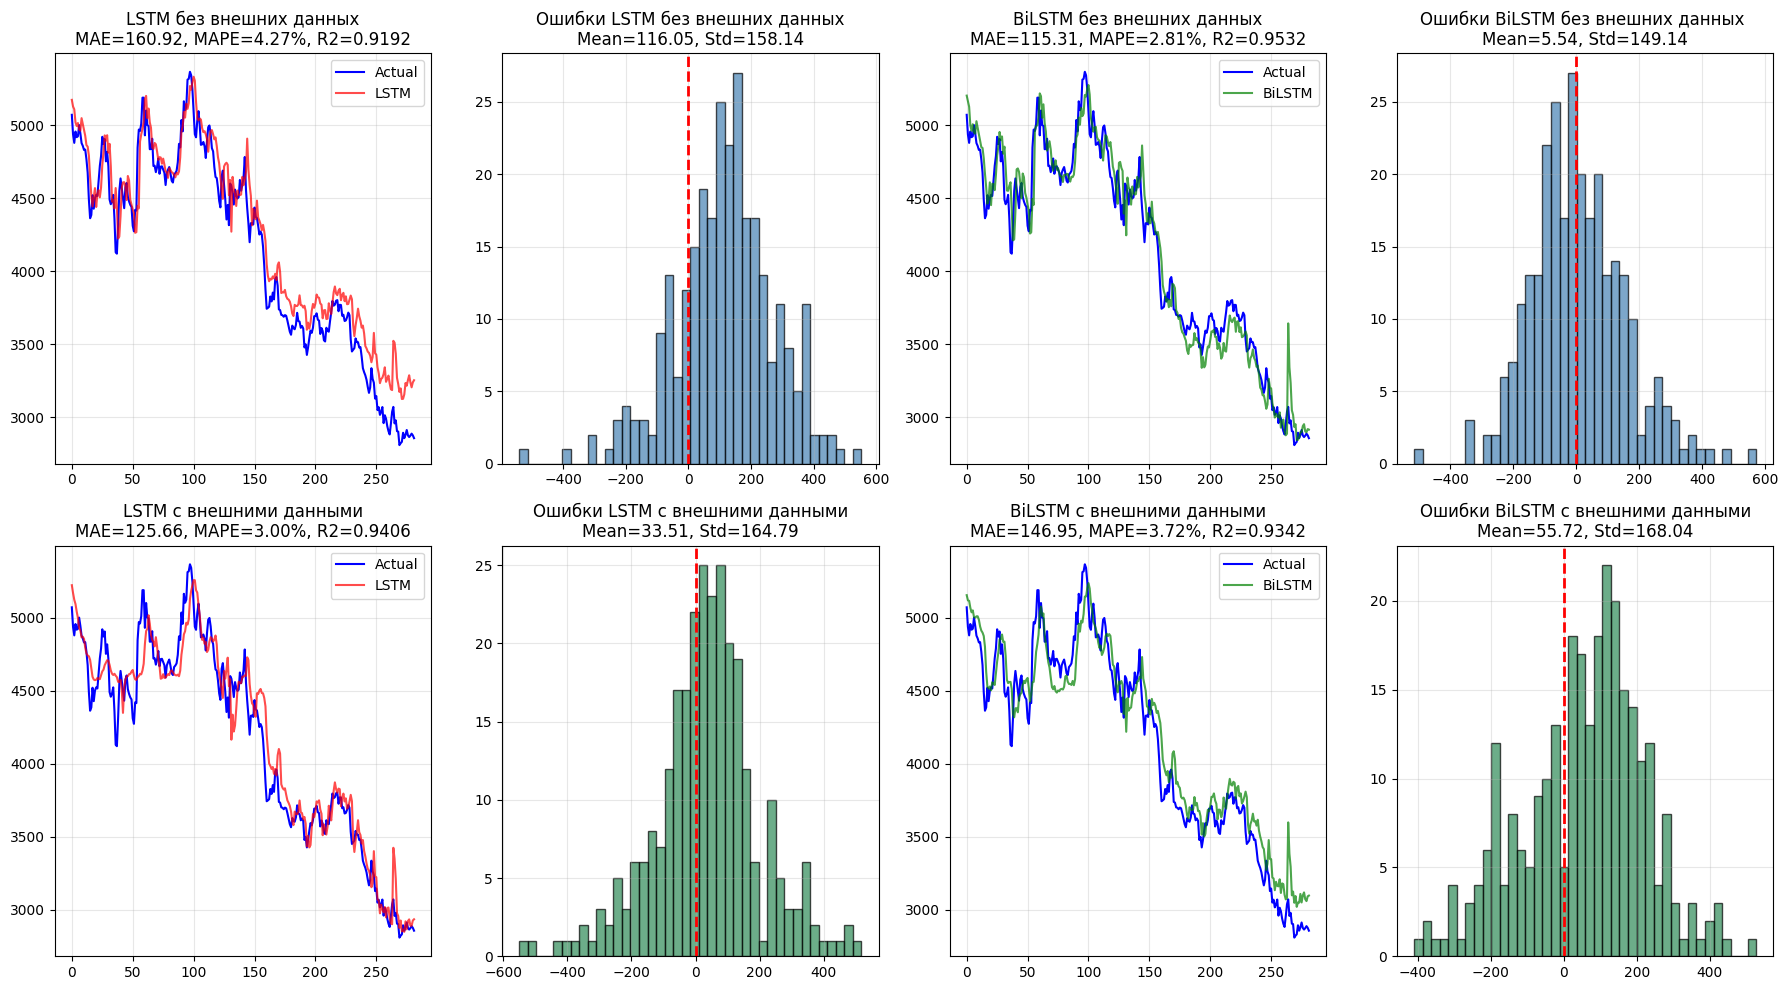

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

# LSTM без внешних - весь тест
axes[0, 0].plot(act_lstm_wo, label='Actual', linewidth=1.5, color='blue')
axes[0, 0].plot(pred_lstm_wo, label='LSTM', linewidth=1.5, color='red', alpha=0.7)
axes[0, 0].set_title(f'LSTM без внешних данных\nMAE={mae_lstm_wo:.2f}, MAPE={mape_lstm_wo:.2f}%, R2={r2_lstm_wo:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

errors1 = pred_lstm_wo - act_lstm_wo
axes[0, 1].hist(errors1, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title(f'Ошибки LSTM без внешних данных\nMean={np.mean(errors1):.2f}, Std={np.std(errors1):.2f}')
axes[0, 1].grid(True, alpha=0.3)

# BiLSTM без внешних - весь тест
axes[0, 2].plot(act_bilstm_wo, label='Actual', linewidth=1.5, color='blue')
axes[0, 2].plot(pred_bilstm_wo, label='BiLSTM', linewidth=1.5, color='green', alpha=0.7)
axes[0, 2].set_title(f'BiLSTM без внешних данных\nMAE={mae_bilstm_wo:.2f}, MAPE={mape_bilstm_wo:.2f}%, R2={r2_bilstm_wo:.4f}')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

errors2 = pred_bilstm_wo - act_bilstm_wo
axes[0, 3].hist(errors2, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 3].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 3].set_title(f'Ошибки BiLSTM без внешних данных \nMean={np.mean(errors2):.2f}, Std={np.std(errors2):.2f}')
axes[0, 3].grid(True, alpha=0.3)

# LSTM с внешними - весь тест
axes[1, 0].plot(act_lstm_w, label='Actual', linewidth=1.5, color='blue')
axes[1, 0].plot(pred_lstm_w, label='LSTM', linewidth=1.5, color='red', alpha=0.7)
axes[1, 0].set_title(f'LSTM с внешними данными\nMAE={mae_lstm_w:.2f}, MAPE={mape_lstm_w:.2f}%, R2={r2_lstm_w:.4f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

errors3 = pred_lstm_w - act_lstm_w
axes[1, 1].hist(errors3, bins=40, alpha=0.7, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title(f'Ошибки LSTM с внешними данными\nMean={np.mean(errors3):.2f}, Std={np.std(errors3):.2f}')
axes[1, 1].grid(True, alpha=0.3)

# BiLSTM с внешними - весь тест
axes[1, 2].plot(act_bilstm_w, label='Actual', linewidth=1.5, color='blue')
axes[1, 2].plot(pred_bilstm_w, label='BiLSTM', linewidth=1.5, color='green', alpha=0.7)
axes[1, 2].set_title(f'BiLSTM с внешними данными\nMAE={mae_bilstm_w:.2f}, MAPE={mape_bilstm_w:.2f}%, R2={r2_bilstm_w:.4f}')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

errors4 = pred_bilstm_w - act_bilstm_w
axes[1, 3].hist(errors4, bins=40, alpha=0.7, color='seagreen', edgecolor='black')
axes[1, 3].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 3].set_title(f'Ошибки BiLSTM с внешними данными\nMean={np.mean(errors4):.2f}, Std={np.std(errors4):.2f}')
axes[1, 3].grid(True, alpha=0.3)

plt.tight_layout()

# Сохранение в нескольких местах
plt.savefig('results_full_test.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/results_full_test.png', dpi=150, bbox_inches='tight')
plt.savefig('./results_full_test.png', dpi=150, bbox_inches='tight')

print("Файл сохранен:")
print("  - results_full_test.png")
print("  - /content/results_full_test.png")

if os.path.exists('results_full_test.png'):
    print("  ✓ Файл существует: results_full_test.png")
    print(f"    Размер: {os.path.getsize('results_full_test.png')} байт")
else:
    print("  ✗ Файл не найден")

plt.show()

# Скачать файл в Colab
from google.colab import files
files.download('results_full_LSTM_test.png')

In [ ]:
from scipy import stats
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox

def analyze_residuals(residuals, model_name="Model"):
    residuals = np.array(residuals).flatten()
    n = len(residuals)

    print(f"\nАнализ остатков: {model_name}")
    print(f"Количество наблюдений: {n}")
    print(f"Средняя ошибка (ME): {np.mean(residuals):.4f}")
    print(f"Стандартное отклонение: {np.std(residuals):.4f}")
    print(f"Дисперсия: {np.var(residuals):.4f}")
    print(f"Медиана: {np.median(residuals):.4f}")
    print(f"Минимум: {np.min(residuals):.4f}")
    print(f"Максимум: {np.max(residuals):.4f}")
    print(f"Асимметрия (Skewness): {stats.skew(residuals):.4f}")
    print(f"Эксцесс (Kurtosis): {stats.kurtosis(residuals):.4f}")

    # Тесты на нормальность
    if n > 5000:
        sample = np.random.choice(residuals, 5000, replace=False)
        shapiro_stat, shapiro_p = stats.shapiro(sample)
    else:
        shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"Тест Шапиро-Уилка: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

    ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))
    print(f"Тест Колмогорова-Смирнова: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")

    # Тест Льюнга-Бокса на белый шум (автокорреляция)
    lb_result = acorr_ljungbox(residuals, lags=[10], return_df=False)
    lb_stat = lb_result.iloc[0, 0] if hasattr(lb_result, 'iloc') else lb_result[0][0]
    lb_p = lb_result.iloc[0, 1] if hasattr(lb_result, 'iloc') else lb_result[0][1]
    print(f"Тест Льюнга-Бокса (белый шум, lag=10): statistic={lb_stat:.4f}, p-value={lb_p:.4f}")

    # Тест Дарбина-Ватсона
    diff = np.diff(residuals)
    dw_stat = np.sum(diff**2) / np.sum(residuals**2)
    print(f"Тест Дарбина-Ватсона: statistic={dw_stat:.4f}")

    # Дополнительные метрики
    mae = np.mean(np.abs(residuals))
    rmse = np.sqrt(np.mean(residuals**2))
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")

    # Интерпретация
    print()
    if shapiro_p < 0.05:
        print("Распределение ошибок НЕ нормальное (p < 0.05)")
    else:
        print("Распределение ошибок нормальное (p >= 0.05)")

    if lb_p < 0.05:
        print("Ошибки НЕ являются белым шумом (есть автокорреляция, p < 0.05)")
    else:
        print("Ошибки являются белым шумом (нет автокорреляции, p >= 0.05)")

    if dw_stat < 1.5:
        print("Положительная автокорреляция ошибок (DW < 1.5)")
    elif dw_stat > 2.5:
        print("Отрицательная автокорреляция ошибок (DW > 2.5)")
    else:
        print("Автокорреляция ошибок отсутствует (DW ≈ 2)")

    if abs(stats.skew(residuals)) < 0.5:
        print("Распределение симметричное")
    elif stats.skew(residuals) > 0:
        print("Распределение с правосторонней асимметрией")
    else:
        print("Распределение с левосторонней асимметрией")

    return {
        'mean': np.mean(residuals),
        'std': np.std(residuals),
        'skewness': stats.skew(residuals),
        'kurtosis': stats.kurtosis(residuals),
        'shapiro_p': shapiro_p,
        'lb_p': lb_p,
        'dw_stat': dw_stat,
        'mae': mae,
        'rmse': rmse
    }

print("АНАЛИЗ ОСТАТКОВ ВСЕХ МОДЕЛЕЙ")

errors_lstm_wo = act_lstm_wo - pred_lstm_wo
analyze_residuals(errors_lstm_wo, "LSTM без внешних")

errors_bilstm_wo = act_bilstm_wo - pred_bilstm_wo
analyze_residuals(errors_bilstm_wo, "BiLSTM без внешних")

errors_lstm_w = act_lstm_w - pred_lstm_w
analyze_residuals(errors_lstm_w, "LSTM с внешними")

errors_bilstm_w = act_bilstm_w - pred_bilstm_w
analyze_residuals(errors_bilstm_w, "BiLSTM с внешними")

АНАЛИЗ ОСТАТКОВ ВСЕХ МОДЕЛЕЙ

Анализ остатков: LSTM без внешних
Количество наблюдений: 282
Средняя ошибка (ME): -116.0498
Стандартное отклонение: 158.1434
Дисперсия: 25009.3262
Медиана: -122.4658
Минимум: -552.9302
Максимум: 539.5889
Асимметрия (Skewness): 0.4093
Эксцесс (Kurtosis): 0.9655
Тест Шапиро-Уилка: statistic=0.9862, p-value=0.0084
Тест Колмогорова-Смирнова: statistic=0.0468, p-value=0.5517
Тест Льюнга-Бокса (белый шум, lag=10): statistic=365.4089, p-value=0.0000
Тест Дарбина-Ватсона: statistic=0.3741
MAE: 160.9198
RMSE: 196.1552

Распределение ошибок НЕ нормальное (p < 0.05)
Ошибки НЕ являются белым шумом (есть автокорреляция, p < 0.05)
Положительная автокорреляция ошибок (DW < 1.5)
Распределение симметричное

Анализ остатков: BiLSTM без внешних
Количество наблюдений: 282
Средняя ошибка (ME): -5.5369
Стандартное отклонение: 149.1359
Дисперсия: 22241.5234
Медиана: 7.0286
Минимум: -571.8386
Максимум: 515.0454
Асимметрия (Skewness): -0.3848
Эксцесс (Kurtosis): 0.9654
Тест Шапиро

{'mean': np.float32(-55.72062),
 'std': np.float32(168.04274),
 'skewness': np.float32(0.2909346),
 'kurtosis': np.float32(-0.07095289),
 'shapiro_p': np.float64(0.007119868953886584),
 'lb_p': np.float64(6.0051934286848675e-96),
 'dw_stat': np.float32(0.37534055),
 'mae': np.float32(146.95065),
 'rmse': np.float32(177.03996)}

In [ ]:
from scipy import stats
import numpy as np

def compare_models_with_without(errors_lstm_wo, errors_lstm_w, errors_bilstm_wo, errors_bilstm_w):
    """
    Сравнение моделей с внешними факторами и без них
    """

    print("\n" + "="*70)
    print("СРАВНЕНИЕ МОДЕЛЕЙ: С ВНЕШНИМИ ФАКТОРАМИ vs БЕЗ")
    print("="*70)

    # Сравнение LSTM
    print("\n1. LSTM: без внешних vs с внешними")
    print("-"*50)

    mae_wo = np.mean(np.abs(errors_lstm_wo))
    mae_w = np.mean(np.abs(errors_lstm_w))

    print(f"MAE без внешних: {mae_wo:.2f}")
    print(f"MAE с внешними:  {mae_w:.2f}")
    print(f"Разница MAE:     {mae_w - mae_wo:.2f} ({(mae_w/mae_wo - 1)*100:.1f}%)")

    # Тест Уилкоксона
    stat, p = stats.wilcoxon(np.abs(errors_lstm_wo), np.abs(errors_lstm_w))
    print(f"\nТест Уилкоксона (абсолютные ошибки):")
    print(f"  statistic = {stat:.4f}")
    print(f"  p-value   = {p:.6f}")

    if p < 0.05:
        if mae_wo < mae_w:
            print("  LSTM без внешних ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
        else:
            print("  LSTM с внешними ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
    else:
        print("  Различие НЕ значимо (p >= 0.05)")

    # Тест знаков (исправлено)
    diff_abs = np.abs(errors_lstm_wo) - np.abs(errors_lstm_w)
    n_better_wo = np.sum(diff_abs < 0)
    n_better_w = np.sum(diff_abs > 0)
    n_equal = np.sum(diff_abs == 0)

    if n_better_wo + n_better_w > 0:
        sign_result = stats.binomtest(n_better_wo, n_better_wo + n_better_w, p=0.5)
        sign_p = sign_result.pvalue
    else:
        sign_p = 1.0

    print(f"\nТест знаков:")
    print(f"  Без внешних лучше: {n_better_wo} точек")
    print(f"  С внешними лучше:  {n_better_w} точек")
    print(f"  Одинаково:         {n_equal} точек")
    print(f"  p-value = {sign_p:.6f}")

    if sign_p < 0.05:
        if n_better_wo > n_better_w:
            print("  Без внешних значимо чаще лучше")
        else:
            print("  С внешними значимо чаще лучше")
    else:
        print("  Различие по знакам не значимо")

    # Сравнение BiLSTM
    print("\n" + "-"*50)
    print("2. BiLSTM: без внешних vs с внешними")
    print("-"*50)

    mae_bilstm_wo = np.mean(np.abs(errors_bilstm_wo))
    mae_bilstm_w = np.mean(np.abs(errors_bilstm_w))

    print(f"MAE без внешних: {mae_bilstm_wo:.2f}")
    print(f"MAE с внешними:  {mae_bilstm_w:.2f}")
    print(f"Разница MAE:     {mae_bilstm_w - mae_bilstm_wo:.2f} ({(mae_bilstm_w/mae_bilstm_wo - 1)*100:.1f}%)")

    stat, p = stats.wilcoxon(np.abs(errors_bilstm_wo), np.abs(errors_bilstm_w))
    print(f"\nТест Уилкоксона (абсолютные ошибки):")
    print(f"  statistic = {stat:.4f}")
    print(f"  p-value   = {p:.6f}")

    if p < 0.05:
        if mae_bilstm_wo < mae_bilstm_w:
            print("  BiLSTM без внешних ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
        else:
            print("  BiLSTM с внешними ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
    else:
        print("  Различие НЕ значимо (p >= 0.05)")

    diff_abs = np.abs(errors_bilstm_wo) - np.abs(errors_bilstm_w)
    n_better_wo = np.sum(diff_abs < 0)
    n_better_w = np.sum(diff_abs > 0)
    n_equal = np.sum(diff_abs == 0)

    if n_better_wo + n_better_w > 0:
        sign_result = stats.binomtest(n_better_wo, n_better_wo + n_better_w, p=0.5)
        sign_p = sign_result.pvalue
    else:
        sign_p = 1.0

    print(f"\nТест знаков:")
    print(f"  Без внешних лучше: {n_better_wo} точек")
    print(f"  С внешними лучше:  {n_better_w} точек")
    print(f"  Одинаково:         {n_equal} точек")
    print(f"  p-value = {sign_p:.6f}")

    if sign_p < 0.05:
        if n_better_wo > n_better_w:
            print("  Без внешних значимо чаще лучше")
        else:
            print("  С внешними значимо чаще лучше")
    else:
        print("  Различие по знакам не значимо")

    # Общий вывод
    print("\n" + "="*70)
    print("ОБЩИЙ ВЫВОД")
    print("="*70)

    print("\nСравнение MAE:")
    print(f"  LSTM:   без={mae_wo:.2f}, с={mae_w:.2f} -> разница {mae_w - mae_wo:+.2f}")
    print(f"  BiLSTM: без={mae_bilstm_wo:.2f}, с={mae_bilstm_w:.2f} -> разница {mae_bilstm_w - mae_bilstm_wo:+.2f}")

    print("\nЛучшая модель по MAE:")
    models = {
        'LSTM без': mae_wo,
        'LSTM с': mae_w,
        'BiLSTM без': mae_bilstm_wo,
        'BiLSTM с': mae_bilstm_w
    }
    best = min(models, key=models.get)
    print(f"  {best}: {models[best]:.2f}")

    return {
        'lstm_mae_wo': mae_wo,
        'lstm_mae_w': mae_w,
        'bilstm_mae_wo': mae_bilstm_wo,
        'bilstm_mae_w': mae_bilstm_w,
        'lstm_p_value': p,
        'bilstm_p_value': stats.wilcoxon(np.abs(errors_bilstm_wo), np.abs(errors_bilstm_w))[1]
    }

errors_lstm_wo = act_lstm_wo - pred_lstm_wo
errors_bilstm_wo = act_bilstm_wo - pred_bilstm_wo
errors_lstm_w = act_lstm_w - pred_lstm_w
errors_bilstm_w = act_bilstm_w - pred_bilstm_w

compare_models_with_without(errors_lstm_wo, errors_lstm_w, errors_bilstm_wo, errors_bilstm_w)


СРАВНЕНИЕ МОДЕЛЕЙ: С ВНЕШНИМИ ФАКТОРАМИ vs БЕЗ

1. LSTM: без внешних vs с внешними
--------------------------------------------------
MAE без внешних: 160.92
MAE с внешними:  125.66
Разница MAE:     -35.26 (-21.9%)

Тест Уилкоксона (абсолютные ошибки):
  statistic = 13834.0000
  p-value   = 0.000008
  LSTM с внешними ЗНАЧИМО ЛУЧШЕ (p < 0.05)

Тест знаков:
  Без внешних лучше: 106 точек
  С внешними лучше:  176 точек
  Одинаково:         0 точек
  p-value = 0.000036
  С внешними значимо чаще лучше

--------------------------------------------------
2. BiLSTM: без внешних vs с внешними
--------------------------------------------------
MAE без внешних: 115.31
MAE с внешними:  146.95
Разница MAE:     31.64 (27.4%)

Тест Уилкоксона (абсолютные ошибки):
  statistic = 13246.0000
  p-value   = 0.000001
  BiLSTM без внешних ЗНАЧИМО ЛУЧШЕ (p < 0.05)

Тест знаков:
  Без внешних лучше: 177 точек
  С внешними лучше:  105 точек
  Одинаково:         0 точек
  p-value = 0.000021
  Без внешних значим

{'lstm_mae_wo': np.float32(160.9198),
 'lstm_mae_w': np.float32(125.66133),
 'bilstm_mae_wo': np.float32(115.30796),
 'bilstm_mae_w': np.float32(146.95065),
 'lstm_p_value': np.float64(9.976877965185188e-07),
 'bilstm_p_value': np.float64(9.976877965185188e-07)}

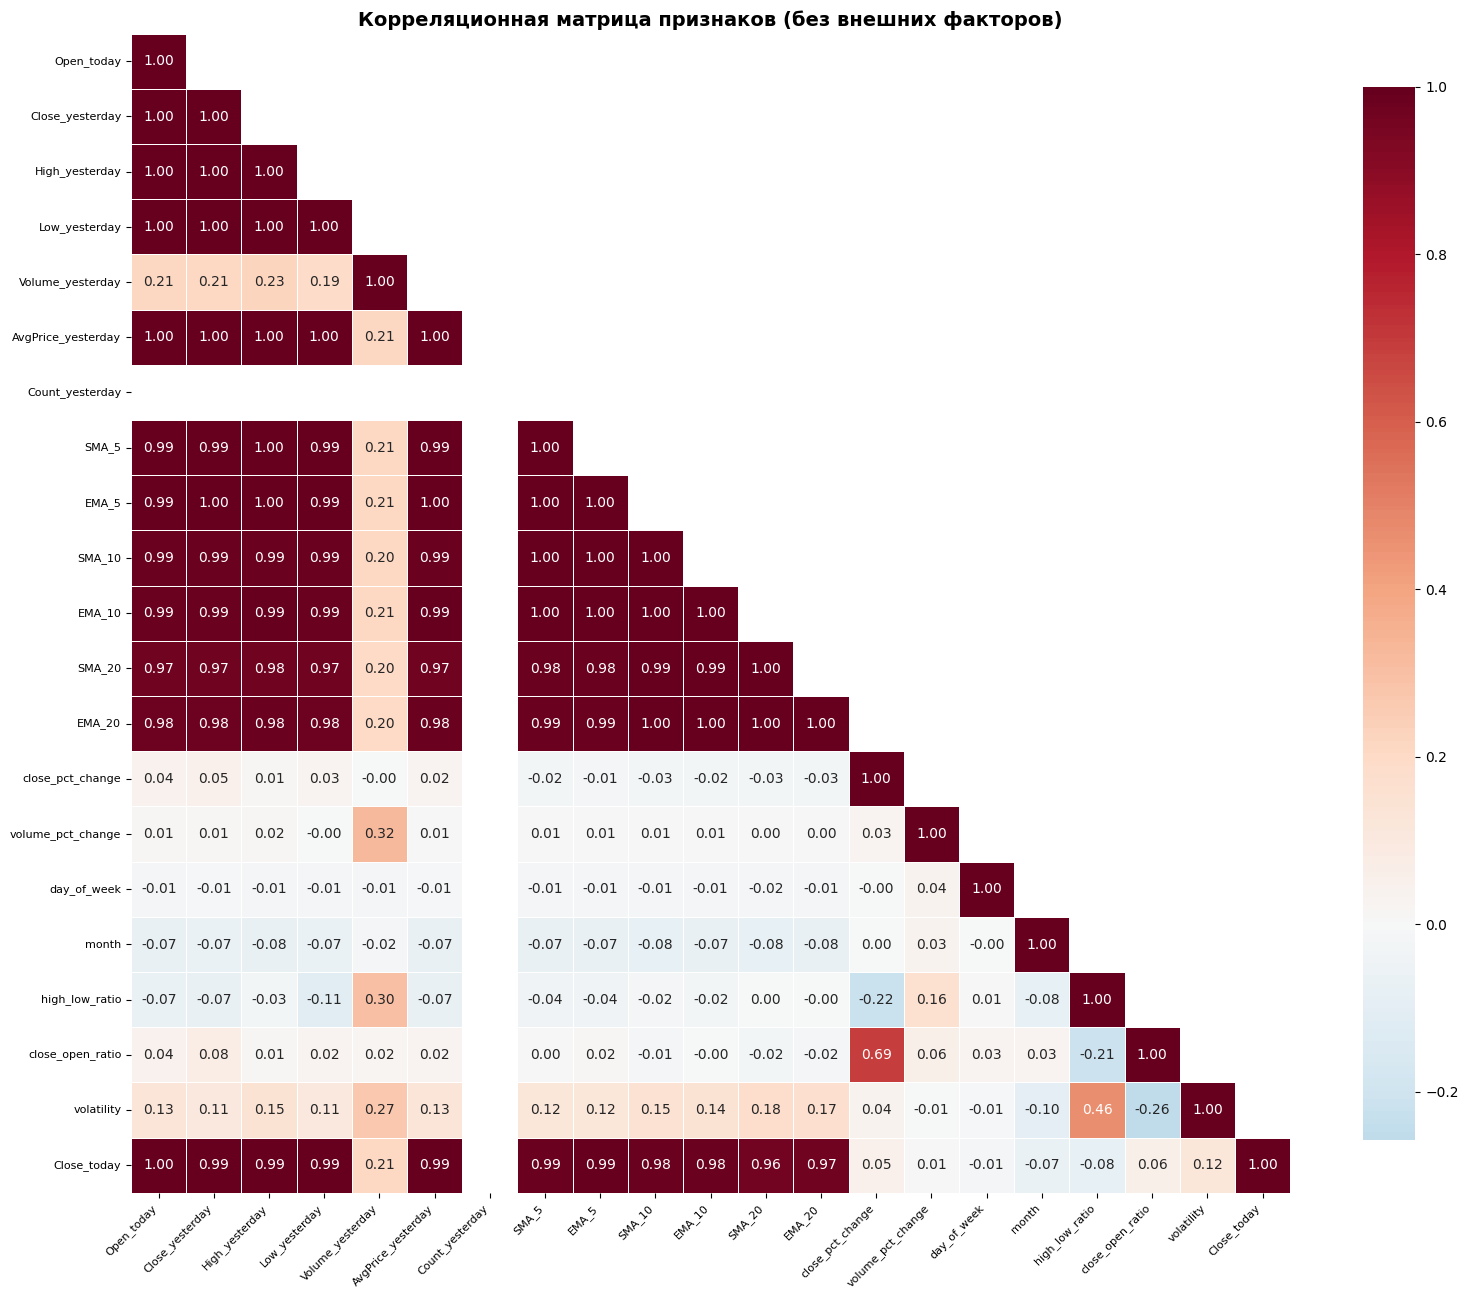

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def create_features_magnit_only(data):
    df = data.copy()
    feature_columns = []

    df['Open_today'] = df['Открытие']
    feature_columns.append('Open_today')

    df['Close_yesterday'] = df['Закрытие'].shift(1)
    df['High_yesterday'] = df['Максимум'].shift(1)
    df['Low_yesterday'] = df['Минимум'].shift(1)
    df['Volume_yesterday'] = df['Объем'].shift(1)
    df['AvgPrice_yesterday'] = df['Средняя_цена'].shift(1)
    df['Count_yesterday'] = df['Количество'].shift(1)
    feature_columns.extend(['Close_yesterday', 'High_yesterday', 'Low_yesterday',
                            'Volume_yesterday', 'AvgPrice_yesterday', 'Count_yesterday'])

    for window in [5, 10, 20]:
        df[f'SMA_{window}'] = df['Close_yesterday'].rolling(window).mean()
        df[f'EMA_{window}'] = df['Close_yesterday'].ewm(span=window, adjust=False).mean()
        feature_columns.extend([f'SMA_{window}', f'EMA_{window}'])

    df['close_pct_change'] = df['Close_yesterday'].pct_change() * 100
    df['volume_pct_change'] = df['Volume_yesterday'].pct_change() * 100
    feature_columns.extend(['close_pct_change', 'volume_pct_change'])

    df['Дата'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['Дата'].dt.dayofweek
    df['month'] = df['Дата'].dt.month
    feature_columns.extend(['day_of_week', 'month'])

    df['high_low_ratio'] = df['High_yesterday'] / (df['Low_yesterday'] + 1e-10)
    df['close_open_ratio'] = df['Close_yesterday'] / (df['Open_today'].shift(1) + 1e-10)
    feature_columns.extend(['high_low_ratio', 'close_open_ratio'])

    df['volatility'] = df['Close_yesterday'].rolling(5).std()
    feature_columns.append('volatility')

    df['Close_today'] = df['Закрытие']

    df_clean = df[feature_columns + ['Close_today']].dropna().reset_index(drop=True)
    return df_clean, feature_columns

df_without, cols_without = create_features_magnit_only(result)

corr_matrix = df_without[cols_without + ['Close_today']].corr()

plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляционная матрица признаков (без внешних факторов)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.show()

XGBoost LIGHTGBM


ОСНОВНОЙ XGBoost


XGBoost С ЛАГОВЫМИ ОШИБКАМИ

1. Модель БЕЗ внешних факторов
Признаков: 54

2. Модель С внешними факторами
Признаков: 69

РЕЗУЛЬТАТЫ
Модель                      MAE       RMSE    MAPE(%)         R²
------------------------------------------------------------
Без внешних               98.01     140.27       2.09     0.9845
С внешними                85.86     120.46       1.91     0.9886

СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ

Модель: XGBoost БЕЗ внешних

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Среднее:    -2.7019
   Стд.откл:   140.2461
   Асимметрия: 0.1040
   Эксцесс:    4.5269

2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:
   Шапиро-Уилк: p-value=0.0000
   Колмогоров-Смирнов: p-value=0.0140

3. ТЕСТ НА БЕЛЫЙ ШУМ:
   Льюнг-Бокс (lag=10): p-value=0.0000
   Дарбин-Ватсон: stat=0.8826

4. ИНТЕРПРЕТАЦИЯ:
   Распределение НЕ нормальное
   Ошибки НЕ белый шум
   Положительная автокорреляция

Модель: XGBoost С внешними

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Среднее:    38.1273
   Стд.откл:   114.2691
   Асимметрия: 0.5331
   Эксцесс: 

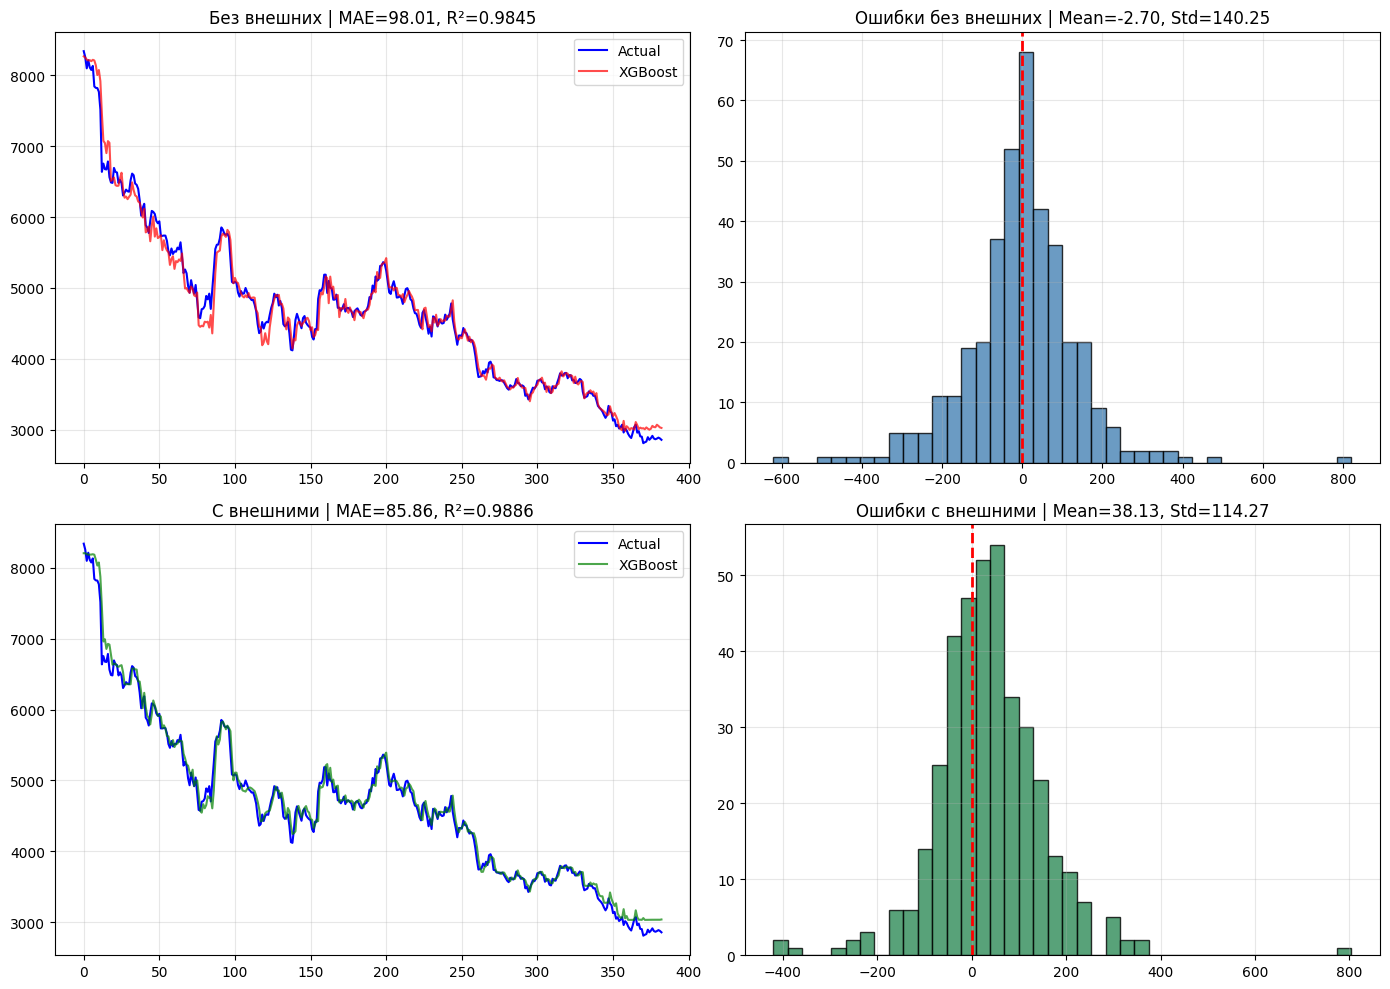


График сохранен: xgboost_with_lags.png


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата']).dt.strftime("%Y-%m-%d")
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")

result = new_data.merge(data, on='Дата', how='left')
result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    histogram = macd - signal_line
    return macd, signal_line, histogram

def create_features_with_lags(data, include_external=True):
    df = data.copy()

    df['Open_today'] = df['Открытие']

    for lag in [1, 2, 3, 5, 10]:
        df[f'close_lag_{lag}'] = df['Закрытие'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Объем'].shift(lag)

    for window in [3, 5, 10, 20, 50]:
        df[f'close_sma_{window}'] = df['close_lag_1'].rolling(window).mean()
        df[f'close_ema_{window}'] = df['close_lag_1'].ewm(span=window, adjust=False).mean()
        df[f'volume_sma_{window}'] = df['volume_lag_1'].rolling(window).mean()

    df['return_1'] = df['close_lag_1'].pct_change()
    df['return_3'] = df['close_lag_3'].pct_change()
    df['return_5'] = df['close_lag_5'].pct_change()
    df['return_10'] = df['close_lag_10'].pct_change()

    df['high_low_ratio'] = df['Максимум'].shift(1) / (df['Минимум'].shift(1) + 1e-10)
    df['close_open_ratio'] = df['close_lag_1'] / (df['Открытие'].shift(1) + 1e-10)

    df['volatility'] = df['close_lag_1'].rolling(10).std()

    df['RSI'] = calculate_rsi(df['close_lag_1'], 14)
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = calculate_macd(df['close_lag_1'])

    df['BB_middle'] = df['close_lag_1'].rolling(20).mean()
    bb_std = df['close_lag_1'].rolling(20).std()
    df['BB_upper'] = df['BB_middle'] + 2 * bb_std
    df['BB_lower'] = df['BB_middle'] - 2 * bb_std
    df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / df['BB_middle']
    df['BB_position'] = (df['close_lag_1'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'] + 1e-10)

    low_14 = df['close_lag_1'].rolling(14).min()
    high_14 = df['close_lag_1'].rolling(14).max()
    df['Stoch_K'] = 100 * (df['close_lag_1'] - low_14) / (high_14 - low_14 + 1e-10)
    df['Stoch_D'] = df['Stoch_K'].rolling(3).mean()

    high_shift = df['Максимум'].shift(1)
    low_shift = df['Минимум'].shift(1)
    close_shift2 = df['Закрытие'].shift(2)
    tr1 = high_shift - low_shift
    tr2 = abs(high_shift - close_shift2)
    tr3 = abs(low_shift - close_shift2)
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df['ATR'] = tr.rolling(14).mean()

    # ЛАГОВЫЕ ОШИБКИ
    df['error_proxy'] = df['close_lag_1'] - df['Открытие'].shift(1)
    df['error_lag1'] = df['error_proxy'].shift(1)
    df['error_lag2'] = df['error_proxy'].shift(2)
    df['error_lag3'] = df['error_proxy'].shift(3)
    df['error_ma5'] = df['error_proxy'].rolling(5).mean()
    df['error_std5'] = df['error_proxy'].rolling(5).std()

    df['date'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter

    if include_external:
        for lag in [1, 2, 3, 5]:
            df[f'kurs_lag_{lag}'] = df['Курс'].shift(lag)
            df[f'value_lag_{lag}'] = df['Значение'].shift(lag)

        df['kurs_return_1'] = df['kurs_lag_1'].pct_change()
        df['kurs_return_3'] = df['kurs_lag_3'].pct_change()
        df['value_return_1'] = df['value_lag_1'].pct_change()
        df['value_return_3'] = df['value_lag_3'].pct_change()

        df['close_kurs_ratio'] = df['close_lag_1'] / df['kurs_lag_1']
        df['close_value_ratio'] = df['close_lag_1'] / df['value_lag_1']
        df['kurs_value_ratio'] = df['kurs_lag_1'] / df['value_lag_1']

    feature_cols = [col for col in df.columns if any(x in col for x in
                     ['Open_today', '_lag_', '_sma_', '_ema_', 'return', 'day_of_week', 'month', 'quarter',
                      'ratio', 'kurs', 'value', 'high_low', 'close_open', 'volatility',
                      'RSI', 'MACD', 'BB_', 'Stoch', 'ATR', 'error_'])]

    df_clean = df[feature_cols + ['Закрытие']].dropna()
    return df_clean, feature_cols

def train_and_evaluate(df_opt, feature_cols, name):
    X = df_opt[feature_cols].values
    y = df_opt['Закрытие'].values

    train_idx = int(len(X) * 0.8)
    X_train, X_test = X[:train_idx], X[train_idx:]
    y_train, y_test = y[:train_idx], y[train_idx:]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # УБИРАЕМ early_stopping_rounds из RandomizedSearchCV
    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5]
    }

    random_search = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, n_jobs=-1),  # без early_stopping_rounds
        param_dist,
        n_iter=30,
        cv=TimeSeriesSplit(n_splits=3),
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    random_search.fit(X_train, y_train)
    model = random_search.best_estimator_
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    r2 = r2_score(y_test, preds)

    return model, preds, y_test, mae, rmse, mape, r2, random_search.best_params_

def analyze_residuals_full(residuals, model_name):
    residuals = np.array(residuals).flatten()
    n = len(residuals)

    print(f"\n{'='*60}")
    print(f"Модель: {model_name}")
    print(f"{'='*60}")

    print(f"\n1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
    print(f"   Среднее:    {np.mean(residuals):.4f}")
    print(f"   Стд.откл:   {np.std(residuals):.4f}")
    print(f"   Асимметрия: {stats.skew(residuals):.4f}")
    print(f"   Эксцесс:    {stats.kurtosis(residuals):.4f}")

    print(f"\n2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:")
    if n > 5000:
        sample = np.random.choice(residuals, 5000, replace=False)
        shapiro_stat, shapiro_p = stats.shapiro(sample)
    else:
        shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"   Шапиро-Уилк: p-value={shapiro_p:.4f}")

    ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))
    print(f"   Колмогоров-Смирнов: p-value={ks_p:.4f}")

    print(f"\n3. ТЕСТ НА БЕЛЫЙ ШУМ:")
    lb_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_p = lb_result['lb_pvalue'].values[0]
    print(f"   Льюнг-Бокс (lag=10): p-value={lb_p:.4f}")

    diff = np.diff(residuals)
    dw_stat = np.sum(diff**2) / np.sum(residuals**2)
    print(f"   Дарбин-Ватсон: stat={dw_stat:.4f}")

    print(f"\n4. ИНТЕРПРЕТАЦИЯ:")
    if shapiro_p < 0.05:
        print("   Распределение НЕ нормальное")
    else:
        print("   Распределение нормальное")

    if lb_p < 0.05:
        print("   Ошибки НЕ белый шум")
    else:
        print("   Ошибки - белый шум")

    if dw_stat < 1.5:
        print("   Положительная автокорреляция")
    elif dw_stat > 2.5:
        print("   Отрицательная автокорреляция")
    else:
        print("   Автокорреляция отсутствует")

    return {'shapiro_p': shapiro_p, 'lb_p': lb_p, 'dw_stat': dw_stat}

print("="*70)
print("XGBoost С ЛАГОВЫМИ ОШИБКАМИ")
print("="*70)

# Модель без внешних
print("\n1. Модель БЕЗ внешних факторов")
df_wo, cols_wo = create_features_with_lags(result, include_external=False)
print(f"Признаков: {len(cols_wo)}")
model_wo, pred_wo, y_test_wo, mae_wo, rmse_wo, mape_wo, r2_wo, params_wo = train_and_evaluate(df_wo, cols_wo, "Без внешних")

# Модель с внешними
print("\n2. Модель С внешними факторами")
df_w, cols_w = create_features_with_lags(result, include_external=True)
print(f"Признаков: {len(cols_w)}")
model_w, pred_w, y_test_w, mae_w, rmse_w, mape_w, r2_w, params_w = train_and_evaluate(df_w, cols_w, "С внешними")

# Результаты
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ")
print("="*70)
print(f"{'Модель':<20} {'MAE':>10} {'RMSE':>10} {'MAPE(%)':>10} {'R²':>10}")
print("-"*60)
print(f"{'Без внешних':<20} {mae_wo:>10.2f} {rmse_wo:>10.2f} {mape_wo:>10.2f} {r2_wo:>10.4f}")
print(f"{'С внешними':<20} {mae_w:>10.2f} {rmse_w:>10.2f} {mape_w:>10.2f} {r2_w:>10.4f}")

# Статистический анализ
print("\n" + "="*70)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ")
print("="*70)

errors_wo = pred_wo - y_test_wo
errors_w = pred_w - y_test_w

stats_wo = analyze_residuals_full(errors_wo, "XGBoost БЕЗ внешних")
stats_w = analyze_residuals_full(errors_w, "XGBoost С внешними")

# Сравнение
print("\n" + "="*70)
print("СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ")
print("="*70)

stat, p_wilcoxon = stats.wilcoxon(np.abs(errors_wo), np.abs(errors_w))
print(f"\nТест Уилкоксона: p-value={p_wilcoxon:.6f}")
if p_wilcoxon < 0.05:
    if mae_wo < mae_w:
        print(">>> БЕЗ внешних ЗНАЧИМО ЛУЧШЕ")
    else:
        print(">>> С внешними ЗНАЧИМО ЛУЧШЕ")
else:
    print(">>> Различие НЕ значимо")

diff_abs = np.abs(errors_wo) - np.abs(errors_w)
n_better_wo = np.sum(diff_abs < 0)
n_better_w = np.sum(diff_abs > 0)
sign_result = stats.binomtest(n_better_wo, n_better_wo + n_better_w, p=0.5)
print(f"\nТест знаков: без={n_better_wo}, с={n_better_w}, p={sign_result.pvalue:.6f}")

print("\n" + "="*70)
print("ИТОГ")
print("="*70)
print(f"MAE без внешних: {mae_wo:.2f}")
print(f"MAE с внешними:  {mae_w:.2f}")
print(f"Разница:         {mae_w - mae_wo:+.2f}")

if mae_wo < mae_w:
    print("\n>>> Рекомендуется модель БЕЗ внешних факторов")
else:
    print("\n>>> Рекомендуется модель С внешними факторами")

# Графики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(y_test_wo, label='Actual', linewidth=1.5, color='blue')
axes[0, 0].plot(pred_wo, label='XGBoost', linewidth=1.5, color='red', alpha=0.7)
axes[0, 0].set_title(f'Без внешних | MAE={mae_wo:.2f}, R²={r2_wo:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(errors_wo, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title(f'Ошибки без внешних | Mean={np.mean(errors_wo):.2f}, Std={np.std(errors_wo):.2f}')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(y_test_w, label='Actual', linewidth=1.5, color='blue')
axes[1, 0].plot(pred_w, label='XGBoost', linewidth=1.5, color='green', alpha=0.7)
axes[1, 0].set_title(f'С внешними | MAE={mae_w:.2f}, R²={r2_w:.4f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(errors_w, bins=40, alpha=0.8, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title(f'Ошибки с внешними | Mean={np.mean(errors_w):.2f}, Std={np.std(errors_w):.2f}')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_with_lags.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: xgboost_with_lags.png")

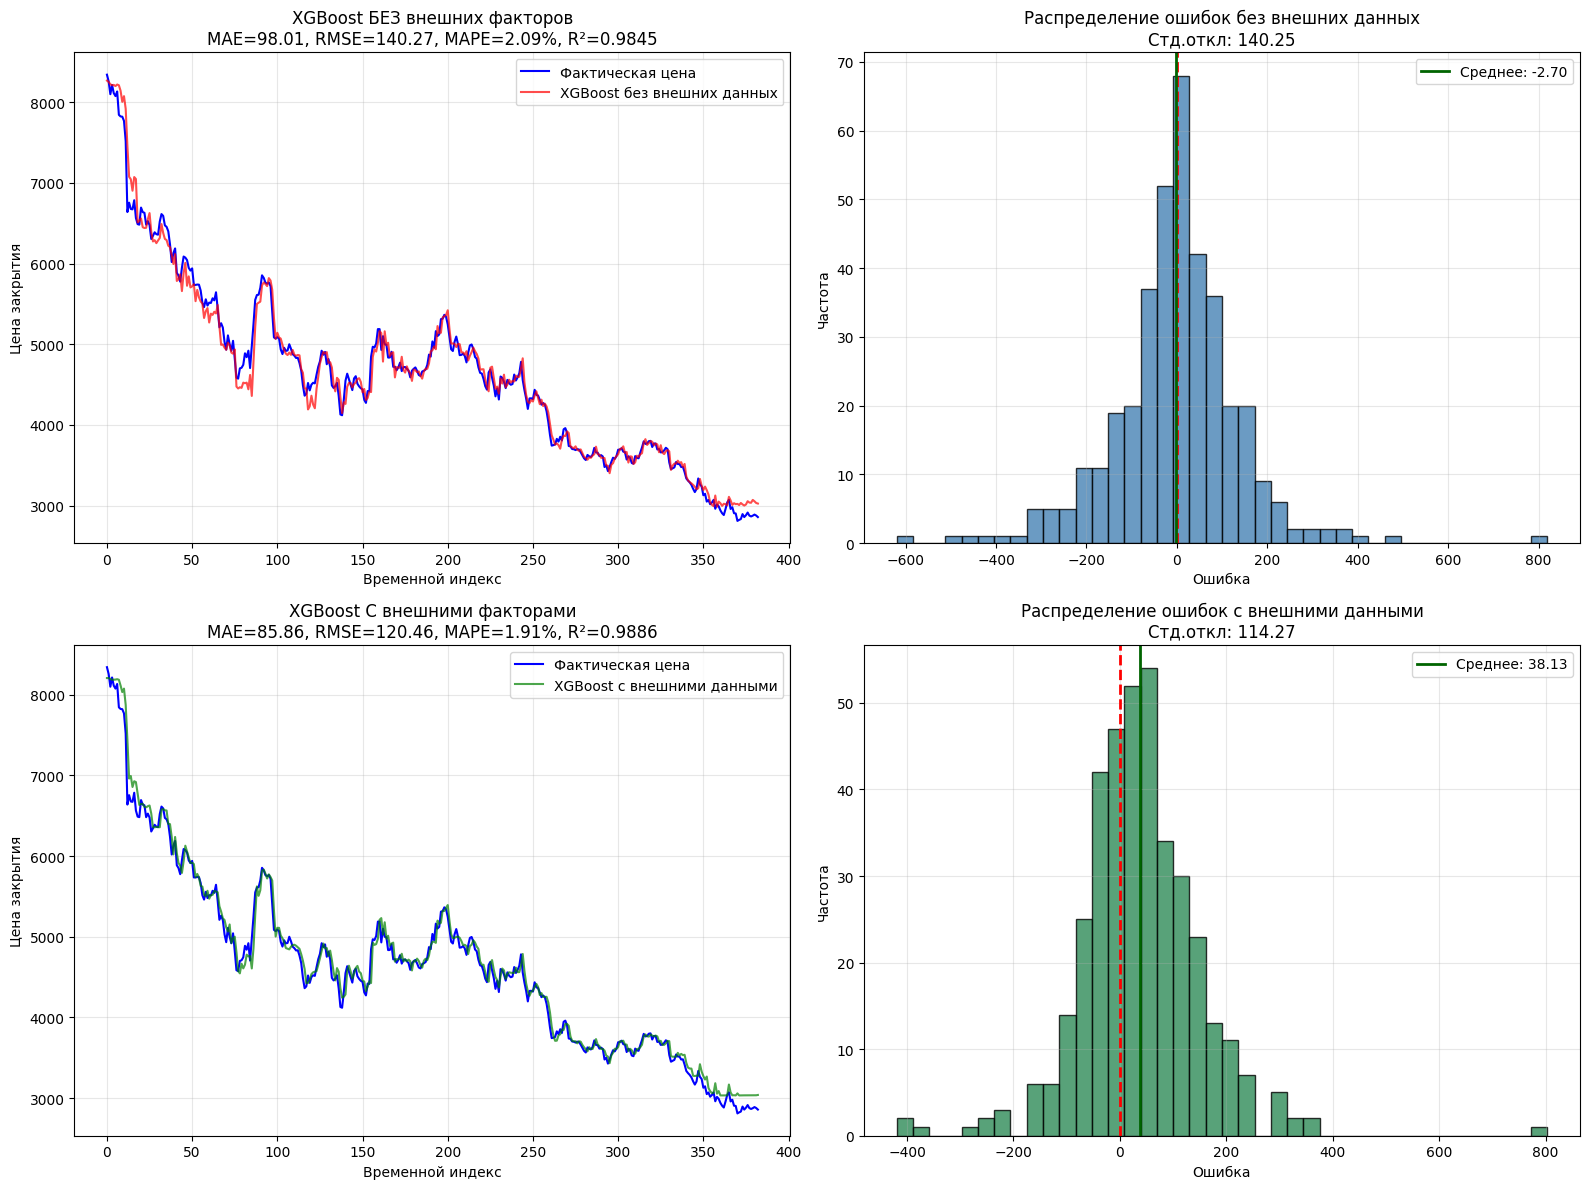

График сохранен: xgboost_full_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Один общий график со всеми 4 подграфиками
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# XGBoost БЕЗ внешних - предсказания
axes[0, 0].plot(y_test_wo, label='Фактическая цена', linewidth=1.5, color='blue')
axes[0, 0].plot(pred_wo, label='XGBoost без внешних данных', linewidth=1.5, color='red', alpha=0.7)
axes[0, 0].set_title(f'XGBoost БЕЗ внешних факторов\nMAE={mae_wo:.2f}, RMSE={rmse_wo:.2f}, MAPE={mape_wo:.2f}%, R²={r2_wo:.4f}', fontsize=12)
axes[0, 0].set_xlabel('Временной индекс')
axes[0, 0].set_ylabel('Цена закрытия')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# XGBoost БЕЗ внешних - распределение ошибок
errors_wo = pred_wo - y_test_wo
axes[0, 1].hist(errors_wo, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=np.mean(errors_wo), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors_wo):.2f}')
axes[0, 1].set_xlabel('Ошибка')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].set_title(f'Распределение ошибок без внешних данных\nСтд.откл: {np.std(errors_wo):.2f}', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# XGBoost С внешними - предсказания
axes[1, 0].plot(y_test_w, label='Фактическая цена', linewidth=1.5, color='blue')
axes[1, 0].plot(pred_w, label='XGBoost с внешними данными', linewidth=1.5, color='green', alpha=0.7)
axes[1, 0].set_title(f'XGBoost С внешними факторами\nMAE={mae_w:.2f}, RMSE={rmse_w:.2f}, MAPE={mape_w:.2f}%, R²={r2_w:.4f}', fontsize=12)
axes[1, 0].set_xlabel('Временной индекс')
axes[1, 0].set_ylabel('Цена закрытия')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# XGBoost С внешними - распределение ошибок
errors_w = pred_w - y_test_w
axes[1, 1].hist(errors_w, bins=40, alpha=0.8, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].axvline(x=np.mean(errors_w), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors_w):.2f}')
axes[1, 1].set_xlabel('Ошибка')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_title(f'Распределение ошибок с внешними данными\nСтд.откл: {np.std(errors_w):.2f}', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_full_comparison.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/xgboost_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("График сохранен: xgboost_full_comparison.png")

# Скачивание для Colab
try:
    from google.colab import files
    files.download('xgboost_full_comparison.png')
except:
    pass

XGBOOST С БАЙЕСОВСКОЙ ОПТИМИЗАЦИЕЙ
Размер данных: (1955, 10)
Колонки: ['Дата', 'Сделок шт.', 'Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум', 'Закрытие', 'Курс', 'Значение']

1. Модель БЕЗ внешних факторов
   Признаков: 33
   Строк: 1921
  Поиск гиперпараметров для Без внешних...

2. Модель С внешними факторами
   Признаков: 41
   Строк: 1921
  Поиск гиперпараметров для С внешними...

РЕЗУЛЬТАТЫ
Модель                      MAE       RMSE    MAPE(%)         R2
------------------------------------------------------------
Без внешних               77.21     107.21       1.96     0.9773
С внешними                77.97     106.00       1.99     0.9778

ЛУЧШИЕ ПАРАМЕТРЫ:
   Без внешних: OrderedDict({'colsample_bytree': 1.0, 'gamma': 0.16684137051708287, 'learning_rate': 0.023194062450423495, 'max_depth': 7, 'min_child_weight': 6, 'n_estimators': 294, 'reg_alpha': 0.8986754535664554, 'reg_lambda': 0.5, 'subsample': 0.6431276462249375})
   С внешними:  OrderedDict({'colsample_bytree

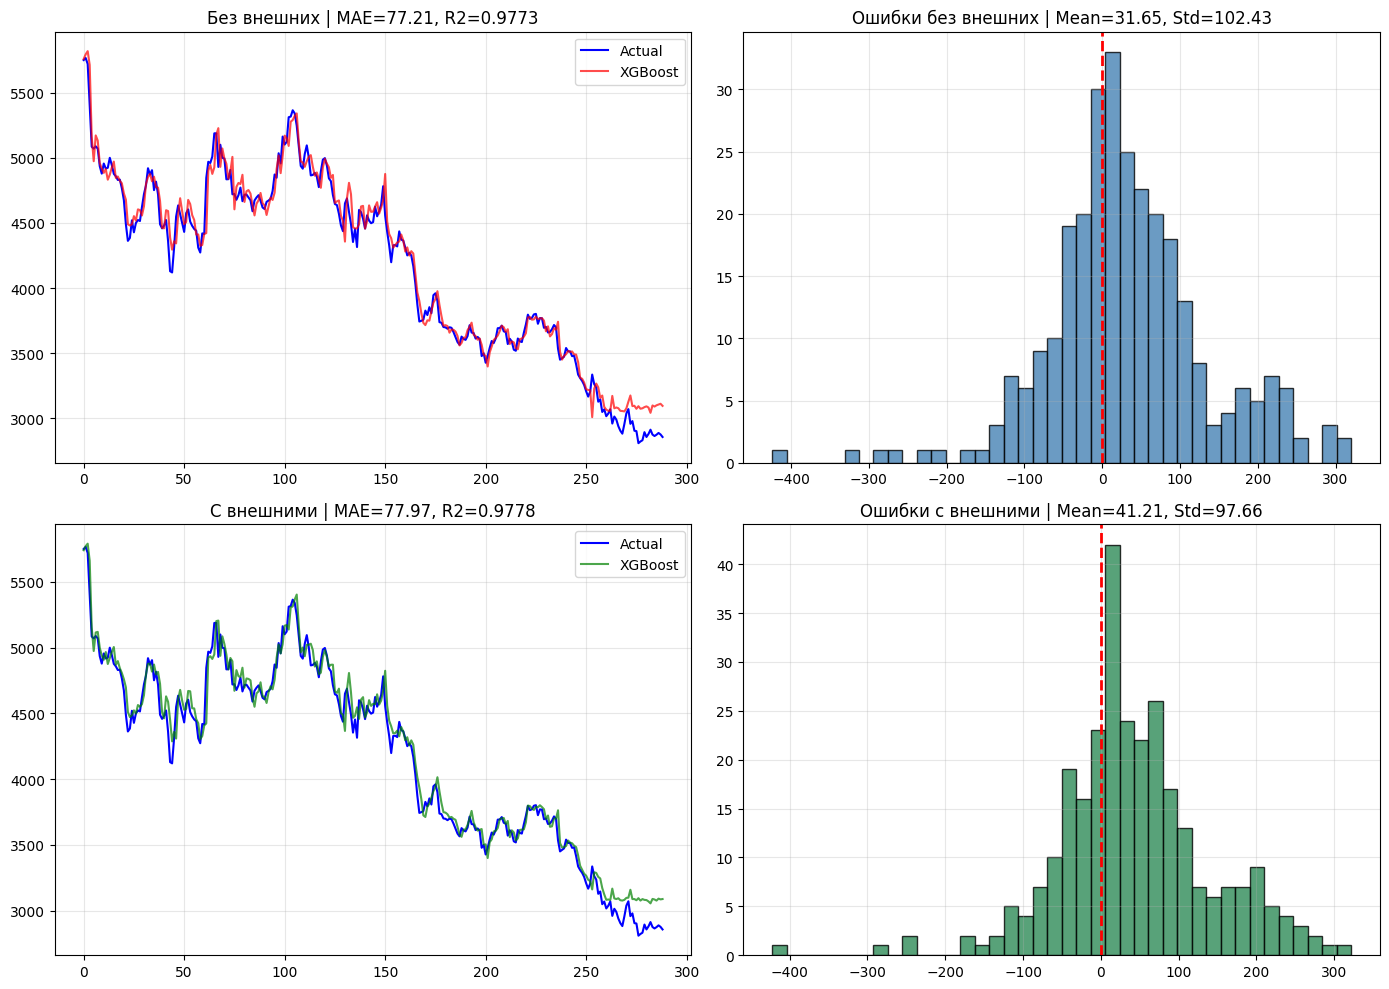


График сохранен: xgboost_bayes_final.png


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("XGBOOST С БАЙЕСОВСКОЙ ОПТИМИЗАЦИЕЙ")
print("="*70)

data = pd.read_csv('новая_нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата']).dt.strftime("%Y-%m-%d")
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")

result = new_data.merge(data, on='Дата', how='left')
result['Значение'] = result['Значение'].interpolate(method='linear')

if 'Код' in result.columns:
    result = result.drop(columns=['Код'])

if 'Значение' in result.columns:
    result['Значение'] = result['Значение'].fillna(method='ffill').fillna(method='bfill')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Курс', 'Значение']

for c in col:
    if c in result.columns:
        result[c] = pd.to_numeric(result[c], errors='coerce')

if 'Количество' in result.columns:
    result = result.drop(columns=['Количество'])

result = result.dropna().reset_index(drop=True)
print(f"Размер данных: {result.shape}")
print(f"Колонки: {result.columns.tolist()}")

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period, min_periods=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period, min_periods=period).mean()
    rs = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False, min_periods=fast).mean()
    ema_slow = prices.ewm(span=slow, adjust=False, min_periods=slow).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False, min_periods=signal).mean()
    histogram = macd - signal_line
    return macd, signal_line, histogram

def create_features_clean(data, include_external=True):
    df = data.copy()

    df['Open_today'] = df['Открытие']

    for lag in [1, 2, 3, 5]:
        df[f'close_lag_{lag}'] = df['Закрытие'].shift(lag)
        if 'Объем' in df.columns:
            df[f'volume_lag_{lag}'] = df['Объем'].shift(lag)

    for window in [5, 10, 20]:
        df[f'close_sma_{window}'] = df['Закрытие'].rolling(window, min_periods=window//2).mean().shift(1)
        df[f'close_ema_{window}'] = df['Закрытие'].ewm(span=window, adjust=False, min_periods=window//2).mean().shift(1)

    df['return_1'] = df['close_lag_1'].pct_change()
    df['return_5'] = df['close_lag_5'].pct_change()

    df['volatility'] = df['close_lag_1'].rolling(10, min_periods=5).std()

    df['RSI'] = calculate_rsi(df['Закрытие'].shift(1), 14)

    macd, signal, hist = calculate_macd(df['Закрытие'])
    df['MACD'] = macd.shift(1)
    df['MACD_signal'] = signal.shift(1)
    df['MACD_hist'] = hist.shift(1)

    bb_mid = df['Закрытие'].rolling(20, min_periods=10).mean().shift(1)
    bb_std = df['Закрытие'].rolling(20, min_periods=10).std().shift(1)
    df['BB_position'] = (df['Open_today'] - bb_mid) / (2 * bb_std + 1e-10)
    df['BB_width'] = (2 * bb_std) / (bb_mid + 1e-10)

    high_shift = df['Максимум'].shift(1)
    low_shift = df['Минимум'].shift(1)
    close_shift2 = df['Закрытие'].shift(2)
    tr1 = high_shift - low_shift
    tr2 = abs(high_shift - close_shift2)
    tr3 = abs(low_shift - close_shift2)
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df['ATR'] = tr.rolling(14, min_periods=7).mean().shift(1)

    df['error_today'] = df['close_lag_1'] - df['Открытие'].shift(1)
    df['error_lag1'] = df['error_today'].shift(1)
    df['error_lag2'] = df['error_today'].shift(2)
    df['error_ma5'] = df['error_today'].rolling(5, min_periods=3).mean()

    df['date'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter

    if include_external and 'Курс' in df.columns and 'Значение' in df.columns:
        for lag in [1, 2]:
            df[f'kurs_lag_{lag}'] = df['Курс'].shift(lag)
            df[f'value_lag_{lag}'] = df['Значение'].shift(lag)

        df['kurs_return'] = df['kurs_lag_1'].pct_change()
        df['value_return'] = df['value_lag_1'].pct_change()
        df['close_kurs_ratio'] = df['close_lag_1'] / (df['kurs_lag_1'] + 1e-10)
        df['close_value_ratio'] = df['close_lag_1'] / (df['value_lag_1'] + 1e-10)

    exclude_cols = ['Дата', 'date', 'Закрытие', 'Открытие', 'Максимум',
                    'Минимум', 'Объем', 'Средняя_цена', 'Курс', 'Значение']

    feature_cols = [col for col in df.columns if col not in exclude_cols]
    feature_cols = [col for col in feature_cols if not df[col].isna().all()]

    df_clean = df[feature_cols + ['Закрытие']].dropna()

    return df_clean, feature_cols

def train_with_bayesopt(df_opt, feature_cols, model_name):
    X = df_opt[feature_cols].values
    y = df_opt['Закрытие'].values

    train_idx = int(len(X) * 0.7)
    val_idx = int(len(X) * 0.85)

    X_train = X[:train_idx]
    y_train = y[:train_idx]
    X_val = X[train_idx:val_idx]
    y_val = y[train_idx:val_idx]
    X_test = X[val_idx:]
    y_test = y[val_idx:]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    search_spaces = {
        'n_estimators': Integer(100, 400),
        'max_depth': Integer(3, 7),
        'learning_rate': Real(0.005, 0.1, 'log-uniform'),
        'subsample': Real(0.6, 1.0),
        'colsample_bytree': Real(0.6, 1.0),
        'min_child_weight': Integer(1, 6),
        'gamma': Real(0, 0.3),
        'reg_alpha': Real(0, 1.5),
        'reg_lambda': Real(0.5, 2.5)
    }

    tscv = TimeSeriesSplit(n_splits=3)

    bayes_search = BayesSearchCV(
        xgb.XGBRegressor(random_state=42, n_jobs=-1, eval_metric='mae'),
        search_spaces,
        n_iter=30,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    print(f"  Поиск гиперпараметров для {model_name}...")
    bayes_search.fit(X_train, y_train)

    best_params = bayes_search.best_params_

    final_model = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    X_train_full = np.vstack([X_train, X_val])
    y_train_full = np.hstack([y_train, y_val])
    final_model.fit(X_train_full, y_train_full)

    preds = final_model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    r2 = r2_score(y_test, preds)

    return final_model, preds, y_test, mae, rmse, mape, r2, best_params

def analyze_residuals_full(residuals, model_name):
    residuals = np.array(residuals).flatten()

    print(f"\n{'='*60}")
    print(f"Модель: {model_name}")
    print(f"{'='*60}")

    print(f"\n1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
    print(f"   Среднее:    {np.mean(residuals):.6f}")
    print(f"   Стд.откл:   {np.std(residuals):.6f}")
    print(f"   Асимметрия: {stats.skew(residuals):.4f}")
    print(f"   Эксцесс:    {stats.kurtosis(residuals):.4f}")

    print(f"\n2. ТЕСТ НА БЕЛЫЙ ШУМ (Льюнг-Бокс):")
    for lag in [5, 10, 15, 20]:
        lb_result = acorr_ljungbox(residuals, lags=[lag], return_df=True)
        lb_p = lb_result['lb_pvalue'].values[0]
        status = "ХОРОШО" if lb_p >= 0.05 else "ПЛОХО"
        print(f"   Лаг {lag:2d}: p-value={lb_p:.6f} ({status})")

    diff = np.diff(residuals)
    dw_stat = np.sum(diff**2) / (np.sum(residuals**2) + 1e-10)
    print(f"\n3. ТЕСТ ДАРБИНА-ВАТСОНА:")
    print(f"   Статистика: {dw_stat:.4f}")

    if 1.8 < dw_stat < 2.2:
        print("   АВТОКОРРЕЛЯЦИЯ ОТСУТСТВУЕТ")
    elif dw_stat <= 1.8:
        print("   ПОЛОЖИТЕЛЬНАЯ АВТОКОРРЕЛЯЦИЯ")
    else:
        print("   ОТРИЦАТЕЛЬНАЯ АВТОКОРРЕЛЯЦИЯ")

    lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_p = lb_test['lb_pvalue'].values[0]

    print(f"\n4. ВЕРДИКТ:")
    if lb_p >= 0.05:
        print("   УСПЕХ: Остатки являются белым шумом")
        return True
    else:
        print("   НЕУДАЧА: Остатки НЕ являются белым шумом")
        return False

print("\n1. Модель БЕЗ внешних факторов")
df_wo, cols_wo = create_features_clean(result, include_external=False)
print(f"   Признаков: {len(cols_wo)}")
print(f"   Строк: {len(df_wo)}")

if len(df_wo) > 50:
    model_wo, pred_wo, y_test_wo, mae_wo, rmse_wo, mape_wo, r2_wo, params_wo = train_with_bayesopt(df_wo, cols_wo, "Без внешних")
    has_wo = True
else:
    print("   ОШИБКА: Недостаточно данных")
    has_wo = False

print("\n2. Модель С внешними факторами")
df_w, cols_w = create_features_clean(result, include_external=True)
print(f"   Признаков: {len(cols_w)}")
print(f"   Строк: {len(df_w)}")

if len(df_w) > 50:
    model_w, pred_w, y_test_w, mae_w, rmse_w, mape_w, r2_w, params_w = train_with_bayesopt(df_w, cols_w, "С внешними")
    has_w = True
else:
    print("   ОШИБКА: Недостаточно данных")
    has_w = False

if has_wo and has_w:
    print("\n" + "="*70)
    print("РЕЗУЛЬТАТЫ")
    print("="*70)
    print(f"{'Модель':<20} {'MAE':>10} {'RMSE':>10} {'MAPE(%)':>10} {'R2':>10}")
    print("-"*60)
    print(f"{'Без внешних':<20} {mae_wo:>10.2f} {rmse_wo:>10.2f} {mape_wo:>10.2f} {r2_wo:>10.4f}")
    print(f"{'С внешними':<20} {mae_w:>10.2f} {rmse_w:>10.2f} {mape_w:>10.2f} {r2_w:>10.4f}")

    print(f"\nЛУЧШИЕ ПАРАМЕТРЫ:")
    print(f"   Без внешних: {params_wo}")
    print(f"   С внешними:  {params_w}")

    errors_wo = pred_wo - y_test_wo
    errors_w = pred_w - y_test_w

    white_wo = analyze_residuals_full(errors_wo, "БЕЗ внешних")
    white_w = analyze_residuals_full(errors_w, "С внешними")

    print("\n" + "="*70)
    print("СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ")
    print("="*70)

    stat, p_wilcoxon = stats.wilcoxon(np.abs(errors_wo), np.abs(errors_w))
    print(f"\nТест Уилкоксона: p-value={p_wilcoxon:.6f}")

    if p_wilcoxon < 0.05:
        if mae_wo < mae_w:
            print(">>> БЕЗ внешних ЗНАЧИМО ЛУЧШЕ")
        else:
            print(">>> С внешними ЗНАЧИМО ЛУЧШЕ")
    else:
        print(">>> Различие НЕ значимо")

    print("\n" + "="*70)
    print("ВЫВОД")
    print("="*70)
    print(f"MAE без внешних: {mae_wo:.2f}")
    print(f"MAE с внешними:  {mae_w:.2f}")

    if mae_wo < mae_w:
        print("\n>>> Рекомендуется модель БЕЗ внешних факторов")
    else:
        print("\n>>> Рекомендуется модель С внешними факторами")

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    axes[0, 0].plot(y_test_wo, label='Actual', linewidth=1.5, color='blue')
    axes[0, 0].plot(pred_wo, label='XGBoost', linewidth=1.5, color='red', alpha=0.7)
    axes[0, 0].set_title(f'Без внешних | MAE={mae_wo:.2f}, R2={r2_wo:.4f}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    axes[0, 1].hist(errors_wo, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
    axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[0, 1].set_title(f'Ошибки без внешних | Mean={np.mean(errors_wo):.2f}, Std={np.std(errors_wo):.2f}')
    axes[0, 1].grid(True, alpha=0.3)

    axes[1, 0].plot(y_test_w, label='Actual', linewidth=1.5, color='blue')
    axes[1, 0].plot(pred_w, label='XGBoost', linewidth=1.5, color='green', alpha=0.7)
    axes[1, 0].set_title(f'С внешними | MAE={mae_w:.2f}, R2={r2_w:.4f}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    axes[1, 1].hist(errors_w, bins=40, alpha=0.8, color='seagreen', edgecolor='black')
    axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, 1].set_title(f'Ошибки с внешними | Mean={np.mean(errors_w):.2f}, Std={np.std(errors_w):.2f}')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('xgboost_bayes_final.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nГрафик сохранен: xgboost_bayes_final.png")
else:
    print("\nОШИБКА: Не удалось обучить модели. Проверьте данные.")

XGBoost С ИНДИКАТОРАМИ

1. Модель БЕЗ внешних факторов
Признаков: 48

2. Модель С внешними факторами
Признаков: 63

РЕЗУЛЬТАТЫ
Модель                      MAE       RMSE    MAPE(%)         R²
------------------------------------------------------------
Без внешних               91.09     131.58       1.94     0.9864
С внешними                85.65     120.77       1.91     0.9885


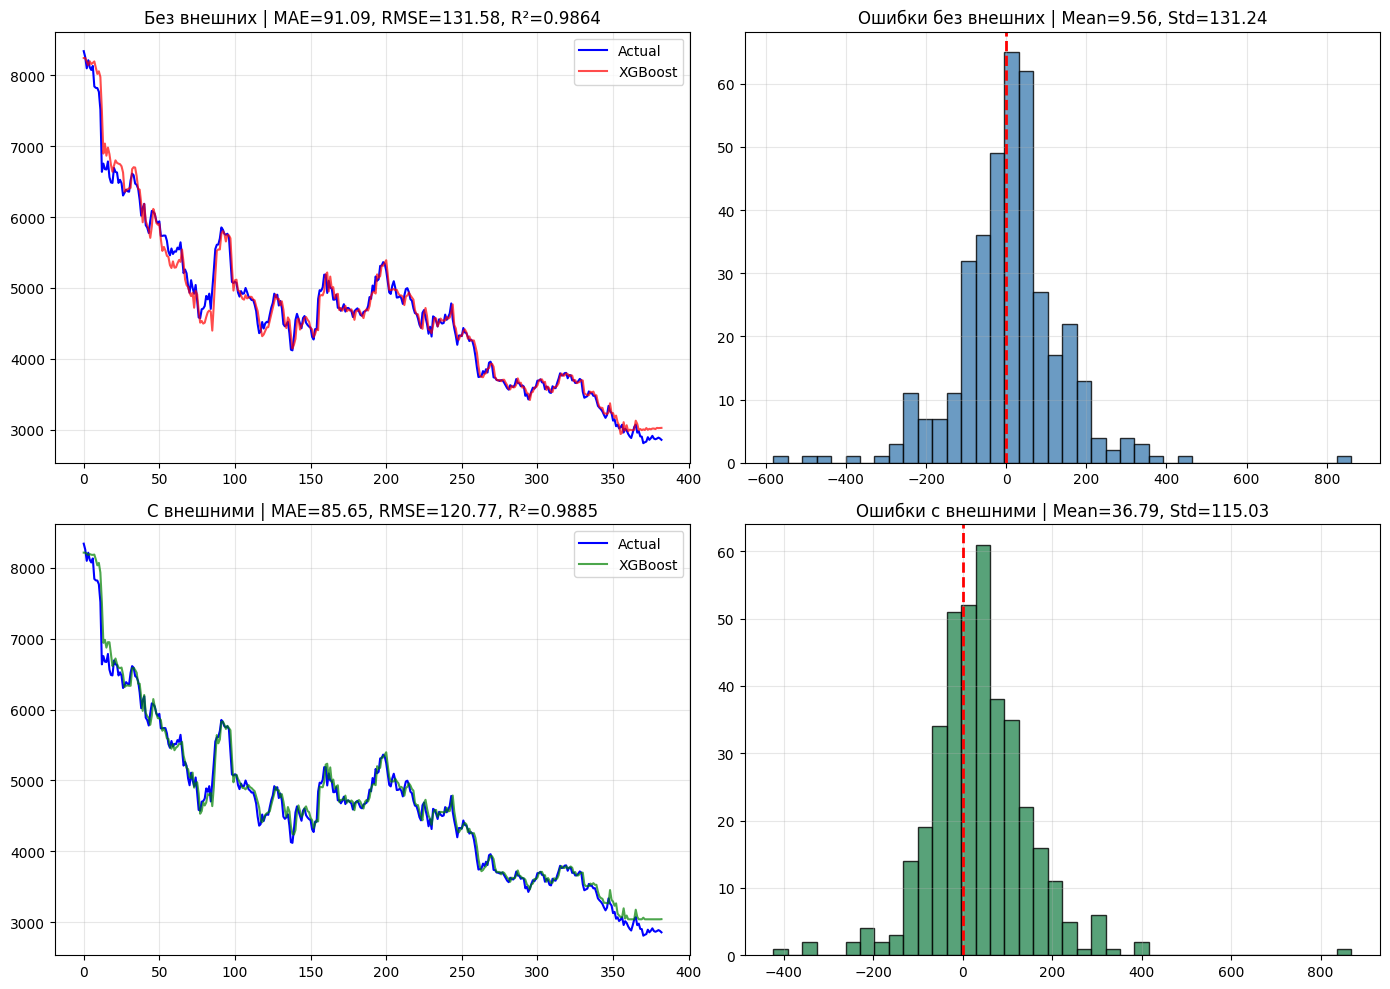


График сохранен: xgboost_results.png


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата']).dt.strftime("%Y-%m-%d")
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")

result = new_data.merge(data, on='Дата', how='left')
result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    histogram = macd - signal_line
    return macd, signal_line, histogram

def create_features_optimized(data, include_external=True):
    df = data.copy()

    df['Open_today'] = df['Открытие']

    for lag in [1, 2, 3, 5, 10]:
        df[f'close_lag_{lag}'] = df['Закрытие'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Объем'].shift(lag)

    for window in [3, 5, 10, 20, 50]:
        df[f'close_sma_{window}'] = df['close_lag_1'].rolling(window).mean()
        df[f'close_ema_{window}'] = df['close_lag_1'].ewm(span=window, adjust=False).mean()
        df[f'volume_sma_{window}'] = df['volume_lag_1'].rolling(window).mean()

    df['return_1'] = df['close_lag_1'].pct_change()
    df['return_3'] = df['close_lag_3'].pct_change()
    df['return_5'] = df['close_lag_5'].pct_change()
    df['return_10'] = df['close_lag_10'].pct_change()

    df['high_low_ratio'] = df['Максимум'].shift(1) / (df['Минимум'].shift(1) + 1e-10)
    df['close_open_ratio'] = df['close_lag_1'] / (df['Открытие'].shift(1) + 1e-10)

    df['volatility'] = df['close_lag_1'].rolling(10).std()

    # Индикаторы
    df['RSI'] = calculate_rsi(df['close_lag_1'], 14)
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = calculate_macd(df['close_lag_1'])

    # Bollinger Bands
    df['BB_middle'] = df['close_lag_1'].rolling(20).mean()
    bb_std = df['close_lag_1'].rolling(20).std()
    df['BB_upper'] = df['BB_middle'] + 2 * bb_std
    df['BB_lower'] = df['BB_middle'] - 2 * bb_std
    df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / df['BB_middle']
    df['BB_position'] = (df['close_lag_1'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'] + 1e-10)

    # Stochastic
    low_14 = df['close_lag_1'].rolling(14).min()
    high_14 = df['close_lag_1'].rolling(14).max()
    df['Stoch_K'] = 100 * (df['close_lag_1'] - low_14) / (high_14 - low_14 + 1e-10)
    df['Stoch_D'] = df['Stoch_K'].rolling(3).mean()

    # ATR
    high_shift = df['Максимум'].shift(1)
    low_shift = df['Минимум'].shift(1)
    close_shift2 = df['Закрытие'].shift(2)
    tr1 = high_shift - low_shift
    tr2 = abs(high_shift - close_shift2)
    tr3 = abs(low_shift - close_shift2)
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df['ATR'] = tr.rolling(14).mean()

    df['date'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter

    if include_external:
        for lag in [1, 2, 3, 5]:
            df[f'kurs_lag_{lag}'] = df['Курс'].shift(lag)
            df[f'value_lag_{lag}'] = df['Значение'].shift(lag)

        df['kurs_return_1'] = df['kurs_lag_1'].pct_change()
        df['kurs_return_3'] = df['kurs_lag_3'].pct_change()
        df['value_return_1'] = df['value_lag_1'].pct_change()
        df['value_return_3'] = df['value_lag_3'].pct_change()

        df['close_kurs_ratio'] = df['close_lag_1'] / df['kurs_lag_1']
        df['close_value_ratio'] = df['close_lag_1'] / df['value_lag_1']
        df['kurs_value_ratio'] = df['kurs_lag_1'] / df['value_lag_1']

    feature_cols = [col for col in df.columns if any(x in col for x in
                     ['Open_today', '_lag_', '_sma_', '_ema_', 'return', 'day_of_week', 'month', 'quarter',
                      'ratio', 'kurs', 'value', 'high_low', 'close_open', 'volatility',
                      'RSI', 'MACD', 'BB_', 'Stoch', 'ATR'])]

    df_clean = df[feature_cols + ['Закрытие']].dropna()
    return df_clean, feature_cols

def train_and_evaluate(df_opt, feature_cols, name):
    X = df_opt[feature_cols].values
    y = df_opt['Закрытие'].values

    train_idx = int(len(X) * 0.8)
    X_train, X_test = X[:train_idx], X[train_idx:]
    y_train, y_test = y[:train_idx], y[train_idx:]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    param_dist = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0],
        'min_child_weight': [1, 3, 5]
    }

    random_search = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=42, n_jobs=-1),
        param_dist,
        n_iter=30,
        cv=TimeSeriesSplit(n_splits=3),
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    random_search.fit(X_train, y_train)
    model = random_search.best_estimator_
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    r2 = r2_score(y_test, preds)

    return model, preds, y_test, mae, rmse, mape, r2, random_search.best_params_

print("="*70)
print("XGBoost С ИНДИКАТОРАМИ")
print("="*70)

# Модель без внешних
print("\n1. Модель БЕЗ внешних факторов")
df_wo, cols_wo = create_features_optimized(result, include_external=False)
print(f"Признаков: {len(cols_wo)}")
model_wo, pred_wo, y_test_wo, mae_wo, rmse_wo, mape_wo, r2_wo, params_wo = train_and_evaluate(df_wo, cols_wo, "Без внешних")

# Модель с внешними
print("\n2. Модель С внешними факторами")
df_w, cols_w = create_features_optimized(result, include_external=True)
print(f"Признаков: {len(cols_w)}")
model_w, pred_w, y_test_w, mae_w, rmse_w, mape_w, r2_w, params_w = train_and_evaluate(df_w, cols_w, "С внешними")

# Результаты
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ")
print("="*70)
print(f"{'Модель':<20} {'MAE':>10} {'RMSE':>10} {'MAPE(%)':>10} {'R²':>10}")
print("-"*60)
print(f"{'Без внешних':<20} {mae_wo:>10.2f} {rmse_wo:>10.2f} {mape_wo:>10.2f} {r2_wo:>10.4f}")
print(f"{'С внешними':<20} {mae_w:>10.2f} {rmse_w:>10.2f} {mape_w:>10.2f} {r2_w:>10.4f}")

# Графики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(y_test_wo, label='Actual', linewidth=1.5, color='blue')
axes[0, 0].plot(pred_wo, label='XGBoost', linewidth=1.5, color='red', alpha=0.7)
axes[0, 0].set_title(f'Без внешних | MAE={mae_wo:.2f}, RMSE={rmse_wo:.2f}, R²={r2_wo:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

errors_wo = pred_wo - y_test_wo
axes[0, 1].hist(errors_wo, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title(f'Ошибки без внешних | Mean={np.mean(errors_wo):.2f}, Std={np.std(errors_wo):.2f}')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(y_test_w, label='Actual', linewidth=1.5, color='blue')
axes[1, 0].plot(pred_w, label='XGBoost', linewidth=1.5, color='green', alpha=0.7)
axes[1, 0].set_title(f'С внешними | MAE={mae_w:.2f}, RMSE={rmse_w:.2f}, R²={r2_w:.4f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

errors_w = pred_w - y_test_w
axes[1, 1].hist(errors_w, bins=40, alpha=0.8, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title(f'Ошибки с внешними | Mean={np.mean(errors_w):.2f}, Std={np.std(errors_w):.2f}')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('xgboost_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: xgboost_results.png")

In [ ]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\n" + "="*70)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ")
print("="*70)

errors_wo = pred_wo - y_test_wo
errors_w = pred_w - y_test_w

def analyze_residuals_full(residuals, model_name):
    residuals = np.array(residuals).flatten()
    n = len(residuals)

    print(f"\n{'='*60}")
    print(f"Модель: {model_name}")
    print(f"{'='*60}")

    print(f"\n1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
    print(f"   Количество: {n}")
    print(f"   Среднее:    {np.mean(residuals):.4f}")
    print(f"   Стд.откл:   {np.std(residuals):.4f}")
    print(f"   Медиана:    {np.median(residuals):.4f}")
    print(f"   Минимум:    {np.min(residuals):.4f}")
    print(f"   Максимум:   {np.max(residuals):.4f}")
    print(f"   Асимметрия: {stats.skew(residuals):.4f}")
    print(f"   Эксцесс:    {stats.kurtosis(residuals):.4f}")

    print(f"\n2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:")
    if n > 5000:
        sample = np.random.choice(residuals, 5000, replace=False)
        shapiro_stat, shapiro_p = stats.shapiro(sample)
    else:
        shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"   Шапиро-Уилк:      stat={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

    ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))
    print(f"   Колмогоров-Смирнов: stat={ks_stat:.4f}, p-value={ks_p:.4f}")

    print(f"\n3. ТЕСТ НА БЕЛЫЙ ШУМ:")
    lb_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_stat = lb_result['lb_stat'].values[0]
    lb_p = lb_result['lb_pvalue'].values[0]
    print(f"   Льюнг-Бокс (lag=10): stat={lb_stat:.4f}, p-value={lb_p:.4f}")

    diff = np.diff(residuals)
    dw_stat = np.sum(diff**2) / np.sum(residuals**2)
    print(f"   Дарбин-Ватсон:      stat={dw_stat:.4f}")

    print(f"\n4. ИНТЕРПРЕТАЦИЯ:")
    if shapiro_p < 0.05:
        print("   Распределение НЕ нормальное (p < 0.05)")
    else:
        print("   Распределение нормальное (p >= 0.05)")

    if lb_p < 0.05:
        print("   Ошибки НЕ белый шум (p < 0.05)")
    else:
        print("   Ошибки - белый шум (p >= 0.05)")

    if dw_stat < 1.5:
        print("   Положительная автокорреляция (DW < 1.5)")
    elif dw_stat > 2.5:
        print("   Отрицательная автокорреляция (DW > 2.5)")
    else:
        print("   Автокорреляция отсутствует (DW ≈ 2)")

    return {'shapiro_p': shapiro_p, 'lb_p': lb_p, 'dw_stat': dw_stat}

# Анализ для обеих моделей
stats_wo = analyze_residuals_full(errors_wo, "XGBoost БЕЗ внешних")
stats_w = analyze_residuals_full(errors_w, "XGBoost С внешними")

# Сравнение моделей
print("\n" + "="*70)
print("СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*70)

print("\n1. XGBoost без внешних vs XGBoost с внешними")
stat, p_wilcoxon = stats.wilcoxon(np.abs(errors_wo), np.abs(errors_w))
print(f"   Тест Уилкоксона: stat={stat:.4f}, p-value={p_wilcoxon:.6f}")

if p_wilcoxon < 0.05:
    if np.mean(np.abs(errors_wo)) < np.mean(np.abs(errors_w)):
        print("   >>> БЕЗ внешних ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
    else:
        print("   >>> С внешними ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
else:
    print("   >>> Различие НЕ значимо (p >= 0.05)")

# Тест знаков
diff_abs = np.abs(errors_wo) - np.abs(errors_w)
n_better_wo = np.sum(diff_abs < 0)
n_better_w = np.sum(diff_abs > 0)
sign_result = stats.binomtest(n_better_wo, n_better_wo + n_better_w, p=0.5)
print(f"\n2. Тест знаков:")
print(f"   Без внешних лучше в {n_better_wo} точках ({n_better_wo/(n_better_wo+n_better_w)*100:.1f}%)")
print(f"   С внешними лучше в  {n_better_w} точках ({n_better_w/(n_better_wo+n_better_w)*100:.1f}%)")
print(f"   p-value = {sign_result.pvalue:.6f}")

if sign_result.pvalue < 0.05:
    if n_better_wo > n_better_w:
        print("   >>> Без внешних значимо чаще лучше")
    else:
        print("   >>> С внешними значимо чаще лучше")
else:
    print("   >>> Различие по знакам не значимо")

print("\n" + "="*70)
print("ИТОГ")
print("="*70)
print(f"MAE без внешних: {mae_wo:.2f}")
print(f"MAE с внешними:  {mae_w:.2f}")
print(f"Разница:         {mae_w - mae_wo:+.2f}")

if mae_wo < mae_w:
    print("\n>>> Рекомендуется модель БЕЗ внешних факторов")
else:
    print("\n>>> Рекомендуется модель С внешними факторами")


СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ

Модель: XGBoost БЕЗ внешних

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Количество: 383
   Среднее:    9.5588
   Стд.откл:   131.2369
   Медиана:    10.4421
   Минимум:    -580.9575
   Максимум:   860.7144
   Асимметрия: 0.3488
   Эксцесс:    6.0233

2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:
   Шапиро-Уилк:      stat=0.9348, p-value=0.0000
   Колмогоров-Смирнов: stat=0.0843, p-value=0.0082

3. ТЕСТ НА БЕЛЫЙ ШУМ:
   Льюнг-Бокс (lag=10): stat=449.4728, p-value=0.0000
   Дарбин-Ватсон:      stat=0.9158

4. ИНТЕРПРЕТАЦИЯ:
   Распределение НЕ нормальное (p < 0.05)
   Ошибки НЕ белый шум (p < 0.05)
   Положительная автокорреляция (DW < 1.5)

Модель: XGBoost С внешними

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Количество: 383
   Среднее:    36.7933
   Стд.откл:   115.0340
   Медиана:    31.0771
   Минимум:    -422.9390
   Максимум:   868.3394
   Асимметрия: 0.9150
   Эксцесс:    7.7407

2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:
   Шапиро-Уилк:      stat=0.9304, p-value=0.0000
   Колмогоров-Смирнов: stat=0.0641, p

In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата']).dt.strftime("%Y-%m-%d")
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")

result = new_data.merge(data, on='Дата', how='left')
result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def create_features_optimized(data, include_external=True):
    df = data.copy()

    df['Open_today'] = df['Открытие']

    for lag in [1, 2, 3, 5, 10]:
        df[f'close_lag_{lag}'] = df['Закрытие'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Объем'].shift(lag)

    for window in [3, 5, 10, 20, 50]:
        df[f'close_sma_{window}'] = df['close_lag_1'].rolling(window).mean()
        df[f'volume_sma_{window}'] = df['volume_lag_1'].rolling(window).mean()

    df['return_1'] = df['close_lag_1'].pct_change()
    df['return_3'] = df['close_lag_3'].pct_change()
    df['return_5'] = df['close_lag_5'].pct_change()
    df['return_10'] = df['close_lag_10'].pct_change()

    df['high_low_ratio'] = df['Максимум'].shift(1) / (df['Минимум'].shift(1) + 1e-10)
    df['close_open_ratio'] = df['close_lag_1'] / (df['Открытие'].shift(1) + 1e-10)

    df['volatility'] = df['close_lag_1'].rolling(10).std()

    df['date'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter

    if include_external:
        for lag in [1, 2, 3, 5]:
            df[f'kurs_lag_{lag}'] = df['Курс'].shift(lag)
            df[f'value_lag_{lag}'] = df['Значение'].shift(lag)

        df['kurs_return_1'] = df['kurs_lag_1'].pct_change()
        df['kurs_return_3'] = df['kurs_lag_3'].pct_change()
        df['value_return_1'] = df['value_lag_1'].pct_change()
        df['value_return_3'] = df['value_lag_3'].pct_change()

        df['close_kurs_ratio'] = df['close_lag_1'] / df['kurs_lag_1']
        df['close_value_ratio'] = df['close_lag_1'] / df['value_lag_1']
        df['kurs_value_ratio'] = df['kurs_lag_1'] / df['value_lag_1']

    feature_cols = [col for col in df.columns if any(x in col for x in
                     ['Open_today', '_lag_', '_sma_', 'return', 'day_of_week', 'month', 'quarter',
                      'ratio', 'kurs', 'value', 'high_low', 'close_open', 'volatility'])]

    df_clean = df[feature_cols + ['Закрытие']].dropna()
    return df_clean, feature_cols

print("Создание признаков...")
df_opt, feature_cols = create_features_optimized(result, include_external=True)
X = df_opt[feature_cols].values
y = df_opt['Закрытие'].values

print(f"Признаков: {len(feature_cols)}")
print(f"Размер данных: {X.shape}")

train_idx = int(len(X) * 0.8)
X_train, X_test = X[:train_idx], X[train_idx:]
y_train, y_test = y[:train_idx], y[train_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2, 0.3],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
}

print("Случайный поиск параметров...")
random_search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_dist,
    n_iter=50,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=0
)

random_search.fit(X_train, y_train)

print(f"\nЛучшие параметры: {random_search.best_params_}")
print(f"Лучший MAE: {-random_search.best_score_:.2f}")

model = random_search.best_estimator_
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
r2 = r2_score(y_test, preds)

print(f"\nРезультаты на тесте:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")

naive = X_test[:, 0]
naive_mae = mean_absolute_error(y_test, naive)
print(f"\nNaive (Open_today): MAE = {naive_mae:.2f}")
print(f"Улучшение: {(1 - mae/naive_mae)*100:.1f}%")

importance = model.feature_importances_
fi = sorted(zip(feature_cols, importance), key=lambda x: x[1], reverse=True)[:10]
print(f"\nТоп-10 важных признаков:")
for name, imp in fi:
    print(f"  {name}: {imp:.4f}")

Создание признаков...
Признаков: 46
Размер данных: (1913, 46)
Случайный поиск параметров...

Лучшие параметры: {'subsample': 0.7, 'n_estimators': 400, 'min_child_weight': 10, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Лучший MAE: 247.00

Результаты на тесте:
MAE: 85.09
RMSE: 122.87
MAPE: 1.82%
R²: 0.9881

Naive (Open_today): MAE = 4637.81
Улучшение: 98.2%

Топ-10 важных признаков:
  close_sma_3: 0.2685
  Open_today: 0.2068
  value_lag_1: 0.1720
  close_lag_1: 0.1587
  value_lag_3: 0.0469
  close_sma_5: 0.0312
  close_lag_2: 0.0299
  value_lag_2: 0.0224
  close_lag_3: 0.0160
  close_sma_20: 0.0139


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from skopt import BayesSearchCV
from skopt.space import Integer, Real
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата']).dt.strftime("%Y-%m-%d")
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")

result = new_data.merge(data, on='Дата', how='left')
result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def create_features_optimized(data, include_external=True):
    df = data.copy()

    df['Open_today'] = df['Открытие']

    for lag in [1, 2, 3, 5, 10]:
        df[f'close_lag_{lag}'] = df['Закрытие'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Объем'].shift(lag)

    for window in [3, 5, 10, 20, 50]:
        df[f'close_sma_{window}'] = df['close_lag_1'].rolling(window).mean()
        df[f'volume_sma_{window}'] = df['volume_lag_1'].rolling(window).mean()

    df['return_1'] = df['close_lag_1'].pct_change()
    df['return_3'] = df['close_lag_3'].pct_change()
    df['return_5'] = df['close_lag_5'].pct_change()
    df['return_10'] = df['close_lag_10'].pct_change()

    df['high_low_ratio'] = df['Максимум'].shift(1) / (df['Минимум'].shift(1) + 1e-10)
    df['close_open_ratio'] = df['close_lag_1'] / (df['Открытие'].shift(1) + 1e-10)

    df['volatility'] = df['close_lag_1'].rolling(10).std()

    df['date'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter

    if include_external:
        for lag in [1, 2, 3, 5]:
            df[f'kurs_lag_{lag}'] = df['Курс'].shift(lag)
            df[f'value_lag_{lag}'] = df['Значение'].shift(lag)

        df['kurs_return_1'] = df['kurs_lag_1'].pct_change()
        df['kurs_return_3'] = df['kurs_lag_3'].pct_change()
        df['value_return_1'] = df['value_lag_1'].pct_change()
        df['value_return_3'] = df['value_lag_3'].pct_change()

        df['close_kurs_ratio'] = df['close_lag_1'] / df['kurs_lag_1']
        df['close_value_ratio'] = df['close_lag_1'] / df['value_lag_1']
        df['kurs_value_ratio'] = df['kurs_lag_1'] / df['value_lag_1']

    feature_cols = [col for col in df.columns if any(x in col for x in
                     ['Open_today', '_lag_', '_sma_', 'return', 'day_of_week', 'month', 'quarter',
                      'ratio', 'kurs', 'value', 'high_low', 'close_open', 'volatility'])]

    df_clean = df[feature_cols + ['Закрытие']].dropna()
    return df_clean, feature_cols

print("Создание признаков...")
df_opt, feature_cols = create_features_optimized(result, include_external=True)
X = df_opt[feature_cols].values
y = df_opt['Закрытие'].values

print(f"Признаков: {len(feature_cols)}")
print(f"Размер данных: {X.shape}")

train_idx = int(len(X) * 0.8)
X_train, X_test = X[:train_idx], X[train_idx:]
y_train, y_test = y[:train_idx], y[train_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

param_space = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, 'log-uniform'),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'min_child_weight': Integer(1, 10)
}

print("Байесовский поиск параметров...")
bayes = BayesSearchCV(
    xgb.XGBRegressor(random_state=42, n_jobs=-1),
    param_space,
    n_iter=50,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42
)

bayes.fit(X_train, y_train)

print(f"\nЛучшие параметры: {bayes.best_params_}")
print(f"Лучший MAE: {-bayes.best_score_:.2f}")

model = bayes.best_estimator_
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
r2 = r2_score(y_test, preds)

print(f"\nРезультаты на тесте:")
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")

naive = X_test[:, 0]
naive_mae = mean_absolute_error(y_test, naive)
print(f"\nNaive (Open_today): MAE = {naive_mae:.2f}")
print(f"Улучшение: {(1 - mae/naive_mae)*100:.1f}%")

importance = model.feature_importances_
fi = sorted(zip(feature_cols, importance), key=lambda x: x[1], reverse=True)[:10]
print(f"\nТоп-10 важных признаков:")
for name, imp in fi:
    print(f"  {name}: {imp:.4f}")

Создание признаков...
Признаков: 46
Размер данных: (1913, 46)
Байесовский поиск параметров...

Лучшие параметры: OrderedDict({'colsample_bytree': 0.729817228685212, 'learning_rate': 0.019868405795616884, 'max_depth': 3, 'min_child_weight': 10, 'n_estimators': 312, 'subsample': 0.7098117168359961})
Лучший MAE: 236.19

Результаты на тесте:
MAE: 85.96
RMSE: 121.14
MAPE: 1.84%
R²: 0.9884

Naive (Open_today): MAE = 4637.81
Улучшение: 98.1%

Топ-10 важных признаков:
  close_sma_3: 0.2330
  value_lag_1: 0.1876
  Open_today: 0.1857
  close_lag_1: 0.1777
  close_lag_2: 0.0426
  close_lag_3: 0.0323
  value_lag_3: 0.0287
  value_lag_2: 0.0283
  close_sma_5: 0.0280
  close_sma_20: 0.0145


LightGBM С ЛАГОВЫМИ ОШИБКАМИ

1. Модель БЕЗ внешних факторов
Признаков: 54

2. Модель С внешними факторами
Признаков: 69

РЕЗУЛЬТАТЫ
Модель                      MAE       RMSE    MAPE(%)         R²
------------------------------------------------------------
Без внешних               97.43     145.94       2.14     0.9832
С внешними               107.81     160.08       2.42     0.9798

СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ

Модель: LightGBM БЕЗ внешних

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Среднее:    17.9663
   Стд.откл:   144.8335
   Асимметрия: 0.9315
   Эксцесс:    6.7042

2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:
   Шапиро-Уилк: p-value=0.0000
   Колмогоров-Смирнов: p-value=0.0002

3. ТЕСТ НА БЕЛЫЙ ШУМ:
   Льюнг-Бокс (lag=10): p-value=0.0000
   Дарбин-Ватсон: stat=0.8008

4. ИНТЕРПРЕТАЦИЯ:
   Распределение НЕ нормальное
   Ошибки НЕ белый шум
   Положительная автокорреляция

Модель: LightGBM С внешними

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Среднее:    51.9279
   Стд.откл:   151.4211
   Асимметрия: 1.3942
   Эксцес

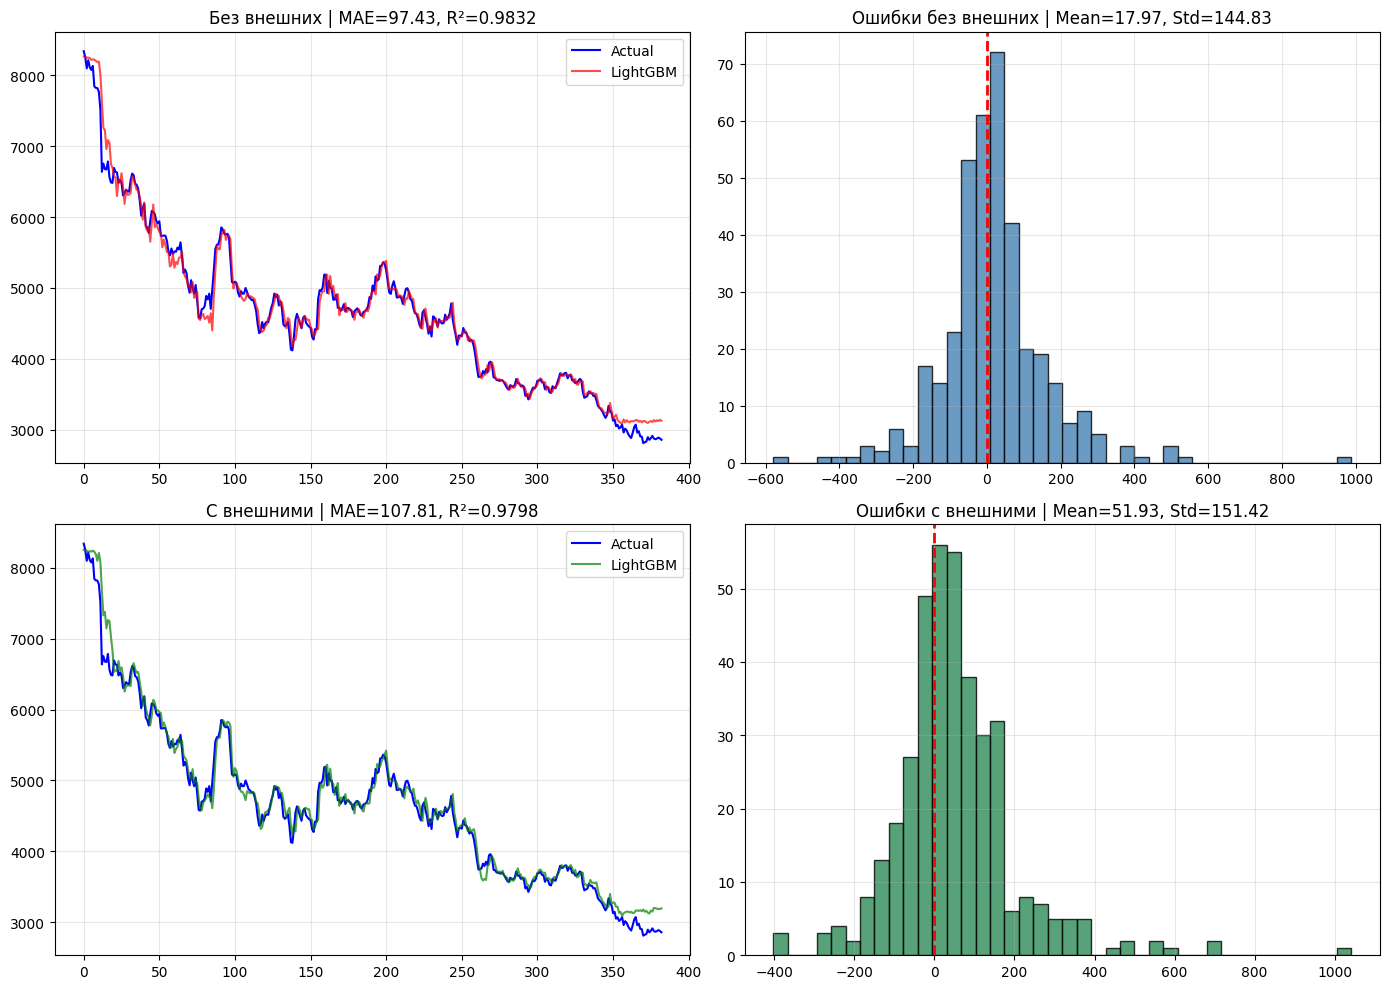


График сохранен: lightgbm_with_lags.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл отправлен на скачивание


In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата']).dt.strftime("%Y-%m-%d")
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")

result = new_data.merge(data, on='Дата', how='left')
result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

def calculate_macd(prices, fast=12, slow=26, signal=9):
    ema_fast = prices.ewm(span=fast, adjust=False).mean()
    ema_slow = prices.ewm(span=slow, adjust=False).mean()
    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    histogram = macd - signal_line
    return macd, signal_line, histogram

def create_features_with_lags(data, include_external=True):
    df = data.copy()

    df['Open_today'] = df['Открытие']

    for lag in [1, 2, 3, 5, 10]:
        df[f'close_lag_{lag}'] = df['Закрытие'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Объем'].shift(lag)

    for window in [3, 5, 10, 20, 50]:
        df[f'close_sma_{window}'] = df['close_lag_1'].rolling(window).mean()
        df[f'close_ema_{window}'] = df['close_lag_1'].ewm(span=window, adjust=False).mean()
        df[f'volume_sma_{window}'] = df['volume_lag_1'].rolling(window).mean()

    df['return_1'] = df['close_lag_1'].pct_change()
    df['return_3'] = df['close_lag_3'].pct_change()
    df['return_5'] = df['close_lag_5'].pct_change()
    df['return_10'] = df['close_lag_10'].pct_change()

    df['high_low_ratio'] = df['Максимум'].shift(1) / (df['Минимум'].shift(1) + 1e-10)
    df['close_open_ratio'] = df['close_lag_1'] / (df['Открытие'].shift(1) + 1e-10)

    df['volatility'] = df['close_lag_1'].rolling(10).std()

    df['RSI'] = calculate_rsi(df['close_lag_1'], 14)
    df['MACD'], df['MACD_signal'], df['MACD_hist'] = calculate_macd(df['close_lag_1'])

    df['BB_middle'] = df['close_lag_1'].rolling(20).mean()
    bb_std = df['close_lag_1'].rolling(20).std()
    df['BB_upper'] = df['BB_middle'] + 2 * bb_std
    df['BB_lower'] = df['BB_middle'] - 2 * bb_std
    df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / df['BB_middle']
    df['BB_position'] = (df['close_lag_1'] - df['BB_lower']) / (df['BB_upper'] - df['BB_lower'] + 1e-10)

    low_14 = df['close_lag_1'].rolling(14).min()
    high_14 = df['close_lag_1'].rolling(14).max()
    df['Stoch_K'] = 100 * (df['close_lag_1'] - low_14) / (high_14 - low_14 + 1e-10)
    df['Stoch_D'] = df['Stoch_K'].rolling(3).mean()

    high_shift = df['Максимум'].shift(1)
    low_shift = df['Минимум'].shift(1)
    close_shift2 = df['Закрытие'].shift(2)
    tr1 = high_shift - low_shift
    tr2 = abs(high_shift - close_shift2)
    tr3 = abs(low_shift - close_shift2)
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df['ATR'] = tr.rolling(14).mean()

    # ЛАГОВЫЕ ОШИБКИ
    df['error_proxy'] = df['close_lag_1'] - df['Открытие'].shift(1)
    df['error_lag1'] = df['error_proxy'].shift(1)
    df['error_lag2'] = df['error_proxy'].shift(2)
    df['error_lag3'] = df['error_proxy'].shift(3)
    df['error_ma5'] = df['error_proxy'].rolling(5).mean()
    df['error_std5'] = df['error_proxy'].rolling(5).std()

    df['date'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter

    if include_external:
        for lag in [1, 2, 3, 5]:
            df[f'kurs_lag_{lag}'] = df['Курс'].shift(lag)
            df[f'value_lag_{lag}'] = df['Значение'].shift(lag)

        df['kurs_return_1'] = df['kurs_lag_1'].pct_change()
        df['kurs_return_3'] = df['kurs_lag_3'].pct_change()
        df['value_return_1'] = df['value_lag_1'].pct_change()
        df['value_return_3'] = df['value_lag_3'].pct_change()

        df['close_kurs_ratio'] = df['close_lag_1'] / df['kurs_lag_1']
        df['close_value_ratio'] = df['close_lag_1'] / df['value_lag_1']
        df['kurs_value_ratio'] = df['kurs_lag_1'] / df['value_lag_1']

    feature_cols = [col for col in df.columns if any(x in col for x in
                     ['Open_today', '_lag_', '_sma_', '_ema_', 'return', 'day_of_week', 'month', 'quarter',
                      'ratio', 'kurs', 'value', 'high_low', 'close_open', 'volatility',
                      'RSI', 'MACD', 'BB_', 'Stoch', 'ATR', 'error_'])]

    df_clean = df[feature_cols + ['Закрытие']].dropna()
    return df_clean, feature_cols

def train_and_evaluate(df_opt, feature_cols, name):
    X = df_opt[feature_cols].values
    y = df_opt['Закрытие'].values

    train_idx = int(len(X) * 0.8)
    X_train, X_test = X[:train_idx], X[train_idx:]
    y_train, y_test = y[:train_idx], y[train_idx:]

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    param_dist = {
        'n_estimators': [100, 200, 300, 400, 500],
        'max_depth': [3, 5, 7, 9, 11],
        'learning_rate': [0.01, 0.03, 0.05, 0.07, 0.1],
        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
        'num_leaves': [20, 31, 50, 75, 100],
        'min_child_samples': [5, 10, 20, 30, 50]
    }

    random_search = RandomizedSearchCV(
        lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        param_dist,
        n_iter=30,
        cv=TimeSeriesSplit(n_splits=3),
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )

    random_search.fit(X_train, y_train)
    model = random_search.best_estimator_
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    r2 = r2_score(y_test, preds)

    return model, preds, y_test, mae, rmse, mape, r2, random_search.best_params_

def analyze_residuals_full(residuals, model_name):
    residuals = np.array(residuals).flatten()
    n = len(residuals)

    print(f"\n{'='*60}")
    print(f"Модель: {model_name}")
    print(f"{'='*60}")

    print(f"\n1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
    print(f"   Среднее:    {np.mean(residuals):.4f}")
    print(f"   Стд.откл:   {np.std(residuals):.4f}")
    print(f"   Асимметрия: {stats.skew(residuals):.4f}")
    print(f"   Эксцесс:    {stats.kurtosis(residuals):.4f}")

    print(f"\n2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:")
    if n > 5000:
        sample = np.random.choice(residuals, 5000, replace=False)
        shapiro_stat, shapiro_p = stats.shapiro(sample)
    else:
        shapiro_stat, shapiro_p = stats.shapiro(residuals)
    print(f"   Шапиро-Уилк: p-value={shapiro_p:.4f}")

    ks_stat, ks_p = stats.kstest(residuals, 'norm', args=(np.mean(residuals), np.std(residuals)))
    print(f"   Колмогоров-Смирнов: p-value={ks_p:.4f}")

    print(f"\n3. ТЕСТ НА БЕЛЫЙ ШУМ:")
    lb_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
    lb_p = lb_result['lb_pvalue'].values[0]
    print(f"   Льюнг-Бокс (lag=10): p-value={lb_p:.4f}")

    diff = np.diff(residuals)
    dw_stat = np.sum(diff**2) / np.sum(residuals**2)
    print(f"   Дарбин-Ватсон: stat={dw_stat:.4f}")

    print(f"\n4. ИНТЕРПРЕТАЦИЯ:")
    if shapiro_p < 0.05:
        print("   Распределение НЕ нормальное")
    else:
        print("   Распределение нормальное")

    if lb_p < 0.05:
        print("   Ошибки НЕ белый шум")
    else:
        print("   Ошибки - белый шум")

    if dw_stat < 1.5:
        print("   Положительная автокорреляция")
    elif dw_stat > 2.5:
        print("   Отрицательная автокорреляция")
    else:
        print("   Автокорреляция отсутствует")

    return {'shapiro_p': shapiro_p, 'lb_p': lb_p, 'dw_stat': dw_stat}

print("="*70)
print("LightGBM С ЛАГОВЫМИ ОШИБКАМИ")
print("="*70)

# Модель без внешних
print("\n1. Модель БЕЗ внешних факторов")
df_wo, cols_wo = create_features_with_lags(result, include_external=False)
print(f"Признаков: {len(cols_wo)}")
model_wo, pred_wo, y_test_wo, mae_wo, rmse_wo, mape_wo, r2_wo, params_wo = train_and_evaluate(df_wo, cols_wo, "Без внешних")

# Модель с внешними
print("\n2. Модель С внешними факторами")
df_w, cols_w = create_features_with_lags(result, include_external=True)
print(f"Признаков: {len(cols_w)}")
model_w, pred_w, y_test_w, mae_w, rmse_w, mape_w, r2_w, params_w = train_and_evaluate(df_w, cols_w, "С внешними")

# Результаты
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ")
print("="*70)
print(f"{'Модель':<20} {'MAE':>10} {'RMSE':>10} {'MAPE(%)':>10} {'R²':>10}")
print("-"*60)
print(f"{'Без внешних':<20} {mae_wo:>10.2f} {rmse_wo:>10.2f} {mape_wo:>10.2f} {r2_wo:>10.4f}")
print(f"{'С внешними':<20} {mae_w:>10.2f} {rmse_w:>10.2f} {mape_w:>10.2f} {r2_w:>10.4f}")

# Статистический анализ
print("\n" + "="*70)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ")
print("="*70)

errors_wo = pred_wo - y_test_wo
errors_w = pred_w - y_test_w

stats_wo = analyze_residuals_full(errors_wo, "LightGBM БЕЗ внешних")
stats_w = analyze_residuals_full(errors_w, "LightGBM С внешними")

# Сравнение
print("\n" + "="*70)
print("СТАТИСТИЧЕСКОЕ СРАВНЕНИЕ")
print("="*70)

stat, p_wilcoxon = stats.wilcoxon(np.abs(errors_wo), np.abs(errors_w))
print(f"\nТест Уилкоксона: p-value={p_wilcoxon:.6f}")
if p_wilcoxon < 0.05:
    if mae_wo < mae_w:
        print(">>> БЕЗ внешних ЗНАЧИМО ЛУЧШЕ")
    else:
        print(">>> С внешними ЗНАЧИМО ЛУЧШЕ")
else:
    print(">>> Различие НЕ значимо")

diff_abs = np.abs(errors_wo) - np.abs(errors_w)
n_better_wo = np.sum(diff_abs < 0)
n_better_w = np.sum(diff_abs > 0)
sign_result = stats.binomtest(n_better_wo, n_better_wo + n_better_w, p=0.5)
print(f"\nТест знаков: без={n_better_wo}, с={n_better_w}, p={sign_result.pvalue:.6f}")

print("\n" + "="*70)
print("ИТОГ")
print("="*70)
print(f"MAE без внешних: {mae_wo:.2f}")
print(f"MAE с внешними:  {mae_w:.2f}")
print(f"Разница:         {mae_w - mae_wo:+.2f}")

if mae_wo < mae_w:
    print("\n>>> Рекомендуется модель БЕЗ внешних факторов")
else:
    print("\n>>> Рекомендуется модель С внешними факторами")

# Графики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(y_test_wo, label='Actual', linewidth=1.5, color='blue')
axes[0, 0].plot(pred_wo, label='LightGBM', linewidth=1.5, color='red', alpha=0.7)
axes[0, 0].set_title(f'Без внешних | MAE={mae_wo:.2f}, R²={r2_wo:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(errors_wo, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title(f'Ошибки без внешних | Mean={np.mean(errors_wo):.2f}, Std={np.std(errors_wo):.2f}')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(y_test_w, label='Actual', linewidth=1.5, color='blue')
axes[1, 0].plot(pred_w, label='LightGBM', linewidth=1.5, color='green', alpha=0.7)
axes[1, 0].set_title(f'С внешними | MAE={mae_w:.2f}, R²={r2_w:.4f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(errors_w, bins=40, alpha=0.8, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title(f'Ошибки с внешними | Mean={np.mean(errors_w):.2f}, Std={np.std(errors_w):.2f}')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lightgbm_with_lags.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/lightgbm_with_lags.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: lightgbm_with_lags.png")

# Принудительное скачивание для Colab
try:
    from google.colab import files
    files.download('lightgbm_with_lags.png')
    print("Файл отправлен на скачивание")
except:
    print("Не в Colab или ошибка скачивания")

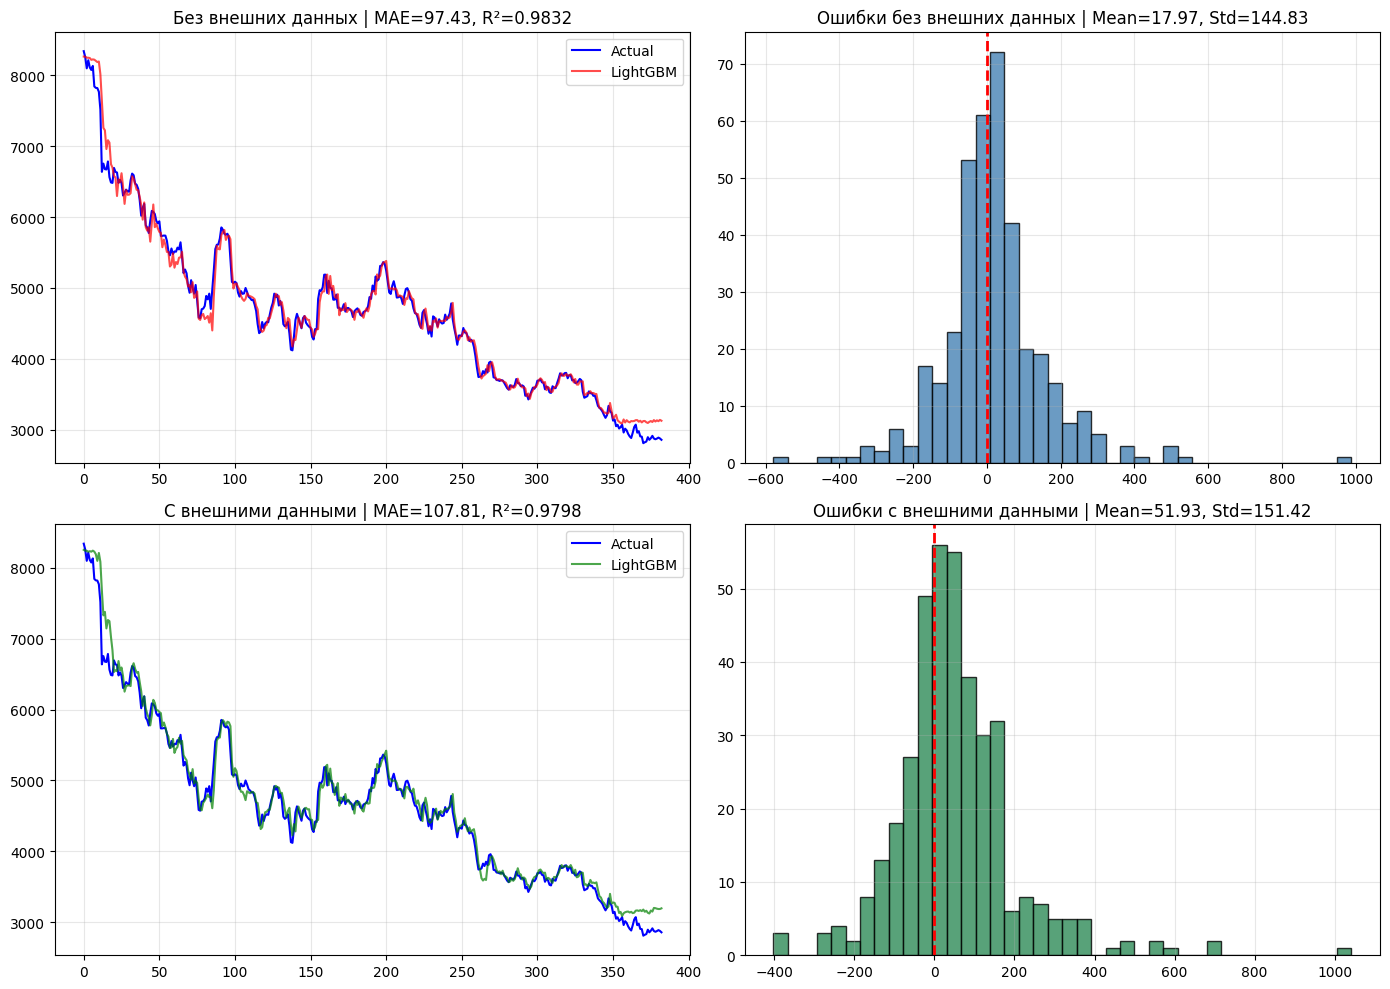


График сохранен: lightgbm_with_lags.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл отправлен на скачивание


In [ ]:
# Графики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(y_test_wo, label='Actual', linewidth=1.5, color='blue')
axes[0, 0].plot(pred_wo, label='LightGBM', linewidth=1.5, color='red', alpha=0.7)
axes[0, 0].set_title(f'Без внешних данных | MAE={mae_wo:.2f}, R²={r2_wo:.4f}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(errors_wo, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title(f'Ошибки без внешних данных | Mean={np.mean(errors_wo):.2f}, Std={np.std(errors_wo):.2f}')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(y_test_w, label='Actual', linewidth=1.5, color='blue')
axes[1, 0].plot(pred_w, label='LightGBM', linewidth=1.5, color='green', alpha=0.7)
axes[1, 0].set_title(f'С внешними данными | MAE={mae_w:.2f}, R²={r2_w:.4f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(errors_w, bins=40, alpha=0.8, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].set_title(f'Ошибки с внешними данными | Mean={np.mean(errors_w):.2f}, Std={np.std(errors_w):.2f}')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lightgbm_with_lags.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/lightgbm_with_lags.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: lightgbm_with_lags.png")

# Принудительное скачивание для Colab
try:
    from google.colab import files
    files.download('lightgbm_with_lags.png')
    print("Файл отправлен на скачивание")
except:
    print("Не в Colab или ошибка скачивания")

GNN

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
new_data['Дата'] = pd.to_datetime(new_data['Дата']).dt.strftime("%Y-%m-%d")
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")

result = new_data.merge(data, on='Дата', how='left')
result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def create_features_optimized(data, include_external=True):
    df = data.copy()

    df['Open_today'] = df['Открытие']

    for lag in [1, 2, 3, 5, 10]:
        df[f'close_lag_{lag}'] = df['Закрытие'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Объем'].shift(lag)

    for window in [3, 5, 10, 20, 50]:
        df[f'close_sma_{window}'] = df['close_lag_1'].rolling(window).mean()
        df[f'volume_sma_{window}'] = df['volume_lag_1'].rolling(window).mean()

    df['return_1'] = df['close_lag_1'].pct_change()
    df['return_3'] = df['close_lag_3'].pct_change()
    df['return_5'] = df['close_lag_5'].pct_change()
    df['return_10'] = df['close_lag_10'].pct_change()

    df['high_low_ratio'] = df['Максимум'].shift(1) / (df['Минимум'].shift(1) + 1e-10)
    df['close_open_ratio'] = df['close_lag_1'] / (df['Открытие'].shift(1) + 1e-10)

    df['volatility'] = df['close_lag_1'].rolling(10).std()

    df['date'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['quarter'] = df['date'].dt.quarter

    if include_external:
        for lag in [1, 2, 3, 5]:
            df[f'kurs_lag_{lag}'] = df['Курс'].shift(lag)
            df[f'value_lag_{lag}'] = df['Значение'].shift(lag)

        df['kurs_return_1'] = df['kurs_lag_1'].pct_change()
        df['kurs_return_3'] = df['kurs_lag_3'].pct_change()
        df['value_return_1'] = df['value_lag_1'].pct_change()
        df['value_return_3'] = df['value_lag_3'].pct_change()

        df['close_kurs_ratio'] = df['close_lag_1'] / df['kurs_lag_1']
        df['close_value_ratio'] = df['close_lag_1'] / df['value_lag_1']
        df['kurs_value_ratio'] = df['kurs_lag_1'] / df['value_lag_1']

    feature_cols = [col for col in df.columns if any(x in col for x in
                     ['Open_today', '_lag_', '_sma_', 'return', 'day_of_week', 'month', 'quarter',
                      'ratio', 'kurs', 'value', 'high_low', 'close_open', 'volatility'])]

    df_clean = df[feature_cols + ['Закрытие']].dropna()
    return df_clean, feature_cols

print("Создание признаков...")
df_opt, feature_cols = create_features_optimized(result, include_external=True)
X = df_opt[feature_cols].values
y = df_opt['Закрытие'].values

print(f"Признаков: {len(feature_cols)}")
print(f"Размер данных: {X.shape}")

train_idx = int(len(X) * 0.8)
X_train, X_test = X[:train_idx], X[train_idx:]
y_train, y_test = y[:train_idx], y[train_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class StockDataset(Dataset):
    def __init__(self, X, y, sequence_length=10):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.X) - self.sequence_length

    def __getitem__(self, idx):
        x = self.X[idx:idx + self.sequence_length]
        y = self.y[idx + self.sequence_length]
        return x, y.unsqueeze(-1)

class GNNModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_layers=2, dropout=0.2):
        super(GNNModel, self).__init__()

        self.input_projection = nn.Linear(input_dim, hidden_dim)
        self.gru = nn.GRU(hidden_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=4, dropout=dropout, batch_first=True)
        self.output_layers = nn.Sequential(
            nn.Linear(hidden_dim, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(8, 1)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.input_projection(x)
        x, _ = self.gru(x)
        x, _ = self.attention(x, x, x)
        x = x[:, -1, :]
        x = self.output_layers(x)
        return x

def train_model(model, train_loader, test_loader, epochs=100, lr=0.001):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"  Используется устройство: {device}")

    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_loss = float('inf')

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        test_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in test_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                test_loss += criterion(outputs, batch_y).item()

        train_loss /= len(train_loader)
        test_loss /= len(test_loader)
        scheduler.step(test_loss)

        if test_loss < best_loss:
            best_loss = test_loss
            torch.save(model.state_dict(), 'best_gnn_model.pth')

        if epoch % 20 == 0:
            print(f"  Epoch {epoch:3d}/{epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")

    model.load_state_dict(torch.load('best_gnn_model.pth'))
    return model

def predict(model, test_loader):
    device = next(model.parameters()).device
    model.eval()
    predictions = []
    actuals = []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            outputs = model(batch_x)
            predictions.extend(outputs.cpu().numpy().flatten())
            actuals.extend(batch_y.numpy().flatten())

    predictions = np.array(predictions).flatten()
    actuals = np.array(actuals).flatten()

    return predictions, actuals

print("\n" + "="*70)
print("ОБУЧЕНИЕ GNN МОДЕЛИ")
print("="*70)

sequence_length = 10
batch_size = 32

train_dataset = StockDataset(X_train, y_train, sequence_length)
test_dataset = StockDataset(X_test, y_test, sequence_length)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

input_dim = X_train.shape[1]

model = GNNModel(input_dim, hidden_dim=32, num_layers=2, dropout=0.2)
print(f"Параметров: {sum(p.numel() for p in model.parameters()):,}")

model = train_model(model, train_loader, test_loader, epochs=100, lr=0.001)

predictions, actuals = predict(model, test_loader)

mae = mean_absolute_error(actuals, predictions)
rmse = np.sqrt(mean_squared_error(actuals, predictions))
mape = np.mean(np.abs((actuals - predictions) / actuals)) * 100
r2 = r2_score(actuals, predictions)

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ НА ТЕСТЕ")
print("="*70)
print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²: {r2:.4f}")

naive = X_test[:len(actuals), 0]
naive_mae = mean_absolute_error(actuals, naive)
print(f"\nNaive (Open_today): MAE = {naive_mae:.2f}")
print(f"Улучшение: {(1 - mae/naive_mae)*100:.1f}%")

Создание признаков...
Признаков: 46
Размер данных: (1913, 46)

ОБУЧЕНИЕ GNN МОДЕЛИ
Параметров: 19,073
  Используется устройство: cpu
  Epoch   0/100 | Train Loss: 24134800.625000 | Test Loss: 21216757.750000
  Epoch  20/100 | Train Loss: 2169509.958333 | Test Loss: 188156.480143
  Epoch  40/100 | Train Loss: 1774520.960938 | Test Loss: 187828.868164
  Epoch  60/100 | Train Loss: 2098057.356771 | Test Loss: 112159.936523
  Epoch  80/100 | Train Loss: 1906093.843750 | Test Loss: 100058.905558

РЕЗУЛЬТАТЫ НА ТЕСТЕ
MAE: 206.02
RMSE: 265.67
MAPE: 4.38%
R²: 0.9278

Naive (Open_today): MAE = 4545.65
Улучшение: 95.5%


arima

SARIMA ДЛЯ ПРОГНОЗИРОВАНИЯ МАГНИТА

1. Автоматический подбор параметров SARIMA...
   order: (2, 1, 0)
   seasonal_order: (0, 0, 0, 5)

2. Обучение SARIMA с пошаговым прогнозом...

РЕЗУЛЬТАТЫ SARIMA
order: (2, 1, 0)
seasonal_order: (0, 0, 0, 5)

MAE:  75.94
RMSE: 109.92
MAPE: 1.60%
R²:   0.9923


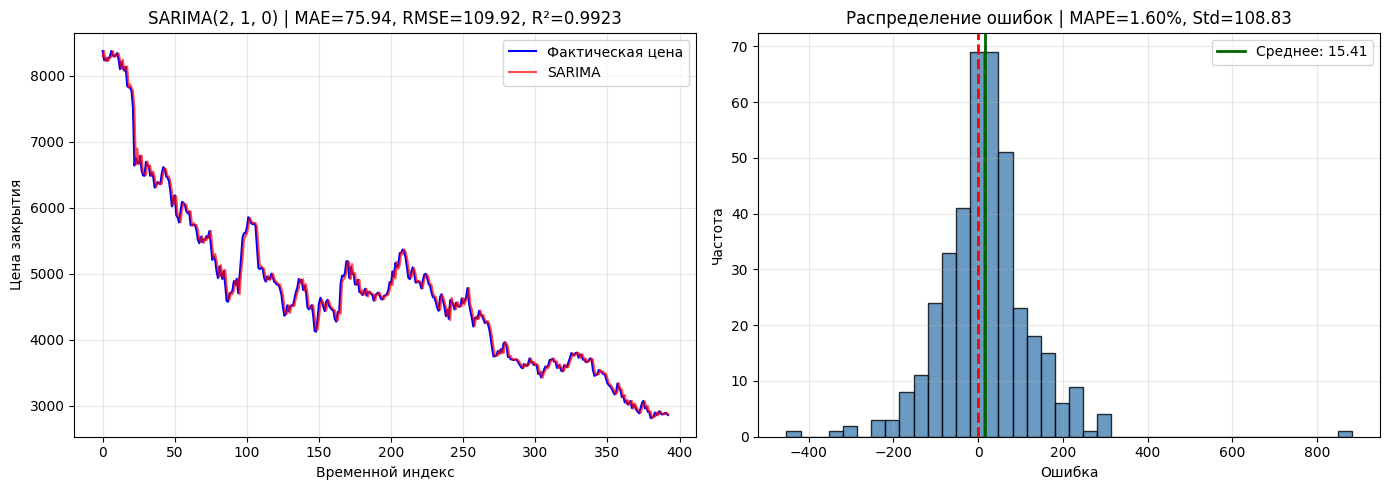

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pmdarima import auto_arima
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def train_evaluate_sarima(train, test, order, seasonal_order):
    """Обучение SARIMA с пошаговым прогнозом на 1 день"""
    try:
        history = list(train)
        predictions = []

        for t in range(len(test)):
            model = SARIMAX(history, order=order, seasonal_order=seasonal_order)
            fitted = model.fit(disp=False)
            y_pred = fitted.forecast(1)[0]
            predictions.append(y_pred)
            history.append(test[t])

        predictions = np.array(predictions)

        mae = mean_absolute_error(test, predictions)
        rmse = np.sqrt(mean_squared_error(test, predictions))
        mape = np.mean(np.abs((test - predictions) / test)) * 100

        baseline = np.mean(train)
        ss_res = np.sum((test - predictions) ** 2)
        ss_tot = np.sum((test - baseline) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

        return mae, rmse, mape, r2, predictions
    except Exception as e:
        print(f"Ошибка: {e}")
        return None, None, None, None, None

def auto_sarima_search(ts, seasonal=True, m=5):
    """Автоматический подбор параметров SARIMA"""
    model = auto_arima(
        ts,
        start_p=0, start_q=0,
        max_p=5, max_q=5,
        start_P=0, start_Q=0,
        max_P=2, max_Q=2,
        seasonal=seasonal,
        m=m,
        stepwise=True,
        trace=False,
        error_action='ignore',
        suppress_warnings=True,
        random_state=42,
        n_fits=30
    )
    return model.order, model.seasonal_order

# Временной ряд Магнита
ts_magnit = result['Закрытие'].values

# Разделение на train/test
train_size = int(len(ts_magnit) * 0.8)
train_y = ts_magnit[:train_size]
test_y = ts_magnit[train_size:]

print("="*70)
print("SARIMA ДЛЯ ПРОГНОЗИРОВАНИЯ МАГНИТА")
print("="*70)

# Автоматический подбор параметров
print("\n1. Автоматический подбор параметров SARIMA...")
order, seasonal_order = auto_sarima_search(train_y, seasonal=True, m=5)
print(f"   order: {order}")
print(f"   seasonal_order: {seasonal_order}")

# Обучение и оценка
print("\n2. Обучение SARIMA с пошаговым прогнозом...")
mae, rmse, mape, r2, predictions = train_evaluate_sarima(train_y, test_y, order, seasonal_order)

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ SARIMA")
print("="*70)
print(f"order: {order}")
print(f"seasonal_order: {seasonal_order}")
print(f"\nMAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.4f}")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(test_y, label='Фактическая цена', linewidth=1.5, color='blue')
axes[0].plot(predictions, label='SARIMA', linewidth=1.5, color='red', alpha=0.7)
axes[0].set_title(f'SARIMA{order} | MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}')
axes[0].set_xlabel('Временной индекс')
axes[0].set_ylabel('Цена закрытия')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors = predictions - test_y
axes[1].hist(errors, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=np.mean(errors), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors):.2f}')
axes[1].set_xlabel('Ошибка')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'Распределение ошибок | MAPE={mape:.2f}%, Std={np.std(errors):.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sarima_results.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/sarima_results.png', dpi=150, bbox_inches='tight')
plt.show()


✓ Файл сохранен: sarima_results.png (124392 байт)


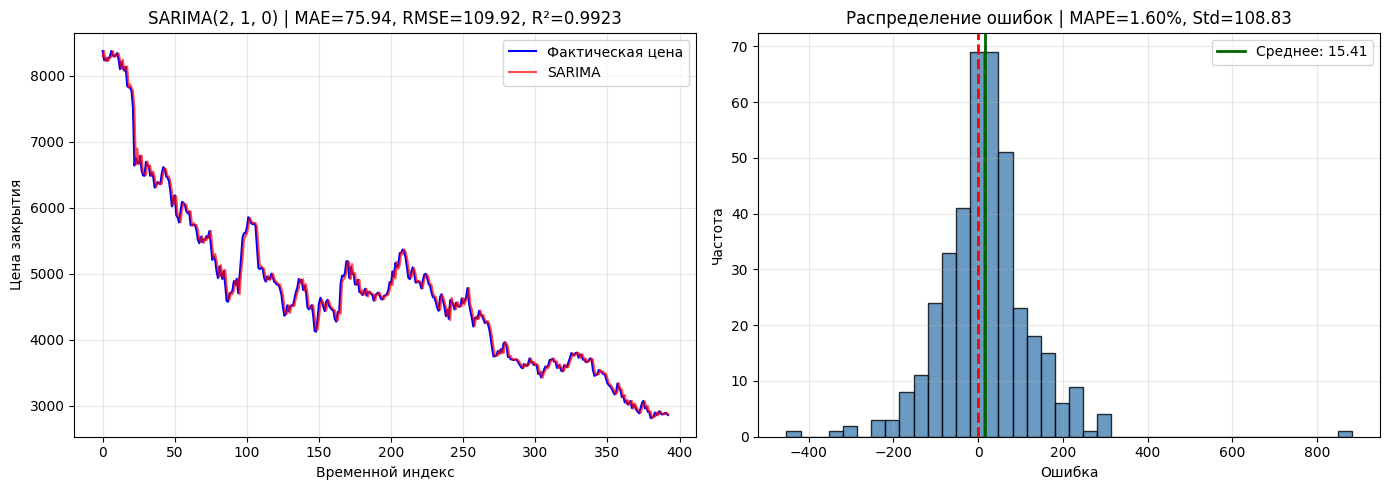

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл отправлен на скачивание


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(test_y, label='Фактическая цена', linewidth=1.5, color='blue')
axes[0].plot(predictions, label='SARIMA', linewidth=1.5, color='red', alpha=0.7)
axes[0].set_title(f'SARIMA{order} | MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}')
axes[0].set_xlabel('Временной индекс')
axes[0].set_ylabel('Цена закрытия')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors = predictions - test_y
axes[1].hist(errors, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=np.mean(errors), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors):.2f}')
axes[1].set_xlabel('Ошибка')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'Распределение ошибок | MAPE={mape:.2f}%, Std={np.std(errors):.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

# Сохранение
plt.savefig('sarima_results.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/sarima_results.png', dpi=150, bbox_inches='tight')

# Проверка существования файла
import os
if os.path.exists('sarima_results.png'):
    print(f"✓ Файл сохранен: sarima_results.png ({os.path.getsize('sarima_results.png')} байт)")
else:
    print("✗ Файл не найден")

plt.show()

# Принудительное скачивание для Google Colab
try:
    from google.colab import files
    files.download('sarima_results.png')
    print("Файл отправлен на скачивание")
except:
    print("Не в Colab или ошибка скачивания")

In [ ]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\n" + "="*70)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ SARIMA")
print("="*70)

errors = predictions - test_y
n = len(errors)

print(f"\n1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
print(f"   Количество наблюдений: {n}")
print(f"   Средняя ошибка (ME):   {np.mean(errors):.4f}")
print(f"   Стандартное отклонение: {np.std(errors):.4f}")
print(f"   Дисперсия:              {np.var(errors):.4f}")
print(f"   Медиана:                {np.median(errors):.4f}")
print(f"   Минимум:                {np.min(errors):.4f}")
print(f"   Максимум:               {np.max(errors):.4f}")
print(f"   Асимметрия (Skewness):  {stats.skew(errors):.4f}")
print(f"   Эксцесс (Kurtosis):     {stats.kurtosis(errors):.4f}")

print(f"\n2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:")
if n > 5000:
    sample = np.random.choice(errors, 5000, replace=False)
    shapiro_stat, shapiro_p = stats.shapiro(sample)
else:
    shapiro_stat, shapiro_p = stats.shapiro(errors)
print(f"   Шапиро-Уилк:      statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

ks_stat, ks_p = stats.kstest(errors, 'norm', args=(np.mean(errors), np.std(errors)))
print(f"   Колмогоров-Смирнов: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")

print(f"\n3. ТЕСТЫ НА БЕЛЫЙ ШУМ:")
lb_result = acorr_ljungbox(errors, lags=[10], return_df=True)
lb_stat = lb_result['lb_stat'].values[0]
lb_p = lb_result['lb_pvalue'].values[0]
print(f"   Льюнг-Бокс (lag=10): statistic={lb_stat:.4f}, p-value={lb_p:.4f}")

diff = np.diff(errors)
dw_stat = np.sum(diff**2) / np.sum(errors**2)
print(f"   Дарбин-Ватсон:      statistic={dw_stat:.4f}")

print(f"\n4. ИНТЕРПРЕТАЦИЯ:")
if shapiro_p < 0.05:
    print("   Распределение ошибок НЕ нормальное (p < 0.05)")
else:
    print("   Распределение ошибок нормальное (p >= 0.05)")

if lb_p < 0.05:
    print("   Ошибки НЕ являются белым шумом (есть автокорреляция)")
else:
    print("   Ошибки являются белым шумом (нет автокорреляции)")

if dw_stat < 1.5:
    print("   Положительная автокорреляция ошибок (DW < 1.5)")
elif dw_stat > 2.5:
    print("   Отрицательная автокорреляция ошибок (DW > 2.5)")
else:
    print("   Автокорреляция ошибок отсутствует (DW ≈ 2)")

if abs(stats.skew(errors)) < 0.5:
    print("   Распределение симметричное")
elif stats.skew(errors) > 0:
    print("   Распределение с правосторонней асимметрией")
else:
    print("   Распределение с левосторонней асимметрией")

# Сравнение с наивным прогнозом
naive_preds = test_y  # замените на ваш наивный прогноз если есть
naive_mae = mean_absolute_error(test_y, naive_preds)  # замените
print(f"\n5. МЕТРИКИ КАЧЕСТВА:")
print(f"   MAE:  {mae:.2f}")
print(f"   RMSE: {rmse:.2f}")
print(f"   MAPE: {mape:.2f}%")
print(f"   R²:   {r2:.4f}")

print("\n" + "="*70)


СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ SARIMA

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Количество наблюдений: 393
   Средняя ошибка (ME):   15.4091
   Стандартное отклонение: 108.8317
   Дисперсия:              11844.3430
   Медиана:                14.8231
   Минимум:                -452.7025
   Максимум:               881.9154
   Асимметрия (Skewness):  1.0718
   Эксцесс (Kurtosis):     10.6441

2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:
   Шапиро-Уилк:      statistic=0.9154, p-value=0.0000
   Колмогоров-Смирнов: statistic=0.0803, p-value=0.0119

3. ТЕСТЫ НА БЕЛЫЙ ШУМ:
   Льюнг-Бокс (lag=10): statistic=25.2059, p-value=0.0050
   Дарбин-Ватсон:      statistic=1.8263

4. ИНТЕРПРЕТАЦИЯ:
   Распределение ошибок НЕ нормальное (p < 0.05)
   Ошибки НЕ являются белым шумом (есть автокорреляция)
   Автокорреляция ошибок отсутствует (DW ≈ 2)
   Распределение с правосторонней асимметрией

5. МЕТРИКИ КАЧЕСТВА:
   MAE:  75.94
   RMSE: 109.92
   MAPE: 1.60%
   R²:   0.9923



SARIMAX

SARIMAX С ВНЕШНИМИ ФАКТОРАМИ
Внешних признаков: 11

order: (1, 1, 1)
seasonal_order: (1, 0, 0, 5)

Обучение SARIMAX с пошаговым прогнозом...

РЕЗУЛЬТАТЫ SARIMAX
MAE:  76.12
RMSE: 109.52
MAPE: 1.61%
R²:   0.9921


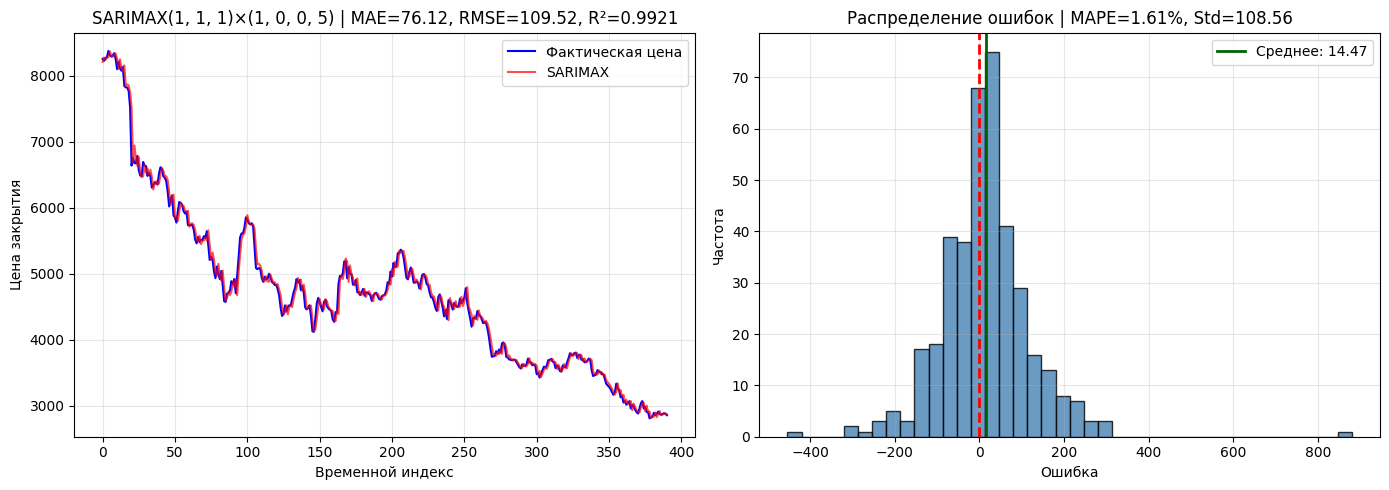


График сохранен: sarimax_results.png


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

# Создание внешних признаков (exogenous)
def create_exog_features(data):
    df = data.copy()

    # Лаговые значения
    for lag in [1, 2, 3]:
        df[f'close_lag_{lag}'] = df['Закрытие'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Объем'].shift(lag)
        df[f'kurs_lag_{lag}'] = df['Курс'].shift(lag)
        df[f'value_lag_{lag}'] = df['Значение'].shift(lag)

    # Технические индикаторы
    df['sma_5'] = df['Закрытие'].shift(1).rolling(5).mean()
    df['sma_10'] = df['Закрытие'].shift(1).rolling(10).mean()
    df['volatility'] = df['Закрытие'].shift(1).rolling(10).std()
    df['return_1'] = df['Закрытие'].shift(1).pct_change()

    # Временные признаки
    df['date'] = pd.to_datetime(df['Дата'])
    df['day_of_week'] = df['date'].dt.dayofweek

    exog_cols = ['close_lag_1', 'close_lag_2', 'close_lag_3',
                 'volume_lag_1', 'kurs_lag_1', 'value_lag_1',
                 'sma_5', 'sma_10', 'volatility', 'return_1', 'day_of_week']

    df_clean = df.dropna()
    return df_clean, exog_cols

df_exog, exog_cols = create_exog_features(result)

# Целевая переменная
ts_magnit = df_exog['Закрытие'].values
X_exog = df_exog[exog_cols].values

# Масштабирование внешних признаков
scaler = StandardScaler()
X_exog_scaled = scaler.fit_transform(X_exog)

# Разделение на train/test
train_size = int(len(ts_magnit) * 0.8)
train_y = ts_magnit[:train_size]
test_y = ts_magnit[train_size:]
train_X = X_exog_scaled[:train_size]
test_X = X_exog_scaled[train_size:]

print("="*70)
print("SARIMAX С ВНЕШНИМИ ФАКТОРАМИ")
print("="*70)
print(f"Внешних признаков: {len(exog_cols)}")

# Параметры (можно подобрать через auto_arima)
order = (1, 1, 1)
seasonal_order = (1, 0, 0, 5)

print(f"\norder: {order}")
print(f"seasonal_order: {seasonal_order}")

# Обучение SARIMAX с пошаговым прогнозом
history_y = list(train_y)
history_X = list(train_X)
predictions = []

print("\nОбучение SARIMAX с пошаговым прогнозом...")
for t in range(len(test_y)):
    model = SARIMAX(
        history_y,
        exog=history_X,
        order=order,
        seasonal_order=seasonal_order
    )
    fitted = model.fit(disp=False)

    # Прогноз на 1 шаг с внешними признаками
    y_pred = fitted.forecast(steps=1, exog=[test_X[t]])[0]
    predictions.append(y_pred)

    # Обновление истории
    history_y.append(test_y[t])
    history_X.append(test_X[t])

predictions = np.array(predictions)

# Метрики
mae = mean_absolute_error(test_y, predictions)
rmse = np.sqrt(mean_squared_error(test_y, predictions))
mape = np.mean(np.abs((test_y - predictions) / test_y)) * 100

baseline = np.mean(train_y)
ss_res = np.sum((test_y - predictions) ** 2)
ss_tot = np.sum((test_y - baseline) ** 2)
r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ SARIMAX")
print("="*70)
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")
print(f"R²:   {r2:.4f}")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(test_y, label='Фактическая цена', linewidth=1.5, color='blue')
axes[0].plot(predictions, label='SARIMAX', linewidth=1.5, color='red', alpha=0.7)
axes[0].set_title(f'SARIMAX{order}×{seasonal_order} | MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}')
axes[0].set_xlabel('Временной индекс')
axes[0].set_ylabel('Цена закрытия')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

errors = predictions - test_y
axes[1].hist(errors, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=np.mean(errors), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors):.2f}')
axes[1].set_xlabel('Ошибка')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'Распределение ошибок | MAPE={mape:.2f}%, Std={np.std(errors):.2f}')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sarimax_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: sarimax_results.png")

In [ ]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\n" + "="*70)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ SARIMAX")
print("="*70)

errors = predictions - test_y
n = len(errors)

print(f"\n1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
print(f"   Количество наблюдений: {n}")
print(f"   Средняя ошибка (ME):   {np.mean(errors):.4f}")
print(f"   Стандартное отклонение: {np.std(errors):.4f}")
print(f"   Дисперсия:              {np.var(errors):.4f}")
print(f"   Медиана:                {np.median(errors):.4f}")
print(f"   Минимум:                {np.min(errors):.4f}")
print(f"   Максимум:               {np.max(errors):.4f}")
print(f"   Асимметрия (Skewness):  {stats.skew(errors):.4f}")
print(f"   Эксцесс (Kurtosis):     {stats.kurtosis(errors):.4f}")

print(f"\n2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:")
if n > 5000:
    sample = np.random.choice(errors, 5000, replace=False)
    shapiro_stat, shapiro_p = stats.shapiro(sample)
else:
    shapiro_stat, shapiro_p = stats.shapiro(errors)
print(f"   Шапиро-Уилк:      statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

ks_stat, ks_p = stats.kstest(errors, 'norm', args=(np.mean(errors), np.std(errors)))
print(f"   Колмогоров-Смирнов: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")

print(f"\n3. ТЕСТЫ НА БЕЛЫЙ ШУМ:")
lb_result = acorr_ljungbox(errors, lags=[10], return_df=True)
lb_stat = lb_result['lb_stat'].values[0]
lb_p = lb_result['lb_pvalue'].values[0]
print(f"   Льюнг-Бокс (lag=10): statistic={lb_stat:.4f}, p-value={lb_p:.4f}")

diff = np.diff(errors)
dw_stat = np.sum(diff**2) / np.sum(errors**2)
print(f"   Дарбин-Ватсон:      statistic={dw_stat:.4f}")

print(f"\n4. ИНТЕРПРЕТАЦИЯ:")
if shapiro_p < 0.05:
    print("   Распределение ошибок НЕ нормальное (p < 0.05)")
else:
    print("   Распределение ошибок нормальное (p >= 0.05)")

if lb_p < 0.05:
    print("   Ошибки НЕ являются белым шумом (есть автокорреляция)")
else:
    print("   Ошибки являются белым шумом (нет автокорреляции)")

if dw_stat < 1.5:
    print("   Положительная автокорреляция ошибок (DW < 1.5)")
elif dw_stat > 2.5:
    print("   Отрицательная автокорреляция ошибок (DW > 2.5)")
else:
    print("   Автокорреляция ошибок отсутствует (DW ≈ 2)")

if abs(stats.skew(errors)) < 0.5:
    print("   Распределение симметричное")
elif stats.skew(errors) > 0:
    print("   Распределение с правосторонней асимметрией")
else:
    print("   Распределение с левосторонней асимметрией")




СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ SARIMAX

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Количество наблюдений: 391
   Средняя ошибка (ME):   14.4666
   Стандартное отклонение: 108.5606
   Дисперсия:              11785.4102
   Медиана:                13.8560
   Минимум:                -453.5057
   Максимум:               879.8040
   Асимметрия (Skewness):  1.1059
   Эксцесс (Kurtosis):     10.6525

2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:
   Шапиро-Уилк:      statistic=0.9164, p-value=0.0000
   Колмогоров-Смирнов: statistic=0.0806, p-value=0.0117

3. ТЕСТЫ НА БЕЛЫЙ ШУМ:
   Льюнг-Бокс (lag=10): statistic=26.9097, p-value=0.0027
   Дарбин-Ватсон:      statistic=1.8689

4. ИНТЕРПРЕТАЦИЯ:
   Распределение ошибок НЕ нормальное (p < 0.05)
   Ошибки НЕ являются белым шумом (есть автокорреляция)
   Автокорреляция ошибок отсутствует (DW ≈ 2)
   Распределение с правосторонней асимметрией


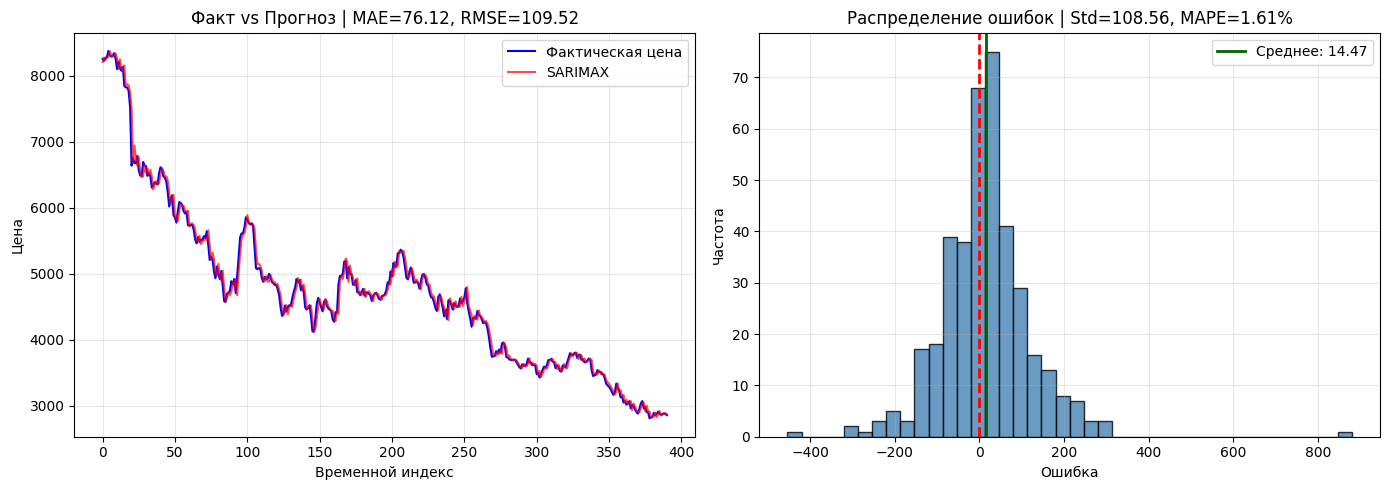


График сохранен: sarimax_analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Факт vs Прогноз
axes[0].plot(test_y, label='Фактическая цена', linewidth=1.5, color='blue')
axes[0].plot(predictions, label='SARIMAX', linewidth=1.5, color='red', alpha=0.7)
axes[0].set_title(f'Факт vs Прогноз | MAE={mae:.2f}, RMSE={rmse:.2f}')
axes[0].set_xlabel('Временной индекс')
axes[0].set_ylabel('Цена')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Распределение ошибок
errors = predictions - test_y
axes[1].hist(errors, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=np.mean(errors), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors):.2f}')
axes[1].set_xlabel('Ошибка')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'Распределение ошибок | Std={np.std(errors):.2f}, MAPE={mape:.2f}%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sarimax_analysis.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/sarimax_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: sarimax_analysis.png")

try:
    from google.colab import files
    files.download('sarimax_analysis.png')
except:
    pass

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

# УДАЛЯЕМ ВСЕ СТРОКОВЫЕ КОЛОНКИ
for col_name in result.columns:
    if result[col_name].dtype == 'object':
        result = result.drop(columns=[col_name])

def create_features_ridge(data, include_external=True):
    df = data.copy()

    # УТРОМ ИЗВЕСТНО: Открытие
    df['Open_today'] = df['Открытие']

    # УТРОМ ИЗВЕСТНО: Курс (если включаем)
    if include_external:
        df['Currency_today'] = df['Курс']

    # Прошлые значения
    for lag in [1, 2, 3, 5]:
        df[f'close_lag_{lag}'] = df['Закрытие'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Объем'].shift(lag)
        df[f'high_lag_{lag}'] = df['Максимум'].shift(lag)
        df[f'low_lag_{lag}'] = df['Минимум'].shift(lag)

    # Технические индикаторы
    df['sma_5'] = df['close_lag_1'].rolling(5).mean()
    df['sma_10'] = df['close_lag_1'].rolling(10).mean()
    df['sma_20'] = df['close_lag_1'].rolling(20).mean()
    df['ema_5'] = df['close_lag_1'].ewm(span=5, adjust=False).mean()
    df['ema_10'] = df['close_lag_1'].ewm(span=10, adjust=False).mean()
    df['volatility'] = df['close_lag_1'].rolling(10).std()

    # RSI
    delta = df['close_lag_1'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-10)
    df['RSI'] = 100 - (100 / (1 + rs))

    # Процентные изменения
    df['return_1'] = df['close_lag_1'].pct_change()
    df['return_5'] = df['close_lag_5'].pct_change()
    df['volume_change'] = df['volume_lag_1'].pct_change()

    # Соотношения
    df['high_low_ratio'] = df['high_lag_1'] / (df['low_lag_1'] + 1e-10)
    df['close_open_ratio'] = df['close_lag_1'] / (df['Открытие'].shift(1) + 1e-10)
    df['gap'] = (df['Open_today'] - df['close_lag_1']) / (df['close_lag_1'] + 1e-10) * 100

    # Внешние факторы
    if include_external:
        df['value_lag_1'] = df['Значение'].shift(1)
        df['value_lag_2'] = df['Значение'].shift(2)
        df['currency_lag_1'] = df['Курс'].shift(1)
        df['value_return'] = df['value_lag_1'].pct_change()
        df['currency_return'] = df['currency_lag_1'].pct_change()
        df['close_value_ratio'] = df['close_lag_1'] / (df['value_lag_1'] + 1e-10)
        df['close_currency_ratio'] = df['close_lag_1'] / (df['currency_lag_1'] + 1e-10)
        df['currency_today_ratio'] = df['Currency_today'] / (df['currency_lag_1'] + 1e-10)

    # Лаговые ошибки
    df['error_proxy'] = df['close_lag_1'] - df['Открытие'].shift(1)
    df['error_lag1'] = df['error_proxy'].shift(1)
    df['error_lag2'] = df['error_proxy'].shift(2)
    df['error_ma5'] = df['error_proxy'].rolling(5).mean()

    # Целевая переменная
    df['Close_today'] = df['Закрытие']

    # Удаляем исходные колонки и служебные
    cols_to_drop = ['Закрытие', 'Открытие', 'Максимум', 'Минимум', 'Объем',
                    'Курс', 'Значение', 'Средняя_цена', 'Количество', 'Close_today', 'error_proxy']

    feature_cols = [c for c in df.columns if c not in cols_to_drop]
    df_clean = df.dropna().reset_index(drop=True)

    # Финальная проверка: только числовые колонки
    feature_cols = [c for c in feature_cols if df_clean[c].dtype in ['float64', 'float32', 'int64', 'int32']]

    return df_clean, feature_cols

def train_evaluate_ridge(df, feature_cols, model_name):
    X = df[feature_cols].values
    y = df['Close_today'].values

    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    param_grid = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
    tscv = TimeSeriesSplit(n_splits=3)

    grid_search = GridSearchCV(
        Ridge(random_state=42),
        param_grid,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    grid_search.fit(X_train_scaled, y_train)

    best_model = grid_search.best_estimator_
    preds = best_model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    r2 = r2_score(y_test, preds)

    return best_model, preds, y_test, mae, rmse, mape, r2, grid_search.best_params_

print("="*70)
print("RIDGE РЕГРЕССИЯ: ПРОГНОЗ НА ВЕЧЕР")
print("="*70)

# Модель БЕЗ внешних факторов
print("\n1. Модель БЕЗ внешних факторов")
df_wo, cols_wo = create_features_ridge(result, include_external=False)
print(f"Признаков: {len(cols_wo)}")
model_wo, pred_wo, y_test_wo, mae_wo, rmse_wo, mape_wo, r2_wo, params_wo = train_evaluate_ridge(df_wo, cols_wo, "Без внешних")

# Модель С внешними факторами
print("\n2. Модель С внешними факторами (Курс утром)")
df_w, cols_w = create_features_ridge(result, include_external=True)
print(f"Признаков: {len(cols_w)}")
model_w, pred_w, y_test_w, mae_w, rmse_w, mape_w, r2_w, params_w = train_evaluate_ridge(df_w, cols_w, "С внешними")

# Результаты
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ RIDGE")
print("="*70)
print(f"{'Модель':<20} {'MAE':>10} {'RMSE':>10} {'MAPE(%)':>10} {'R²':>10} {'Alpha':>10}")
print("-"*70)
print(f"{'Без внешних':<20} {mae_wo:>10.2f} {rmse_wo:>10.2f} {mape_wo:>10.2f} {r2_wo:>10.4f} {params_wo['alpha']:>10.2f}")
print(f"{'С внешними':<20} {mae_w:>10.2f} {rmse_w:>10.2f} {mape_w:>10.2f} {r2_w:>10.4f} {params_w['alpha']:>10.2f}")

RIDGE РЕГРЕССИЯ: ПРОГНОЗ НА ВЕЧЕР

1. Модель БЕЗ внешних факторов
Признаков: 34

2. Модель С внешними факторами (Курс утром)
Признаков: 43

РЕЗУЛЬТАТЫ RIDGE
Модель                      MAE       RMSE    MAPE(%)         R²      Alpha
----------------------------------------------------------------------
Без внешних               66.14      92.00       1.41     0.9942       1.00
С внешними                69.85      94.90       1.51     0.9938       1.00


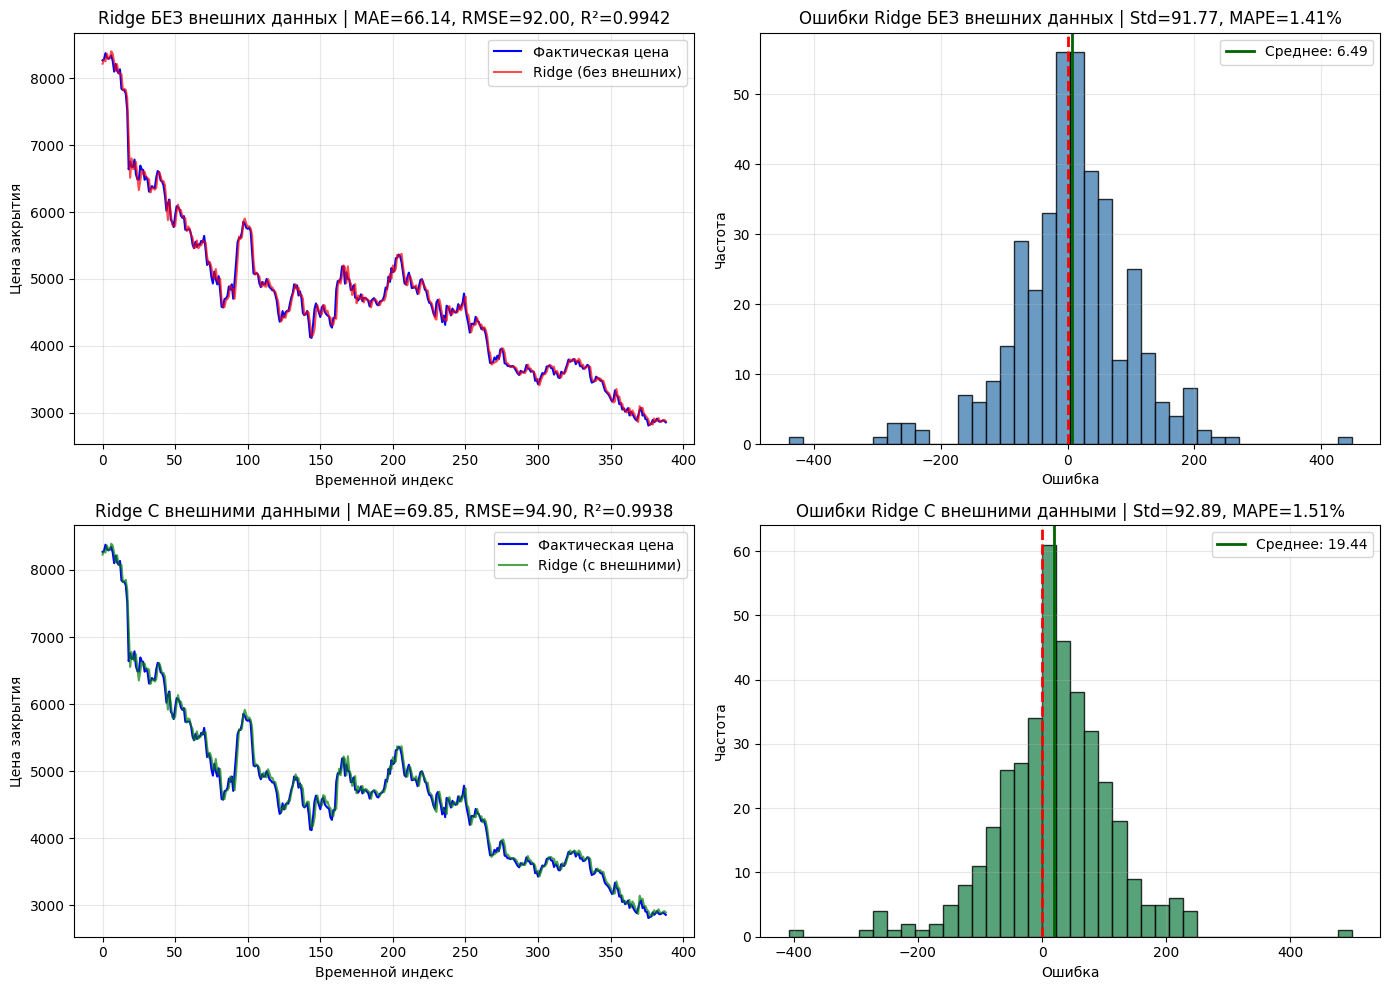


График сохранен: ridge_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл отправлен на скачивание


In [ ]:
# Графики для Ridge
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Без внешних - Факт vs Прогноз
axes[0, 0].plot(y_test_wo, label='Фактическая цена', linewidth=1.5, color='blue')
axes[0, 0].plot(pred_wo, label='Ridge (без внешних)', linewidth=1.5, color='red', alpha=0.7)
axes[0, 0].set_title(f'Ridge БЕЗ внешних данных | MAE={mae_wo:.2f}, RMSE={rmse_wo:.2f}, R²={r2_wo:.4f}')
axes[0, 0].set_xlabel('Временной индекс')
axes[0, 0].set_ylabel('Цена закрытия')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График 2: Без внешних - Распределение ошибок
errors_wo = pred_wo - y_test_wo
axes[0, 1].hist(errors_wo, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=np.mean(errors_wo), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors_wo):.2f}')
axes[0, 1].set_xlabel('Ошибка')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].set_title(f'Ошибки Ridge БЕЗ внешних данных | Std={np.std(errors_wo):.2f}, MAPE={mape_wo:.2f}%')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: С внешними - Факт vs Прогноз
axes[1, 0].plot(y_test_w, label='Фактическая цена', linewidth=1.5, color='blue')
axes[1, 0].plot(pred_w, label='Ridge (с внешними)', linewidth=1.5, color='green', alpha=0.7)
axes[1, 0].set_title(f'Ridge С внешними данными | MAE={mae_w:.2f}, RMSE={rmse_w:.2f}, R²={r2_w:.4f}')
axes[1, 0].set_xlabel('Временной индекс')
axes[1, 0].set_ylabel('Цена закрытия')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: С внешними - Распределение ошибок
errors_w = pred_w - y_test_w
axes[1, 1].hist(errors_w, bins=40, alpha=0.8, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].axvline(x=np.mean(errors_w), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors_w):.2f}')
axes[1, 1].set_xlabel('Ошибка')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_title(f'Ошибки Ridge С внешними данными | Std={np.std(errors_w):.2f}, MAPE={mape_w:.2f}%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ridge_results.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/ridge_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: ridge_results.png")

# Скачивание для Colab
try:
    from google.colab import files
    files.download('ridge_results.png')
    print("Файл отправлен на скачивание")
except:
    print("Не в Colab или ошибка скачивания")

In [ ]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\n" + "="*70)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ RIDGE")
print("="*70)

errors_wo = pred_wo - y_test_wo
errors_w = pred_w - y_test_w

def analyze_ridge_residuals(errors, model_name):
    n = len(errors)

    print(f"\n{'='*60}")
    print(f"Модель: {model_name}")
    print(f"{'='*60}")

    print(f"\n1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
    print(f"   Количество наблюдений: {n}")
    print(f"   Средняя ошибка (ME):   {np.mean(errors):.4f}")
    print(f"   Стандартное отклонение: {np.std(errors):.4f}")
    print(f"   Дисперсия:              {np.var(errors):.4f}")
    print(f"   Медиана:                {np.median(errors):.4f}")
    print(f"   Минимум:                {np.min(errors):.4f}")
    print(f"   Максимум:               {np.max(errors):.4f}")
    print(f"   Асимметрия (Skewness):  {stats.skew(errors):.4f}")
    print(f"   Эксцесс (Kurtosis):     {stats.kurtosis(errors):.4f}")

    print(f"\n2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:")
    if n > 5000:
        sample = np.random.choice(errors, 5000, replace=False)
        shapiro_stat, shapiro_p = stats.shapiro(sample)
    else:
        shapiro_stat, shapiro_p = stats.shapiro(errors)
    print(f"   Шапиро-Уилк:      statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

    ks_stat, ks_p = stats.kstest(errors, 'norm', args=(np.mean(errors), np.std(errors)))
    print(f"   Колмогоров-Смирнов: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")

    print(f"\n3. ТЕСТЫ НА БЕЛЫЙ ШУМ:")
    lb_result = acorr_ljungbox(errors, lags=[10], return_df=True)
    lb_stat = lb_result['lb_stat'].values[0]
    lb_p = lb_result['lb_pvalue'].values[0]
    print(f"   Льюнг-Бокс (lag=10): statistic={lb_stat:.4f}, p-value={lb_p:.4f}")

    diff = np.diff(errors)
    dw_stat = np.sum(diff**2) / np.sum(errors**2)
    print(f"   Дарбин-Ватсон:      statistic={dw_stat:.4f}")

    print(f"\n4. ИНТЕРПРЕТАЦИЯ:")
    if shapiro_p < 0.05:
        print("   Распределение ошибок НЕ нормальное (p < 0.05)")
    else:
        print("   Распределение ошибок нормальное (p >= 0.05)")

    if lb_p < 0.05:
        print("   Ошибки НЕ являются белым шумом (есть автокорреляция)")
    else:
        print("   Ошибки являются белым шумом (нет автокорреляции)")

    if dw_stat < 1.5:
        print("   Положительная автокорреляция ошибок (DW < 1.5)")
    elif dw_stat > 2.5:
        print("   Отрицательная автокорреляция ошибок (DW > 2.5)")
    else:
        print("   Автокорреляция ошибок отсутствует (DW ≈ 2)")

    if abs(stats.skew(errors)) < 0.5:
        print("   Распределение симметричное")
    elif stats.skew(errors) > 0:
        print("   Распределение с правосторонней асимметрией")
    else:
        print("   Распределение с левосторонней асимметрией")

    return {'mean': np.mean(errors), 'std': np.std(errors), 'lb_p': lb_p, 'dw_stat': dw_stat}

# Анализ для обеих моделей
stats_wo = analyze_ridge_residuals(errors_wo, "Ridge БЕЗ внешних")
stats_w = analyze_ridge_residuals(errors_w, "Ridge С внешними")

# Сравнение моделей
print("\n" + "="*70)
print("СРАВНЕНИЕ МОДЕЛЕЙ RIDGE")
print("="*70)

print(f"\nСводка по ошибкам:")
print(f"{'Модель':<20} {'MAE':>10} {'Среднее':>10} {'Стд.откл':>10}")
print("-"*50)
print(f"{'Без внешних':<20} {mae_wo:>10.2f} {stats_wo['mean']:>10.2f} {stats_wo['std']:>10.2f}")
print(f"{'С внешними':<20} {mae_w:>10.2f} {stats_w['mean']:>10.2f} {stats_w['std']:>10.2f}")

# Тест Уилкоксона
stat, p_wilcoxon = stats.wilcoxon(np.abs(errors_wo), np.abs(errors_w))
print(f"\nТест Уилкоксона: p-value={p_wilcoxon:.6f}")
if p_wilcoxon < 0.05:
    if mae_wo < mae_w:
        print(">>> Ridge БЕЗ внешних ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
    else:
        print(">>> Ridge С внешними ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
else:
    print(">>> Различие НЕ значимо (p >= 0.05)")

# Итог
print("\n" + "="*70)
print("ИТОГ")
print("="*70)
print(f"MAE без внешних: {mae_wo:.2f}")
print(f"MAE с внешними:  {mae_w:.2f}")
print(f"Разница:         {mae_w - mae_wo:+.2f}")

if mae_wo < mae_w:
    print("\n>>> Рекомендуется модель Ridge БЕЗ внешних факторов")
else:
    print("\n>>> Рекомендуется модель Ridge С внешними факторами")


СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ RIDGE

Модель: Ridge БЕЗ внешних

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Количество наблюдений: 389
   Средняя ошибка (ME):   6.4933
   Стандартное отклонение: 91.7728
   Дисперсия:              8422.2386
   Медиана:                8.1887
   Минимум:                -439.7824
   Максимум:               448.0925
   Асимметрия (Skewness):  -0.2921
   Эксцесс (Kurtosis):     3.0828

2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:
   Шапиро-Уилк:      statistic=0.9615, p-value=0.0000
   Колмогоров-Смирнов: statistic=0.0727, p-value=0.0310

3. ТЕСТЫ НА БЕЛЫЙ ШУМ:
   Льюнг-Бокс (lag=10): statistic=19.6968, p-value=0.0323
   Дарбин-Ватсон:      statistic=1.9283

4. ИНТЕРПРЕТАЦИЯ:
   Распределение ошибок НЕ нормальное (p < 0.05)
   Ошибки НЕ являются белым шумом (есть автокорреляция)
   Автокорреляция ошибок отсутствует (DW ≈ 2)
   Распределение симметричное

Модель: Ridge С внешними

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Количество наблюдений: 389
   Средняя ошибка (ME):   19.4443
   Стандартное от

ARIMA


ARIMA ДЛЯ ПРОГНОЗИРОВАНИЯ МАГНИТА

1. Автоматический подбор параметров ARIMA...
   Лучшие параметры: (2, 1, 0)

2. Обучение ARIMA с пошаговым прогнозом...

РЕЗУЛЬТАТЫ ARIMA
Параметры: (2, 1, 0)
MAE:  75.94
RMSE: 109.92
MAPE: 1.60%
R²:   0.9923

СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ ARIMA

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Количество наблюдений: 393
   Средняя ошибка (ME):   15.4091
   Стандартное отклонение: 108.8317
   Асимметрия (Skewness):  1.0718
   Эксцесс (Kurtosis):     10.6441

2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:
   Шапиро-Уилк:      p-value=0.0000
   Колмогоров-Смирнов: p-value=0.0119

3. ТЕСТЫ НА БЕЛЫЙ ШУМ:
   Льюнг-Бокс (lag=10): p-value=0.0050
   Дарбин-Ватсон:      statistic=1.8263

4. ИНТЕРПРЕТАЦИЯ:
   Распределение ошибок НЕ нормальное
   Ошибки НЕ являются белым шумом (есть автокорреляция)
   Автокорреляция ошибок отсутствует


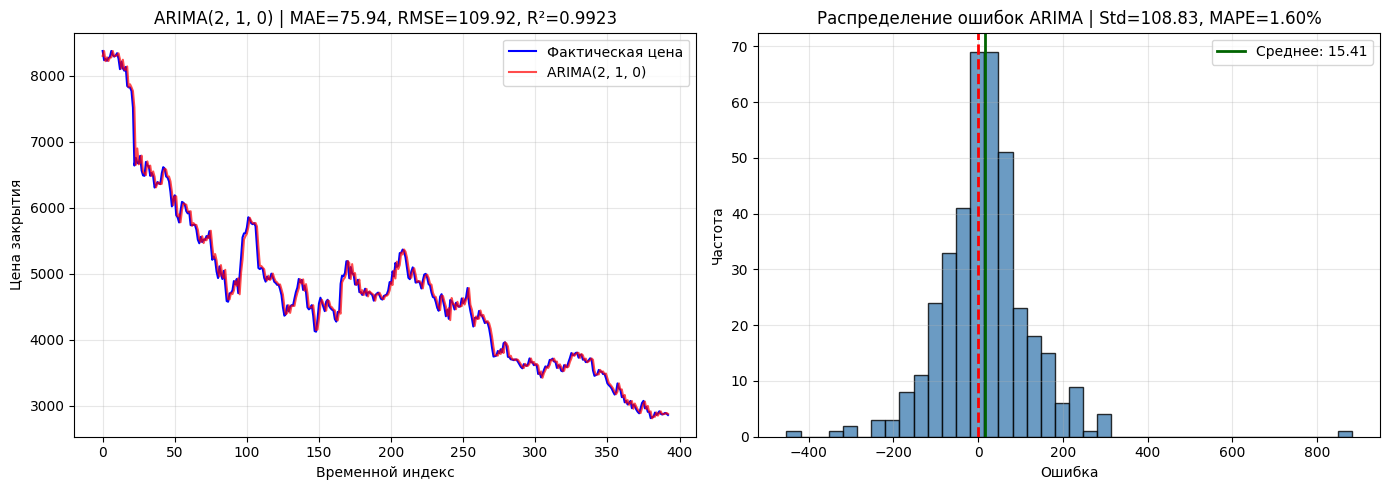


График сохранен: arima_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл отправлен на скачивание


In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pmdarima import auto_arima
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

def train_evaluate_arima_one_day(train, test, order):
    try:
        history = list(train)
        predictions = []

        for t in range(len(test)):
            model = ARIMA(history, order=order)
            fitted = model.fit()
            y_pred = fitted.forecast(1)[0]
            predictions.append(y_pred)
            history.append(test[t])

        predictions = np.array(predictions)

        mae = mean_absolute_error(test, predictions)
        rmse = np.sqrt(mean_squared_error(test, predictions))
        mape = np.mean(np.abs((test - predictions) / test)) * 100

        baseline = np.mean(train)
        ss_res = np.sum((test - predictions) ** 2)
        ss_tot = np.sum((test - baseline) ** 2)
        r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

        return mae, rmse, mape, r2, predictions
    except Exception as e:
        return None, None, None, None, None

def auto_arima_search(ts, verbose=False):
    model = auto_arima(
        ts,
        start_p=0, start_q=0,
        max_p=5, max_q=5,
        seasonal=False,
        stepwise=True,
        trace=False,
        error_action='ignore',
        suppress_warnings=True,
        random_state=42,
        n_fits=30
    )
    return model.order

ts_magnit = result['Закрытие'].values

train_size = int(len(ts_magnit) * 0.8)
train_y_magnit = ts_magnit[:train_size]
test_y_magnit = ts_magnit[train_size:]

print("="*70)
print("ARIMA ДЛЯ ПРОГНОЗИРОВАНИЯ МАГНИТА")
print("="*70)

print("\n1. Автоматический подбор параметров ARIMA...")
params_arima = auto_arima_search(train_y_magnit)
print(f"   Лучшие параметры: {params_arima}")

print("\n2. Обучение ARIMA с пошаговым прогнозом...")
mae_magnit, rmse_magnit, mape_magnit, r2_magnit, predictions = train_evaluate_arima_one_day(
    train_y_magnit, test_y_magnit, params_arima
)

print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ ARIMA")
print("="*70)
print(f"Параметры: {params_arima}")
print(f"MAE:  {mae_magnit:.2f}")
print(f"RMSE: {rmse_magnit:.2f}")
print(f"MAPE: {mape_magnit:.2f}%")
print(f"R²:   {r2_magnit:.4f}")

# Статистический анализ остатков
errors = predictions - test_y_magnit
n = len(errors)

print("\n" + "="*70)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ ARIMA")
print("="*70)

print(f"\n1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
print(f"   Количество наблюдений: {n}")
print(f"   Средняя ошибка (ME):   {np.mean(errors):.4f}")
print(f"   Стандартное отклонение: {np.std(errors):.4f}")
print(f"   Асимметрия (Skewness):  {stats.skew(errors):.4f}")
print(f"   Эксцесс (Kurtosis):     {stats.kurtosis(errors):.4f}")

print(f"\n2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:")
if n > 5000:
    sample = np.random.choice(errors, 5000, replace=False)
    shapiro_stat, shapiro_p = stats.shapiro(sample)
else:
    shapiro_stat, shapiro_p = stats.shapiro(errors)
print(f"   Шапиро-Уилк:      p-value={shapiro_p:.4f}")

ks_stat, ks_p = stats.kstest(errors, 'norm', args=(np.mean(errors), np.std(errors)))
print(f"   Колмогоров-Смирнов: p-value={ks_p:.4f}")

print(f"\n3. ТЕСТЫ НА БЕЛЫЙ ШУМ:")
lb_result = acorr_ljungbox(errors, lags=[10], return_df=True)
lb_p = lb_result['lb_pvalue'].values[0]
print(f"   Льюнг-Бокс (lag=10): p-value={lb_p:.4f}")

dw_stat = np.sum(np.diff(errors)**2) / np.sum(errors**2)
print(f"   Дарбин-Ватсон:      statistic={dw_stat:.4f}")

print(f"\n4. ИНТЕРПРЕТАЦИЯ:")
if shapiro_p < 0.05:
    print("   Распределение ошибок НЕ нормальное")
else:
    print("   Распределение ошибок нормальное")

if lb_p < 0.05:
    print("   Ошибки НЕ являются белым шумом (есть автокорреляция)")
else:
    print("   Ошибки являются белым шумом")

if dw_stat < 1.5:
    print("   Положительная автокорреляция ошибок")
elif dw_stat > 2.5:
    print("   Отрицательная автокорреляция ошибок")
else:
    print("   Автокорреляция ошибок отсутствует")

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Факт vs Прогноз
axes[0].plot(test_y_magnit, label='Фактическая цена', linewidth=1.5, color='blue')
axes[0].plot(predictions, label=f'ARIMA{params_arima}', linewidth=1.5, color='red', alpha=0.7)
axes[0].set_title(f'MAE={mae_magnit:.2f}, RMSE={rmse_magnit:.2f}, R²={r2_magnit:.4f}')
axes[0].set_xlabel('Временной индекс')
axes[0].set_ylabel('Цена закрытия')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Распределение ошибок
axes[1].hist(errors, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=np.mean(errors), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors):.2f}')
axes[1].set_xlabel('Ошибка')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'Распределение ошибок ARIMA | Std={np.std(errors):.2f}, MAPE={mape_magnit:.2f}%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('arima_results.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/arima_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: arima_results.png")

try:
    from google.colab import files
    files.download('arima_results.png')
    print("Файл отправлен на скачивание")
except:
    pass

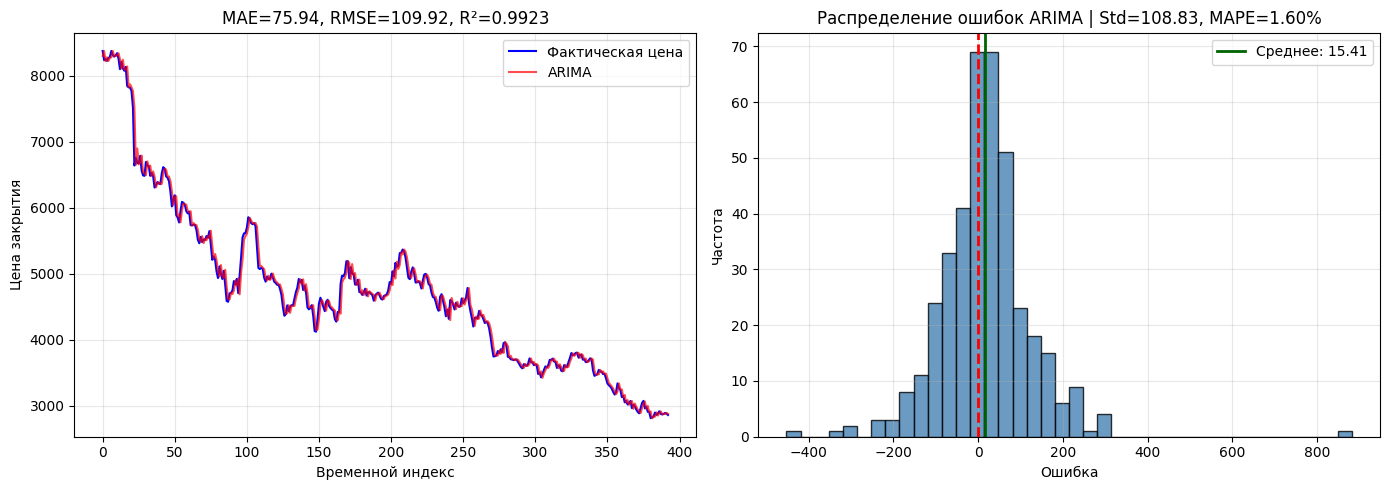


График сохранен: arima_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл отправлен на скачивание


In [ ]:
# Графики
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Факт vs Прогноз
axes[0].plot(test_y_magnit, label='Фактическая цена', linewidth=1.5, color='blue')
axes[0].plot(predictions, label=f'ARIMA', linewidth=1.5, color='red', alpha=0.7)
axes[0].set_title(f'MAE={mae_magnit:.2f}, RMSE={rmse_magnit:.2f}, R²={r2_magnit:.4f}')
axes[0].set_xlabel('Временной индекс')
axes[0].set_ylabel('Цена закрытия')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Распределение ошибок
axes[1].hist(errors, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].axvline(x=np.mean(errors), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors):.2f}')
axes[1].set_xlabel('Ошибка')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'Распределение ошибок ARIMA | Std={np.std(errors):.2f}, MAPE={mape_magnit:.2f}%')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('arima_results.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/arima_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: arima_results.png")

try:
    from google.colab import files
    files.download('arima_results.png')
    print("Файл отправлен на скачивание")
except:
    pass

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
data = pd.read_csv('новая_нефть.csv', encoding='utf-8', sep=',')
data['Дата'] = pd.to_datetime(data['Дата'])
data['Дата'] = data['Дата'].dt.strftime("%Y-%m-%d")
data = data.sort_values(by='Дата').reset_index(drop=True)

new_data = pd.read_csv('обработанные_данные.csv', encoding='utf-8', sep=',')
result = new_data.merge(data, on='Дата', how='left')

result['Значение'] = result['Значение'].interpolate(method='linear')
result['Количество'] = pd.to_numeric(result['Количество'], errors='coerce')

col = ['Объем', 'Средняя_цена', 'Открытие', 'Минимум', 'Максимум',
       'Закрытие', 'Количество', 'Курс', 'Значение']
result[col] = result[col].apply(pd.to_numeric, errors='coerce')
result = result.dropna().reset_index(drop=True)

# УДАЛЯЕМ ВСЕ СТРОКОВЫЕ КОЛОНКИ
for col_name in result.columns:
    if result[col_name].dtype == 'object':
        result = result.drop(columns=[col_name])

def create_features_ridge(data, include_external=True):
    df = data.copy()

    # УТРОМ ИЗВЕСТНО: Открытие
    df['Open_today'] = df['Открытие']

    # УТРОМ ИЗВЕСТНО: Курс (если включаем)
    if include_external:
        df['Currency_today'] = df['Курс']

    # Прошлые значения
    for lag in [1, 2, 3, 5]:
        df[f'close_lag_{lag}'] = df['Закрытие'].shift(lag)
        df[f'volume_lag_{lag}'] = df['Объем'].shift(lag)
        df[f'high_lag_{lag}'] = df['Максимум'].shift(lag)
        df[f'low_lag_{lag}'] = df['Минимум'].shift(lag)

    # Технические индикаторы
    df['sma_5'] = df['close_lag_1'].rolling(5).mean()
    df['sma_10'] = df['close_lag_1'].rolling(10).mean()
    df['sma_20'] = df['close_lag_1'].rolling(20).mean()
    df['ema_5'] = df['close_lag_1'].ewm(span=5, adjust=False).mean()
    df['ema_10'] = df['close_lag_1'].ewm(span=10, adjust=False).mean()
    df['volatility'] = df['close_lag_1'].rolling(10).std()

    # RSI
    delta = df['close_lag_1'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-10)
    df['RSI'] = 100 - (100 / (1 + rs))

    # Процентные изменения
    df['return_1'] = df['close_lag_1'].pct_change()
    df['return_5'] = df['close_lag_5'].pct_change()
    df['volume_change'] = df['volume_lag_1'].pct_change()

    # Соотношения
    df['high_low_ratio'] = df['high_lag_1'] / (df['low_lag_1'] + 1e-10)
    df['close_open_ratio'] = df['close_lag_1'] / (df['Открытие'].shift(1) + 1e-10)
    df['gap'] = (df['Open_today'] - df['close_lag_1']) / (df['close_lag_1'] + 1e-10) * 100

    # Внешние факторы
    if include_external:
        df['value_lag_1'] = df['Значение'].shift(1)
        df['value_lag_2'] = df['Значение'].shift(2)
        df['currency_lag_1'] = df['Курс'].shift(1)
        df['value_return'] = df['value_lag_1'].pct_change()
        df['currency_return'] = df['currency_lag_1'].pct_change()
        df['close_value_ratio'] = df['close_lag_1'] / (df['value_lag_1'] + 1e-10)
        df['close_currency_ratio'] = df['close_lag_1'] / (df['currency_lag_1'] + 1e-10)
        df['currency_today_ratio'] = df['Currency_today'] / (df['currency_lag_1'] + 1e-10)

    # Лаговые ошибки
    df['error_proxy'] = df['close_lag_1'] - df['Открытие'].shift(1)
    df['error_lag1'] = df['error_proxy'].shift(1)
    df['error_lag2'] = df['error_proxy'].shift(2)
    df['error_ma5'] = df['error_proxy'].rolling(5).mean()

    # Целевая переменная
    df['Close_today'] = df['Закрытие']

    # Удаляем исходные колонки и служебные
    cols_to_drop = ['Закрытие', 'Открытие', 'Максимум', 'Минимум', 'Объем',
                    'Курс', 'Значение', 'Средняя_цена', 'Количество', 'Close_today', 'error_proxy']

    feature_cols = [c for c in df.columns if c not in cols_to_drop]
    df_clean = df.dropna().reset_index(drop=True)

    # Финальная проверка: только числовые колонки
    feature_cols = [c for c in feature_cols if df_clean[c].dtype in ['float64', 'float32', 'int64', 'int32']]

    return df_clean, feature_cols

def train_evaluate_ridge(df, feature_cols, model_name):
    X = df[feature_cols].values
    y = df['Close_today'].values

    train_size = int(len(X) * 0.8)
    X_train, X_test = X[:train_size], X[train_size:]
    y_train, y_test = y[:train_size], y[train_size:]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    param_grid = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
    tscv = TimeSeriesSplit(n_splits=3)

    grid_search = GridSearchCV(
        Ridge(random_state=42),
        param_grid,
        cv=tscv,
        scoring='neg_mean_absolute_error',
        n_jobs=-1
    )
    grid_search.fit(X_train_scaled, y_train)

    best_model = grid_search.best_estimator_
    preds = best_model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
    r2 = r2_score(y_test, preds)

    return best_model, preds, y_test, mae, rmse, mape, r2, grid_search.best_params_

print("="*70)
print("RIDGE РЕГРЕССИЯ: ПРОГНОЗ НА ВЕЧЕР")
print("="*70)

# Модель БЕЗ внешних факторов
print("\n1. Модель БЕЗ внешних факторов")
df_wo, cols_wo = create_features_ridge(result, include_external=False)
print(f"Признаков: {len(cols_wo)}")
model_wo, pred_wo, y_test_wo, mae_wo, rmse_wo, mape_wo, r2_wo, params_wo = train_evaluate_ridge(df_wo, cols_wo, "Без внешних")

# Модель С внешними факторами
print("\n2. Модель С внешними факторами (Курс утром)")
df_w, cols_w = create_features_ridge(result, include_external=True)
print(f"Признаков: {len(cols_w)}")
model_w, pred_w, y_test_w, mae_w, rmse_w, mape_w, r2_w, params_w = train_evaluate_ridge(df_w, cols_w, "С внешними")

# Результаты
print("\n" + "="*70)
print("РЕЗУЛЬТАТЫ RIDGE")
print("="*70)
print(f"{'Модель':<20} {'MAE':>10} {'RMSE':>10} {'MAPE(%)':>10} {'R²':>10} {'Alpha':>10}")
print("-"*70)
print(f"{'Без внешних':<20} {mae_wo:>10.2f} {rmse_wo:>10.2f} {mape_wo:>10.2f} {r2_wo:>10.4f} {params_wo['alpha']:>10.2f}")
print(f"{'С внешними':<20} {mae_w:>10.2f} {rmse_w:>10.2f} {mape_w:>10.2f} {r2_w:>10.4f} {params_w['alpha']:>10.2f}")

RIDGE РЕГРЕССИЯ: ПРОГНОЗ НА ВЕЧЕР

1. Модель БЕЗ внешних факторов
Признаков: 34

2. Модель С внешними факторами (Курс утром)
Признаков: 43

РЕЗУЛЬТАТЫ RIDGE
Модель                      MAE       RMSE    MAPE(%)         R²      Alpha
----------------------------------------------------------------------
Без внешних               64.84      90.01       1.39     0.9942       1.00
С внешними                65.65      90.55       1.40     0.9941       1.00


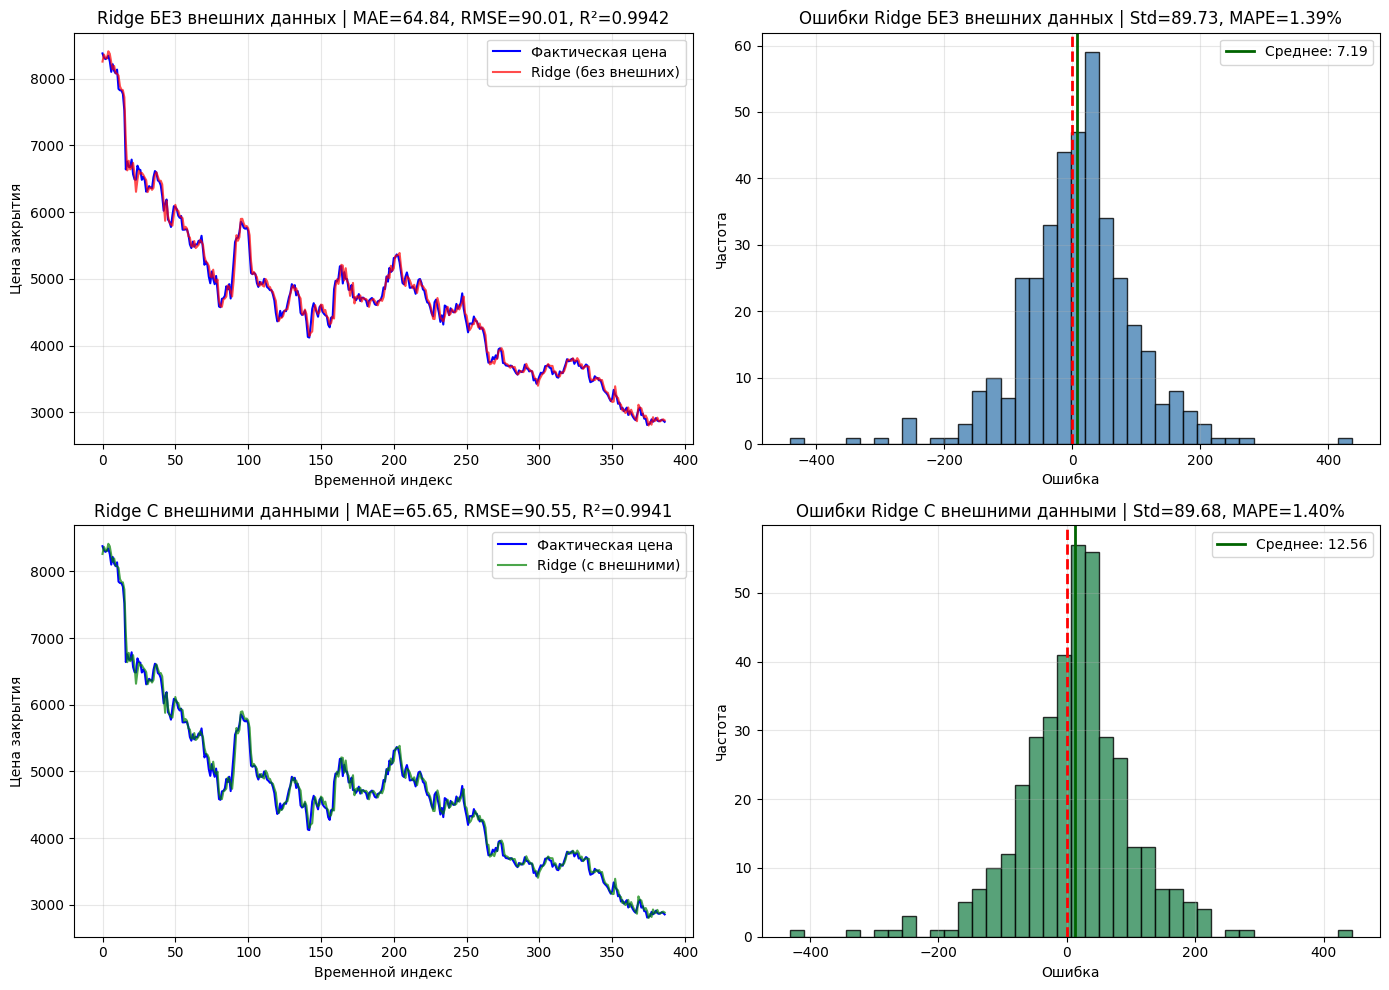


График сохранен: ridge_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Файл отправлен на скачивание


In [ ]:
# Графики для Ridge
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# График 1: Без внешних - Факт vs Прогноз
axes[0, 0].plot(y_test_wo, label='Фактическая цена', linewidth=1.5, color='blue')
axes[0, 0].plot(pred_wo, label='Ridge (без внешних)', linewidth=1.5, color='red', alpha=0.7)
axes[0, 0].set_title(f'Ridge БЕЗ внешних данных | MAE={mae_wo:.2f}, RMSE={rmse_wo:.2f}, R²={r2_wo:.4f}')
axes[0, 0].set_xlabel('Временной индекс')
axes[0, 0].set_ylabel('Цена закрытия')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# График 2: Без внешних - Распределение ошибок
errors_wo = pred_wo - y_test_wo
axes[0, 1].hist(errors_wo, bins=40, alpha=0.8, color='steelblue', edgecolor='black')
axes[0, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 1].axvline(x=np.mean(errors_wo), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors_wo):.2f}')
axes[0, 1].set_xlabel('Ошибка')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].set_title(f'Ошибки Ridge БЕЗ внешних данных | Std={np.std(errors_wo):.2f}, MAPE={mape_wo:.2f}%')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: С внешними - Факт vs Прогноз
axes[1, 0].plot(y_test_w, label='Фактическая цена', linewidth=1.5, color='blue')
axes[1, 0].plot(pred_w, label='Ridge (с внешними)', linewidth=1.5, color='green', alpha=0.7)
axes[1, 0].set_title(f'Ridge С внешними данными | MAE={mae_w:.2f}, RMSE={rmse_w:.2f}, R²={r2_w:.4f}')
axes[1, 0].set_xlabel('Временной индекс')
axes[1, 0].set_ylabel('Цена закрытия')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: С внешними - Распределение ошибок
errors_w = pred_w - y_test_w
axes[1, 1].hist(errors_w, bins=40, alpha=0.8, color='seagreen', edgecolor='black')
axes[1, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1, 1].axvline(x=np.mean(errors_w), color='darkgreen', linestyle='-', linewidth=2, label=f'Среднее: {np.mean(errors_w):.2f}')
axes[1, 1].set_xlabel('Ошибка')
axes[1, 1].set_ylabel('Частота')
axes[1, 1].set_title(f'Ошибки Ridge С внешними данными | Std={np.std(errors_w):.2f}, MAPE={mape_w:.2f}%')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ridge_results.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/ridge_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранен: ridge_results.png")

# Скачивание для Colab
try:
    from google.colab import files
    files.download('ridge_results.png')
    print("Файл отправлен на скачивание")
except:
    print("Не в Colab или ошибка скачивания")

In [ ]:
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

print("\n" + "="*70)
print("СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ RIDGE")
print("="*70)

errors_wo = pred_wo - y_test_wo
errors_w = pred_w - y_test_w

def analyze_ridge_residuals(errors, model_name):
    n = len(errors)

    print(f"\n{'='*60}")
    print(f"Модель: {model_name}")
    print(f"{'='*60}")

    print(f"\n1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
    print(f"   Количество наблюдений: {n}")
    print(f"   Средняя ошибка (ME):   {np.mean(errors):.4f}")
    print(f"   Стандартное отклонение: {np.std(errors):.4f}")
    print(f"   Дисперсия:              {np.var(errors):.4f}")
    print(f"   Медиана:                {np.median(errors):.4f}")
    print(f"   Минимум:                {np.min(errors):.4f}")
    print(f"   Максимум:               {np.max(errors):.4f}")
    print(f"   Асимметрия (Skewness):  {stats.skew(errors):.4f}")
    print(f"   Эксцесс (Kurtosis):     {stats.kurtosis(errors):.4f}")

    print(f"\n2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:")
    if n > 5000:
        sample = np.random.choice(errors, 5000, replace=False)
        shapiro_stat, shapiro_p = stats.shapiro(sample)
    else:
        shapiro_stat, shapiro_p = stats.shapiro(errors)
    print(f"   Шапиро-Уилк:      statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4f}")

    ks_stat, ks_p = stats.kstest(errors, 'norm', args=(np.mean(errors), np.std(errors)))
    print(f"   Колмогоров-Смирнов: statistic={ks_stat:.4f}, p-value={ks_p:.4f}")

    print(f"\n3. ТЕСТЫ НА БЕЛЫЙ ШУМ:")
    lb_result = acorr_ljungbox(errors, lags=[10], return_df=True)
    lb_stat = lb_result['lb_stat'].values[0]
    lb_p = lb_result['lb_pvalue'].values[0]
    print(f"   Льюнг-Бокс (lag=10): statistic={lb_stat:.4f}, p-value={lb_p:.4f}")

    diff = np.diff(errors)
    dw_stat = np.sum(diff**2) / np.sum(errors**2)
    print(f"   Дарбин-Ватсон:      statistic={dw_stat:.4f}")

    print(f"\n4. ИНТЕРПРЕТАЦИЯ:")
    if shapiro_p < 0.05:
        print("   Распределение ошибок НЕ нормальное (p < 0.05)")
    else:
        print("   Распределение ошибок нормальное (p >= 0.05)")

    if lb_p < 0.05:
        print("   Ошибки НЕ являются белым шумом (есть автокорреляция)")
    else:
        print("   Ошибки являются белым шумом (нет автокорреляции)")

    if dw_stat < 1.5:
        print("   Положительная автокорреляция ошибок (DW < 1.5)")
    elif dw_stat > 2.5:
        print("   Отрицательная автокорреляция ошибок (DW > 2.5)")
    else:
        print("   Автокорреляция ошибок отсутствует (DW ≈ 2)")

    if abs(stats.skew(errors)) < 0.5:
        print("   Распределение симметричное")
    elif stats.skew(errors) > 0:
        print("   Распределение с правосторонней асимметрией")
    else:
        print("   Распределение с левосторонней асимметрией")

    return {'mean': np.mean(errors), 'std': np.std(errors), 'lb_p': lb_p, 'dw_stat': dw_stat}

# Анализ для обеих моделей
stats_wo = analyze_ridge_residuals(errors_wo, "Ridge БЕЗ внешних")
stats_w = analyze_ridge_residuals(errors_w, "Ridge С внешними")

# Сравнение моделей
print("\n" + "="*70)
print("СРАВНЕНИЕ МОДЕЛЕЙ RIDGE")
print("="*70)

print(f"\nСводка по ошибкам:")
print(f"{'Модель':<20} {'MAE':>10} {'Среднее':>10} {'Стд.откл':>10}")
print("-"*50)
print(f"{'Без внешних':<20} {mae_wo:>10.2f} {stats_wo['mean']:>10.2f} {stats_wo['std']:>10.2f}")
print(f"{'С внешними':<20} {mae_w:>10.2f} {stats_w['mean']:>10.2f} {stats_w['std']:>10.2f}")

# Тест Уилкоксона
stat, p_wilcoxon = stats.wilcoxon(np.abs(errors_wo), np.abs(errors_w))
print(f"\nТест Уилкоксона: p-value={p_wilcoxon:.6f}")
if p_wilcoxon < 0.05:
    if mae_wo < mae_w:
        print(">>> Ridge БЕЗ внешних ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
    else:
        print(">>> Ridge С внешними ЗНАЧИМО ЛУЧШЕ (p < 0.05)")
else:
    print(">>> Различие НЕ значимо (p >= 0.05)")

# Итог
print("\n" + "="*70)
print("ИТОГ")
print("="*70)
print(f"MAE без внешних: {mae_wo:.2f}")
print(f"MAE с внешними:  {mae_w:.2f}")
print(f"Разница:         {mae_w - mae_wo:+.2f}")

if mae_wo < mae_w:
    print("\n>>> Рекомендуется модель Ridge БЕЗ внешних факторов")
else:
    print("\n>>> Рекомендуется модель Ridge С внешними факторами")


СТАТИСТИЧЕСКИЙ АНАЛИЗ ОСТАТКОВ RIDGE

Модель: Ridge БЕЗ внешних

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Количество наблюдений: 387
   Средняя ошибка (ME):   7.1913
   Стандартное отклонение: 89.7252
   Дисперсия:              8050.6185
   Медиана:                13.0689
   Минимум:                -441.2846
   Максимум:               436.5792
   Асимметрия (Skewness):  -0.3302
   Эксцесс (Kurtosis):     3.4723

2. ТЕСТЫ НА НОРМАЛЬНОСТЬ:
   Шапиро-Уилк:      statistic=0.9569, p-value=0.0000
   Колмогоров-Смирнов: statistic=0.0716, p-value=0.0361

3. ТЕСТЫ НА БЕЛЫЙ ШУМ:
   Льюнг-Бокс (lag=10): statistic=18.8974, p-value=0.0416
   Дарбин-Ватсон:      statistic=1.7630

4. ИНТЕРПРЕТАЦИЯ:
   Распределение ошибок НЕ нормальное (p < 0.05)
   Ошибки НЕ являются белым шумом (есть автокорреляция)
   Автокорреляция ошибок отсутствует (DW ≈ 2)
   Распределение симметричное

Модель: Ridge С внешними

1. ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
   Количество наблюдений: 387
   Средняя ошибка (ME):   12.5637
   Стандартное о